<a href="https://colab.research.google.com/github/Elgendi/The-Effect-Separation-Index/blob/main/Boxplot_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Figure 1 example: d_target=0.2, n=1000 per group
Estimated Cohen's d = 0.147, p-value = 1.01e-03


/tmp/ipython-input-2032724594.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


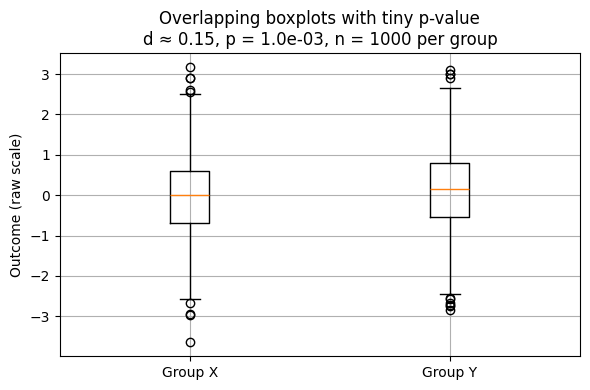

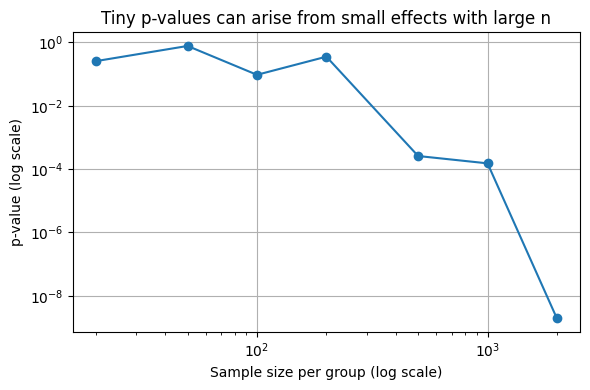

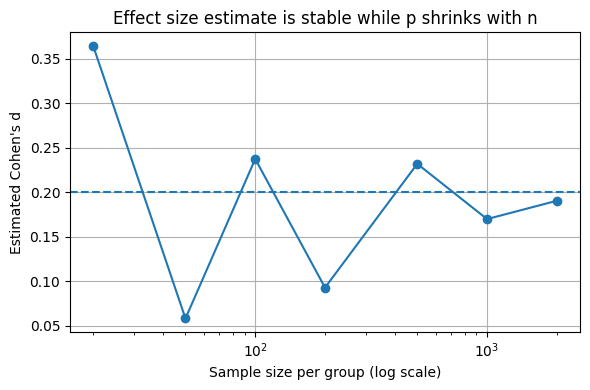

Figure 3 (log-normal): p (log-scale t-test) = 2.75e-28, Cohen's d (log-scale) = 0.501


/tmp/ipython-input-2032724594.py:147: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y], labels=["Group X", "Group Y"], showfliers=True)


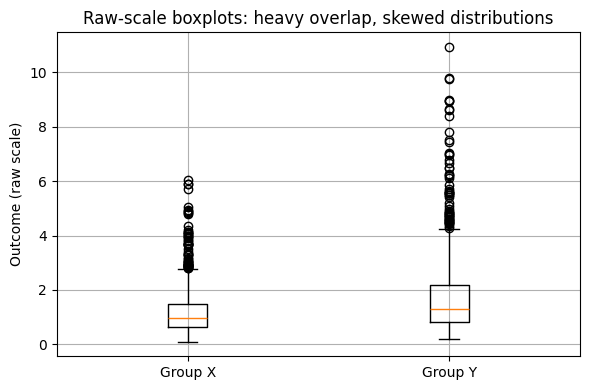

/tmp/ipython-input-2032724594.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([log_x, log_y], labels=["Group X", "Group Y"], showfliers=True)


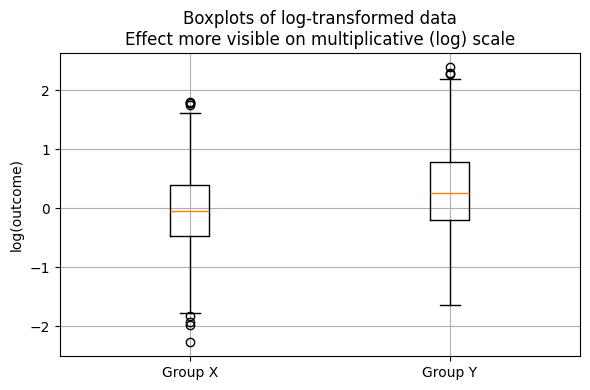

/tmp/ipython-input-2032724594.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y], labels=["Group X", "Group Y"], showfliers=True)


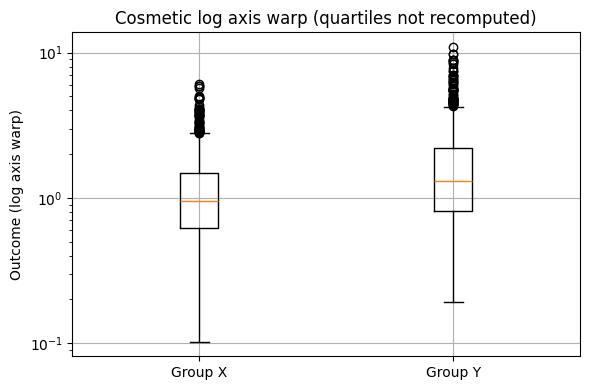

   d_target    n   p_value     d_hat   overlap
0       0.0   20  0.893089 -0.042785  0.707651
1       0.0   50  0.231188 -0.240957  0.589007
2       0.0  100  0.639913 -0.066262  0.853533
3       0.0  200  0.367055 -0.090303  0.839618
4       0.0  500  0.428235 -0.050125  0.968119


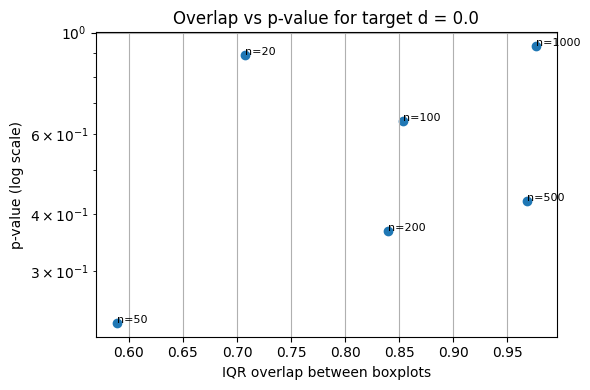

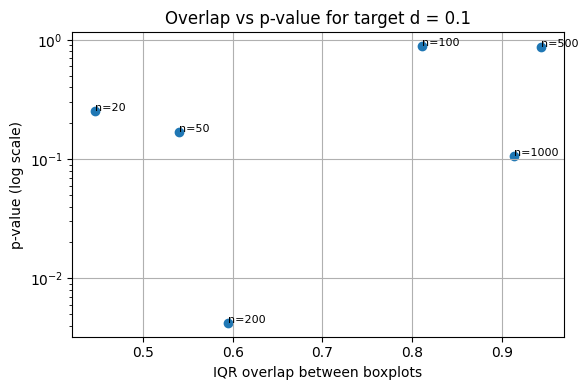

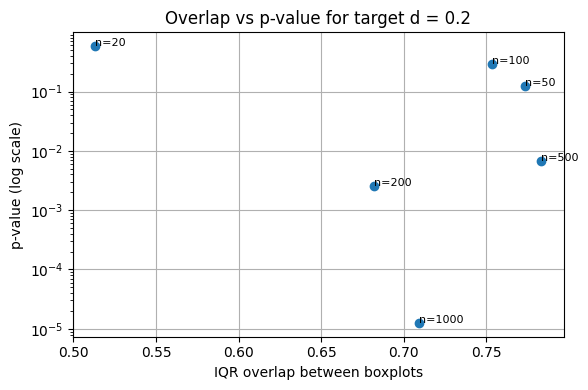

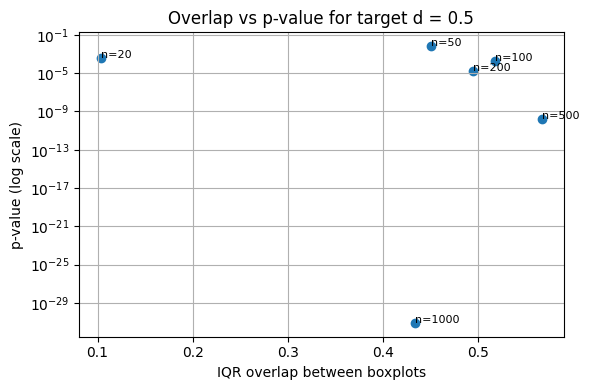

In [ ]:
# --- Setup: imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Make plots a bit nicer by default
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

# --- Utility functions ---

def simulate_two_groups_normal(d=0.2, n=1000, sigma=1.0, seed=0):
    """
    Simulate two normal groups with standardized effect size ~d.
    Returns x, y, p_value, cohens_d.
    """
    rng = np.random.default_rng(seed)
    mu1 = 0.0
    mu2 = d * sigma
    x = rng.normal(mu1, sigma, n)
    y = rng.normal(mu2, sigma, n)

    # t-test
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=True)

    # Cohen's d (pooled SD)
    pooled_sd = np.sqrt(((n - 1) * x.var(ddof=1) +
                         (n - 1) * y.var(ddof=1)) / (2 * n - 2))
    d_hat = (y.mean() - x.mean()) / pooled_sd

    return x, y, p_val, d_hat

def compute_boxplot_overlap(q1_x, q3_x, q1_y, q3_y):
    """
    Compute overlap of IQRs as length(intersection) / length(union).
    """
    left = max(q1_x, q1_y)
    right = min(q3_x, q3_y)
    intersection = max(0.0, right - left)

    union_left = min(q1_x, q1_y)
    union_right = max(q3_x, q3_y)
    union = max(0.0, union_right - union_left)

    if union == 0:
        return 0.0
    return intersection / union

# --- Figure 1: Overlapping boxplots with tiny p-values (normal data) ---

def figure1_overlapping_boxplots():
    d = 0.2          # small effect
    n = 1000         # large sample
    x, y, p_val, d_hat = simulate_two_groups_normal(d=d, n=n, seed=42)

    print(f"Figure 1 example: d_target={d}, n={n} per group")
    print(f"Estimated Cohen's d = {d_hat:.3f}, p-value = {p_val:.2e}")

    data = [x, y]
    labels = ["Group X", "Group Y"]

    fig, ax = plt.subplots()
    ax.boxplot(data, labels=labels, showfliers=True)
    ax.set_title(f"Overlapping boxplots with tiny p-value\n"
                 f"d ≈ {d_hat:.2f}, p = {p_val:.1e}, n = {n} per group")
    ax.set_ylabel("Outcome (raw scale)")
    plt.tight_layout()
    plt.show()

figure1_overlapping_boxplots()

# --- Figure 2: p-value vs sample size for small effect ---

def figure2_p_vs_n():
    d = 0.2
    ns = [20, 50, 100, 200, 500, 1000, 2000]
    p_vals = []
    d_hats = []

    for n in ns:
        _, _, p_val, d_hat = simulate_two_groups_normal(d=d, n=n, seed=123)
        p_vals.append(p_val)
        d_hats.append(d_hat)

    fig, ax1 = plt.subplots()

    ax1.plot(ns, p_vals, marker="o")
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel("Sample size per group (log scale)")
    ax1.set_ylabel("p-value (log scale)")
    ax1.set_title("Tiny p-values can arise from small effects with large n")
    plt.tight_layout()
    plt.show()

    # Optional: show estimated d across n
    fig, ax2 = plt.subplots()
    ax2.plot(ns, d_hats, marker="o")
    ax2.axhline(d, linestyle="--")
    ax2.set_xscale("log")
    ax2.set_xlabel("Sample size per group (log scale)")
    ax2.set_ylabel("Estimated Cohen's d")
    ax2.set_title("Effect size estimate is stable while p shrinks with n")
    plt.tight_layout()
    plt.show()

figure2_p_vs_n()

# --- Log-normal simulations for scale / transformation ---

def simulate_lognormal_groups(mu=0.0, tau=0.5, delta=0.2, n=1000, seed=0):
    """
    Simulate two log-normal groups with a shift delta in log-space.
    Returns z, w (raw), and their logs.
    """
    rng = np.random.default_rng(seed)
    # log-scale means
    mu1 = mu
    mu2 = mu + delta

    # log-normal draws: exp( Normal(mu, tau^2) )
    log_x = rng.normal(mu1, tau, n)
    log_y = rng.normal(mu2, tau, n)
    x = np.exp(log_x)
    y = np.exp(log_y)

    return x, y, log_x, log_y

def figure3_lognormal_boxplots():
    x, y, log_x, log_y = simulate_lognormal_groups(
        mu=0.0, tau=0.7, delta=0.3, n=1000, seed=7
    )

    # t-test on log scale (natural for multiplicative effects)
    t_stat, p_val = stats.ttest_ind(log_x, log_y, equal_var=True)
    pooled_sd = np.sqrt(((len(log_x) - 1) * log_x.var(ddof=1) +
                         (len(log_y) - 1) * log_y.var(ddof=1)) /
                        (len(log_x) + len(log_y) - 2))
    d_hat = (log_y.mean() - log_x.mean()) / pooled_sd

    print(f"Figure 3 (log-normal): p (log-scale t-test) = {p_val:.2e}, "
          f"Cohen's d (log-scale) = {d_hat:.3f}")

    # (a) Boxplots on raw scale
    fig, ax = plt.subplots()
    ax.boxplot([x, y], labels=["Group X", "Group Y"], showfliers=True)
    ax.set_yscale("linear")
    ax.set_ylabel("Outcome (raw scale)")
    ax.set_title("Raw-scale boxplots: heavy overlap, skewed distributions")
    plt.tight_layout()
    plt.show()

    # (b) Boxplots on log-transformed data (recomputed quartiles)
    fig, ax = plt.subplots()
    ax.boxplot([log_x, log_y], labels=["Group X", "Group Y"], showfliers=True)
    ax.set_ylabel("log(outcome)")
    ax.set_title("Boxplots of log-transformed data\n"
                 "Effect more visible on multiplicative (log) scale")
    plt.tight_layout()
    plt.show()

    # (c) Cosmetic log axis warp (NOT recommended)
    fig, ax = plt.subplots()
    ax.boxplot([x, y], labels=["Group X", "Group Y"], showfliers=True)
    ax.set_yscale("log")
    ax.set_ylabel("Outcome (log axis warp)")
    ax.set_title("Cosmetic log axis warp (quartiles not recomputed)")
    plt.tight_layout()
    plt.show()

figure3_lognormal_boxplots()

# --- Grid of overlap vs p-value across (d, n) ---

def figure4_overlap_vs_p():
    ds = [0.0, 0.1, 0.2, 0.5]
    ns = [20, 50, 100, 200, 500, 1000]
    records = []

    rng = np.random.default_rng(123)

    for d in ds:
        for n in ns:
            # use different seeds for variety
            seed = int(rng.integers(0, 1e9))
            x, y, p_val, d_hat = simulate_two_groups_normal(d=d, n=n, seed=seed)

            # quartiles
            q1_x, q3_x = np.percentile(x, [25, 75])
            q1_y, q3_y = np.percentile(y, [25, 75])
            overlap = compute_boxplot_overlap(q1_x, q3_x, q1_y, q3_y)

            records.append({
                "d_target": d,
                "n": n,
                "p_value": p_val,
                "d_hat": d_hat,
                "overlap": overlap
            })

    df = pd.DataFrame.from_records(records)
    print(df.head())

    # One plot per effect size: overlap vs p
    for d in ds:
        sub = df[df["d_target"] == d]
        fig, ax = plt.subplots()
        ax.scatter(sub["overlap"], sub["p_value"])
        for _, row in sub.iterrows():
            ax.text(row["overlap"], row["p_value"], f"n={int(row['n'])}",
                    fontsize=8)

        ax.set_yscale("log")
        ax.set_xlabel("IQR overlap between boxplots")
        ax.set_ylabel("p-value (log scale)")
        ax.set_title(f"Overlap vs p-value for target d = {d}")
        plt.tight_layout()
        plt.show()

figure4_overlap_vs_p()


Scenario 1 (clear separation):
  Estimated d = 1.719
  p-value     = 6.479e-21

Scenario 2 (overlap but small p):
  Estimated d = 0.153
  p-value     = 1.318e-06


/tmp/ipython-input-2675227768.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([x, y],
/tmp/ipython-input-2675227768.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([x, y],


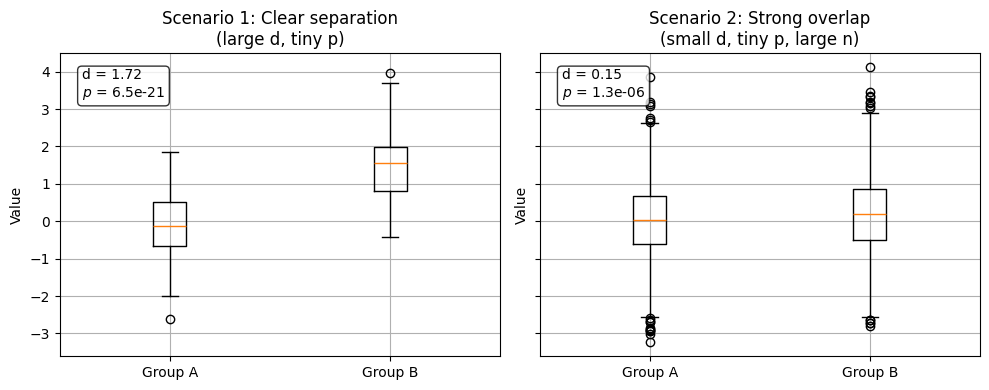

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# For reproducibility
np.random.seed(42)

def simulate_two_groups(d=0.2, n=1000, sigma=1.0):
    """
    Simulate two normal groups with standardized effect size ~= d.
    Returns:
        x, y : arrays
        p_val : p-value from two-sample t-test
        d_hat : estimated Cohen's d
    """
    mu1 = 0.0
    mu2 = d * sigma

    x = np.random.normal(mu1, sigma, n)
    y = np.random.normal(mu2, sigma, n)

    # Two-sample t-test (equal variances)
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=True)

    # Cohen's d (pooled SD)
    n1 = n2 = n
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled

    return x, y, p_val, d_hat

def plot_boxplot_with_stats(ax, x, y, p_val, d_hat, title):
    """
    Plot boxplot of two groups on a given axis and annotate with p and d.
    """
    bp = ax.boxplot([x, y],
                    labels=["Group A", "Group B"],
                    showfliers=True)

    ax.set_title(title)
    ax.set_ylabel("Value")

    # Annotation text (top-left inside the axes)
    textstr = f"d = {d_hat:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# -------- Scenario 1: Clear visual separation, tiny p --------
# Large effect, moderate n
d_large = 1.5
n_large = 80

x_sep, y_sep, p_sep, d_hat_sep = simulate_two_groups(d=d_large, n=n_large)

print("Scenario 1 (clear separation):")
print(f"  Estimated d = {d_hat_sep:.3f}")
print(f"  p-value     = {p_sep:.3e}")

# -------- Scenario 2: Heavy overlap, tiny p --------
# Small effect, very large n
d_small = 0.2
n_very_large = 2000

x_ov, y_ov, p_ov, d_hat_ov = simulate_two_groups(d=d_small, n=n_very_large)

print("\nScenario 2 (overlap but small p):")
print(f"  Estimated d = {d_hat_ov:.3f}")
print(f"  p-value     = {p_ov:.3e}")

# -------- Plot both scenarios side by side --------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

plot_boxplot_with_stats(
    axes[0],
    x_sep,
    y_sep,
    p_sep,
    d_hat_sep,
    title="Scenario 1: Clear separation\n(large d, tiny p)"
)

plot_boxplot_with_stats(
    axes[1],
    x_ov,
    y_ov,
    p_ov,
    d_hat_ov,
    title="Scenario 2: Strong overlap\n(small d, tiny p, large n)"
)

plt.tight_layout()
plt.show()


/tmp/ipython-input-582345351.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-582345351.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-582345351.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-582345351.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],


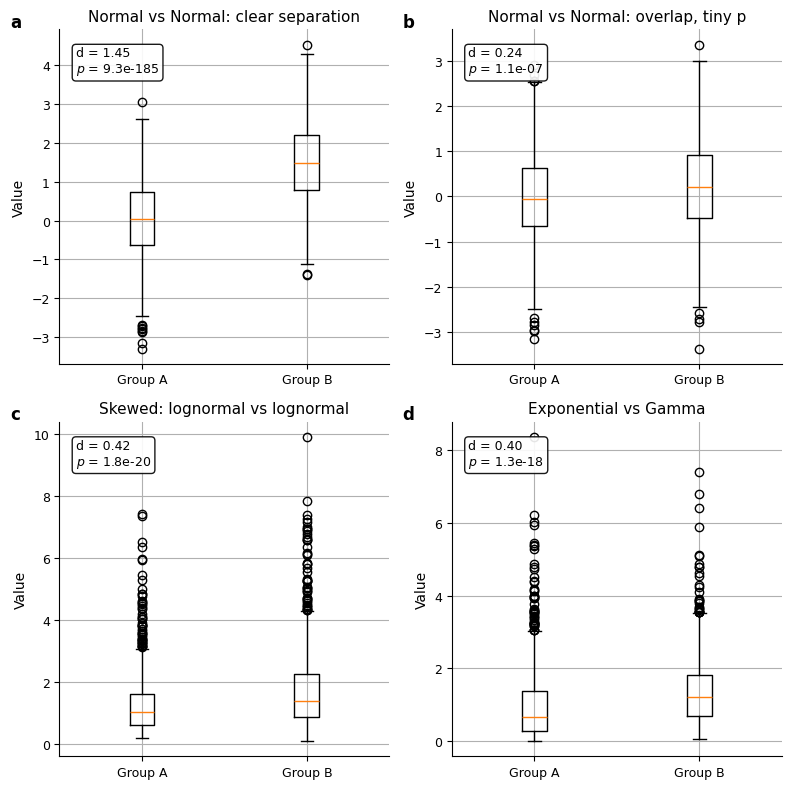

Saved high-quality figure to: boxplot_four_scenarios_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------------
# 1. Distribution sampler
# ---------------------------------------------------------------------
def sample_distribution(dist_name, n, rng=None, **kwargs):
    """
    Generate n samples from a given distribution.

    dist_name: 'normal', 'lognormal', 'exponential', 'gamma', 'uniform'
    kwargs:
      normal   -> loc, scale
      lognormal-> mean, sigma  (parameters in log-space)
      exponential -> scale
      gamma    -> shape, scale
      uniform  -> low, high
    """
    if rng is None:
        rng = np.random.default_rng()

    name = dist_name.lower()

    if name == "normal":
        loc = kwargs.get("loc", 0.0)
        scale = kwargs.get("scale", 1.0)
        return rng.normal(loc=loc, scale=scale, size=n)

    elif name == "lognormal":
        mean = kwargs.get("mean", 0.0)
        sigma = kwargs.get("sigma", 0.7)
        return rng.lognormal(mean=mean, sigma=sigma, size=n)

    elif name == "exponential":
        scale = kwargs.get("scale", 1.0)
        return rng.exponential(scale=scale, size=n)

    elif name == "gamma":
        shape = kwargs.get("shape", 2.0)
        scale = kwargs.get("scale", 1.0)
        return rng.gamma(shape, scale=scale, size=n)

    elif name == "uniform":
        low = kwargs.get("low", 0.0)
        high = kwargs.get("high", 1.0)
        return rng.uniform(low=low, high=high, size=n)

    else:
        raise ValueError(f"Unknown distribution '{dist_name}'")


# ---------------------------------------------------------------------
# 2. Stats helper (Welch t-test + Cohen's d)
# ---------------------------------------------------------------------
def compute_stats(x, y):
    """Return (p-value, Cohen's d) for two 1D samples."""
    # Welch t-test (safer if variances differ)
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)

    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled

    return p_val, d_hat


# ---------------------------------------------------------------------
# 3. Single panel plotter
# ---------------------------------------------------------------------
def plot_panel(ax, x, y, panel_label, title, p_val, d_hat):
    """
    Draw a boxplot of x and y on axis 'ax' with annotation and panel label.
    """
    ax.boxplot([x, y],
               labels=["Group A", "Group B"],
               showfliers=True)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Value", fontsize=10)

    # Panel label (a,b,c,d)
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left")

    # Stats annotation
    textstr = (
        f"d = {d_hat:.2f}\n"
        r"$p$" + f" = {p_val:.1e}"
    )
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="black",
                      alpha=0.9))


# ---------------------------------------------------------------------
# 4. Master function: create 2×2 figure and save at 300 dpi
# ---------------------------------------------------------------------
def make_four_panel_figure(filename="four_boxplots_300dpi.png", seed=123):
    rng = np.random.default_rng(seed)

    # Nice, clean style
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False)

    # -------------------------------------------------------------
    # (a) Normal vs Normal: clear separation (large d, tiny p)
    # -------------------------------------------------------------
    x_a = sample_distribution("normal", 1000, rng=rng, loc=0.0, scale=1.0)
    y_a = sample_distribution("normal", 1000, rng=rng, loc=1.5, scale=1.0)
    p_a, d_a = compute_stats(x_a, y_a)
    plot_panel(
        axes[0, 0],
        x_a,
        y_a,
        panel_label="a",
        title="Normal vs Normal: clear separation",
        p_val=p_a,
        d_hat=d_a,
    )

    # -------------------------------------------------------------
    # (b) Normal vs Normal: strong overlap, tiny p (small d, large n)
    # -------------------------------------------------------------
    x_b = sample_distribution("normal", 1000, rng=rng, loc=0.0, scale=1.0)
    y_b = sample_distribution("normal", 1000, rng=rng, loc=0.2, scale=1.0)
    p_b, d_b = compute_stats(x_b, y_b)
    plot_panel(
        axes[0, 1],
        x_b,
        y_b,
        panel_label="b",
        title="Normal vs Normal: overlap, tiny p",
        p_val=p_b,
        d_hat=d_b,
    )

    # -------------------------------------------------------------
    # (c) Skewed: Lognormal vs Lognormal (multiplicative difference)
    # -------------------------------------------------------------
    x_c = sample_distribution("lognormal", 1000, rng=rng, mean=0.0, sigma=0.7)
    y_c = sample_distribution("lognormal", 1000, rng=rng, mean=0.3, sigma=0.7)
    p_c, d_c = compute_stats(x_c, y_c)
    plot_panel(
        axes[1, 0],
        x_c,
        y_c,
        panel_label="c",
        title="Skewed: lognormal vs lognormal",
        p_val=p_c,
        d_hat=d_c,
    )

    # -------------------------------------------------------------
    # (d) Different families: Exponential vs Gamma
    # -------------------------------------------------------------
    x_d = sample_distribution("exponential", 1000, rng=rng, scale=1.0)
    y_d = sample_distribution("gamma", 1000, rng=rng, shape=2.0, scale=0.7)
    p_d, d_d = compute_stats(x_d, y_d)
    plot_panel(
        axes[1, 1],
        x_d,
        y_d,
        panel_label="d",
        title="Exponential vs Gamma",
        p_val=p_d,
        d_hat=d_d,
    )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved high-quality figure to: {filename}")


# ---------------------------------------------------------------------
# Run once to generate the 4-panel figure
# ---------------------------------------------------------------------
make_four_panel_figure("boxplot_four_scenarios_300dpi.png")


/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],


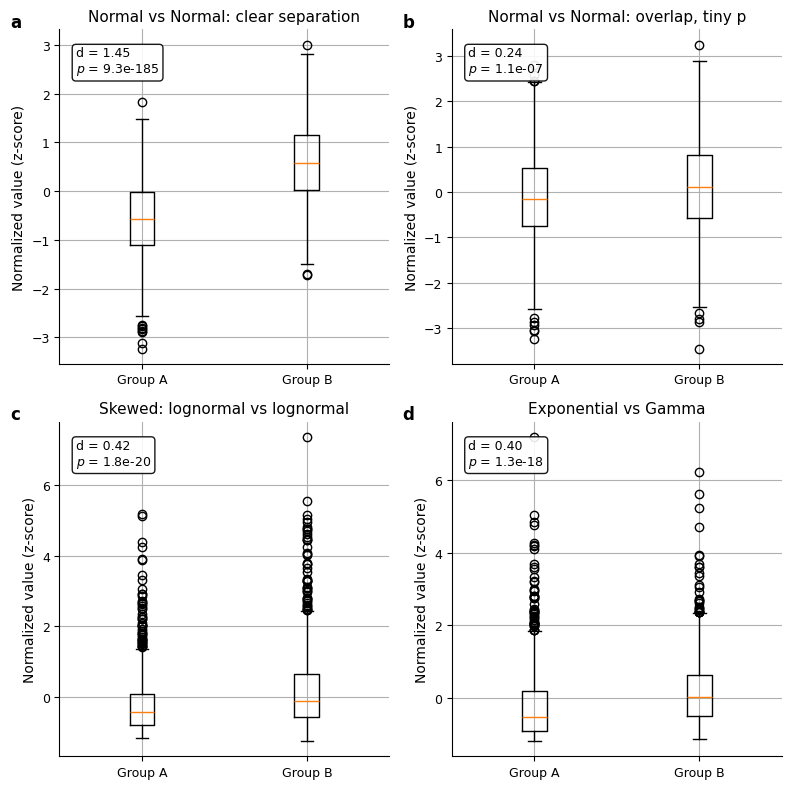

Saved high-quality figure to: boxplot_four_scenarios_normalized_300dpi.png
Skewed lognormal example:
  Raw scale:          d = 0.307, p = 8.981e-12
  Normalized (linear): d = 0.307, p = 8.981e-12
  Log + normalized:    d = 0.352, p = 5.287e-15


/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],
/tmp/ipython-input-590185938.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x, y],


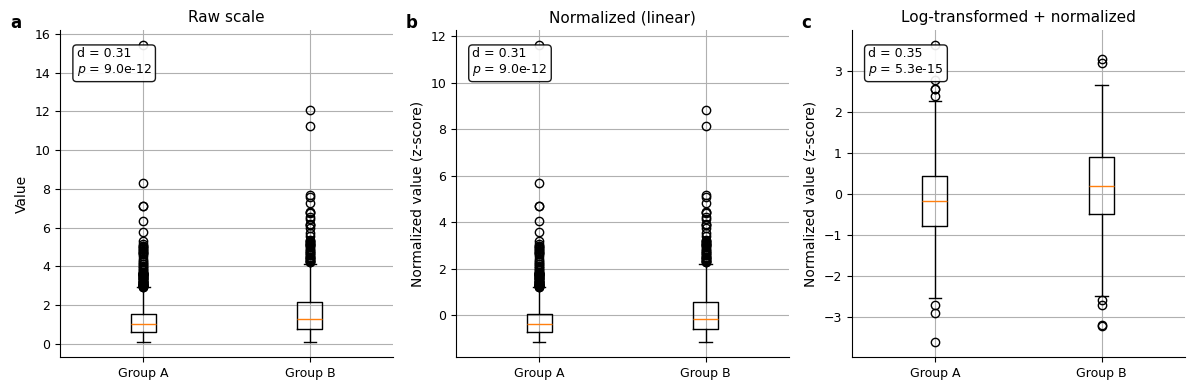

Saved transformation figure to: lognormal_raw_norm_log_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------------
# 1. Distribution sampler
# ---------------------------------------------------------------------
def sample_distribution(dist_name, n, rng=None, **kwargs):
    """
    Generate n samples from a given distribution.

    dist_name: 'normal', 'lognormal', 'exponential', 'gamma', 'uniform'
    kwargs:
      normal    -> loc, scale
      lognormal -> mean, sigma  (parameters in log-space)
      exponential -> scale
      gamma     -> shape, scale
      uniform   -> low, high
    """
    if rng is None:
        rng = np.random.default_rng()

    name = dist_name.lower()

    if name == "normal":
        loc = kwargs.get("loc", 0.0)
        scale = kwargs.get("scale", 1.0)
        return rng.normal(loc=loc, scale=scale, size=n)

    elif name == "lognormal":
        mean = kwargs.get("mean", 0.0)
        sigma = kwargs.get("sigma", 0.7)
        return rng.lognormal(mean=mean, sigma=sigma, size=n)

    elif name == "exponential":
        scale = kwargs.get("scale", 1.0)
        return rng.exponential(scale=scale, size=n)

    elif name == "gamma":
        shape = kwargs.get("shape", 2.0)
        scale = kwargs.get("scale", 1.0)
        return rng.gamma(shape, scale=scale, size=n)

    elif name == "uniform":
        low = kwargs.get("low", 0.0)
        high = kwargs.get("high", 1.0)
        return rng.uniform(low=low, high=high, size=n)

    else:
        raise ValueError(f"Unknown distribution '{dist_name}'")


# ---------------------------------------------------------------------
# 2. Normalization helper
# ---------------------------------------------------------------------
def normalize_groups(x, y, method="zscore"):
    """
    Apply a *global* normalization to both groups together.

    method:
      'zscore' -> subtract global mean, divide by global SD
      'minmax' -> map global min..max to 0..1
    """
    data = np.concatenate([x, y])

    if method == "zscore":
        mu = data.mean()
        sigma = data.std(ddof=1)
        x_n = (x - mu) / sigma
        y_n = (y - mu) / sigma
        ylabel = "Normalized value (z-score)"

    elif method == "minmax":
        mn = data.min()
        mx = data.max()
        span = mx - mn if mx > mn else 1.0
        x_n = (x - mn) / span
        y_n = (y - mn) / span
        ylabel = "Normalized value (min–max)"

    else:
        raise ValueError(f"Unknown normalization method '{method}'")

    return x_n, y_n, ylabel


# ---------------------------------------------------------------------
# 3. Stats helper (Welch t-test + Cohen's d)
# ---------------------------------------------------------------------
def compute_stats(x, y):
    """Return (p-value, Cohen's d) for two 1D samples."""
    # Welch t-test (safer if variances differ)
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)

    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled

    return p_val, d_hat


# ---------------------------------------------------------------------
# 4. Single panel plotter
# ---------------------------------------------------------------------
def plot_panel(ax, x, y, panel_label, title, p_val, d_hat, ylabel):
    """
    Draw a boxplot of x and y on axis 'ax' with annotation and panel label.
    """
    ax.boxplot([x, y],
               labels=["Group A", "Group B"],
               showfliers=True)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)

    # Panel label (a,b,c,d)
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left")

    # Stats annotation
    textstr = (
        f"d = {d_hat:.2f}\n"
        r"$p$" + f" = {p_val:.1e}"
    )
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="black",
                      alpha=0.9))


# ---------------------------------------------------------------------
# 5. Four-panel figure (ALL n = 1000) with normalization
# ---------------------------------------------------------------------
def make_four_panel_figure(filename="boxplot_four_scenarios_300dpi.png",
                           seed=123,
                           norm_method="zscore"):
    rng = np.random.default_rng(seed)

    # Nice, clean style
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False)

    # -------------------------------------------------------------
    # (a) Normal vs Normal: clear separation
    # -------------------------------------------------------------
    x_a_raw = sample_distribution("normal", 1000, rng=rng, loc=0.0, scale=1.0)
    y_a_raw = sample_distribution("normal", 1000, rng=rng, loc=1.5, scale=1.0)
    x_a, y_a, ylabel = normalize_groups(x_a_raw, y_a_raw, method=norm_method)
    p_a, d_a = compute_stats(x_a, y_a)
    plot_panel(
        axes[0, 0],
        x_a,
        y_a,
        panel_label="a",
        title="Normal vs Normal: clear separation",
        p_val=p_a,
        d_hat=d_a,
        ylabel=ylabel,
    )

    # -------------------------------------------------------------
    # (b) Normal vs Normal: overlap, tiny p (small effect)
    # -------------------------------------------------------------
    x_b_raw = sample_distribution("normal", 1000, rng=rng, loc=0.0, scale=1.0)
    y_b_raw = sample_distribution("normal", 1000, rng=rng, loc=0.2, scale=1.0)
    x_b, y_b, _ = normalize_groups(x_b_raw, y_b_raw, method=norm_method)
    p_b, d_b = compute_stats(x_b, y_b)
    plot_panel(
        axes[0, 1],
        x_b,
        y_b,
        panel_label="b",
        title="Normal vs Normal: overlap, tiny p",
        p_val=p_b,
        d_hat=d_b,
        ylabel=ylabel,
    )

    # -------------------------------------------------------------
    # (c) Skewed: Lognormal vs Lognormal
    # -------------------------------------------------------------
    x_c_raw = sample_distribution("lognormal", 1000, rng=rng,
                                  mean=0.0, sigma=0.7)
    y_c_raw = sample_distribution("lognormal", 1000, rng=rng,
                                  mean=0.3, sigma=0.7)
    x_c, y_c, _ = normalize_groups(x_c_raw, y_c_raw, method=norm_method)
    p_c, d_c = compute_stats(x_c, y_c)
    plot_panel(
        axes[1, 0],
        x_c,
        y_c,
        panel_label="c",
        title="Skewed: lognormal vs lognormal",
        p_val=p_c,
        d_hat=d_c,
        ylabel=ylabel,
    )

    # -------------------------------------------------------------
    # (d) Different families: Exponential vs Gamma
    # -------------------------------------------------------------
    x_d_raw = sample_distribution("exponential", 1000, rng=rng, scale=1.0)
    y_d_raw = sample_distribution("gamma", 1000, rng=rng,
                                  shape=2.0, scale=0.7)
    x_d, y_d, _ = normalize_groups(x_d_raw, y_d_raw, method=norm_method)
    p_d, d_d = compute_stats(x_d, y_d)
    plot_panel(
        axes[1, 1],
        x_d,
        y_d,
        panel_label="d",
        title="Exponential vs Gamma",
        p_val=p_d,
        d_hat=d_d,
        ylabel=ylabel,
    )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved high-quality figure to: {filename}")


# ---------------------------------------------------------------------
# 6. Transformation demo for lognormal (raw, normalized, log-normalized)
# ---------------------------------------------------------------------
def make_rescaled_log_figure(filename="lognormal_raw_norm_log_300dpi.png",
                             seed=456,
                             norm_method="zscore"):
    """
    Focus on the skewed lognormal scenario and show:

      - (a) raw scale
      - (b) normalized (global z-score or min–max)
      - (c) log-transformed then normalized

    This demonstrates:
      * Linear normalization (z-score/min–max) preserves d and p.
      * Non-linear log transform can change d and visual separation.
    """
    rng = np.random.default_rng(seed)

    # Raw lognormal groups
    x_raw = sample_distribution("lognormal", 1000, rng=rng,
                                mean=0.0, sigma=0.7)
    y_raw = sample_distribution("lognormal", 1000, rng=rng,
                                mean=0.3, sigma=0.7)

    p_raw, d_raw = compute_stats(x_raw, y_raw)

    # Normalized (linear)
    x_norm, y_norm, ylabel_norm = normalize_groups(
        x_raw, y_raw, method=norm_method
    )
    p_norm, d_norm = compute_stats(x_norm, y_norm)

    # Log-transform (nonlinear) then normalize again
    eps = 1e-9
    x_log = np.log(x_raw + eps)
    y_log = np.log(y_raw + eps)
    x_log_n, y_log_n, ylabel_log = normalize_groups(
        x_log, y_log, method=norm_method
    )
    p_log, d_log = compute_stats(x_log_n, y_log_n)

    print("Skewed lognormal example:")
    print(f"  Raw scale:          d = {d_raw:.3f}, p = {p_raw:.3e}")
    print(f"  Normalized (linear): d = {d_norm:.3f}, p = {p_norm:.3e}")
    print(f"  Log + normalized:    d = {d_log:.3f}, p = {p_log:.3e}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

    # (a) Raw
    plot_panel(
        axes[0],
        x_raw,
        y_raw,
        panel_label="a",
        title="Raw scale",
        p_val=p_raw,
        d_hat=d_raw,
        ylabel="Value",
    )

    # (b) Normalized
    plot_panel(
        axes[1],
        x_norm,
        y_norm,
        panel_label="b",
        title="Normalized (linear)",
        p_val=p_norm,
        d_hat=d_norm,
        ylabel=ylabel_norm,
    )

    # (c) Log + normalized
    plot_panel(
        axes[2],
        x_log_n,
        y_log_n,
        panel_label="c",
        title="Log-transformed + normalized",
        p_val=p_log,
        d_hat=d_log,
        ylabel=ylabel_log,
    )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved transformation figure to: {filename}")


# ---------------------------------------------------------------------
# Run to generate the figures
# ---------------------------------------------------------------------
make_four_panel_figure("boxplot_four_scenarios_normalized_300dpi.png",
                       norm_method="zscore")
make_rescaled_log_figure("lognormal_raw_norm_log_300dpi.png",
                         norm_method="zscore")


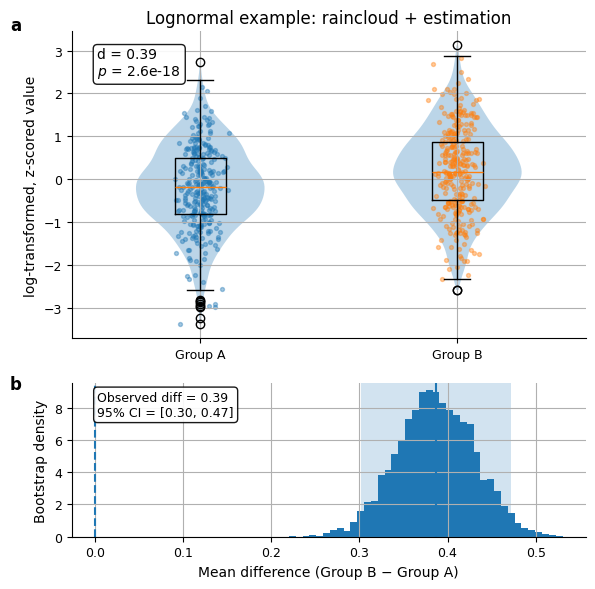

Saved raincloud + estimation figure to: lognormal_raincloud_estimation_300dpi.png
d = 0.394, p = 2.617e-18
Observed mean diff = 0.387, 95% CI [0.301, 0.472]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------
# Helpers: sampling, normalization, stats
# ---------------------------------------------------------
def sample_lognormal_groups(n=1000, mean_A=0.0, mean_B=0.3,
                            sigma=0.7, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.lognormal(mean=mean_A, sigma=sigma, size=n)
    y = rng.lognormal(mean=mean_B, sigma=sigma, size=n)
    return x, y, rng

def zscore_normalize(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def compute_stats(x, y):
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled
    return p_val, d_hat

# ---------------------------------------------------------
# Main: raincloud + estimation figure
# ---------------------------------------------------------
def make_raincloud_estimation_figure(filename="raincloud_estimation_300dpi.png",
                                     n=1000, seed=123,
                                     n_boot=5000, jitter_subsample=300):
    # ----- 1. Simulate lognormal data (raw) -----
    x_raw, y_raw, rng = sample_lognormal_groups(
        n=n, mean_A=0.0, mean_B=0.3, sigma=0.7, seed=seed
    )

    # ----- 2. Log-transform + z-score normalize -----
    eps = 1e-9
    x_log = np.log(x_raw + eps)
    y_log = np.log(y_raw + eps)
    x, y = zscore_normalize(x_log, y_log)

    p_val, d_hat = compute_stats(x, y)

    # ----- 3. Bootstrap distribution of mean difference -----
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        x_s = rng.choice(x, size=len(x), replace=True)
        y_s = rng.choice(y, size=len(y), replace=True)
        diffs[i] = y_s.mean() - x_s.mean()

    obs_diff = y.mean() - x.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

    # ----- 4. Build the figure -----
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1,
        figsize=(6, 6),
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # -------------------------------------------------
    # Top panel: "raincloud" — violin + box + jitter
    # -------------------------------------------------
    positions = [1, 2]

    # Violin (full), then we visually focus on one side with jitter
    ax_top.violinplot(
        [x, y],
        positions=positions,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )

    # Boxplot
    ax_top.boxplot(
        [x, y],
        positions=positions,
        widths=0.2,
        showfliers=True
    )

    # Jittered subsample of points to avoid overplotting
    for pos, data in zip(positions, [x, y]):
        if len(data) > jitter_subsample:
            idx = rng.choice(len(data), size=jitter_subsample, replace=False)
            data_plot = data[idx]
        else:
            data_plot = data

        x_jit = rng.normal(loc=pos, scale=0.04, size=len(data_plot))
        ax_top.scatter(x_jit, data_plot, alpha=0.4, s=8)

    ax_top.set_xticks(positions)
    ax_top.set_xticklabels(["Group A", "Group B"])
    ax_top.set_ylabel("log-transformed, z-scored value")
    ax_top.set_title("Lognormal example: raincloud + estimation")

    # Annotate d and p
    textstr = f"d = {d_hat:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax_top.text(0.05, 0.95, textstr,
                transform=ax_top.transAxes,
                fontsize=10,
                verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="black",
                          alpha=0.9))

    # Panel label
    ax_top.text(-0.12, 1.05, "a",
                transform=ax_top.transAxes,
                fontsize=12,
                fontweight="bold",
                va="top", ha="left")

    # -------------------------------------------------
    # Bottom panel: estimation plot (bootstrap diff)
    # -------------------------------------------------
    ax_bottom.hist(diffs, bins=40, density=True)
    ax_bottom.axvspan(ci_low, ci_high, alpha=0.2)
    ax_bottom.axvline(0.0, linestyle="--")
    ax_bottom.axvline(obs_diff)

    ax_bottom.set_xlabel("Mean difference (Group B − Group A)")
    ax_bottom.set_ylabel("Bootstrap density")

    text_ci = (f"Observed diff = {obs_diff:.2f}\n"
               f"95% CI = [{ci_low:.2f}, {ci_high:.2f}]")
    ax_bottom.text(0.05, 0.95, text_ci,
                   transform=ax_bottom.transAxes,
                   fontsize=9,
                   verticalalignment="top",
                   bbox=dict(boxstyle="round,pad=0.3",
                             facecolor="white",
                             edgecolor="black",
                             alpha=0.9))

    ax_bottom.text(-0.12, 1.05, "b",
                   transform=ax_bottom.transAxes,
                   fontsize=12,
                   fontweight="bold",
                   va="top", ha="left")

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved raincloud + estimation figure to: {filename}")
    print(f"d = {d_hat:.3f}, p = {p_val:.3e}")
    print(f"Observed mean diff = {obs_diff:.3f}, "
          f"95% CI [{ci_low:.3f}, {ci_high:.3f}]")


# ---------------------------------------------------------
# Run once to generate the figure
# ---------------------------------------------------------
make_raincloud_estimation_figure("lognormal_raincloud_estimation_300dpi.png")


Progression a–e:
a) Raw:                d = 0.383, p = 2.191e-17
b) Normalized (z):     d = 0.383, p = 2.191e-17
c) Log + z-score:      d = 0.394, p = 2.617e-18
d) Box–Cox (λ=0.03) + z: d = 0.395, p = 2.152e-18
e) Log + z, centred A: d = 0.394, p = 2.617e-18


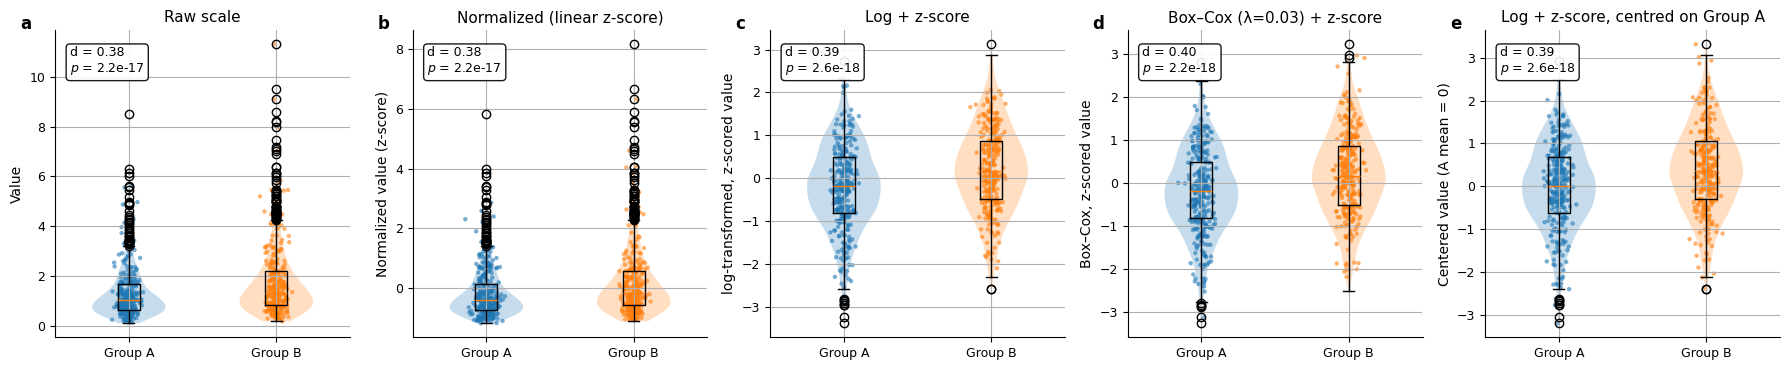

Saved 5-panel progression figure to: progress_a_to_e_raincloud_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import boxcox

# ---------------------------------------------------------
# 1. Helpers: sampling, normalization, stats
# ---------------------------------------------------------
def sample_lognormal_groups(n=1000, mean_A=0.0, mean_B=0.3,
                            sigma=0.7, seed=0):
    """Simulate two skewed lognormal groups (A,B)."""
    rng = np.random.default_rng(seed)
    x = rng.lognormal(mean=mean_A, sigma=sigma, size=n)  # Group A
    y = rng.lognormal(mean=mean_B, sigma=sigma, size=n)  # Group B
    return x, y, rng

def zscore_normalize(x, y):
    """Global z-score normalization (linear; does not change d or p)."""
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def compute_stats(x, y):
    """Welch t-test + Cohen's d."""
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled
    return p_val, d_hat

# ---------------------------------------------------------
# 2. Raincloud panel (violin + box + jitter)
# ---------------------------------------------------------
def make_raincloud(ax, x, y, panel_label, title,
                   p_val, d_hat, rng,
                   ylabel="Value",
                   color_A="#1f77b4", color_B="#ff7f0e",
                   jitter_subsample=300):
    """
    Draw a 'raincloud' plot: violin + box + jittered points with stats.
    """
    positions = [1, 2]

    # Violin (full), but semi-transparent
    vp = ax.violinplot(
        [x, y],
        positions=positions,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )
    vp['bodies'][0].set_facecolor(color_A)
    vp['bodies'][0].set_alpha(0.25)
    vp['bodies'][1].set_facecolor(color_B)
    vp['bodies'][1].set_alpha(0.25)

    # Boxplots
    ax.boxplot(
        [x, y],
        positions=positions,
        widths=0.15,
        showfliers=True
    )

    # Jittered subsample (to avoid overplotting with n=1000)
    for pos, data, col in zip(positions, [x, y], [color_A, color_B]):
        if len(data) > jitter_subsample:
            idx = rng.choice(len(data), size=jitter_subsample, replace=False)
            data_plot = data[idx]
        else:
            data_plot = data
        x_jit = rng.normal(loc=pos, scale=0.04, size=len(data_plot))
        ax.scatter(x_jit, data_plot,
                   alpha=0.6, s=10,
                   color=col, edgecolors="none")

    ax.set_xticks(positions)
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)

    # Stats annotation
    textstr = f"d = {d_hat:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="black",
                      alpha=0.9))

    # Panel label (a–e)
    ax.text(-0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left")


# ---------------------------------------------------------
# 3. Master figure: a–e progression
# ---------------------------------------------------------
def make_full_progress_figure(
        filename="progress_a_to_e_raincloud_300dpi.png",
        n=1000, seed=123, jitter_subsample=300
    ):
    # style
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    # simulate raw data
    x_raw, y_raw, rng = sample_lognormal_groups(
        n=n, mean_A=0.0, mean_B=0.3, sigma=0.7, seed=seed
    )

    # (a) raw scale
    p_raw, d_raw = compute_stats(x_raw, y_raw)

    # (b) normalized (linear z-score)
    x_norm, y_norm = zscore_normalize(x_raw, y_raw)
    p_norm, d_norm = compute_stats(x_norm, y_norm)  # same as raw

    # (c) log + z-score
    eps = 1e-9
    x_log = np.log(x_raw + eps)
    y_log = np.log(y_raw + eps)
    x_log_z, y_log_z = zscore_normalize(x_log, y_log)
    p_log, d_log = compute_stats(x_log_z, y_log_z)

    # (d) Box–Cox + z-score (variance-stabilising transform)
    pooled = np.concatenate([x_raw + eps, y_raw + eps])
    pooled_bc, lam = boxcox(pooled)   # fitted lambda
    x_bc = pooled_bc[:n]
    y_bc = pooled_bc[n:]
    x_bc_z, y_bc_z = zscore_normalize(x_bc, y_bc)
    p_bc, d_bc = compute_stats(x_bc_z, y_bc_z)

    # (e) log + z-score, centred on Group A mean
    x_c = x_log_z - x_log_z.mean()    # centre A at 0
    y_c = y_log_z - x_log_z.mean()
    p_c, d_c = compute_stats(x_c, y_c)  # same as p_log, d_log

    print("Progression a–e:")
    print(f"a) Raw:                d = {d_raw:.3f}, p = {p_raw:.3e}")
    print(f"b) Normalized (z):     d = {d_norm:.3f}, p = {p_norm:.3e}")
    print(f"c) Log + z-score:      d = {d_log:.3f}, p = {p_log:.3e}")
    print(f"d) Box–Cox (λ={lam:.2f}) + z: d = {d_bc:.3f}, p = {p_bc:.3e}")
    print(f"e) Log + z, centred A: d = {d_c:.3f}, p = {p_c:.3e}")

    # build 1×5 figure
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=False)

    # a) raw
    make_raincloud(
        axes[0], x_raw, y_raw,
        panel_label="a",
        title="Raw scale",
        p_val=p_raw,
        d_hat=d_raw,
        rng=rng,
        ylabel="Value",
        jitter_subsample=jitter_subsample
    )

    # b) normalized
    make_raincloud(
        axes[1], x_norm, y_norm,
        panel_label="b",
        title="Normalized (linear z-score)",
        p_val=p_norm,
        d_hat=d_norm,
        rng=rng,
        ylabel="Normalized value (z-score)",
        jitter_subsample=jitter_subsample
    )

    # c) log + z
    make_raincloud(
        axes[2], x_log_z, y_log_z,
        panel_label="c",
        title="Log + z-score",
        p_val=p_log,
        d_hat=d_log,
        rng=rng,
        ylabel="log-transformed, z-scored value",
        jitter_subsample=jitter_subsample
    )

    # d) Box–Cox + z
    make_raincloud(
        axes[3], x_bc_z, y_bc_z,
        panel_label="d",
        title=f"Box–Cox (λ={lam:.2f}) + z-score",
        p_val=p_bc,
        d_hat=d_bc,
        rng=rng,
        ylabel="Box–Cox, z-scored value",
        jitter_subsample=jitter_subsample
    )

    # e) log + z, centred on A
    make_raincloud(
        axes[4], x_c, y_c,
        panel_label="e",
        title="Log + z-score, centred on Group A",
        p_val=p_c,
        d_hat=d_c,
        rng=rng,
        ylabel="Centered value (A mean = 0)",
        jitter_subsample=jitter_subsample
    )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved 5-panel progression figure to: {filename}")


# ---------------------------------------------------------
# Run once to generate the a–e figure
# ---------------------------------------------------------
make_full_progress_figure()


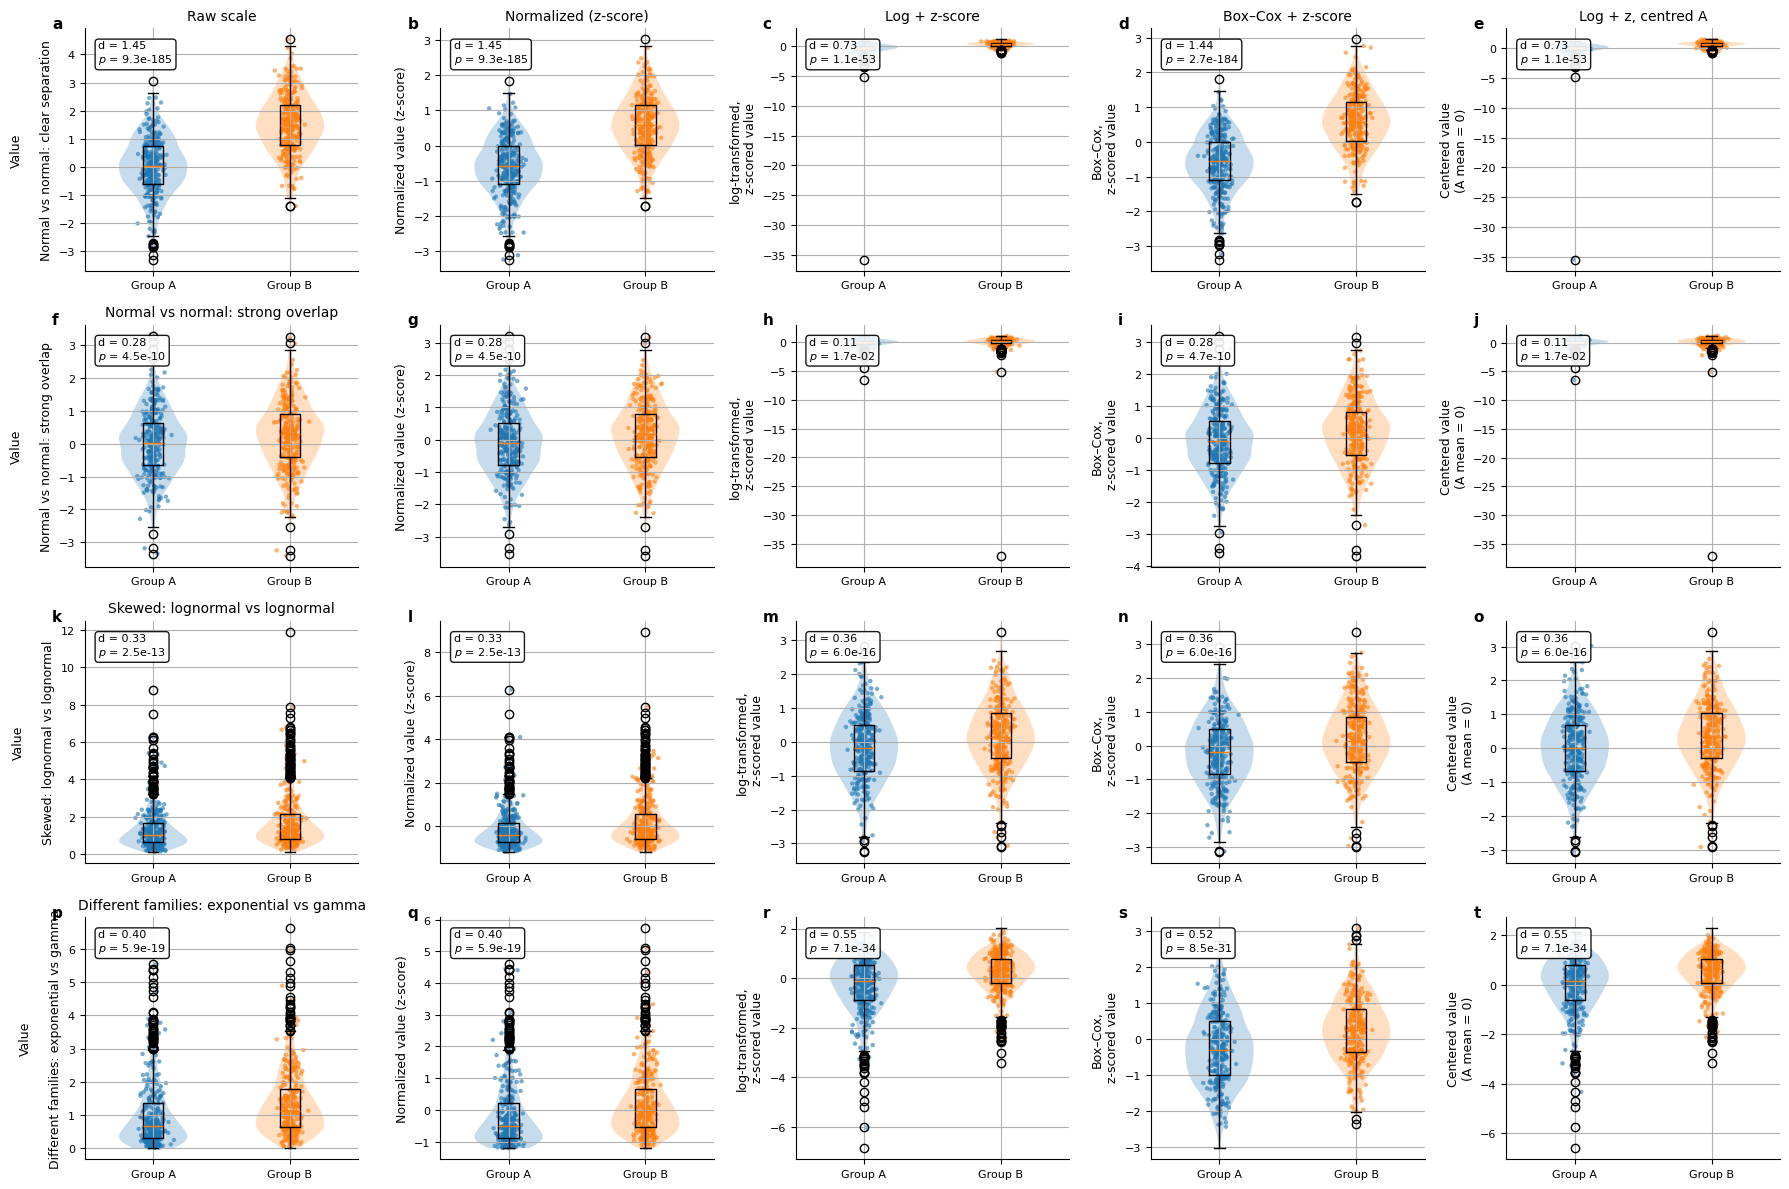

Saved 4×5 progression matrix to: matrix_4x5_progress_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import boxcox

# ---------------------------------------------------------
# 1. Scenario generators (n = 1000 by default)
# ---------------------------------------------------------
def scen_normal_clear(rng, n=1000):
    # Clear separation: means far apart
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n=1000):
    # Strong overlap: small effect size
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n=1000):
    # Skewed: lognormal vs lognormal
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n=1000):
    # Different families: exponential vs gamma
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# ---------------------------------------------------------
# 2. Utility functions
# ---------------------------------------------------------
def zscore_normalize(x, y):
    """Global z-score normalization."""
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def compute_stats(x, y):
    """Welch t-test + Cohen's d."""
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled
    return p_val, d_hat

def make_raincloud(ax, x, y, panel_label, title,
                   p_val, d_hat, rng,
                   ylabel="Value",
                   color_A="#1f77b4", color_B="#ff7f0e",
                   jitter_subsample=300):
    """
    Violin + box + jittered points, annotated with d and p.
    """
    positions = [1, 2]

    # Violin
    vp = ax.violinplot(
        [x, y],
        positions=positions,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )
    vp['bodies'][0].set_facecolor(color_A)
    vp['bodies'][0].set_alpha(0.25)
    vp['bodies'][1].set_facecolor(color_B)
    vp['bodies'][1].set_alpha(0.25)

    # Boxplots
    ax.boxplot(
        [x, y],
        positions=positions,
        widths=0.15,
        showfliers=True
    )

    # Jittered subsample
    for pos, data, col in zip(positions, [x, y], [color_A, color_B]):
        if len(data) > jitter_subsample:
            idx = rng.choice(len(data), size=jitter_subsample, replace=False)
            data_plot = data[idx]
        else:
            data_plot = data
        x_jit = rng.normal(loc=pos, scale=0.04, size=len(data_plot))
        ax.scatter(x_jit, data_plot,
                   alpha=0.6, s=10,
                   color=col, edgecolors="none")

    ax.set_xticks(positions)
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)

    # Stats annotation
    textstr = f"d = {d_hat:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="black",
                      alpha=0.9))

    # Panel label
    ax.text(-0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top", ha="left")

# ---------------------------------------------------------
# 3. Transformation pipeline for one scenario
# ---------------------------------------------------------
def get_transforms_for_scenario(x_raw, y_raw):
    """
    Given raw samples (x_raw, y_raw), return:
    [ (x_raw, y_raw),
      (x_norm, y_norm),
      (x_log_z, y_log_z),
      (x_bc_z,  y_bc_z),
      (x_cent,  y_cent) ],
    plus the Box–Cox lambda used.
    """
    results = []

    # (1) Raw
    results.append((x_raw, y_raw))

    # (2) Normalized (z-score)
    x_norm, y_norm = zscore_normalize(x_raw, y_raw)
    results.append((x_norm, y_norm))

    # Ensure positivity for log/Box–Cox by shifting if needed
    eps = 1e-9
    data = np.concatenate([x_raw, y_raw])
    shift = 0.0
    if np.min(data) <= 0:
        shift = -np.min(data) + eps
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # (3) Log + z-score
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    x_log_z, y_log_z = zscore_normalize(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # (4) Box–Cox + z-score
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)  # λ fitted from pooled data
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]
    x_bc_z, y_bc_z = zscore_normalize(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # (5) Log + z-score, centred on Group A mean
    x_cent = x_log_z - x_log_z.mean()
    y_cent = y_log_z - x_log_z.mean()
    results.append((x_cent, y_cent))

    return results, lam

# ---------------------------------------------------------
# 4. 4×5 master figure
# ---------------------------------------------------------
def make_4x5_progress_matrix(
        filename="matrix_4x5_progress_300dpi.png",
        n=1000, seed=123, jitter_subsample=300
    ):
    # Global style
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 9
    plt.rcParams["xtick.labelsize"] = 8
    plt.rcParams["ytick.labelsize"] = 8

    rng = np.random.default_rng(seed)

    scenarios = [
        ("Normal vs normal: clear separation",   scen_normal_clear),
        ("Normal vs normal: strong overlap",    scen_normal_overlap),
        ("Skewed: lognormal vs lognormal",      scen_lognormal),
        ("Different families: exponential vs gamma", scen_exponential_gamma),
    ]

    col_titles = [
        "Raw scale",
        "Normalized (z-score)",
        "Log + z-score",
        "Box–Cox + z-score",
        "Log + z, centred A",
    ]

    ylabels = [
        "Value",
        "Normalized value (z-score)",
        "log-transformed,\n z-scored value",
        "Box–Cox,\n z-scored value",
        "Centered value\n(A mean = 0)",
    ]

    fig, axes = plt.subplots(4, 5, figsize=(18, 12), sharey=False)

    panel_idx = 0
    for row, (scenario_name, scen_fun) in enumerate(scenarios):
        # Generate raw samples for this scenario
        x_raw, y_raw = scen_fun(rng, n=n)
        transformed_list, lam = get_transforms_for_scenario(x_raw, y_raw)

        for col in range(5):
            ax = axes[row, col]
            x_t, y_t = transformed_list[col]

            p_val, d_hat = compute_stats(x_t, y_t)

            # Panel label a–t
            panel_label = chr(ord("a") + panel_idx)
            panel_idx += 1

            # Titles: top row → transformation names
            if row == 0:
                title = col_titles[col]
            else:
                title = scenario_name if col == 0 else ""

            # y-axis labels: scenario name on first column + metric
            if col == 0:
                ylabel = f"{ylabels[col]}\n\n{scenario_name}"
            else:
                ylabel = ylabels[col]

            make_raincloud(
                ax,
                x_t, y_t,
                panel_label=panel_label,
                title=title,
                p_val=p_val,
                d_hat=d_hat,
                rng=rng,
                ylabel=ylabel,
                jitter_subsample=jitter_subsample
            )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved 4×5 progression matrix to: {filename}")

# ---------------------------------------------------------
# Run once to generate the 4×5 figure
# ---------------------------------------------------------
make_4x5_progress_matrix()


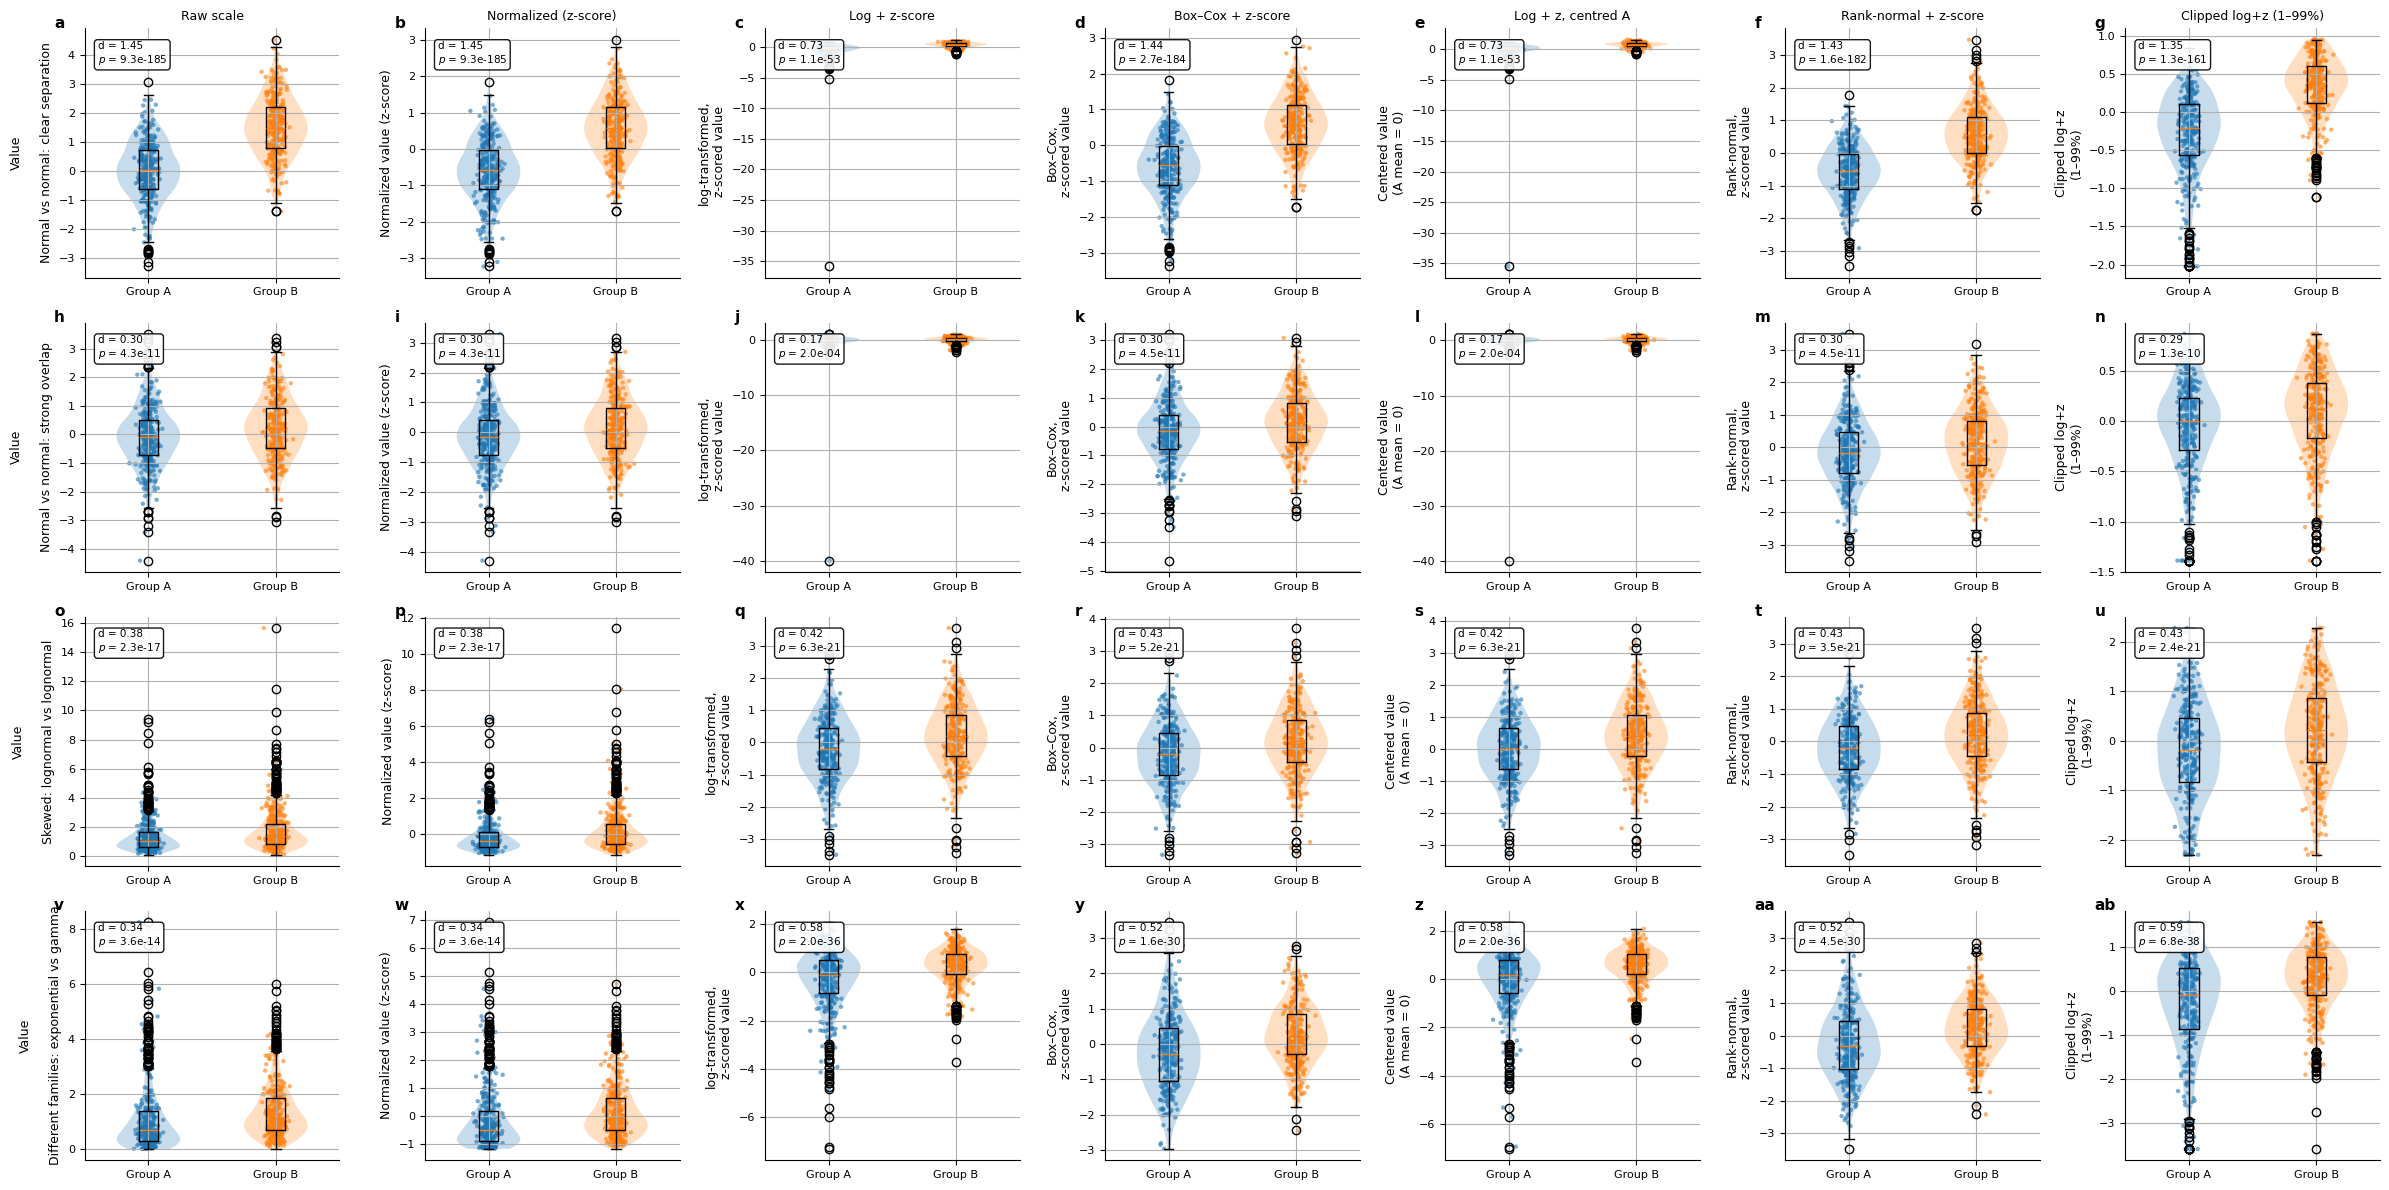

Saved 4×7 progression matrix to: matrix_4x7_progress_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import boxcox, rankdata, norm

# ---------------------------------------------------------
# 1. Scenario generators (n = 1000 by default)
# ---------------------------------------------------------
def scen_normal_clear(rng, n=1000):
    # Clear separation: means far apart
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n=1000):
    # Strong overlap: small effect size
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n=1000):
    # Skewed: lognormal vs lognormal
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n=1000):
    # Different families: exponential vs gamma
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# ---------------------------------------------------------
# 2. Utility functions
# ---------------------------------------------------------
def zscore_normalize(x, y):
    """Global z-score normalization."""
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def compute_stats(x, y):
    """Welch t-test + Cohen's d."""
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    d_hat = (y.mean() - x.mean()) / s_pooled
    return p_val, d_hat

def make_raincloud(ax, x, y, panel_label, title,
                   p_val, d_hat, rng,
                   ylabel="Value",
                   color_A="#1f77b4", color_B="#ff7f0e",
                   jitter_subsample=300):
    """
    Violin + box + jittered points, annotated with d and p.
    """
    positions = [1, 2]

    # Violin
    vp = ax.violinplot(
        [x, y],
        positions=positions,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )
    vp['bodies'][0].set_facecolor(color_A)
    vp['bodies'][0].set_alpha(0.25)
    vp['bodies'][1].set_facecolor(color_B)
    vp['bodies'][1].set_alpha(0.25)

    # Boxplots
    ax.boxplot(
        [x, y],
        positions=positions,
        widths=0.15,
        showfliers=True
    )

    # Jittered subsample
    for pos, data, col in zip(positions, [x, y], [color_A, color_B]):
        if len(data) > jitter_subsample:
            idx = rng.choice(len(data), size=jitter_subsample, replace=False)
            data_plot = data[idx]
        else:
            data_plot = data
        x_jit = rng.normal(loc=pos, scale=0.04, size=len(data_plot))
        ax.scatter(x_jit, data_plot,
                   alpha=0.6, s=10,
                   color=col, edgecolors="none")

    ax.set_xticks(positions)
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)

    # Stats annotation
    textstr = f"d = {d_hat:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=7.5,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="black",
                      alpha=0.9))

    # Panel label
    ax.text(-0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top", ha="left")

# ---------------------------------------------------------
# 3. Transformation pipeline for one scenario (7 transforms)
# ---------------------------------------------------------
def get_transforms_for_scenario(x_raw, y_raw):
    """
    Given raw samples (x_raw, y_raw), return list of 7 transformed
    pairs (x_t, y_t), plus Box–Cox lambda used.
    Order of transforms:
      0: raw
      1: z-score
      2: log + z-score
      3: Box–Cox + z-score
      4: log + z, centred on A
      5: rank-normal + z-score
      6: clipped log+z (1–99%)   (winsorized)
    """
    results = []

    # (0) Raw
    results.append((x_raw, y_raw))

    # (1) Normalized (z-score)
    x_norm, y_norm = zscore_normalize(x_raw, y_raw)
    results.append((x_norm, y_norm))

    # Ensure positivity for log/Box–Cox by shifting if needed
    eps = 1e-9
    data = np.concatenate([x_raw, y_raw])
    shift = 0.0
    if np.min(data) <= 0:
        shift = -np.min(data) + eps
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # (2) Log + z-score
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    x_log_z, y_log_z = zscore_normalize(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # (3) Box–Cox + z-score
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)  # λ fitted from pooled data
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]
    x_bc_z, y_bc_z = zscore_normalize(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # (4) Log + z-score, centred on Group A mean
    x_cent = x_log_z - x_log_z.mean()
    y_cent = y_log_z - x_log_z.mean()
    results.append((x_cent, y_cent))

    # (5) Rank-normal + z-score (inverse-normal)
    pooled = np.concatenate([x_raw, y_raw])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)          # uniform(0,1)
    pooled_rn = norm.ppf(u)                  # normal scores
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]
    x_rn_z, y_rn_z = zscore_normalize(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # (6) Clipped log+z (1–99% winsorized)
    pooled_lz = np.concatenate([x_log_z, y_log_z])
    lo, hi = np.percentile(pooled_lz, [1, 99])
    x_clip = np.clip(x_log_z, lo, hi)
    y_clip = np.clip(y_log_z, lo, hi)
    results.append((x_clip, y_clip))

    return results, lam

# ---------------------------------------------------------
# 4. 4×7 master figure
# ---------------------------------------------------------
def make_4x7_progress_matrix(
        filename="matrix_4x7_progress_300dpi.png",
        n=1000, seed=123, jitter_subsample=300
    ):
    # Global style
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 9
    plt.rcParams["xtick.labelsize"] = 8
    plt.rcParams["ytick.labelsize"] = 8

    rng = np.random.default_rng(seed)

    scenarios = [
        ("Normal vs normal: clear separation",   scen_normal_clear),
        ("Normal vs normal: strong overlap",    scen_normal_overlap),
        ("Skewed: lognormal vs lognormal",      scen_lognormal),
        ("Different families: exponential vs gamma", scen_exponential_gamma),
    ]

    col_titles = [
        "Raw scale",
        "Normalized (z-score)",
        "Log + z-score",
        "Box–Cox + z-score",
        "Log + z, centred A",
        "Rank-normal + z-score",
        "Clipped log+z (1–99%)",
    ]

    ylabels = [
        "Value",
        "Normalized value (z-score)",
        "log-transformed,\n z-scored value",
        "Box–Cox,\n z-scored value",
        "Centered value\n(A mean = 0)",
        "Rank-normal,\n z-scored value",
        "Clipped log+z\n(1–99%)",
    ]

    # Panel labels: a–z, then aa, ab
    panel_labels = [chr(ord("a") + i) for i in range(26)] + ["aa", "ab"]

    fig, axes = plt.subplots(4, 7, figsize=(24, 12), sharey=False)

    panel_idx = 0
    for row, (scenario_name, scen_fun) in enumerate(scenarios):
        # Generate raw samples for this scenario
        x_raw, y_raw = scen_fun(rng, n=n)
        transformed_list, lam = get_transforms_for_scenario(x_raw, y_raw)

        for col in range(7):
            ax = axes[row, col]
            x_t, y_t = transformed_list[col]

            p_val, d_hat = compute_stats(x_t, y_t)

            label = panel_labels[panel_idx]
            panel_idx += 1

            # Titles: top row -> transformation names
            if row == 0:
                title = col_titles[col]
            else:
                title = ""

            # y-axis labels: first column gets scenario name + metric
            if col == 0:
                ylabel = f"{ylabels[col]}\n\n{scenario_name}"
            else:
                ylabel = ylabels[col]

            make_raincloud(
                ax,
                x_t, y_t,
                panel_label=label,
                title=title,
                p_val=p_val,
                d_hat=d_hat,
                rng=rng,
                ylabel=ylabel,
                jitter_subsample=jitter_subsample
            )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved 4×7 progression matrix to: {filename}")

# ---------------------------------------------------------
# Run once to generate the 4×7 figure
# ---------------------------------------------------------
make_4x7_progress_matrix()


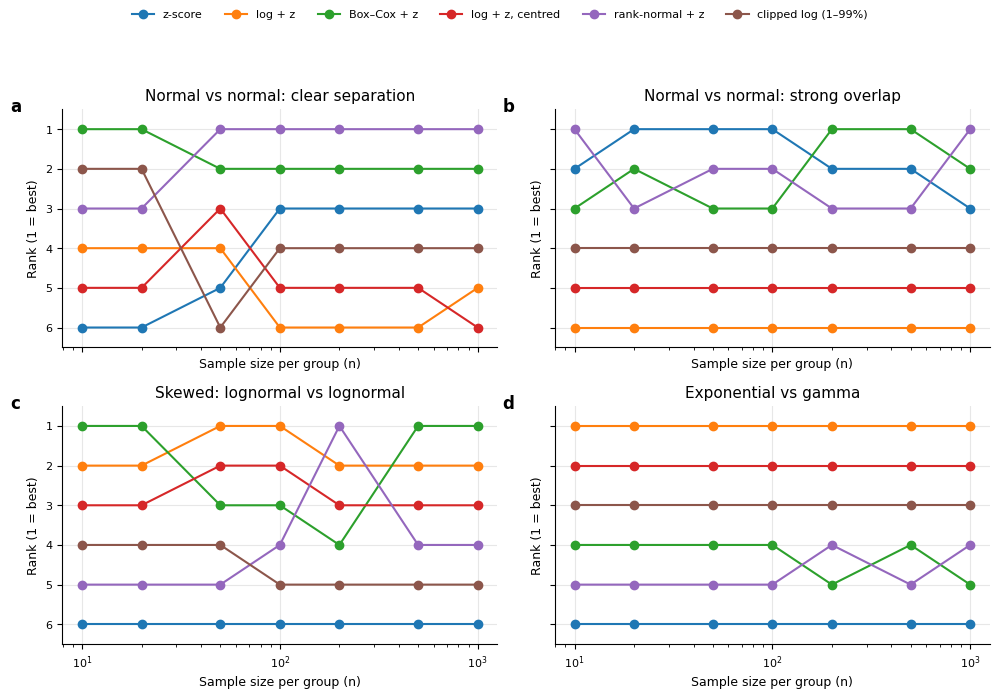

Saved rank-vs-n matrix to: fig_rank_vs_n_4scenarios_300dpi.png


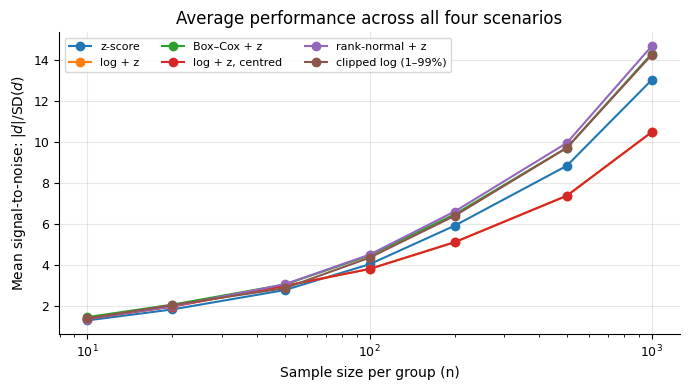

Saved overall SNR summary to: fig_overall_snr_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size: Cohen's d
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# =========================================================
# 3. Transformations
# =========================================================
def zscore_normalize(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def apply_all_transforms(x_raw, y_raw):
    """
    Return list of (x_t, y_t) for the 6 transforms:
      0: z-score
      1: log + z-score
      2: Box–Cox + z-score
      3: log + z-score, centred on Group A
      4: rank-normal + z-score
      5: clipped log+z (1–99%)
    """
    results = []

    # ---- 0) z-score ----
    x_z, y_z = zscore_normalize(x_raw, y_raw)
    results.append((x_z, y_z))

    # Ensure positivity for log / Box–Cox
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])
    shift = 0.0
    if pooled_raw.min() <= 0:
        shift = -pooled_raw.min() + eps
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # ---- 1) log + z-score ----
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    x_log_z, y_log_z = zscore_normalize(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # ---- 2) Box–Cox + z-score ----
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)  # λ estimated from pooled data
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]
    x_bc_z, y_bc_z = zscore_normalize(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # ---- 3) log + z-score, centred on Group A mean ----
    x_cent = x_log_z - x_log_z.mean()
    y_cent = y_log_z - x_log_z.mean()
    results.append((x_cent, y_cent))

    # ---- 4) rank-normal + z-score ----
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]
    x_rn_z, y_rn_z = zscore_normalize(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # ---- 5) clipped log+z (1–99%) ----
    pooled_lz = np.concatenate([x_log_z, y_log_z])
    lo, hi = np.percentile(pooled_lz, [1, 99])
    x_clip = np.clip(x_log_z, lo, hi)
    y_clip = np.clip(y_log_z, lo, hi)
    results.append((x_clip, y_clip))

    return results

transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "log + z, centred",
    "rank-normal + z",
    "clipped log (1–99%)",
]
n_transforms = len(transform_labels)

# =========================================================
# 4. Simulate SNR grid for one scenario
# =========================================================
def simulate_snr_grid(scen_fun, ns, n_rep=500, seed=123):
    """
    For a given scenario, compute SNR = |mean d| / SD(d)
    for each transformation × sample size.
    Returns:
      snr : array shape (n_transforms, len(ns))
    """
    rng = np.random.default_rng(seed)
    mean_d = np.zeros((n_transforms, len(ns)))
    sd_d   = np.zeros((n_transforms, len(ns)))

    for j, n in enumerate(ns):
        d_lists = [[] for _ in range(n_transforms)]
        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            transformed_pairs = apply_all_transforms(x_raw, y_raw)
            for k, (xt, yt) in enumerate(transformed_pairs):
                d_lists[k].append(cohen_d(xt, yt))
        for k in range(n_transforms):
            ds = np.asarray(d_lists[k])
            mean_d[k, j] = ds.mean()
            sd_d[k, j]   = ds.std(ddof=1)

    snr = np.abs(mean_d) / sd_d
    return snr

# =========================================================
# 5A. Figure 1 – Rank vs n for each scenario (2×2)
# =========================================================
def make_rank_vs_n_matrix(
        filename="fig_rank_vs_n_4scenarios_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=500, seed=123
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 9
    plt.rcParams["xtick.labelsize"] = 8
    plt.rcParams["ytick.labelsize"] = 8

    scenarios = [
        ("Normal vs normal: clear separation",   scen_normal_clear),
        ("Normal vs normal: strong overlap",    scen_normal_overlap),
        ("Skewed: lognormal vs lognormal",      scen_lognormal),
        ("Exponential vs gamma",                scen_exponential_gamma),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, (label, scen_fun), letter in zip(axes, scenarios, letters):
        snr = simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed)

        # Rank transformations for each n (1 = best SNR)
        # argsort gives 0 = smallest, so we invert
        ranks = np.zeros_like(snr)
        for j in range(len(ns)):
            order = np.argsort(-snr[:, j])  # descending SNR
            rank_values = np.empty(n_transforms, dtype=int)
            rank_values[order] = np.arange(1, n_transforms + 1)
            ranks[:, j] = rank_values

        for k in range(n_transforms):
            ax.plot(
                ns,
                ranks[k, :],
                marker="o",
                linestyle="-",
                color=color_cycle[k % len(color_cycle)],
                label=transform_labels[k],
            )

        ax.set_xscale("log")
        ax.set_ylim(0.5, n_transforms + 0.5)
        ax.set_yticks(range(1, n_transforms + 1))
        ax.invert_yaxis()  # rank 1 at the top
        ax.set_xlabel("Sample size per group (n)")
        ax.set_ylabel("Rank (1 = best)")
        ax.set_title(label, fontsize=11)
        ax.grid(alpha=0.3)

        # Panel letter
        ax.text(-0.12, 1.05, letter,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                va="top", ha="left")

    # Single legend on top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=n_transforms,
        fontsize=8,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved rank-vs-n matrix to: {filename}")

# =========================================================
# 5B. Figure 2 – Overall mean SNR across scenarios
# =========================================================
def make_overall_snr_summary(
        filename="fig_overall_snr_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=500, seed=123
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    # snr_all shape: (n_scenarios, n_transforms, len(ns))
    snr_all = []
    for _, scen_fun in scenarios:
        snr_all.append(simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed))
    snr_all = np.stack(snr_all, axis=0)

    # Mean SNR across scenarios
    mean_snr = snr_all.mean(axis=0)  # shape: (n_transforms, len(ns))

    fig, ax = plt.subplots(figsize=(7, 4))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for k in range(n_transforms):
        ax.plot(
            ns,
            mean_snr[k, :],
            marker="o",
            linestyle="-",
            color=color_cycle[k % len(color_cycle)],
            label=transform_labels[k],
        )

    ax.set_xscale("log")
    ax.set_xlabel("Sample size per group (n)")
    ax.set_ylabel(r"Mean signal-to-noise: $|d|/\mathrm{SD}(d)$")
    ax.set_title("Average performance across all four scenarios")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved overall SNR summary to: {filename}")

# =========================================================
# Run once to generate both figures
# =========================================================
ns_values = (10, 20, 50, 100, 200, 500, 1000)
make_rank_vs_n_matrix(ns=ns_values, n_rep=500, seed=123)
make_overall_snr_summary(ns=ns_values, n_rep=500, seed=123)


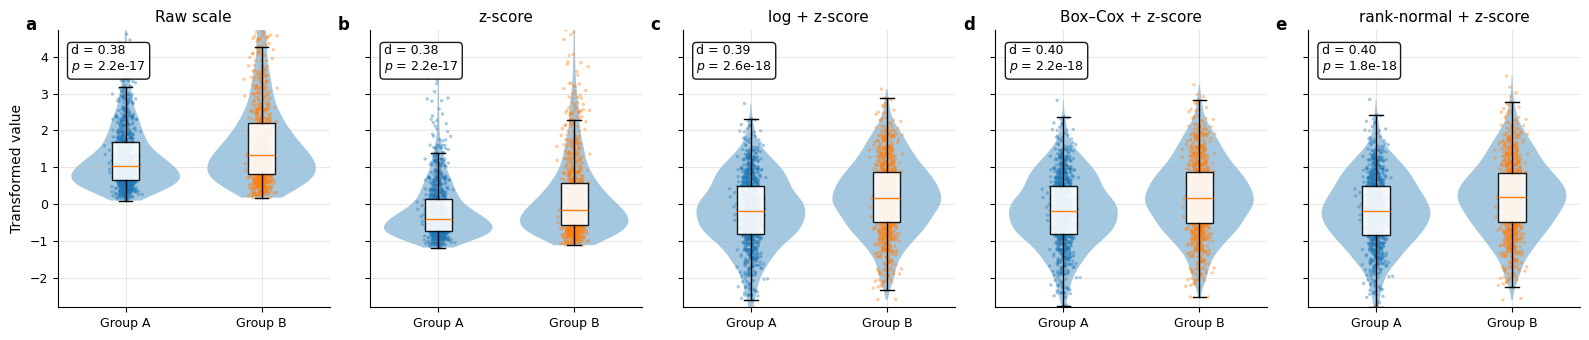

Saved Figure A to: figureA_raincloud_transformations_300dpi.png


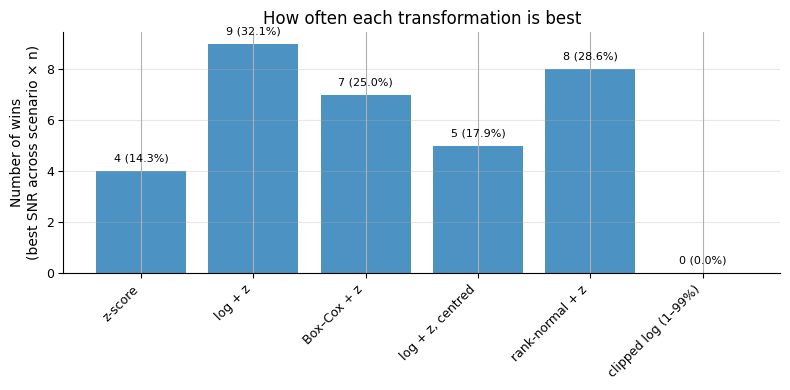

Saved Figure B to: figureB_winner_counts_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm, ttest_ind

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size: Cohen's d
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# =========================================================
# 3. Transformations
# =========================================================
def zscore_normalize(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def apply_transforms_for_figure_A(x_raw, y_raw):
    """
    Returns a dict of transformed pairs for Figure A:
      'Raw', 'z-score', 'log + z', 'Box–Cox + z', 'rank-normal + z'
    """
    out = {}

    # --- Raw ---
    out["Raw"] = (x_raw, y_raw)

    # ensure positivity for log / Box–Cox
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])
    shift = 0.0
    if pooled_raw.min() <= 0:
        shift = -pooled_raw.min() + eps
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # --- z-score ---
    x_z, y_z = zscore_normalize(x_raw, y_raw)
    out["z-score"] = (x_z, y_z)

    # --- log + z ---
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    x_log_z, y_log_z = zscore_normalize(x_log, y_log)
    out["log + z"] = (x_log_z, y_log_z)

    # --- Box–Cox + z ---
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]
    x_bc_z, y_bc_z = zscore_normalize(x_bc, y_bc)
    out["Box–Cox + z"] = (x_bc_z, y_bc_z)

    # --- rank-normal + z ---
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]
    x_rn_z, y_rn_z = zscore_normalize(x_rn, y_rn)
    out["rank-normal + z"] = (x_rn_z, y_rn_z)

    return out

# full set of transforms used in simulation
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "log + z, centred",
    "rank-normal + z",
    "clipped log (1–99%)",
]
n_transforms = len(transform_labels)

def apply_all_transforms(x_raw, y_raw):
    """
    Return list of (x_t, y_t) for the 6 transforms used in simulations:
      0: z-score
      1: log + z-score
      2: Box–Cox + z-score
      3: log + z-score, centred on Group A
      4: rank-normal + z-score
      5: clipped log+z (1–99%)
    """
    results = []

    # 0) z-score
    x_z, y_z = zscore_normalize(x_raw, y_raw)
    results.append((x_z, y_z))

    # ensure positivity
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])
    shift = 0.0
    if pooled_raw.min() <= 0:
        shift = -pooled_raw.min() + eps
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # 1) log + z
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    x_log_z, y_log_z = zscore_normalize(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # 2) Box–Cox + z
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]
    x_bc_z, y_bc_z = zscore_normalize(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # 3) log + z, centred on Group A
    x_cent = x_log_z - x_log_z.mean()
    y_cent = y_log_z - x_log_z.mean()
    results.append((x_cent, y_cent))

    # 4) rank-normal + z
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]
    x_rn_z, y_rn_z = zscore_normalize(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # 5) clipped log (1–99%) + z
    pooled_lz = np.concatenate([x_log_z, y_log_z])
    lo, hi = np.percentile(pooled_lz, [1, 99])
    x_clip = np.clip(x_log_z, lo, hi)
    y_clip = np.clip(y_log_z, lo, hi)
    results.append((x_clip, y_clip))

    return results

# =========================================================
# 4. Simulation SNR grid for winner counts (Figure B)
# =========================================================
def simulate_snr_grid(scen_fun, ns, n_rep=400, seed=123):
    rng = np.random.default_rng(seed)
    mean_d = np.zeros((n_transforms, len(ns)))
    sd_d   = np.zeros((n_transforms, len(ns)))

    for j, n in enumerate(ns):
        d_lists = [[] for _ in range(n_transforms)]
        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            transformed_pairs = apply_all_transforms(x_raw, y_raw)
            for k, (xt, yt) in enumerate(transformed_pairs):
                d_lists[k].append(cohen_d(xt, yt))
        for k in range(n_transforms):
            ds = np.asarray(d_lists[k])
            mean_d[k, j] = ds.mean()
            sd_d[k, j]   = ds.std(ddof=1)

    snr = np.abs(mean_d) / sd_d
    return snr  # shape: (n_transforms, len(ns))

# =========================================================
# 5. Figure A: Raincloud panels for skewed scenario
# =========================================================
def plot_raincloud_panel(ax, x_vals, y_vals, title, panel_label):
    """
    Simple raincloud: violin + jitter + thin boxplot.
    x_vals, y_vals are arrays for Group A and Group B.
    """
    # combine for y-limits
    all_vals = np.concatenate([x_vals, y_vals])

    # violin
    parts = ax.violinplot(
        [x_vals, y_vals],
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.8,
    )
    for pc in parts['bodies']:
        pc.set_alpha(0.4)

    # jittered scatter
    rng = np.random.default_rng(0)
    for i, data in enumerate([x_vals, y_vals], start=1):
        jitter = rng.normal(loc=0, scale=0.04, size=len(data))
        ax.scatter(
            np.full_like(data, i, dtype=float) + jitter,
            data,
            s=6,
            alpha=0.4,
            edgecolors="none",
        )

    # boxplot overlay
    box = ax.boxplot(
        [x_vals, y_vals],
        positions=[1, 2],
        widths=0.2,
        patch_artist=True,
        showfliers=False,
    )
    for patch in box['boxes']:
        patch.set_facecolor("white")
        patch.set_alpha(0.9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

    # panel label
    ax.text(-0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left")

    # stats annotation
    d = cohen_d(x_vals, y_vals)
    t_stat, p_val = ttest_ind(x_vals, y_vals, equal_var=False)
    textstr = (
        f"d = {d:.2f}\n"
        r"$p$" + f" = {p_val:.1e}"
    )
    ax.text(
        0.05, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="black", alpha=0.9),
    )

def make_figure_A(filename="figureA_raincloud_transformations_300dpi.png",
                  n=1000, seed=123):
    """
    Skewed lognormal example:
    panels: Raw, z-score, log+z, Box–Cox+z, rank-normal+z
    """
    rng = np.random.default_rng(seed)
    x_raw, y_raw = scen_lognormal(rng, n)

    transformed = apply_transforms_for_figure_A(x_raw, y_raw)
    titles = [
        "Raw scale",
        "z-score",
        "log + z-score",
        "Box–Cox + z-score",
        "rank-normal + z-score",
    ]
    keys = ["Raw", "z-score", "log + z", "Box–Cox + z", "rank-normal + z"]
    letters = ["a", "b", "c", "d", "e"]

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)

    # Fix y-limits across panels using all transformed data
    all_vals = []
    for key in keys:
        xa, xb = transformed[key]
        all_vals.append(xa)
        all_vals.append(xb)
    all_vals = np.concatenate(all_vals)
    y_min, y_max = np.percentile(all_vals, [1, 99])
    margin = 0.1 * (y_max - y_min)

    for ax, key, title, letter in zip(axes, keys, titles, letters):
        xa, xb = transformed[key]
        plot_raincloud_panel(ax, xa, xb, title, letter)
        ax.set_ylim(y_min - margin, y_max + margin)
        if ax is not axes[0]:
            ax.set_ylabel("")

    axes[0].set_ylabel("Transformed value")

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure A to: {filename}")

# =========================================================
# 6. Figure B: Winner bar plot across all scenarios & ns
# =========================================================
def make_figure_B(filename="figureB_winner_counts_300dpi.png",
                  ns=(10, 20, 50, 100, 200, 500, 1000),
                  n_rep=400, seed=123):
    """
    For each scenario and each n, find which transformation
    has the highest SNR, then count how many times each
    transform is 'winner'. Plot as a bar chart.
    """
    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    winner_counts = np.zeros(n_transforms, dtype=int)

    for _, scen_fun in scenarios:
        snr = simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed)
        # for each n, pick argmax (could be ties; we count all co-winners)
        for j in range(len(ns)):
            col = snr[:, j]
            best = np.argwhere(col == col.max()).flatten()
            for idx in best:
                winner_counts[idx] += 1

    total_cases = len(scenarios) * len(ns)

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(n_transforms)
    bars = ax.bar(x, winner_counts, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(transform_labels, rotation=45, ha="right")
    ax.set_ylabel("Number of wins\n(best SNR across scenario × n)")
    ax.set_title("How often each transformation is best")

    # annotate counts + percentage
    for rect, count in zip(bars, winner_counts):
        height = rect.get_height()
        pct = 100 * count / total_cases
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height + 0.3,
            f"{count} ({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure B to: {filename}")

# =========================================================
# 7. Run both figures
# =========================================================
make_figure_A()
make_figure_B()


Raw scale:      d ≈ 0.737
log + z-score:  d ≈ 1.039


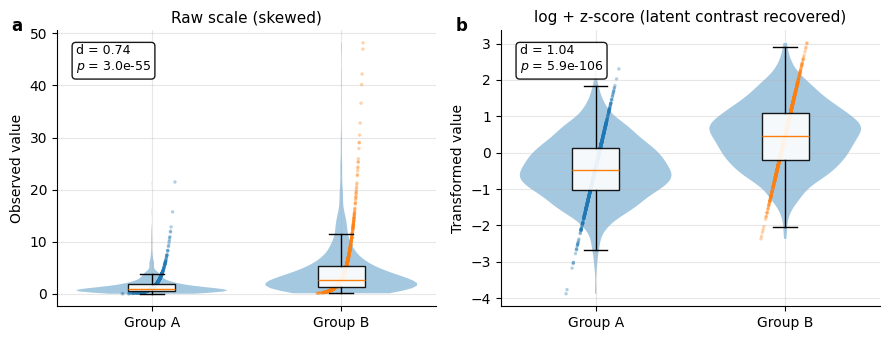

Saved figure to: big_d_change_lognormal_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ---------------------------------------------------------
# 1. Effect size
# ---------------------------------------------------------
def cohen_d(x, y):
    """Cohen's d (pooled SD)."""
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled


# ---------------------------------------------------------
# 2. Simple raincloud panel (violin + jitter + boxplot)
# ---------------------------------------------------------
def raincloud_panel(ax, x_vals, y_vals, title, panel_label, y_label=None):
    # violin (distribution shape)
    parts = ax.violinplot(
        [x_vals, y_vals],
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.8,
    )
    for pc in parts['bodies']:
        pc.set_alpha(0.4)

    # jittered scatter
    rng = np.random.default_rng(0)
    for i, data in enumerate([x_vals, y_vals], start=1):
        jitter = rng.normal(loc=0, scale=0.04, size=len(data))
        ax.scatter(
            np.full_like(data, i, dtype=float) + jitter,
            data,
            s=6,
            alpha=0.35,
            edgecolors="none",
        )

    # boxplot overlay
    box = ax.boxplot(
        [x_vals, y_vals],
        positions=[1, 2],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )
    for patch in box['boxes']:
        patch.set_facecolor("white")
        patch.set_alpha(0.9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

    if y_label is not None:
        ax.set_ylabel(y_label)

    # panel label
    ax.text(-0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left")

    # stats annotation
    d = cohen_d(x_vals, y_vals)
    t_stat, p_val = ttest_ind(x_vals, y_vals, equal_var=False)
    textstr = f"d = {d:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax.text(
        0.05, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="black",
                  alpha=0.9),
    )


# ---------------------------------------------------------
# 3. Figure: big increase in d from raw -> log + z
# ---------------------------------------------------------
def make_big_d_change_figure(
        filename="big_d_change_lognormal_300dpi.png",
        n=1000, delta=1.0, seed=0):
    """
    Example where a log + z-score transform dramatically increases d.
    Latent normals: Z_A ~ N(0,1), Z_B ~ N(delta,1), then X=exp(Z_A), Y=exp(Z_B).
    """

    rng = np.random.default_rng(seed)

    # Latent normals
    Z_A = rng.normal(0.0, 1.0, size=n)
    Z_B = rng.normal(delta, 1.0, size=n)

    # Observed skewed data (lognormal-like)
    X_raw = np.exp(Z_A)
    Y_raw = np.exp(Z_B)

    # Raw d
    d_raw = cohen_d(X_raw, Y_raw)

    # Log + z-score transformation (pooled)
    log_X = np.log(X_raw)
    log_Y = np.log(Y_raw)
    pooled = np.concatenate([log_X, log_Y])
    mu = pooled.mean()
    sd = pooled.std(ddof=1)
    X_logz = (log_X - mu) / sd
    Y_logz = (log_Y - mu) / sd

    d_logz = cohen_d(X_logz, Y_logz)

    print(f"Raw scale:      d ≈ {d_raw:.3f}")
    print(f"log + z-score:  d ≈ {d_logz:.3f}")

    # Shared y-limits for fair visual comparison
    all_vals = np.concatenate([X_raw, Y_raw,
                               X_logz, Y_logz])
    y_min, y_max = np.percentile(all_vals, [1, 99])
    margin = 0.1 * (y_max - y_min)

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False)

    raincloud_panel(
        axes[0], X_raw, Y_raw,
        title="Raw scale (skewed)",
        panel_label="a",
        y_label="Observed value",
    )

    raincloud_panel(
        axes[1], X_logz, Y_logz,
        title="log + z-score (latent contrast recovered)",
        panel_label="b",
        y_label="Transformed value",
    )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to: {filename}")


# ---------------------------------------------------------
# Run once to generate the figure
# ---------------------------------------------------------
make_big_d_change_figure()


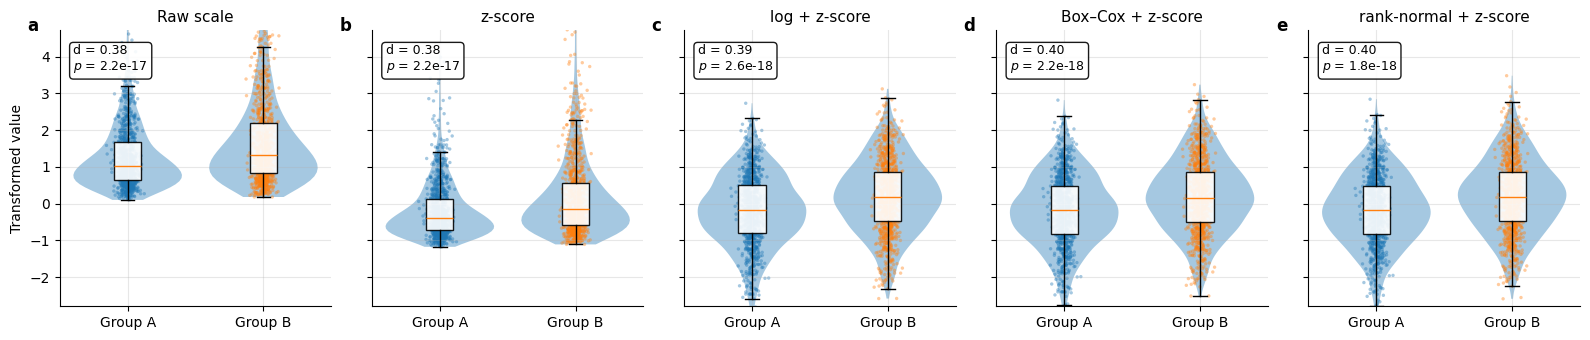

Saved Figure A to: figureA_raincloud_transformations_300dpi.png


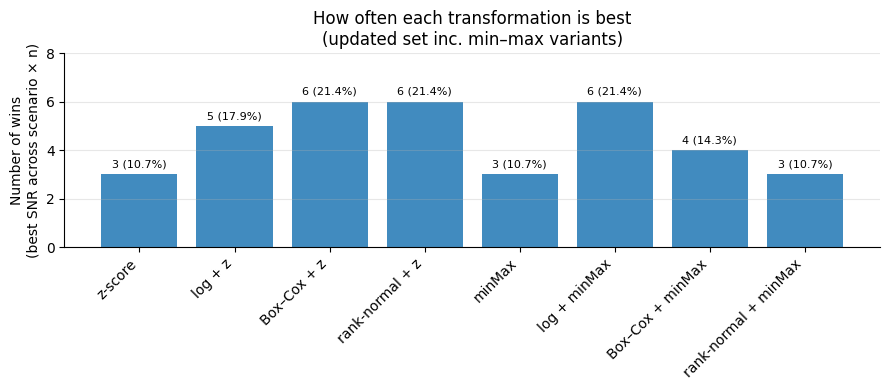

Saved Figure B to: figureB_winner_counts_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm, ttest_ind

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size: Cohen's d
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# =========================================================
# 3. Normalisation helpers
# =========================================================
def zscore_normalize(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_normalize(x, y):
    data = np.concatenate([x, y])
    mn = data.min()
    mx = data.max()
    denom = mx - mn if mx > mn else 1.0
    return (x - mn) / denom, (y - mn) / denom

# =========================================================
# 4. Transforms for Figure A (panels)
# =========================================================
def apply_transforms_for_figure_A(x_raw, y_raw):
    """
    Returns a dict of transformed pairs for Figure A:
      'Raw', 'z-score', 'log + z', 'Box–Cox + z', 'rank-normal + z'
    """
    out = {}

    # --- Raw ---
    out["Raw"] = (x_raw, y_raw)

    # Ensure positivity for log / Box–Cox
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # --- z-score ---
    out["z-score"] = zscore_normalize(x_raw, y_raw)

    # --- log + z ---
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    out["log + z"] = zscore_normalize(x_log, y_log)

    # --- Box–Cox + z ---
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]
    out["Box–Cox + z"] = zscore_normalize(x_bc, y_bc)

    # --- rank-normal + z ---
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]
    out["rank-normal + z"] = zscore_normalize(x_rn, y_rn)

    return out

# =========================================================
# 5. Full transform set for simulations (8 transforms)
# =========================================================
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]
n_transforms = len(transform_labels)

def apply_all_transforms(x_raw, y_raw):
    """
    Return list of (x_t, y_t) for the 8 transforms:
      0: z-score
      1: log + z
      2: Box–Cox + z
      3: rank-normal + z
      4: minMax
      5: log + minMax
      6: Box–Cox + minMax
      7: rank-normal + minMax
    """
    results = []

    # 0) z-score on raw
    results.append(zscore_normalize(x_raw, y_raw))

    # Ensure positivity for log / Box–Cox
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # precompute positive transforms
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]

    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]

    # 1) log + z
    results.append(zscore_normalize(x_log, y_log))

    # 2) Box–Cox + z
    results.append(zscore_normalize(x_bc, y_bc))

    # 3) rank-normal + z
    results.append(zscore_normalize(x_rn, y_rn))

    # 4) minMax (raw)
    results.append(minmax_normalize(x_raw, y_raw))

    # 5) log + minMax
    results.append(minmax_normalize(x_log, y_log))

    # 6) Box–Cox + minMax
    results.append(minmax_normalize(x_bc, y_bc))

    # 7) rank-normal + minMax
    results.append(minmax_normalize(x_rn, y_rn))

    return results

# =========================================================
# 6. Simulation SNR grid for winner counts (Figure B)
# =========================================================
def simulate_snr_grid(scen_fun, ns, n_rep=400, seed=123):
    rng = np.random.default_rng(seed)
    mean_d = np.zeros((n_transforms, len(ns)))
    sd_d   = np.zeros((n_transforms, len(ns)))

    for j, n in enumerate(ns):
        d_lists = [[] for _ in range(n_transforms)]
        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            transformed_pairs = apply_all_transforms(x_raw, y_raw)
            for k, (xt, yt) in enumerate(transformed_pairs):
                d_lists[k].append(cohen_d(xt, yt))
        for k in range(n_transforms):
            ds = np.asarray(d_lists[k])
            mean_d[k, j] = ds.mean()
            sd_d[k, j]   = ds.std(ddof=1)

    snr = np.abs(mean_d) / sd_d
    return snr  # shape: (n_transforms, len(ns))

# =========================================================
# 7. Figure A: Raincloud panels (skewed lognormal scenario)
# =========================================================
def plot_raincloud_panel(ax, x_vals, y_vals, title, panel_label):
    # violin
    parts = ax.violinplot(
        [x_vals, y_vals],
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.8,
    )
    for pc in parts['bodies']:
        pc.set_alpha(0.4)

    # jittered scatter
    rng = np.random.default_rng(0)
    for i, data in enumerate([x_vals, y_vals], start=1):
        jitter = rng.normal(loc=0, scale=0.04, size=len(data))
        ax.scatter(
            np.full_like(data, i, dtype=float) + jitter,
            data,
            s=6,
            alpha=0.4,
            edgecolors="none",
        )

    # boxplot overlay
    box = ax.boxplot(
        [x_vals, y_vals],
        positions=[1, 2],
        widths=0.2,
        patch_artist=True,
        showfliers=False,
    )
    for patch in box['boxes']:
        patch.set_facecolor("white")
        patch.set_alpha(0.9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

    # panel label
    ax.text(-0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left")

    # stats annotation
    d = cohen_d(x_vals, y_vals)
    t_stat, p_val = ttest_ind(x_vals, y_vals, equal_var=False)
    textstr = f"d = {d:.2f}\n" + r"$p$" + f" = {p_val:.1e}"
    ax.text(
        0.05, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="black",
                  alpha=0.9),
    )

def make_figure_A(filename="figureA_raincloud_transformations_300dpi.png",
                  n=1000, seed=123):
    rng = np.random.default_rng(seed)
    x_raw, y_raw = scen_lognormal(rng, n)

    transformed = apply_transforms_for_figure_A(x_raw, y_raw)
    keys   = ["Raw", "z-score", "log + z", "Box–Cox + z", "rank-normal + z"]
    titles = ["Raw scale", "z-score", "log + z-score",
              "Box–Cox + z-score", "rank-normal + z-score"]
    letters = ["a", "b", "c", "d", "e"]

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)

    # common y-limits
    all_vals = []
    for key in keys:
        xa, xb = transformed[key]
        all_vals.append(xa)
        all_vals.append(xb)
    all_vals = np.concatenate(all_vals)
    y_min, y_max = np.percentile(all_vals, [1, 99])
    margin = 0.1 * (y_max - y_min)

    for ax, key, title, letter in zip(axes, keys, titles, letters):
        xa, xb = transformed[key]
        plot_raincloud_panel(ax, xa, xb, title, letter)
        ax.set_ylim(y_min - margin, y_max + margin)
        if ax is not axes[0]:
            ax.set_ylabel("")
    axes[0].set_ylabel("Transformed value")

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure A to: {filename}")

# =========================================================
# 8. Figure B: Winner bar plot for 8 transforms
# =========================================================
def make_figure_B(filename="figureB_winner_counts_300dpi.png",
                  ns=(10, 20, 50, 100, 200, 500, 1000),
                  n_rep=400, seed=123):
    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    winner_counts = np.zeros(n_transforms, dtype=int)

    for _, scen_fun in scenarios:
        snr = simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed)
        for j in range(len(ns)):
            col = snr[:, j]
            best = np.argwhere(col == col.max()).flatten()
            for idx in best:
                winner_counts[idx] += 1

    total_cases = len(scenarios) * len(ns)

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(n_transforms)
    bars = ax.bar(x, winner_counts, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(transform_labels, rotation=45, ha="right")
    ax.set_ylabel("Number of wins\n(best SNR across scenario × n)")
    ax.set_title("How often each transformation is best\n(updated set inc. min–max variants)")

    for rect, count in zip(bars, winner_counts):
        height = rect.get_height()
        pct = 100 * count / total_cases
        ax.text(rect.get_x() + rect.get_width() / 2,
                height + 0.2,
                f"{count} ({pct:.1f}%)",
                ha="center", va="bottom", fontsize=8)

    ax.set_ylim(0, max(winner_counts) + 2)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure B to: {filename}")

# =========================================================
# 9. Run both figures
# =========================================================
make_figure_A()
make_figure_B()


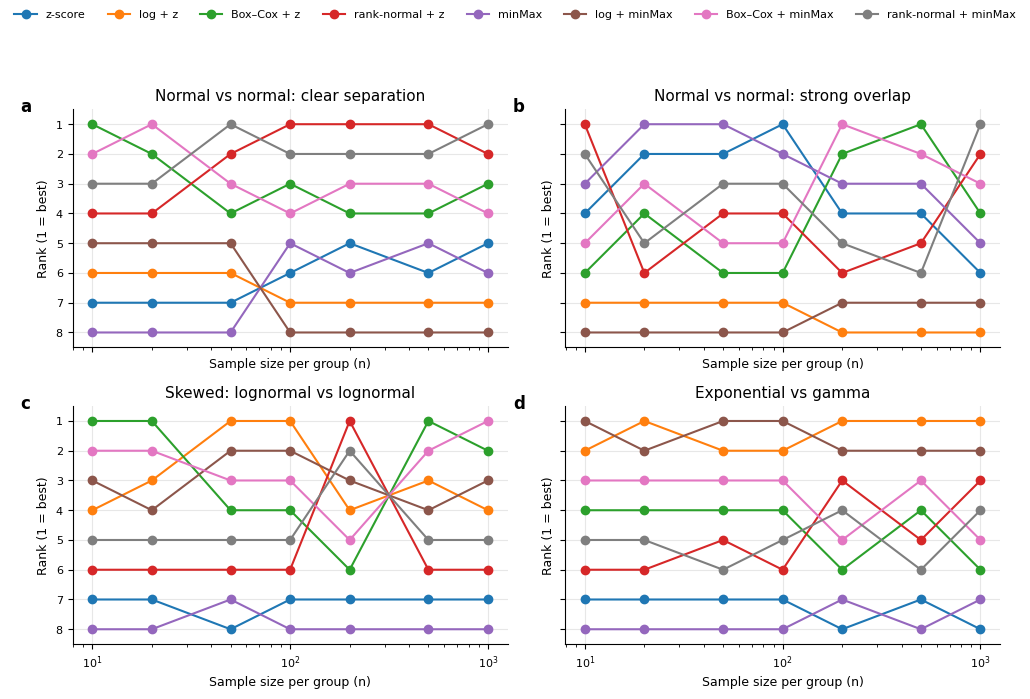

Saved rank-vs-n matrix to: fig_rank_vs_n_4scenarios_300dpi.png


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size: Cohen's d
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# =========================================================
# 3. Normalisation helpers
# =========================================================
def zscore_normalize(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_normalize(x, y):
    data = np.concatenate([x, y])
    mn = data.min()
    mx = data.max()
    denom = mx - mn if mx > mn else 1.0
    return (x - mn) / denom, (y - mn) / denom

# =========================================================
# 4. Transformations (8 only)
# =========================================================
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]
n_transforms = len(transform_labels)

def apply_all_transforms(x_raw, y_raw):
    """
    Return list of (x_t, y_t) for the 8 transforms:
      0: z-score
      1: log + z
      2: Box–Cox + z
      3: rank-normal + z
      4: minMax
      5: log + minMax
      6: Box–Cox + minMax
      7: rank-normal + minMax
    """
    results = []

    # --- common quantities ---
    pooled_raw = np.concatenate([x_raw, y_raw])

    # ensure positivity for log/Box–Cox
    eps = 1e-9
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]

    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]

    # 0) z-score
    results.append(zscore_normalize(x_raw, y_raw))

    # 1) log + z
    results.append(zscore_normalize(x_log, y_log))

    # 2) Box–Cox + z
    results.append(zscore_normalize(x_bc, y_bc))

    # 3) rank-normal + z
    results.append(zscore_normalize(x_rn, y_rn))

    # 4) minMax on raw
    results.append(minmax_normalize(x_raw, y_raw))

    # 5) log + minMax
    results.append(minmax_normalize(x_log, y_log))

    # 6) Box–Cox + minMax
    results.append(minmax_normalize(x_bc, y_bc))

    # 7) rank-normal + minMax
    results.append(minmax_normalize(x_rn, y_rn))

    return results

# =========================================================
# 5. Simulate SNR grid for one scenario
# =========================================================
def simulate_snr_grid(scen_fun, ns, n_rep=500, seed=123):
    """
    For a given scenario, compute SNR = |mean d| / SD(d)
    for each transformation × sample size.
    Returns:
      snr : array shape (n_transforms, len(ns))
    """
    rng = np.random.default_rng(seed)
    mean_d = np.zeros((n_transforms, len(ns)))
    sd_d   = np.zeros((n_transforms, len(ns)))

    for j, n in enumerate(ns):
        d_lists = [[] for _ in range(n_transforms)]
        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            transformed_pairs = apply_all_transforms(x_raw, y_raw)
            for k, (xt, yt) in enumerate(transformed_pairs):
                d_lists[k].append(cohen_d(xt, yt))
        for k in range(n_transforms):
            ds = np.asarray(d_lists[k])
            mean_d[k, j] = ds.mean()
            sd_d[k, j]   = ds.std(ddof=1)

    snr = np.abs(mean_d) / sd_d
    return snr

# =========================================================
# 6A. Figure 1 – Rank vs n for each scenario (2×2)
# =========================================================
def make_rank_vs_n_matrix(
        filename="fig_rank_vs_n_4scenarios_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=500, seed=123
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 9
    plt.rcParams["xtick.labelsize"] = 8
    plt.rcParams["ytick.labelsize"] = 8

    scenarios = [
        ("Normal vs normal: clear separation",   scen_normal_clear),
        ("Normal vs normal: strong overlap",    scen_normal_overlap),
        ("Skewed: lognormal vs lognormal",      scen_lognormal),
        ("Exponential vs gamma",                scen_exponential_gamma),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, (label, scen_fun), letter in zip(axes, scenarios, letters):
        snr = simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed)

        # Rank transformations for each n (1 = best SNR)
        ranks = np.zeros_like(snr)
        for j in range(len(ns)):
            order = np.argsort(-snr[:, j])  # descending SNR
            rank_values = np.empty(n_transforms, dtype=int)
            rank_values[order] = np.arange(1, n_transforms + 1)
            ranks[:, j] = rank_values

        for k in range(n_transforms):
            ax.plot(
                ns,
                ranks[k, :],
                marker="o",
                linestyle="-",
                color=color_cycle[k % len(color_cycle)],
                label=transform_labels[k],
            )

        ax.set_xscale("log")
        ax.set_ylim(0.5, n_transforms + 0.5)
        ax.set_yticks(range(1, n_transforms + 1))
        ax.invert_yaxis()  # rank 1 at the top
        ax.set_xlabel("Sample size per group (n)")
        ax.set_ylabel("Rank (1 = best)")
        ax.set_title(label, fontsize=11)
        ax.grid(alpha=0.3)

        ax.text(-0.12, 1.05, letter,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                va="top", ha="left")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=n_transforms,
        fontsize=8,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved rank-vs-n matrix to: {filename}")

# =========================================================
# 6B. Figure 2 – Overall mean SNR across scenarios
# =========================================================
def make_overall_snr_summary(
        filename="fig_overall_snr_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=500, seed=123
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    snr_all = []
    for _, scen_fun in scenarios:
        snr_all.append(simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed))
    snr_all = np.stack(snr_all, axis=0)  # (n_scenarios, n_transforms, len(ns))

    mean_snr = snr_all.mean(axis=0)  # (n_transforms, len(ns))

    fig, ax = plt.subplots(figsize=(7, 4))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for k in range(n_transforms):
        ax.plot(
            ns,
            mean_snr[k, :],
            marker="o",
            linestyle="-",
            color=color_cycle[k % len(color_cycle)],
            label=transform_labels[k],
        )

    ax.set_xscale("log")
    ax.set_xlabel("Sample size per group (n)")
    ax.set_ylabel(r"Mean signal-to-noise: $|d|/\mathrm{SD}(d)$")
    ax.set_title("Average performance across all four scenarios")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved overall SNR summary to: {filename}")

# =========================================================
# Run once to generate both figures
# =========================================================
ns_values = (10, 20, 50, 100, 200, 500, 1000)
make_rank_vs_n_matrix(ns=ns_values, n_rep=500, seed=123)
make_overall_snr_summary(ns=ns_values, n_rep=500, seed=123)


Normal vs normal: clear separation: d_raw = 1.571, d_log+minMax = 0.900
Normal vs normal: strong overlap: d_raw = 0.096, d_log+minMax = 0.067
Skewed: lognormal vs lognormal: d_raw = 0.335, d_log+minMax = 0.408
Exponential vs gamma: d_raw = 0.376, d_log+minMax = 0.600


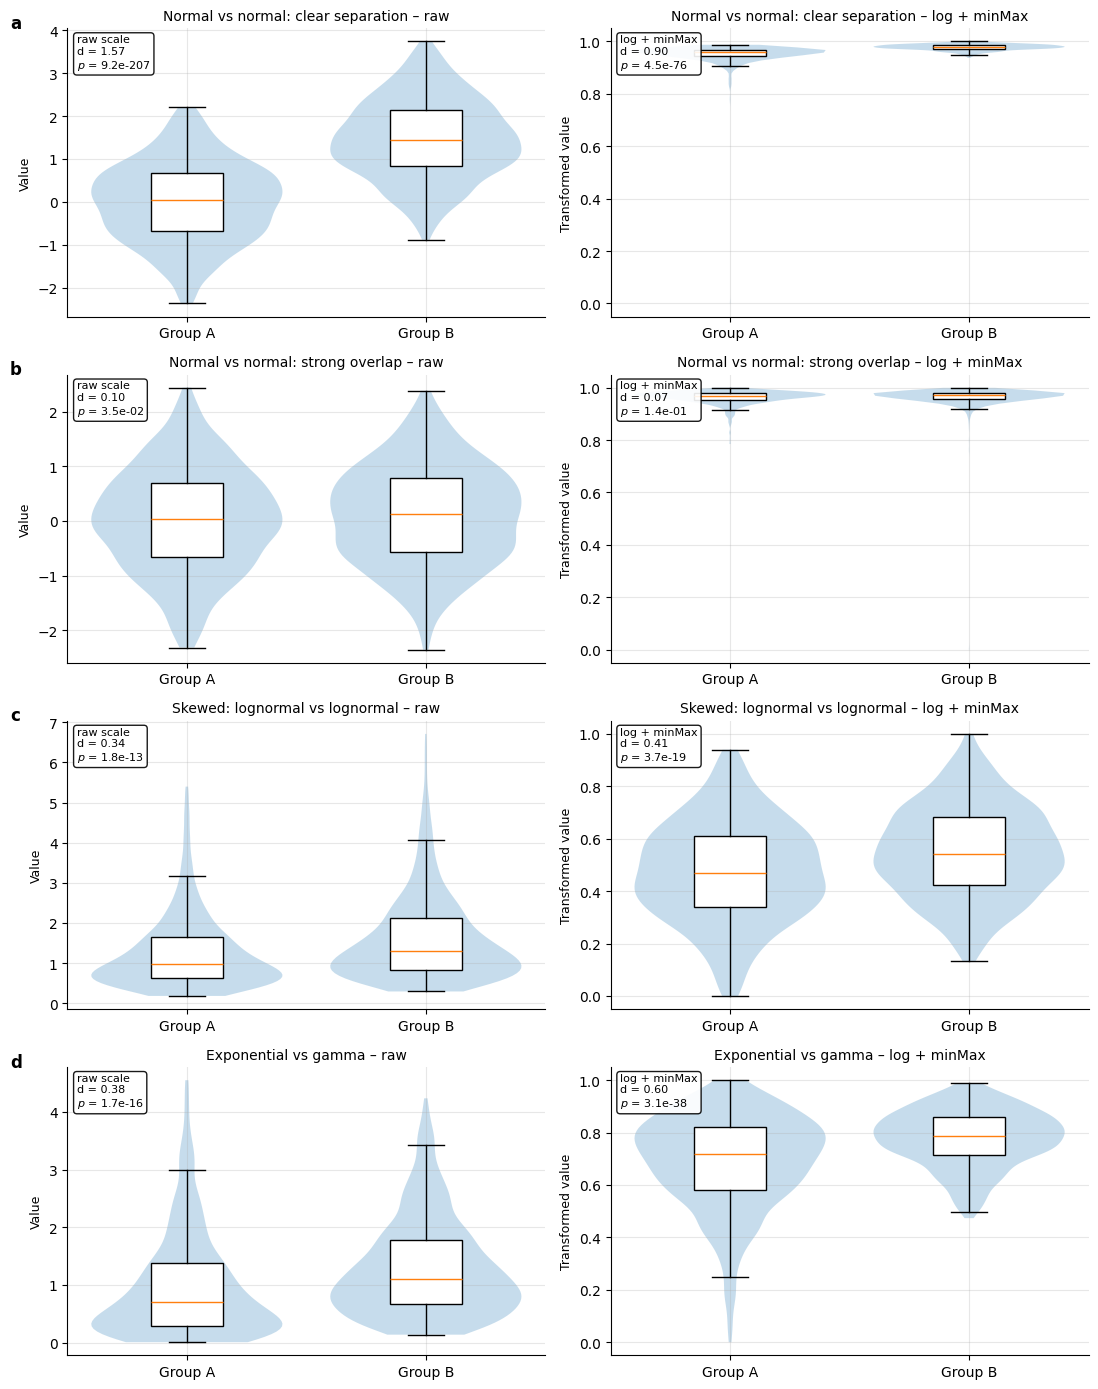

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# --------------------------------------------------------
# 1. Core helpers
# --------------------------------------------------------
def cohen_d(a, b):
    n1, n2 = len(a), len(b)
    s1 = a.var(ddof=1)
    s2 = b.var(ddof=1)
    s = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2))
    return (b.mean() - a.mean()) / s

def trim_outliers(x, y, low=1, high=99):
    """Trim within-group outliers using groupwise percentiles."""
    xl, xh = np.percentile(x, [low, high])
    yl, yh = np.percentile(y, [low, high])
    x2 = x[(x >= xl) & (x <= xh)]
    y2 = y[(y >= yl) & (y <= yh)]
    return x2, y2

def log_minmax(x, y, eps=1e-9):
    """log transform (with shift if needed) + min-max scaling to [0,1]."""
    pooled = np.concatenate([x, y])
    shift = 0.0
    if pooled.min() <= 0:
        shift = -pooled.min() + eps

    x_log = np.log(x + shift)
    y_log = np.log(y + shift)

    pooled_log = np.concatenate([x_log, y_log])
    lo, hi = pooled_log.min(), pooled_log.max()
    span = hi - lo

    x_mm = (x_log - lo) / span
    y_mm = (y_log - lo) / span
    return x_mm, y_mm

# --------------------------------------------------------
# 2. Scenarios
# --------------------------------------------------------
def scen_normal_clear(rng, n):
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(1.5, 1.0, n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(0.2, 1.0, n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(0.0, 0.7, n)
    y = rng.lognormal(0.3, 0.7, n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(1.0, n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal vs normal: clear separation", scen_normal_clear),
    ("Normal vs normal: strong overlap",   scen_normal_overlap),
    ("Skewed: lognormal vs lognormal",     scen_lognormal),
    ("Exponential vs gamma",               scen_exponential_gamma),
]

# --------------------------------------------------------
# 3. Plot helper
# --------------------------------------------------------
def plot_panel(ax, x, y, title, label_prefix):
    # violin
    parts = ax.violinplot(
        [x, y],
        positions=[1, 2],
        showmeans=False,
        showextrema=False,
        widths=0.8,
    )
    for pc in parts['bodies']:
        pc.set_alpha(0.25)

    # box
    box = ax.boxplot(
        [x, y],
        positions=[1, 2],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
    )
    for patch in box['boxes']:
        patch.set_facecolor("white")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Group A", "Group B"])
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)

    # stats
    d = cohen_d(x, y)
    tstat, p = ttest_ind(x, y, equal_var=False)
    txt = f"{label_prefix}\nd = {d:.2f}\n" + r"$p$" + f" = {p:.1e}"
    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9),
    )
    return d

# --------------------------------------------------------
# 4. Main figure: raw vs log+minMax for all four scenarios
# --------------------------------------------------------
def make_raw_vs_logminmax_figure(n=1000, seed=2025):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(4, 2, figsize=(11, 14))
    letters = ["a", "b", "c", "d"]

    for i, (label, scen_fun) in enumerate(scenarios):
        rng = np.random.default_rng(seed + i)
        x, y = scen_fun(rng, n)

        # gentle trimming to avoid single crazy outliers
        x_raw, y_raw = trim_outliers(x, y)

        # raw panel
        d_raw = plot_panel(
            axes[i, 0],
            x_raw, y_raw,
            label + " – raw",
            "raw scale",
        )
        axes[i, 0].set_ylabel("Value", fontsize=9)

        # log + minMax panel (applied to *all* scenarios)
        x_t, y_t = log_minmax(x_raw, y_raw)
        d_trans = plot_panel(
            axes[i, 1],
            x_t, y_t,
            label + " – log + minMax",
            "log + minMax",
        )
        axes[i, 1].set_ylabel("Transformed value", fontsize=9)

        # panel letter
        axes[i, 0].text(
            -0.12, 1.05, letters[i],
            transform=axes[i, 0].transAxes,
            fontsize=12,
            fontweight="bold",
            va="top", ha="left",
        )

        print(f"{label}: d_raw = {d_raw:.3f}, d_log+minMax = {d_trans:.3f}")

    plt.tight_layout()
    plt.show()

# Run in Colab
make_raw_vs_logminmax_figure()


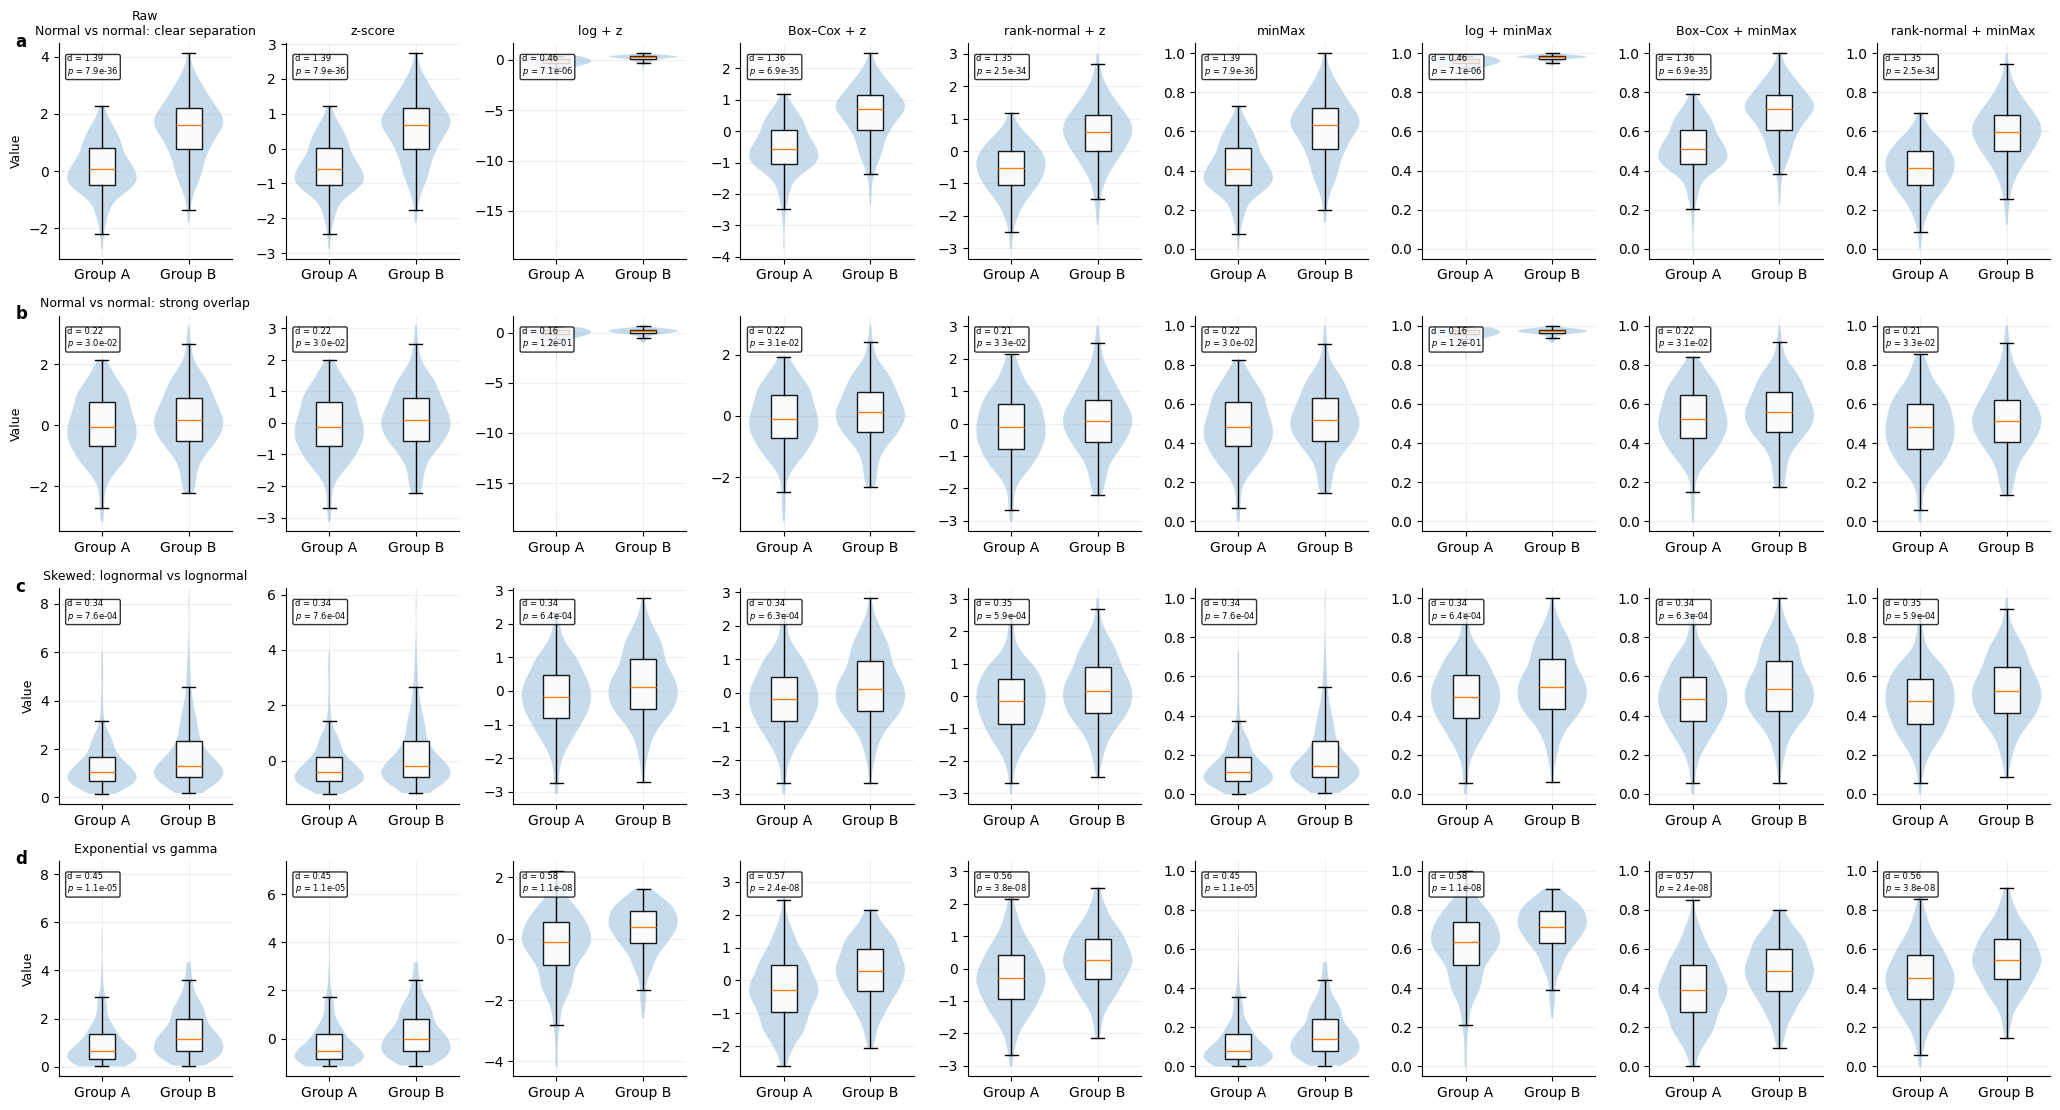

Saved figure to: four_scenarios_9panels_each_n200.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm, ttest_ind

# =========================================================
# 1. Scenario generators (n per group)
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size: Cohen's d
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# =========================================================
# 3. Shared helpers for transformations
# =========================================================
def zscore_pooled(x, y):
    pooled = np.concatenate([x, y])
    mu = pooled.mean()
    sd = pooled.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_pooled(x, y):
    pooled = np.concatenate([x, y])
    lo = pooled.min()
    hi = pooled.max()
    rng = hi - lo if hi > lo else 1.0
    return (x - lo) / rng, (y - lo) / rng

def make_positive(x, y, eps=1e-9):
    pooled = np.concatenate([x, y])
    shift = 0.0
    if pooled.min() <= 0:
        shift = -pooled.min() + eps
    return x + shift, y + shift

# =========================================================
# 4. Apply 8 transformations to one (x, y) pair
# =========================================================
base_transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]
all_labels = ["Raw"] + base_transform_labels  # total 9 columns

def apply_all_transforms(x_raw, y_raw):
    """
    Returns list of (label, x_t, y_t), starting with Raw.
    Total length = 9 (Raw + 8 transforms).
    """
    out = []

    # --- 0) Raw ---
    out.append(("Raw", x_raw, y_raw))

    # Prepare shared positives & rank-normal etc.
    x_pos, y_pos = make_positive(x_raw, y_raw)

    # log
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    # Box–Cox (lambda from pooled positives)
    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]

    # rank-normal on raw
    pooled_raw = np.concatenate([x_raw, y_raw])
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]

    # --- 1) z-score ---
    x_z, y_z = zscore_pooled(x_raw, y_raw)
    out.append(("z-score", x_z, y_z))

    # --- 2) log + z ---
    x_lz, y_lz = zscore_pooled(x_log, y_log)
    out.append(("log + z", x_lz, y_lz))

    # --- 3) Box–Cox + z ---
    x_bz, y_bz = zscore_pooled(x_bc, y_bc)
    out.append(("Box–Cox + z", x_bz, y_bz))

    # --- 4) rank-normal + z ---
    x_rz, y_rz = zscore_pooled(x_rn, y_rn)
    out.append(("rank-normal + z", x_rz, y_rz))

    # --- 5) minMax ---
    x_mm, y_mm = minmax_pooled(x_raw, y_raw)
    out.append(("minMax", x_mm, y_mm))

    # --- 6) log + minMax ---
    x_log_mm, y_log_mm = minmax_pooled(x_log, y_log)
    out.append(("log + minMax", x_log_mm, y_log_mm))

    # --- 7) Box–Cox + minMax ---
    x_bc_mm, y_bc_mm = minmax_pooled(x_bc, y_bc)
    out.append(("Box–Cox + minMax", x_bc_mm, y_bc_mm))

    # --- 8) rank-normal + minMax ---
    x_rn_mm, y_rn_mm = minmax_pooled(x_rn, y_rn)
    out.append(("rank-normal + minMax", x_rn_mm, y_rn_mm))

    return out

# =========================================================
# 5. Plot helper (violin + box + d, p)
# =========================================================
def plot_small_panel(ax, x_vals, y_vals, title):
    parts = ax.violinplot(
        [x_vals, y_vals],
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.8,
    )
    for pc in parts['bodies']:
        pc.set_alpha(0.25)

    bp = ax.boxplot(
        [x_vals, y_vals],
        positions=[1, 2],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
    )
    for patch in bp['boxes']:
        patch.set_facecolor("white")
        patch.set_alpha(0.9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Group A", "Group B"], rotation=0)
    ax.set_title(title, fontsize=8)
    ax.grid(alpha=0.2)

    d = cohen_d(x_vals, y_vals)
    _, p = ttest_ind(x_vals, y_vals, equal_var=False)
    txt = f"d = {d:.2f}\n" + r"$p$" + f" = {p:.1e}"
    ax.text(
        0.05, 0.95, txt,
        transform=ax.transAxes,
        fontsize=6,
        va="top",
        bbox=dict(boxstyle="round,pad=0.2",
                  facecolor="white", edgecolor="black", alpha=0.8),
    )

# =========================================================
# 6. Main 4 × 9 figure for n = 100
# =========================================================
def make_4x9_figure(n=200, seed=123,
                    filename="four_scenarios_9panels_each_n200.png"):
    rng = np.random.default_rng(seed)

    scenarios = [
        ("Normal vs normal: clear separation", scen_normal_clear),
        ("Normal vs normal: strong overlap",   scen_normal_overlap),
        ("Skewed: lognormal vs lognormal",     scen_lognormal),
        ("Exponential vs gamma",               scen_exponential_gamma),
    ]

    n_rows = len(scenarios)
    n_cols = 1 + len(base_transform_labels)  # raw + 8 = 9

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.3 * n_cols, 2.8 * n_rows),
        sharey=False
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    row_letters = ["a", "b", "c", "d"]

    for row, ((scen_title, scen_fun), letter) in enumerate(zip(scenarios, row_letters)):
        x_raw, y_raw = scen_fun(rng, n)
        panels = apply_all_transforms(x_raw, y_raw)  # list of (label, x, y)

        for col, (label, x_t, y_t) in enumerate(panels):
            ax = axes[row, col]
            plot_small_panel(ax, x_t, y_t, label if row == 0 else "")

            if col == 0:
                ax.set_ylabel("Value", fontsize=9)
                ax.text(
                    -0.25, 1.05, letter,
                    transform=ax.transAxes,
                    fontsize=12, fontweight="bold",
                    va="top", ha="left",
                )
                ax.set_title(label + f"\n{scen_title}", fontsize=9)
            elif row == 0:
                ax.set_title(label, fontsize=9)

            if row > 0 and col == 0:
                ax.set_title(scen_title, fontsize=9)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to: {filename}")

# =========================================================
# Run once
# =========================================================
make_4x9_figure(n=200, seed=123)


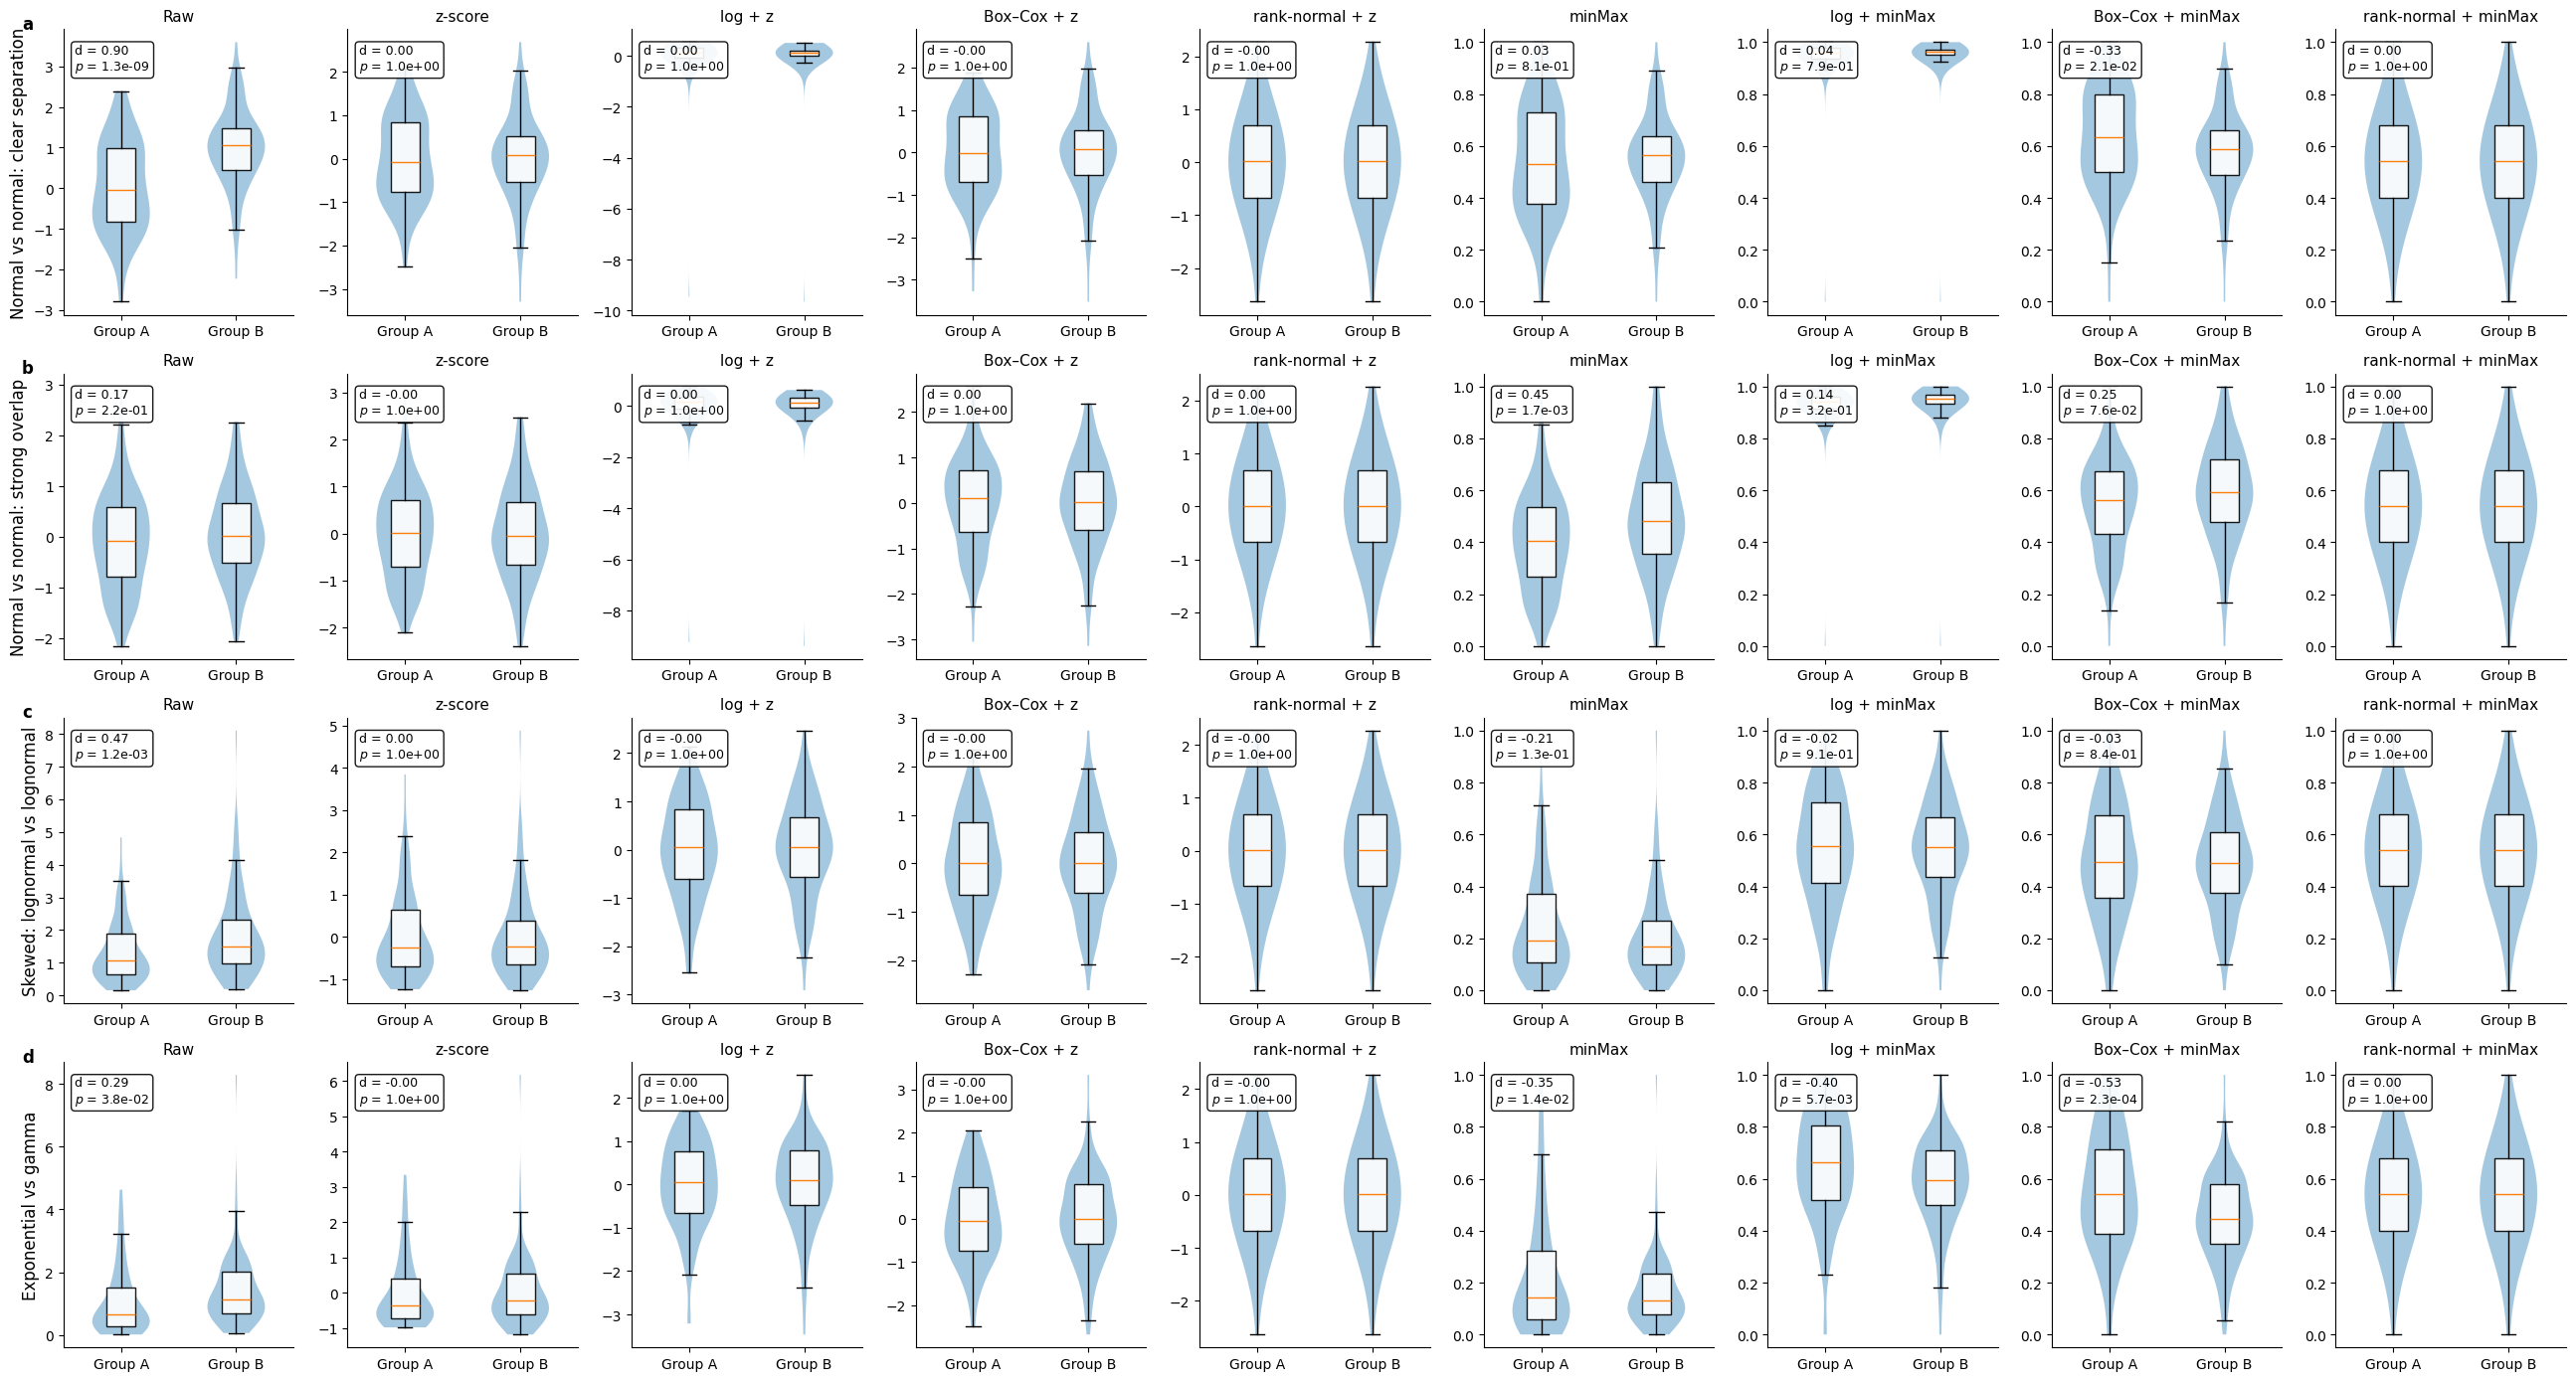

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, ttest_ind
from scipy.special import erfinv

# -----------------------------
# 1. Scenario generators
# -----------------------------
def scen_clear(n=100):
    # Normal vs normal: clear separation
    x = np.random.normal(0, 1, n)
    y = np.random.normal(1, 1, n)
    return x, y

def scen_overlap(n=100):
    # Normal vs normal: strong overlap
    x = np.random.normal(0, 1, n)
    y = np.random.normal(0.2, 1, n)
    return x, y

def scen_lognormal(n=100):
    # Skewed: lognormal vs lognormal
    x = np.random.lognormal(mean=0.0, sigma=0.7, size=n)
    y = np.random.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_expgamma(n=100):
    # Exponential vs gamma
    x = np.random.exponential(scale=1.0, size=n)
    y = np.random.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal vs normal: clear separation", scen_clear),
    ("Normal vs normal: strong overlap",  scen_overlap),
    ("Skewed: lognormal vs lognormal",    scen_lognormal),
    ("Exponential vs gamma",              scen_expgamma),
]

# -----------------------------
# 2. Helpers
# -----------------------------
def zscore(x):
    mu = np.mean(x)
    sd = np.std(x, ddof=1)
    return (x - mu) / (sd + 1e-12)

def minmax(x):
    xmin = np.min(x)
    xmax = np.max(x)
    rng = xmax - xmin
    if rng == 0:
        return np.zeros_like(x)
    return (x - xmin) / (rng + 1e-12)

def make_positive(x):
    """Shift x so all values are strictly > 0."""
    m = np.min(x)
    shift = 0.0
    if m <= 0:
        shift = -m + 1e-6
    return x + shift

def rank_normal(x):
    """Van der Waerden normal scores."""
    r = rankdata(x, method="average")
    u = (r - 0.5) / (len(x) + 1.0)
    return np.sqrt(2.0) * erfinv(2*u - 1)

def cohen_d(a, b):
    """Pooled-SD Cohen's d."""
    var_a = np.var(a, ddof=1)
    var_b = np.var(b, ddof=1)
    sp = np.sqrt((var_a + var_b) / 2.0)
    return (np.mean(b) - np.mean(a)) / (sp + 1e-12)

# -----------------------------
# 3. Transformations (8)
# -----------------------------
def t_raw(x):       return x
def t_z(x):         return zscore(x)

def t_log_z(x):
    x_pos = make_positive(x)
    return zscore(np.log(x_pos))

def t_boxcox_z(x):
    x_pos = make_positive(x)
    bc, _ = boxcox(x_pos)
    return zscore(bc)

def t_ranknorm_z(x):
    rn = rank_normal(x)
    return zscore(rn)

def t_minmax(x):
    return minmax(x)

def t_log_minmax(x):
    x_pos = make_positive(x)
    return minmax(np.log(x_pos))

def t_boxcox_minmax(x):
    x_pos = make_positive(x)
    bc, _ = boxcox(x_pos)
    return minmax(bc)

def t_ranknorm_minmax(x):
    rn = rank_normal(x)
    return minmax(rn)

transformations = [
    ("Raw",                 t_raw),
    ("z-score",             t_z),
    ("log + z",             t_log_z),
    ("Box–Cox + z",         t_boxcox_z),
    ("rank-normal + z",     t_ranknorm_z),
    ("minMax",              t_minmax),
    ("log + minMax",        t_log_minmax),
    ("Box–Cox + minMax",    t_boxcox_minmax),
    ("rank-normal + minMax",t_ranknorm_minmax),
]

# -----------------------------
# 4. Plot 4 × 9 grid (n = 100)
# -----------------------------
np.random.seed(123)

n_rows = len(scenarios)
n_cols = len(transformations)

fig, axs = plt.subplots(
    n_rows, n_cols,
    figsize=(26, 14),
    sharey=False
)

panel_letters = ["a", "b", "c", "d"]

for row, ((scen_title, scen_fun), letter) in enumerate(zip(scenarios, panel_letters)):
    x_raw, y_raw = scen_fun(n=100)

    for col, (tname, tfunc) in enumerate(transformations):
        ax = axs[row, col]

        # Apply transformation to each group
        A = tfunc(x_raw)
        B = tfunc(y_raw)

        # Effect size and p-value
        d  = cohen_d(A, B)
        p  = ttest_ind(A, B, equal_var=False).pvalue

        # Violin + boxplot
        parts = ax.violinplot([A, B], positions=[1, 2],
                              showmeans=False, showmedians=False,
                              showextrema=False)
        for pc in parts["bodies"]:
            pc.set_alpha(0.4)

        ax.boxplot([A, B], positions=[1, 2], widths=0.25,
                   showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor="white", alpha=0.9))

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Group A", "Group B"], rotation=0)

        if col == 0:
            ax.set_ylabel("Value")
            ax.text(-0.18, 1.05, letter,
                    transform=ax.transAxes,
                    fontsize=12, fontweight="bold",
                    va="top", ha="left")

        ax.set_title(tname, fontsize=11)

        # Annotate d and p
        ax.text(
            0.05, 0.95,
            f"d = {d:.2f}\n"
            r"$p$" + f" = {p:.1e}",
            transform=ax.transAxes,
            fontsize=9,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", edgecolor="black", alpha=0.9)
        )

    # Add scenario title spanning the row
    axs[row, 0].set_ylabel(scen_title, fontsize=12)

plt.tight_layout()
plt.savefig("all_scenarios_9_transforms_n100.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, boxcox, rankdata, norm

# ------------------------------------------------------------------
# Helper: Cohen's d (pooled SD)
# ------------------------------------------------------------------
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# ------------------------------------------------------------------
# Helper: overlap coefficient (empirical)
#   0 = no overlap, 1 = identical
# ------------------------------------------------------------------
def overlap_coefficient(x, y, n_bins=200):
    data_min = min(x.min(), y.min())
    data_max = max(x.max(), y.max())
    bins = np.linspace(data_min, data_max, n_bins+1)
    hx, _ = np.histogram(x, bins=bins, density=True)
    hy, _ = np.histogram(y, bins=bins, density=True)
    return np.trapz(np.minimum(hx, hy), x=bins[:-1])

# ------------------------------------------------------------------
# Scenario generators (same as before)
# ------------------------------------------------------------------
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# ------------------------------------------------------------------
# Transformations used in the paper
# ------------------------------------------------------------------
def minmax(x):
    mn, mx = np.min(x), np.max(x)
    if mx == mn:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

def log_minmax(x):
    # Shift so values are positive, log1p, then min-max
    eps = 1e-9
    x_pos = x - np.min(x) + eps
    return minmax(np.log1p(x_pos))

def boxcox_minmax(x):
    # Shift + Box-Cox + min-max
    eps = 1e-9
    x_pos = x - np.min(x) + eps
    x_bc, _ = boxcox(x_pos)
    return minmax(x_bc)

def ranknorm_minmax(x):
    ranks = rankdata(x, method="average")
    u = (ranks - 0.5) / len(x)
    x_rn = norm.ppf(u)
    return minmax(x_rn)

TRANSFORMS = {
    "Raw"               : lambda x: x,
    "z-score"           : lambda x: (x - np.mean(x)) / np.std(x, ddof=1),
    "log + z"           : lambda x: (np.log1p(x - np.min(x) + 1e-9) - np.mean(np.log1p(x - np.min(x) + 1e-9))) /
                                    np.std(np.log1p(x - np.min(x) + 1e-9), ddof=1),
    "Box–Cox + z"       : lambda x: (lambda xb: (xb - np.mean(xb)) / np.std(xb, ddof=1))(
                                    boxcox(x - np.min(x) + 1e-9)[0]),
    "rank-normal + z"   : lambda x: (lambda rn: (rn - np.mean(rn)) / np.std(rn, ddof=1))(
                                    norm.ppf((rankdata(x, method="average") - 0.5) / len(x))),
    "minMax"            : minmax,
    "log + minMax"      : log_minmax,
    "Box–Cox + minMax"  : boxcox_minmax,
    "rank-normal + minMax": ranknorm_minmax,
}

# ------------------------------------------------------------------
# Plot style
# ------------------------------------------------------------------
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9


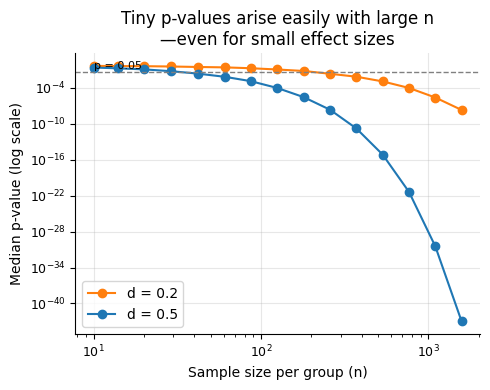

In [ ]:
def make_figure1_p_vs_n(filename="Figure1_p_vs_n.png"):
    rng = np.random.default_rng(123)

    ns = np.logspace(1, 3.2, 15, dtype=int)  # 10 .. ~1585
    ds = [0.2, 0.5]
    colors = ["tab:orange", "tab:blue"]

    fig, ax = plt.subplots(figsize=(5, 4))

    for d, c in zip(ds, colors):
        p_means = []
        for n in ns:
            ps = []
            for _ in range(3000):
                x = rng.normal(0, 1, size=n)
                y = rng.normal(d, 1, size=n)  # mean difference ≈ d (since SD=1)
                _, p = ttest_ind(x, y, equal_var=True)
                ps.append(p)
            p_means.append(np.median(ps))  # median p-value
        ax.plot(ns, p_means, marker="o", label=f"d = {d}", color=c)

    ax.axhline(0.05, color="grey", linestyle="--", linewidth=1)
    ax.text(ns[0], 0.05*1.3, "p = 0.05", fontsize=8, va="bottom")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Sample size per group (n)")
    ax.set_ylabel("Median p-value (log scale)")
    ax.set_title("Tiny p-values arise easily with large n\n—even for small effect sizes")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Run
make_figure1_p_vs_n()


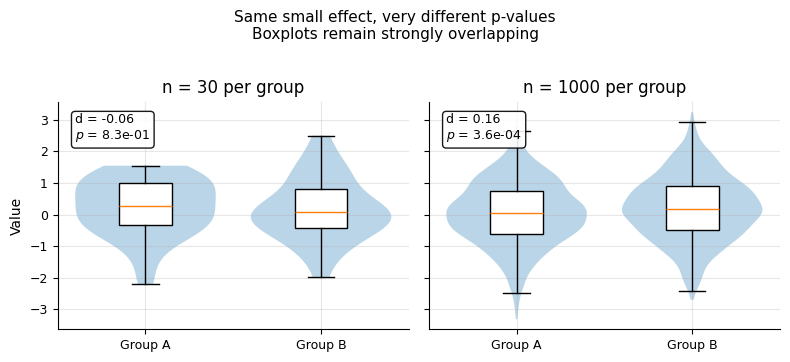

In [ ]:
def make_figure2_same_d_diff_n(filename="Figure2_overlap_vs_p.png"):
    rng = np.random.default_rng(123)

    ns = [30, 1000]
    scen_fun = scen_normal_overlap
    titles = [f"n = {n} per group" for n in ns]

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

    for ax, n, title in zip(axes, ns, titles):
        x, y = scen_fun(rng, n)
        d = cohen_d(x, y)
        _, p = ttest_ind(x, y, equal_var=True)

        parts = ax.violinplot([x, y],
                              positions=[1, 2],
                              showextrema=False,
                              widths=0.8)
        for pc in parts['bodies']:
            pc.set_alpha(0.3)

        box = ax.boxplot([x, y], positions=[1, 2], widths=0.3,
                         patch_artist=True, showfliers=False)
        for patch in box['boxes']:
            patch.set_facecolor("white")

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Group A", "Group B"])
        ax.set_title(title)
        ax.set_xlabel("")
        ax.grid(alpha=0.3)

        textstr = f"d = {d:.2f}\n" + r"$p$" + f" = {p:.1e}"
        ax.text(0.05, 0.95, textstr,
                transform=ax.transAxes, va="top",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", edgecolor="black", alpha=0.9),
                fontsize=9)

    axes[0].set_ylabel("Value")
    fig.suptitle("Same small effect, very different p-values\nBoxplots remain strongly overlapping",
                 fontsize=11, y=1.02)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Run
make_figure2_same_d_diff_n()


/tmp/ipython-input-2524611232.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.minimum(hx, hy), x=bins[:-1])
/tmp/ipython-input-2524611232.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.minimum(hx, hy), x=bins[:-1])
/tmp/ipython-input-2524611232.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.minimum(hx, hy), x=bins[:-1])
/tmp/ipython-input-2524611232.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.minimum(hx, hy), x=bins[:-1])


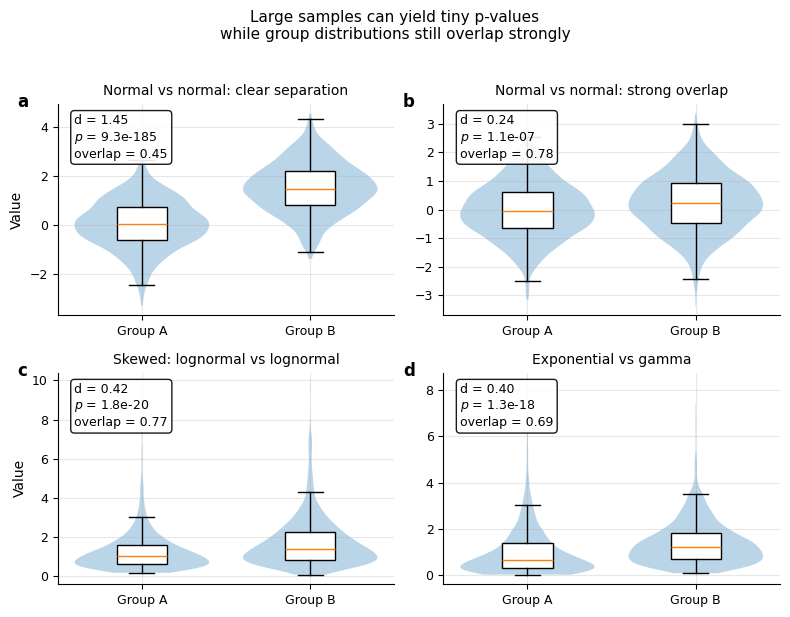

In [ ]:
def make_figure3_four_scenarios_raw(
        filename="Figure3_four_scenarios_raw.png",
        n=1000, seed=123):

    rng = np.random.default_rng(seed)
    scenarios = [
        ("a", "Normal vs normal: clear separation",   scen_normal_clear),
        ("b", "Normal vs normal: strong overlap",    scen_normal_overlap),
        ("c", "Skewed: lognormal vs lognormal",      scen_lognormal),
        ("d", "Exponential vs gamma",                scen_exponential_gamma),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=False)
    axes = axes.ravel()

    for ax, (letter, title, scen_fun) in zip(axes, scenarios):
        x, y = scen_fun(rng, n)
        d = cohen_d(x, y)
        _, p = ttest_ind(x, y, equal_var=False)
        ov = overlap_coefficient(x, y)

        parts = ax.violinplot([x, y],
                              positions=[1, 2],
                              showextrema=False,
                              widths=0.8)
        for pc in parts['bodies']:
            pc.set_alpha(0.3)

        box = ax.boxplot([x, y], positions=[1, 2], widths=0.3,
                         patch_artist=True, showfliers=False)
        for patch in box['boxes']:
            patch.set_facecolor("white")

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Group A", "Group B"])
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.3)

        ax.text(-0.12, 1.05, letter,
                transform=ax.transAxes,
                fontsize=12, fontweight="bold",
                va="top", ha="left")

        textstr = (f"d = {d:.2f}\n"
                   r"$p$" + f" = {p:.1e}\n"
                   f"overlap = {ov:.2f}")
        ax.text(0.05, 0.95, textstr,
                transform=ax.transAxes, va="top",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", edgecolor="black", alpha=0.9),
                fontsize=9)

    axes[0].set_ylabel("Value")
    axes[2].set_ylabel("Value")

    fig.suptitle("Large samples can yield tiny p-values\nwhile group distributions still overlap strongly",
                 fontsize=11, y=1.02)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Run
make_figure3_four_scenarios_raw()


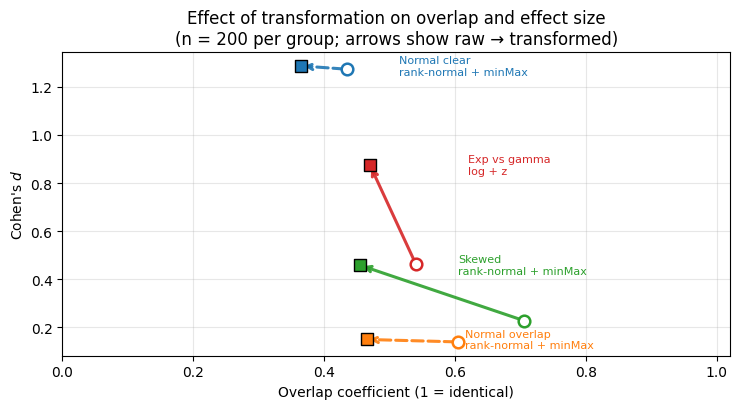

Saved figure as 'figure_overlap_before_after_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata, boxcox

# --------------------------------------------------------
# 1. Scenarios
# --------------------------------------------------------
def scen_normal_clear(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(1.5, 1, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(0.2, 1, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(0, 0.7, size=n)
    y = rng.lognormal(0.3, 0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed",         scen_lognormal),
    ("Exp vs gamma",   scen_exponential_gamma),
]

# --------------------------------------------------------
# 2. Effect size & overlap
# --------------------------------------------------------
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = x.var(ddof=1), y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

def overlap_index(x, y, nbins=200):
    """Approximate distributional overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

# --------------------------------------------------------
# 3. Transformations (8 of interest)
# --------------------------------------------------------
def zscore(x, y):
    allv = np.concatenate([x, y])
    mu, sd = allv.mean(), allv.std(ddof=1)
    return (x - mu)/sd, (y - mu)/sd

def ensure_positive(x, y, eps=1e-9):
    allv = np.concatenate([x, y])
    shift = 0.0
    if allv.min() <= 0:
        shift = -allv.min() + eps
    return x + shift, y + shift

def tf_z(x, y):
    return zscore(x, y)

def tf_log_z(x, y):
    x_p, y_p = ensure_positive(x, y)
    return zscore(np.log(x_p), np.log(y_p))

def tf_boxcox_z(x, y):
    x_p, y_p = ensure_positive(x, y)
    pooled = np.concatenate([x_p, y_p])
    bc, lam = boxcox(pooled)
    x_bc = bc[:len(x)]
    y_bc = bc[len(x):]
    return zscore(x_bc, y_bc)

def tf_ranknorm_z(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    return zscore(x_rn, y_rn)

def tf_minmax(x, y):
    allv = np.concatenate([x, y])
    lo, hi = allv.min(), allv.max()
    return (x - lo)/(hi - lo + 1e-12), (y - lo)/(hi - lo + 1e-12)

def tf_log_minmax(x, y):
    x_p, y_p = ensure_positive(x, y)
    allv = np.concatenate([x_p, y_p])
    logv = np.log(allv)
    lo, hi = logv.min(), logv.max()
    return (np.log(x_p) - lo)/(hi - lo + 1e-12), (np.log(y_p) - lo)/(hi - lo + 1e-12)

def tf_boxcox_minmax(x, y):
    x_p, y_p = ensure_positive(x, y)
    pooled = np.concatenate([x_p, y_p])
    bc, lam = boxcox(pooled)
    x_bc = bc[:len(x)]
    y_bc = bc[len(x):]
    allv = np.concatenate([x_bc, y_bc])
    lo, hi = allv.min(), allv.max()
    return (x_bc - lo)/(hi - lo + 1e-12), (y_bc - lo)/(hi - lo + 1e-12)

def tf_ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    return (x_rn - lo)/(hi - lo + 1e-12), (y_rn - lo)/(hi - lo + 1e-12)

transformations = [
    ("z-score",              tf_z),
    ("log + z",              tf_log_z),
    ("Box–Cox + z",          tf_boxcox_z),
    ("rank-normal + z",      tf_ranknorm_z),
    ("minMax",               tf_minmax),
    ("log + minMax",         tf_log_minmax),
    ("Box–Cox + minMax",     tf_boxcox_minmax),
    ("rank-normal + minMax", tf_ranknorm_minmax),
]

# --------------------------------------------------------
# 4. Find example per scenario (with graceful fallback)
# --------------------------------------------------------
def find_example_with_fallback(
        scen_fun, n,
        seed_start=0,
        max_seeds=5000,
        min_delta_d=0.05,
        min_delta_ov=0.02):
    """
    First tries to find a seed + transform where:
        |d_trans| > |d_raw| + min_delta_d
        overlap_trans < overlap_raw - min_delta_ov
    If none is found, falls back to the combo with the largest
    combined score:
        score = (|d_trans|-|d_raw|) + (overlap_raw - overlap_trans)
    Returns:
        x_raw, y_raw, x_best, y_best, d_raw, d_best,
        ov_raw, ov_best, best_name, both_improved (bool)
    """
    best_strict = None   # for "both clearly improved"
    best_global = None   # best trade-off across all seeds

    for s in range(seed_start, seed_start + max_seeds):
        rng = np.random.default_rng(s)
        x_raw, y_raw = scen_fun(rng, n)
        d_raw = cohen_d(x_raw, y_raw)
        ov_raw = overlap_index(x_raw, y_raw)

        for name, tfun in transformations:
            xt, yt = tfun(x_raw, y_raw)
            d_t = cohen_d(xt, yt)
            ov_t = overlap_index(xt, yt)

            delta_d  = np.abs(d_t) - np.abs(d_raw)
            delta_ov = ov_raw - ov_t
            score = delta_d + delta_ov

            record = {
                "x_raw": x_raw, "y_raw": y_raw,
                "x_best": xt,   "y_best": yt,
                "d_raw": d_raw, "d_best": d_t,
                "ov_raw": ov_raw, "ov_best": ov_t,
                "name": name,
                "score": score,
            }

            # Update global best (trade-off)
            if (best_global is None) or (score > best_global["score"]):
                best_global = record

            # Check strict criterion (both directions improved)
            if (delta_d > min_delta_d) and (delta_ov > min_delta_ov):
                if (best_strict is None) or (score > best_strict["score"]):
                    best_strict = record

    # Prefer strict "both improved", otherwise use best trade-off
    if best_strict is not None:
        r = best_strict
        both_improved = True
    else:
        r = best_global
        both_improved = False

    return (r["x_raw"], r["y_raw"], r["x_best"], r["y_best"],
            r["d_raw"], r["d_best"], r["ov_raw"], r["ov_best"],
            r["name"], both_improved)

# --------------------------------------------------------
# 5. Build data for all scenarios
# --------------------------------------------------------
n = 200  # per-group sample size

raw_pts   = []   # (ov, d, scen_idx)
best_pts  = []   # (ov, d, scen_idx)
best_names = []
improved_flags = []

for scen_idx, (s_name, s_fun) in enumerate(scenarios):
    (x_raw, y_raw, x_best, y_best,
     d_raw, d_best, ov_raw, ov_best,
     best_name, both_improved) = find_example_with_fallback(
        s_fun, n, seed_start=1000*scen_idx,
        max_seeds=4000,             # can increase if you want
        min_delta_d=0.05,
        min_delta_ov=0.02
    )

    raw_pts.append((ov_raw, d_raw, scen_idx))
    best_pts.append((ov_best, d_best, scen_idx))
    best_names.append(best_name)
    improved_flags.append(both_improved)

# --------------------------------------------------------
# 6. Plot: arrows raw → best for all four scenarios
# --------------------------------------------------------
scenario_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(7.5, 4.2))

for i, ((ov_raw, d_raw, scen_idx),
        (ov_best, d_best, _)) in enumerate(zip(raw_pts, best_pts)):
    scen_idx = int(scen_idx)
    color = scenario_colors[scen_idx]
    scen_label = scenarios[scen_idx][0]
    tr_name = best_names[i]
    both_improved = improved_flags[i]

    # arrow style: solid if both improved, dashed if trade-off
    linestyle = "-" if both_improved else "--"

    ax.annotate(
        "",
        xy=(ov_best, d_best),
        xytext=(ov_raw, d_raw),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2.2,
            linestyle=linestyle,
            alpha=0.9,
        ),
        zorder=2,
    )

    # raw point: open circle
    ax.scatter(
        ov_raw, d_raw,
        facecolors="white",
        edgecolors=color,
        s=70,
        linewidth=1.8,
        zorder=3,
        label=None,
    )

    # transformed point: filled square
    ax.scatter(
        ov_best, d_best,
        facecolors=color,
        edgecolors="black",
        marker="s",
        s=70,
        zorder=4,
        label=None,
    )

    # small annotation next to transformed point
    ax.text(
        ov_best + 0.15,
        d_best,
        f"{scen_label}\n{tr_name}",
        color=color,
        fontsize=8,
        va="center",
        ha="left",
    )

# helpful annotation box


ax.set_xlabel("Overlap coefficient (1 = identical)")
ax.set_ylabel(r"Cohen's $d$")
ax.set_title(
    "Effect of transformation on overlap and effect size\n"
    f"(n = {n} per group; arrows show raw → transformed)"
)
ax.grid(alpha=0.3)
ax.set_xlim(0.0, 1.02)

plt.tight_layout()
fig.savefig("figure_overlap_before_after_300dpi.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_overlap_before_after_300dpi.png'")


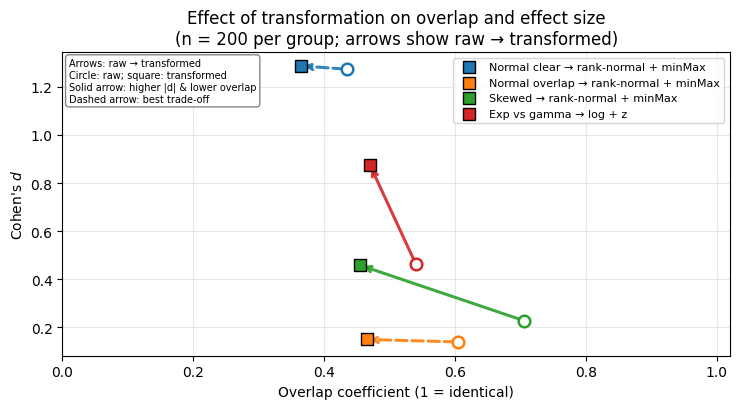

Saved figure as 'figure_overlap_before_after_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata, boxcox

# --------------------------------------------------------
# 1. Scenarios
# --------------------------------------------------------
def scen_normal_clear(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(1.5, 1, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(0.2, 1, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(0, 0.7, size=n)
    y = rng.lognormal(0.3, 0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed",         scen_lognormal),
    ("Exp vs gamma",   scen_exponential_gamma),
]

# --------------------------------------------------------
# 2. Effect size & overlap
# --------------------------------------------------------
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = x.var(ddof=1), y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

def overlap_index(x, y, nbins=200):
    """Approximate distributional overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

# --------------------------------------------------------
# 3. Transformations (8 of interest)
# --------------------------------------------------------
def zscore(x, y):
    allv = np.concatenate([x, y])
    mu, sd = allv.mean(), allv.std(ddof=1)
    return (x - mu)/sd, (y - mu)/sd

def ensure_positive(x, y, eps=1e-9):
    allv = np.concatenate([x, y])
    shift = 0.0
    if allv.min() <= 0:
        shift = -allv.min() + eps
    return x + shift, y + shift

def tf_z(x, y):
    return zscore(x, y)

def tf_log_z(x, y):
    x_p, y_p = ensure_positive(x, y)
    return zscore(np.log(x_p), np.log(y_p))

def tf_boxcox_z(x, y):
    x_p, y_p = ensure_positive(x, y)
    pooled = np.concatenate([x_p, y_p])
    bc, lam = boxcox(pooled)
    x_bc = bc[:len(x)]
    y_bc = bc[len(x):]
    return zscore(x_bc, y_bc)

def tf_ranknorm_z(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    return zscore(x_rn, y_rn)

def tf_minmax(x, y):
    allv = np.concatenate([x, y])
    lo, hi = allv.min(), allv.max()
    return (x - lo)/(hi - lo + 1e-12), (y - lo)/(hi - lo + 1e-12)

def tf_log_minmax(x, y):
    x_p, y_p = ensure_positive(x, y)
    allv = np.concatenate([x_p, y_p])
    logv = np.log(allv)
    lo, hi = logv.min(), logv.max()
    return (np.log(x_p) - lo)/(hi - lo + 1e-12), (np.log(y_p) - lo)/(hi - lo + 1e-12)

def tf_boxcox_minmax(x, y):
    x_p, y_p = ensure_positive(x, y)
    pooled = np.concatenate([x_p, y_p])
    bc, lam = boxcox(pooled)
    x_bc = bc[:len(x)]
    y_bc = bc[len(x):]
    allv = np.concatenate([x_bc, y_bc])
    lo, hi = allv.min(), allv.max()
    return (x_bc - lo)/(hi - lo + 1e-12), (y_bc - lo)/(hi - lo + 1e-12)

def tf_ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    return (x_rn - lo)/(hi - lo + 1e-12), (y_rn - lo)/(hi - lo + 1e-12)

transformations = [
    ("z-score",              tf_z),
    ("log + z",              tf_log_z),
    ("Box–Cox + z",          tf_boxcox_z),
    ("rank-normal + z",      tf_ranknorm_z),
    ("minMax",               tf_minmax),
    ("log + minMax",         tf_log_minmax),
    ("Box–Cox + minMax",     tf_boxcox_minmax),
    ("rank-normal + minMax", tf_ranknorm_minmax),
]

# --------------------------------------------------------
# 4. Find example per scenario (with graceful fallback)
# --------------------------------------------------------
def find_example_with_fallback(
        scen_fun, n,
        seed_start=0,
        max_seeds=5000,
        min_delta_d=0.05,
        min_delta_ov=0.02):

    best_strict = None   # for "both clearly improved"
    best_global = None   # best trade-off across all seeds

    for s in range(seed_start, seed_start + max_seeds):
        rng = np.random.default_rng(s)
        x_raw, y_raw = scen_fun(rng, n)
        d_raw = cohen_d(x_raw, y_raw)
        ov_raw = overlap_index(x_raw, y_raw)

        for name, tfun in transformations:
            xt, yt = tfun(x_raw, y_raw)
            d_t = cohen_d(xt, yt)
            ov_t = overlap_index(xt, yt)

            delta_d  = np.abs(d_t) - np.abs(d_raw)
            delta_ov = ov_raw - ov_t
            score = delta_d + delta_ov

            record = {
                "x_raw": x_raw, "y_raw": y_raw,
                "x_best": xt,   "y_best": yt,
                "d_raw": d_raw, "d_best": d_t,
                "ov_raw": ov_raw, "ov_best": ov_t,
                "name": name,
                "score": score,
            }

            if (best_global is None) or (score > best_global["score"]):
                best_global = record

            if (delta_d > min_delta_d) and (delta_ov > min_delta_ov):
                if (best_strict is None) or (score > best_strict["score"]):
                    best_strict = record

    if best_strict is not None:
        r = best_strict
        both_improved = True
    else:
        r = best_global
        both_improved = False

    return (r["x_raw"], r["y_raw"], r["x_best"], r["y_best"],
            r["d_raw"], r["d_best"], r["ov_raw"], r["ov_best"],
            r["name"], both_improved)

# --------------------------------------------------------
# 5. Build data for all scenarios
# --------------------------------------------------------
n = 200  # per-group sample size

raw_pts   = []   # (ov, d, scen_idx)
best_pts  = []   # (ov, d, scen_idx)
best_names = []
improved_flags = []

for scen_idx, (s_name, s_fun) in enumerate(scenarios):
    (x_raw, y_raw, x_best, y_best,
     d_raw, d_best, ov_raw, ov_best,
     best_name, both_improved) = find_example_with_fallback(
        s_fun, n, seed_start=1000*scen_idx,
        max_seeds=4000,
        min_delta_d=0.05,
        min_delta_ov=0.02
    )

    raw_pts.append((ov_raw, d_raw, scen_idx))
    best_pts.append((ov_best, d_best, scen_idx))
    best_names.append(best_name)
    improved_flags.append(both_improved)

# --------------------------------------------------------
# 6. Plot: arrows raw → best for all four scenarios
# --------------------------------------------------------
scenario_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
legend_handles = []

for i, ((ov_raw, d_raw, scen_idx),
        (ov_best, d_best, _)) in enumerate(zip(raw_pts, best_pts)):
    scen_idx = int(scen_idx)
    color = scenario_colors[scen_idx]
    scen_label = scenarios[scen_idx][0]
    tr_name = best_names[i]
    both_improved = improved_flags[i]

    linestyle = "-" if both_improved else "--"

    # arrow raw -> transformed
    arr = ax.annotate(
        "",
        xy=(ov_best, d_best),
        xytext=(ov_raw, d_raw),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2.2,
            linestyle=linestyle,
            alpha=0.9,
        ),
        zorder=2,
    )

    # raw point: open circle
    raw_scatter = ax.scatter(
        ov_raw, d_raw,
        facecolors="white",
        edgecolors=color,
        s=70,
        linewidth=1.8,
        zorder=3,
    )

    # transformed point: filled square
    best_scatter = ax.scatter(
        ov_best, d_best,
        facecolors=color,
        edgecolors="black",
        marker="s",
        s=70,
        zorder=4,
    )

    # one legend entry per scenario: “Scenario → transform”
    label = f"{scen_label} → {tr_name}"
    legend_handles.append((best_scatter, label))

# annotation box explaining styles
ax.text(
    0.01, 0.98,
    "Arrows: raw → transformed\n"
    "Circle: raw; square: transformed\n"
    "Solid arrow: higher |d| & lower overlap\n"
    "Dashed arrow: best trade-off",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=7,
    bbox=dict(boxstyle="round,pad=0.35",
              facecolor="white", edgecolor="grey", alpha=0.95),
)

# scenario + transform legend (top-right)
handles, labels = zip(*legend_handles)
ax.legend(handles, labels,
          loc="upper right",
          fontsize=8,
          frameon=True)

ax.set_xlabel("Overlap coefficient (1 = identical)")
ax.set_ylabel(r"Cohen's $d$")
ax.set_title(
    "Effect of transformation on overlap and effect size\n"
    f"(n = {n} per group; arrows show raw → transformed)"
)
ax.grid(alpha=0.3)
ax.set_xlim(0.0, 1.02)

plt.tight_layout()
fig.savefig("figure_overlap_before_after_300dpi.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_overlap_before_after_300dpi.png'")


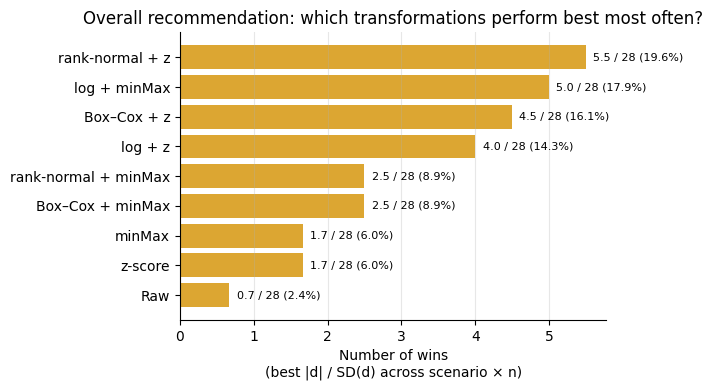

Saved Figure 5 to: figure5_overall_recommendation_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size: Cohen's d
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

# =========================================================
# 3. Basic helpers: z-score & min–max
# =========================================================
def zscore(x):
    mu = x.mean()
    sd = x.std(ddof=1)
    return (x - mu) / sd

def zscore_two(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_two(x, y):
    data = np.concatenate([x, y])
    lo = data.min()
    hi = data.max()
    if hi == lo:
        return np.zeros_like(x), np.zeros_like(y)
    return (x - lo) / (hi - lo), (y - lo) / (hi - lo)

# =========================================================
# 4. All transformations (incl. Raw) in a single function
# =========================================================
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]

all_labels = ["Raw"] + transform_labels  # Raw first
n_transforms = len(all_labels)

def apply_all_with_raw(x_raw, y_raw):
    """
    Return list of (x_t, y_t) in the same order as 'all_labels':
      0: Raw (no transform)
      1: z-score
      2: log + z
      3: Box–Cox + z
      4: rank-normal + z
      5: minMax
      6: log + minMax
      7: Box–Cox + minMax
      8: rank-normal + minMax
    """
    results = []

    # 0) Raw
    results.append((x_raw, y_raw))

    # Prepare shared things
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])

    # Shift to positive for log / Box–Cox
    shift = 0.0
    if pooled_raw.min() <= 0:
        shift = -pooled_raw.min() + eps
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # ---- z-score ----
    x_z, y_z = zscore_two(x_raw, y_raw)
    results.append((x_z, y_z))

    # ---- log + z ----
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)
    x_log_z, y_log_z = zscore_two(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # ---- Box–Cox + z ----
    pooled_pos = np.concatenate([x_pos, y_pos])
    bc_all, lam = boxcox(pooled_pos)
    x_bc = bc_all[:len(x_raw)]
    y_bc = bc_all[len(x_raw):]
    x_bc_z, y_bc_z = zscore_two(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # ---- rank-normal + z ----
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    rn_all = norm.ppf(u)
    x_rn = rn_all[:len(x_raw)]
    y_rn = rn_all[len(x_raw):]
    x_rn_z, y_rn_z = zscore_two(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # ---- minMax ----
    x_mm, y_mm = minmax_two(x_raw, y_raw)
    results.append((x_mm, y_mm))

    # ---- log + minMax ----
    x_log_mm, y_log_mm = minmax_two(x_log, y_log)
    results.append((x_log_mm, y_log_mm))

    # ---- Box–Cox + minMax ----
    x_bc_mm, y_bc_mm = minmax_two(x_bc, y_bc)
    results.append((x_bc_mm, y_bc_mm))

    # ---- rank-normal + minMax ----
    x_rn_mm, y_rn_mm = minmax_two(x_rn, y_rn)
    results.append((x_rn_mm, y_rn_mm))

    return results

# =========================================================
# 5. SNR simulation for one scenario
# =========================================================
def simulate_snr_grid(scen_fun, ns, n_rep=400, seed=123):
    """
    For a given scenario, compute SNR = |mean d| / SD(d)
    for each transformation × sample size.
    Returns snr with shape (n_transforms, len(ns)).
    """
    rng = np.random.default_rng(seed)
    mean_d = np.zeros((n_transforms, len(ns)))
    sd_d   = np.zeros_like(mean_d)

    for j, n in enumerate(ns):
        d_lists = [[] for _ in range(n_transforms)]
        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            pairs = apply_all_with_raw(x_raw, y_raw)
            for k, (xt, yt) in enumerate(pairs):
                d_lists[k].append(cohen_d(xt, yt))

        for k in range(n_transforms):
            ds = np.asarray(d_lists[k])
            mean_d[k, j] = ds.mean()
            sd_d[k, j]   = ds.std(ddof=1)

    snr = np.abs(mean_d) / sd_d
    return snr

# =========================================================
# 6. Figure 5: overall recommendation bar plot
# =========================================================
def make_overall_recommendation_figure(
        filename="figure5_overall_recommendation_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=400,
        seed=123,
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    winner_counts = np.zeros(n_transforms, dtype=float)

    for _, scen_fun in scenarios:
        snr = simulate_snr_grid(scen_fun, ns, n_rep=n_rep, seed=seed)
        for j in range(len(ns)):
            col = snr[:, j]
            best = np.argwhere(col == col.max()).flatten()
            # split a "win" equally among ties
            for idx in best:
                winner_counts[idx] += 1.0 / len(best)

    total_cases = len(scenarios) * len(ns)

    # sort from worst to best so best appears at top of plot
    order = np.argsort(winner_counts)
    counts_sorted = winner_counts[order]
    labels_sorted = np.array(all_labels)[order]

    fig, ax = plt.subplots(figsize=(7, 4))

    bars = ax.barh(labels_sorted, counts_sorted, color="#d99d1c", alpha=0.9)
    ax.set_xlabel("Number of wins\n(best |d| / SD(d) across scenario × n)")
    ax.set_title("Overall recommendation: which transformations perform best most often?")

    for rect, cnt in zip(bars, counts_sorted):
        pct = 100.0 * cnt / total_cases
        ax.text(
            rect.get_width() + 0.1,
            rect.get_y() + rect.get_height() / 2,
            f"{cnt:.1f} / {total_cases} ({pct:.1f}%)",
            va="center",
            fontsize=8,
        )

    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure 5 to: {filename}")

# ---------------------------------------------------------
# Run to generate Figure 5
# ---------------------------------------------------------
make_overall_recommendation_figure()


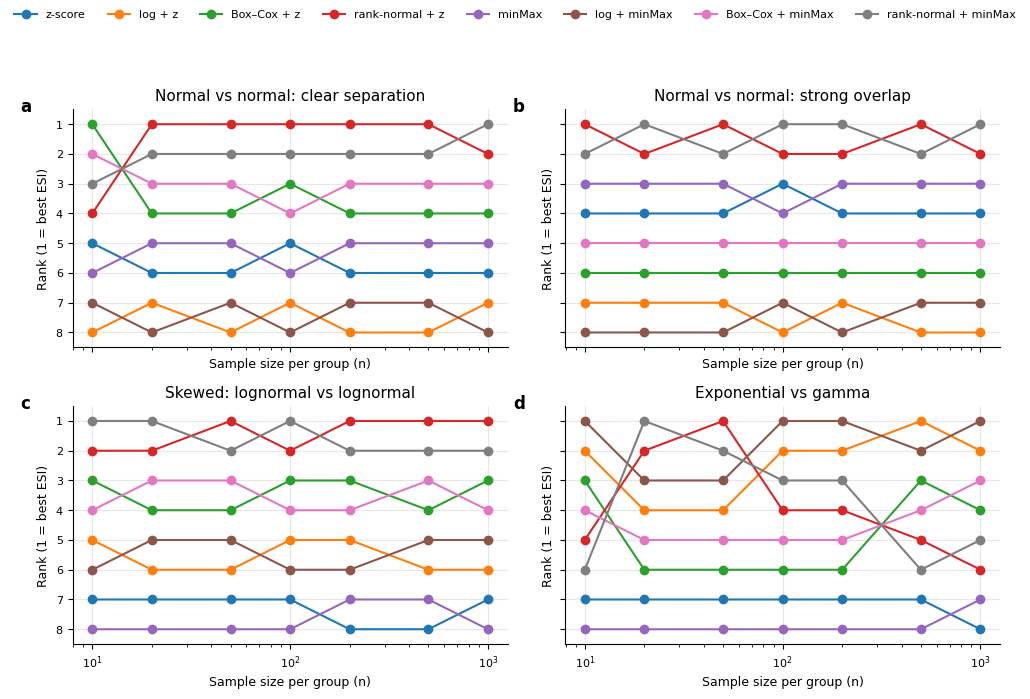

Saved rank-vs-n ESI matrix to: fig_rank_vs_n_ESI_4scenarios_300dpi.png


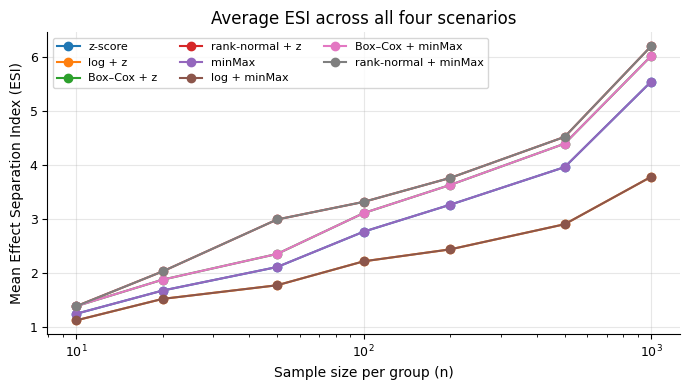

Saved overall ESI summary to: fig_overall_ESI_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size & overlap
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap: 1 = identical, 0 = no overlap.
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]  # bin width

    # normalise just in case numerical integration isn't exactly 1
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# =========================================================
# 3. Normalisation helpers
# =========================================================
def zscore_normalize(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_normalize(x, y):
    data = np.concatenate([x, y])
    mn = data.min()
    mx = data.max()
    denom = mx - mn if mx > mn else 1.0
    return (x - mn) / denom, (y - mn) / denom

# =========================================================
# 4. Transformations (8 only)
# =========================================================
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]
n_transforms = len(transform_labels)

def apply_all_transforms(x_raw, y_raw):
    """
    Return list of (x_t, y_t) for the 8 transforms:
      0: z-score
      1: log + z
      2: Box–Cox + z
      3: rank-normal + z
      4: minMax
      5: log + minMax
      6: Box–Cox + minMax
      7: rank-normal + minMax
    """
    results = []

    pooled_raw = np.concatenate([x_raw, y_raw])

    # Ensure positivity for log / Box–Cox
    eps = 1e-9
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    pooled_pos = np.concatenate([x_pos, y_pos])
    pooled_bc, lam = boxcox(pooled_pos)
    x_bc = pooled_bc[:len(x_raw)]
    y_bc = pooled_bc[len(x_raw):]

    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    pooled_rn = norm.ppf(u)
    x_rn = pooled_rn[:len(x_raw)]
    y_rn = pooled_rn[len(x_raw):]

    # 0) z-score
    results.append(zscore_normalize(x_raw, y_raw))

    # 1) log + z
    results.append(zscore_normalize(x_log, y_log))

    # 2) Box–Cox + z
    results.append(zscore_normalize(x_bc, y_bc))

    # 3) rank-normal + z
    results.append(zscore_normalize(x_rn, y_rn))

    # 4) minMax on raw
    results.append(minmax_normalize(x_raw, y_raw))

    # 5) log + minMax
    results.append(minmax_normalize(x_log, y_log))

    # 6) Box–Cox + minMax
    results.append(minmax_normalize(x_bc, y_bc))

    # 7) rank-normal + minMax
    results.append(minmax_normalize(x_rn, y_rn))

    return results

# =========================================================
# 5. Simulate Effect Separation Index (ESI) grid
# =========================================================
def simulate_esi_grid(scen_fun, ns, n_rep=500, seed=123):
    """
    For a given scenario, compute Effect Separation Index (ESI)
    for each transformation × sample size.

    For each transform k and sample size n:
        - simulate d across n_rep replicates
        - simulate overlap across n_rep replicates
        - compute:
            mean_d  = mean(d)
            sd_d    = SD(d)
            mean_ov = mean(overlap)
            SNR     = |mean_d| / sd_d
            ESI     = SNR * (1 - mean_ov)

    Returns:
      esi : array shape (n_transforms, len(ns))
    """
    rng = np.random.default_rng(seed)
    mean_d  = np.zeros((n_transforms, len(ns)))
    sd_d    = np.zeros((n_transforms, len(ns)))
    mean_ov = np.zeros((n_transforms, len(ns)))

    for j, n in enumerate(ns):
        d_lists  = [[] for _ in range(n_transforms)]
        ov_lists = [[] for _ in range(n_transforms)]

        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)

            transformed_pairs = apply_all_transforms(x_raw, y_raw)

            for k, (xt, yt) in enumerate(transformed_pairs):
                d_lists[k].append(cohen_d(xt, yt))
                ov_lists[k].append(overlap_index(xt, yt))

        for k in range(n_transforms):
            ds = np.asarray(d_lists[k])
            ovs = np.asarray(ov_lists[k])

            mean_d[k, j]  = ds.mean()
            sd_d[k, j]    = ds.std(ddof=1)
            mean_ov[k, j] = ovs.mean()

    # Effect Separation Index:
    #   ESI = (|mean_d| / sd_d) * (1 - mean_ov)
    snr = np.abs(mean_d) / (sd_d + 1e-12)
    esi = snr * (1.0 - mean_ov)

    return esi

# =========================================================
# 6A. Figure 1 – Rank vs n for each scenario using ESI
# =========================================================
def make_rank_vs_n_matrix(
        filename="fig_rank_vs_n_ESI_4scenarios_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=500, seed=123
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 9
    plt.rcParams["xtick.labelsize"] = 8
    plt.rcParams["ytick.labelsize"] = 8

    scenarios = [
        ("Normal vs normal: clear separation", scen_normal_clear),
        ("Normal vs normal: strong overlap",   scen_normal_overlap),
        ("Skewed: lognormal vs lognormal",     scen_lognormal),
        ("Exponential vs gamma",               scen_exponential_gamma),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, (label, scen_fun), letter in zip(axes, scenarios, letters):
        esi = simulate_esi_grid(scen_fun, ns, n_rep=n_rep, seed=seed)

        # Rank transformations for each n (1 = best ESI)
        ranks = np.zeros_like(esi)
        for j in range(len(ns)):
            order = np.argsort(-esi[:, j])  # descending ESI
            rank_values = np.empty(n_transforms, dtype=int)
            rank_values[order] = np.arange(1, n_transforms + 1)
            ranks[:, j] = rank_values

        for k in range(n_transforms):
            ax.plot(
                ns,
                ranks[k, :],
                marker="o",
                linestyle="-",
                color=color_cycle[k % len(color_cycle)],
                label=transform_labels[k],
            )

        ax.set_xscale("log")
        ax.set_ylim(0.5, n_transforms + 0.5)
        ax.set_yticks(range(1, n_transforms + 1))
        ax.invert_yaxis()  # rank 1 at the top
        ax.set_xlabel("Sample size per group (n)")
        ax.set_ylabel("Rank (1 = best ESI)")
        ax.set_title(label, fontsize=11)
        ax.grid(alpha=0.3)

        # Panel letter
        ax.text(-0.12, 1.05, letter,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                va="top", ha="left")

    # Single legend on top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=n_transforms,
        fontsize=8,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved rank-vs-n ESI matrix to: {filename}")

# =========================================================
# 6B. Figure 2 – Overall mean ESI across scenarios
# =========================================================
def make_overall_esi_summary(
        filename="fig_overall_ESI_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=500, seed=123
    ):
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 10
    plt.rcParams["xtick.labelsize"] = 9
    plt.rcParams["ytick.labelsize"] = 9

    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    # esi_all shape: (n_scenarios, n_transforms, len(ns))
    esi_all = []
    for _, scen_fun in scenarios:
        esi_all.append(simulate_esi_grid(scen_fun, ns, n_rep=n_rep, seed=seed))
    esi_all = np.stack(esi_all, axis=0)

    # Mean ESI across scenarios
    mean_esi = esi_all.mean(axis=0)  # shape: (n_transforms, len(ns))

    fig, ax = plt.subplots(figsize=(7, 4))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for k in range(n_transforms):
        ax.plot(
            ns,
            mean_esi[k, :],
            marker="o",
            linestyle="-",
            color=color_cycle[k % len(color_cycle)],
            label=transform_labels[k],
        )

    ax.set_xscale("log")
    ax.set_xlabel("Sample size per group (n)")
    ax.set_ylabel("Mean Effect Separation Index (ESI)")
    ax.set_title("Average ESI across all four scenarios")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved overall ESI summary to: {filename}")

# =========================================================
# Run once to generate both ESI figures
# =========================================================
ns_values = (10, 20, 50, 100, 200, 500, 1000)
make_rank_vs_n_matrix(ns=ns_values, n_rep=300, seed=123)  # you can increase n_rep if needed
make_overall_esi_summary(ns=ns_values, n_rep=300, seed=123)


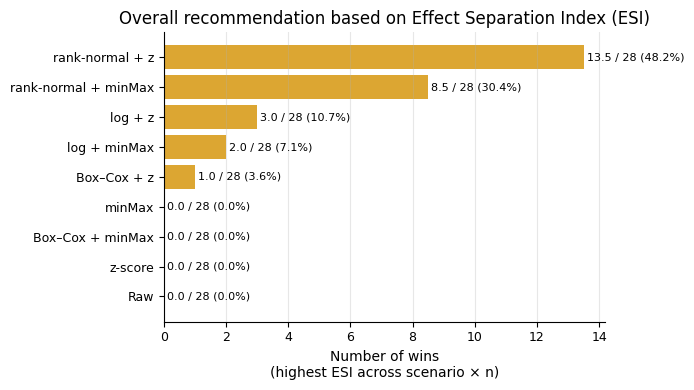

Saved ESI-based overall recommendation figure to: figure5_overall_recommendation_ESI_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size & overlap
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap:
    1 = identical distributions, 0 = no overlap.
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]

    # normalise for numerical stability
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# =========================================================
# 3. Basic helpers: z-score & min–max
# =========================================================
def zscore(x):
    mu = x.mean()
    sd = x.std(ddof=1)
    return (x - mu) / sd

def zscore_two(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_two(x, y):
    data = np.concatenate([x, y])
    lo = data.min()
    hi = data.max()
    if hi == lo:
        return np.zeros_like(x), np.zeros_like(y)
    return (x - lo) / (hi - lo), (y - lo) / (hi - lo)

# =========================================================
# 4. All transformations (incl. Raw)
# =========================================================
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]

all_labels = ["Raw"] + transform_labels  # Raw first
n_transforms = len(all_labels)

def apply_all_with_raw(x_raw, y_raw):
    """
    Return list of (x_t, y_t) in the same order as 'all_labels':
      0: Raw (no transform)
      1: z-score
      2: log + z
      3: Box–Cox + z
      4: rank-normal + z
      5: minMax
      6: log + minMax
      7: Box–Cox + minMax
      8: rank-normal + minMax
    """
    results = []

    # 0) Raw
    results.append((x_raw, y_raw))

    # Shared quantities
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])

    # Shift to positive for log / Box–Cox
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # log and Box–Cox
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    pooled_pos = np.concatenate([x_pos, y_pos])
    bc_all, lam = boxcox(pooled_pos)
    x_bc = bc_all[:len(x_raw)]
    y_bc = bc_all[len(x_raw):]

    # rank-normal
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    rn_all = norm.ppf(u)
    x_rn = rn_all[:len(x_raw)]
    y_rn = rn_all[len(x_raw):]

    # 1) z-score
    x_z, y_z = zscore_two(x_raw, y_raw)
    results.append((x_z, y_z))

    # 2) log + z
    x_log_z, y_log_z = zscore_two(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # 3) Box–Cox + z
    x_bc_z, y_bc_z = zscore_two(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # 4) rank-normal + z
    x_rn_z, y_rn_z = zscore_two(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # 5) minMax
    x_mm, y_mm = minmax_two(x_raw, y_raw)
    results.append((x_mm, y_mm))

    # 6) log + minMax
    x_log_mm, y_log_mm = minmax_two(x_log, y_log)
    results.append((x_log_mm, y_log_mm))

    # 7) Box–Cox + minMax
    x_bc_mm, y_bc_mm = minmax_two(x_bc, y_bc)
    results.append((x_bc_mm, y_bc_mm))

    # 8) rank-normal + minMax
    x_rn_mm, y_rn_mm = minmax_two(x_rn, y_rn)
    results.append((x_rn_mm, y_rn_mm))

    return results

# =========================================================
# 5. ESI simulation for one scenario
# =========================================================
def simulate_esi_grid(scen_fun, ns, n_rep=400, seed=123):
    """
    For a given scenario, compute Effect Separation Index (ESI)
    for each transformation × sample size.

    For each transform k and sample size n:
        - simulate d across n_rep replicates
        - simulate overlap across n_rep replicates
        - compute:
            mean_d  = mean(d)
            sd_d    = SD(d)
            mean_ov = mean(overlap)
            SNR     = |mean_d| / sd_d
            ESI     = SNR * (1 - mean_ov)

    Returns:
      esi : array shape (n_transforms, len(ns)).
    """
    rng = np.random.default_rng(seed)
    mean_d  = np.zeros((n_transforms, len(ns)))
    sd_d    = np.zeros_like(mean_d)
    mean_ov = np.zeros_like(mean_d)

    for j, n in enumerate(ns):
        d_lists  = [[] for _ in range(n_transforms)]
        ov_lists = [[] for _ in range(n_transforms)]

        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            pairs = apply_all_with_raw(x_raw, y_raw)

            for k, (xt, yt) in enumerate(pairs):
                d_lists[k].append(cohen_d(xt, yt))
                ov_lists[k].append(overlap_index(xt, yt))

        for k in range(n_transforms):
            ds  = np.asarray(d_lists[k])
            ovs = np.asarray(ov_lists[k])

            mean_d[k, j]  = ds.mean()
            sd_d[k, j]    = ds.std(ddof=1)
            mean_ov[k, j] = ovs.mean()

    snr = np.abs(mean_d) / (sd_d + 1e-12)
    esi = snr * (1.0 - mean_ov)   # Effect Separation Index

    return esi

# =========================================================
# 6. Figure: overall recommendation bar plot based on ESI
# =========================================================
def make_overall_recommendation_figure_ESI(
        filename="figure5_overall_recommendation_ESI_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=400,
        seed=123,
    ):
    """
    For each scenario and each n, find which transformation
    has the highest ESI, and count wins across all scenario × n
    combinations. Plot as a horizontal bar chart.
    """
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    winner_counts = np.zeros(n_transforms, dtype=float)

    for _, scen_fun in scenarios:
        esi = simulate_esi_grid(scen_fun, ns, n_rep=n_rep, seed=seed)
        for j in range(len(ns)):
            col = esi[:, j]
            best = np.argwhere(col == col.max()).flatten()
            # split a "win" equally among ties
            for idx in best:
                winner_counts[idx] += 1.0 / len(best)

    total_cases = len(scenarios) * len(ns)

    # sort from worst to best so best appears at top
    order = np.argsort(winner_counts)
    counts_sorted = winner_counts[order]
    labels_sorted = np.array(all_labels)[order]

    fig, ax = plt.subplots(figsize=(7, 4))

    bars = ax.barh(labels_sorted, counts_sorted, color="#d99d1c", alpha=0.9)
    ax.set_xlabel("Number of wins\n(highest ESI across scenario × n)")
    ax.set_title("Overall recommendation based on Effect Separation Index (ESI)")

    for rect, cnt in zip(bars, counts_sorted):
        pct = 100.0 * cnt / total_cases
        ax.text(
            rect.get_width() + 0.1,
            rect.get_y() + rect.get_height() / 2,
            f"{cnt:.1f} / {total_cases} ({pct:.1f}%)",
            va="center",
            fontsize=8,
        )

    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved ESI-based overall recommendation figure to: {filename}")

# ---------------------------------------------------------
# Run to generate the ESI-based Figure 5
# ---------------------------------------------------------
make_overall_recommendation_figure_ESI()


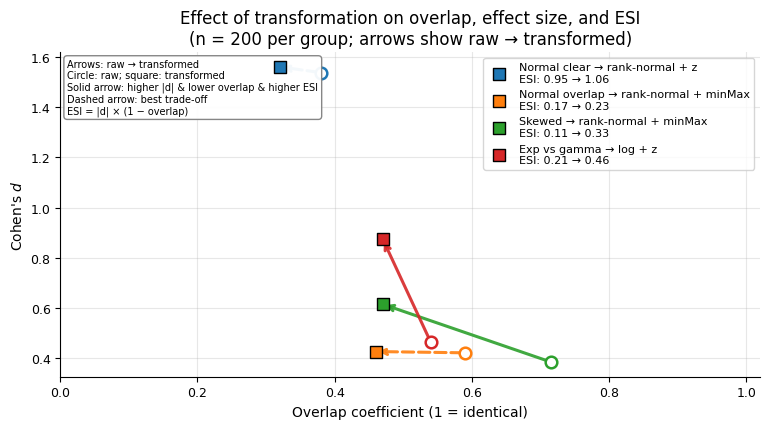

Saved figure as 'figure_overlap_before_after_ESI_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata, boxcox

# --------------------------------------------------------
# 1. Scenarios
# --------------------------------------------------------
def scen_normal_clear(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(1.5, 1, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(0.2, 1, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(0, 0.7, size=n)
    y = rng.lognormal(0.3, 0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed",         scen_lognormal),
    ("Exp vs gamma",   scen_exponential_gamma),
]

# --------------------------------------------------------
# 2. Effect size, overlap, and ESI
# --------------------------------------------------------
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = x.var(ddof=1), y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / s_pooled

def overlap_index(x, y, nbins=200):
    """Approximate distributional overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def effect_separation_index(d, ov):
    """
    Pointwise Effect Separation Index (ESI) for a single dataset:
        ESI = |d| * (1 - overlap)
    Larger is better: bigger standardized difference + smaller overlap.
    """
    return np.abs(d) * (1.0 - ov)

# --------------------------------------------------------
# 3. Transformations (8 of interest)
# --------------------------------------------------------
def zscore(x, y):
    allv = np.concatenate([x, y])
    mu, sd = allv.mean(), allv.std(ddof=1)
    return (x - mu)/sd, (y - mu)/sd

def ensure_positive(x, y, eps=1e-9):
    allv = np.concatenate([x, y])
    shift = 0.0
    if allv.min() <= 0:
        shift = -allv.min() + eps
    return x + shift, y + shift

def tf_z(x, y):
    return zscore(x, y)

def tf_log_z(x, y):
    x_p, y_p = ensure_positive(x, y)
    return zscore(np.log(x_p), np.log(y_p))

def tf_boxcox_z(x, y):
    x_p, y_p = ensure_positive(x, y)
    pooled = np.concatenate([x_p, y_p])
    bc, lam = boxcox(pooled)
    x_bc = bc[:len(x)]
    y_bc = bc[len(x):]
    return zscore(x_bc, y_bc)

def tf_ranknorm_z(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    return zscore(x_rn, y_rn)

def tf_minmax(x, y):
    allv = np.concatenate([x, y])
    lo, hi = allv.min(), allv.max()
    return (x - lo)/(hi - lo + 1e-12), (y - lo)/(hi - lo + 1e-12)

def tf_log_minmax(x, y):
    x_p, y_p = ensure_positive(x, y)
    allv = np.concatenate([x_p, y_p])
    logv = np.log(allv)
    lo, hi = logv.min(), logv.max()
    return (np.log(x_p) - lo)/(hi - lo + 1e-12), (np.log(y_p) - lo)/(hi - lo + 1e-12)

def tf_boxcox_minmax(x, y):
    x_p, y_p = ensure_positive(x, y)
    pooled = np.concatenate([x_p, y_p])
    bc, lam = boxcox(pooled)
    x_bc = bc[:len(x)]
    y_bc = bc[len(x):]
    allv = np.concatenate([x_bc, y_bc])
    lo, hi = allv.min(), allv.max()
    return (x_bc - lo)/(hi - lo + 1e-12), (y_bc - lo)/(hi - lo + 1e-12)

def tf_ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    return (x_rn - lo)/(hi - lo + 1e-12), (y_rn - lo)/(hi - lo + 1e-12)

transformations = [
    ("z-score",              tf_z),
    ("log + z",              tf_log_z),
    ("Box–Cox + z",          tf_boxcox_z),
    ("rank-normal + z",      tf_ranknorm_z),
    ("minMax",               tf_minmax),
    ("log + minMax",         tf_log_minmax),
    ("Box–Cox + minMax",     tf_boxcox_minmax),
    ("rank-normal + minMax", tf_ranknorm_minmax),
]

# --------------------------------------------------------
# 4. Find example per scenario (with ESI-aware score)
# --------------------------------------------------------
def find_example_with_fallback(
        scen_fun, n,
        seed_start=0,
        max_seeds=5000,
        min_delta_d=0.05,
        min_delta_ov=0.02):

    best_strict = None   # for "both clearly improved" (d and overlap)
    best_global = None   # best trade-off across all seeds (using ESI-like score)

    for s in range(seed_start, seed_start + max_seeds):
        rng = np.random.default_rng(s)
        x_raw, y_raw = scen_fun(rng, n)
        d_raw = cohen_d(x_raw, y_raw)
        ov_raw = overlap_index(x_raw, y_raw)
        esi_raw = effect_separation_index(d_raw, ov_raw)

        for name, tfun in transformations:
            xt, yt = tfun(x_raw, y_raw)
            d_t  = cohen_d(xt, yt)
            ov_t = overlap_index(xt, yt)
            esi_t = effect_separation_index(d_t, ov_t)

            delta_d  = np.abs(d_t) - np.abs(d_raw)
            delta_ov = ov_raw - ov_t
            delta_esi = esi_t - esi_raw

            # Combined score: change in ESI (primary), then d and overlap
            score = delta_esi + 0.25*delta_d + 0.25*delta_ov

            record = {
                "x_raw": x_raw, "y_raw": y_raw,
                "x_best": xt,   "y_best": yt,
                "d_raw": d_raw, "d_best": d_t,
                "ov_raw": ov_raw, "ov_best": ov_t,
                "esi_raw": esi_raw, "esi_best": esi_t,
                "name": name,
                "score": score,
                "delta_d": delta_d,
                "delta_ov": delta_ov,
                "delta_esi": delta_esi,
            }

            # Update global best (trade-off)
            if (best_global is None) or (score > best_global["score"]):
                best_global = record

            # Strict criterion: both d and overlap clearly improved
            if (delta_d > min_delta_d) and (delta_ov > min_delta_ov) and (delta_esi > 0):
                if (best_strict is None) or (score > best_strict["score"]):
                    best_strict = record

    # Prefer strict "both improved", otherwise use best trade-off
    if best_strict is not None:
        r = best_strict
        both_improved = True
    else:
        r = best_global
        both_improved = False

    return (r["x_raw"], r["y_raw"], r["x_best"], r["y_best"],
            r["d_raw"], r["d_best"],
            r["ov_raw"], r["ov_best"],
            r["esi_raw"], r["esi_best"],
            r["name"], both_improved)

# --------------------------------------------------------
# 5. Build data for all scenarios
# --------------------------------------------------------
n = 200  # per-group sample size

raw_pts      = []   # (ov, d, scen_idx, esi)
best_pts     = []   # (ov, d, scen_idx, esi)
best_names   = []
improved_flags = []

for scen_idx, (s_name, s_fun) in enumerate(scenarios):
    (x_raw, y_raw, x_best, y_best,
     d_raw, d_best,
     ov_raw, ov_best,
     esi_raw, esi_best,
     best_name, both_improved) = find_example_with_fallback(
        s_fun, n, seed_start=1000*scen_idx,
        max_seeds=4000,
        min_delta_d=0.05,
        min_delta_ov=0.02
    )

    raw_pts.append((ov_raw, d_raw, scen_idx, esi_raw))
    best_pts.append((ov_best, d_best, scen_idx, esi_best))
    best_names.append(best_name)
    improved_flags.append(both_improved)

# --------------------------------------------------------
# 6. Plot: arrows raw → best for all four scenarios (with ESI)
# --------------------------------------------------------
scenario_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(7.8, 4.4))
legend_handles = []

for i, (raw_info, best_info) in enumerate(zip(raw_pts, best_pts)):
    ov_raw, d_raw, scen_idx, esi_raw = raw_info
    ov_best, d_best, _, esi_best = best_info

    scen_idx = int(scen_idx)
    color = scenario_colors[scen_idx]
    scen_label = scenarios[scen_idx][0]
    tr_name = best_names[i]
    both_improved = improved_flags[i]

    linestyle = "-" if both_improved else "--"

    # arrow raw -> transformed
    ax.annotate(
        "",
        xy=(ov_best, d_best),
        xytext=(ov_raw, d_raw),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2.2,
            linestyle=linestyle,
            alpha=0.9,
        ),
        zorder=2,
    )

    # raw point: open circle
    raw_scatter = ax.scatter(
        ov_raw, d_raw,
        facecolors="white",
        edgecolors=color,
        s=70,
        linewidth=1.8,
        zorder=3,
    )

    # transformed point: filled square
    best_scatter = ax.scatter(
        ov_best, d_best,
        facecolors=color,
        edgecolors="black",
        marker="s",
        s=70,
        zorder=4,
    )

    # Legend label includes ESI change
    label = (
        f"{scen_label} → {tr_name}\n"
        f"ESI: {esi_raw:.2f} → {esi_best:.2f}"
    )
    legend_handles.append((best_scatter, label))

# annotation box explaining styles + ESI
ax.text(
    0.01, 0.98,
    "Arrows: raw → transformed\n"
    "Circle: raw; square: transformed\n"
    "Solid arrow: higher |d| & lower overlap & higher ESI\n"
    "Dashed arrow: best trade-off\n"
    "ESI = |d| × (1 − overlap)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=7,
    bbox=dict(boxstyle="round,pad=0.35",
              facecolor="white", edgecolor="grey", alpha=0.95),
)

# scenario + transform legend (top-right)
handles, labels = zip(*legend_handles)
ax.legend(handles, labels,
          loc="upper right",
          fontsize=8,
          frameon=True)

ax.set_xlabel("Overlap coefficient (1 = identical)")
ax.set_ylabel(r"Cohen's $d$")
ax.set_title(
    "Effect of transformation on overlap, effect size, and ESI\n"
    f"(n = {n} per group; arrows show raw → transformed)"
)
ax.grid(alpha=0.3)
ax.set_xlim(0.0, 1.02)

plt.tight_layout()
fig.savefig("figure_overlap_before_after_ESI_300dpi.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_overlap_before_after_ESI_300dpi.png'")


Normal clear      ESI raw = 8.153,  ESI rank-normal+minMax = 8.811
Normal overlap    ESI raw = 0.937,  ESI rank-normal+minMax = 1.026
Skewed            ESI raw = 1.417,  ESI rank-normal+minMax = 2.019
Exp vs gamma      ESI raw = 1.893,  ESI rank-normal+minMax = 2.859


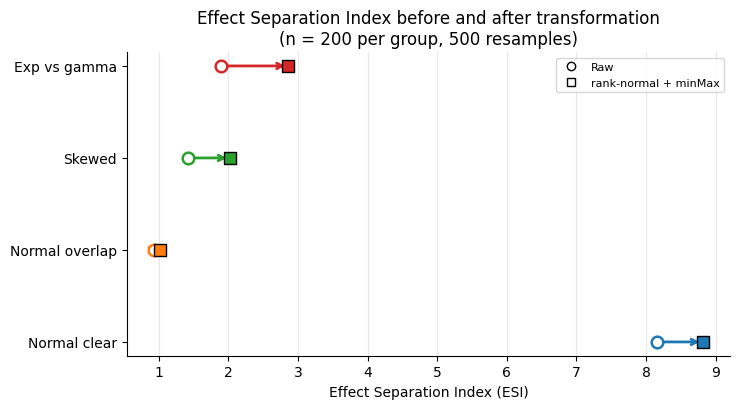

Saved figure as 'figure_ESI_raw_vs_ranknorm_minMax_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(1.5, 1, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(0, 1, size=n)
    y = rng.normal(0.2, 1, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(0, 0.7, size=n)
    y = rng.lognormal(0.3, 0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed",         scen_lognormal),
    ("Exp vs gamma",   scen_exponential_gamma),
]

# =========================================================
# 2. Basic stats: Cohen's d and overlap coefficient
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = x.var(ddof=1), y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """Approximate distributional overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

# =========================================================
# 3. rank-normal + minMax transformation
# =========================================================
def minmax_two(x, y):
    data = np.concatenate([x, y])
    lo = data.min()
    hi = data.max()
    if hi == lo:
        return np.zeros_like(x), np.zeros_like(y)
    return (x - lo) / (hi - lo), (y - lo) / (hi - lo)

def tf_ranknorm_minmax(x, y):
    """Pooled rank-normalisation, then min–max scaling (top transform)."""
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)  # pooled normal scores

    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    return minmax_two(x_rn, y_rn)

# =========================================================
# 4. Effect Separation Index (ESI)
#     ESI = | d̄ | / SD(d) × (1 − OVL̄)
# =========================================================
def compute_esi_for_scenario(scen_fun, n=200, n_boot=500,
                             transform=None, seed=1234):
    """
    For a given scenario and (optional) transform, compute:
        ESI = |d̄| / SD(d) × (1 − OVL̄)
    by repeatedly sampling new datasets.
    """
    rng = np.random.default_rng(seed)
    d_vals = []
    ov_vals = []

    for _ in range(n_boot):
        x, y = scen_fun(rng, n)

        if transform is not None:
            x, y = transform(x, y)

        d_b  = cohen_d(x, y)
        ov_b = overlap_index(x, y)

        d_vals.append(d_b)
        ov_vals.append(ov_b)

    d_vals = np.asarray(d_vals)
    ov_vals = np.asarray(ov_vals)

    mean_d  = d_vals.mean()
    sd_d    = d_vals.std(ddof=1)
    mean_ov = ov_vals.mean()

    esi = np.abs(mean_d) / (sd_d + 1e-12) * (1.0 - mean_ov)
    return esi, mean_d, sd_d, mean_ov

# =========================================================
# 5. Compute ESI for Raw vs rank-normal + minMax
# =========================================================
n_per_group = 200
n_boot = 500

esi_raw_list = []
esi_tr_list  = []

for scen_idx, (s_name, s_fun) in enumerate(scenarios):
    esi_raw, md_raw, sd_raw, ov_raw = compute_esi_for_scenario(
        s_fun, n=n_per_group, n_boot=n_boot,
        transform=None,
        seed=1000 + 10*scen_idx
    )
    esi_tr, md_tr, sd_tr, ov_tr = compute_esi_for_scenario(
        s_fun, n=n_per_group, n_boot=n_boot,
        transform=tf_ranknorm_minmax,
        seed=2000 + 10*scen_idx
    )
    esi_raw_list.append(esi_raw)
    esi_tr_list.append(esi_tr)
    print(f"{s_name:16s}  ESI raw = {esi_raw:.3f},  "
          f"ESI rank-normal+minMax = {esi_tr:.3f}")

# =========================================================
# 6. Figure: ESI before vs after (rank-normal + minMax)
# =========================================================
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

fig, ax = plt.subplots(figsize=(7.5, 4.2))

y_positions = np.arange(len(scenarios))
scenario_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, (label, _) in enumerate(scenarios):
    x_raw = esi_raw_list[i]
    x_tr  = esi_tr_list[i]
    color = scenario_colors[i]

    # Arrow from raw (circle) to transformed (square)
    ax.annotate(
        "",
        xy=(x_tr,  y_positions[i]),
        xytext=(x_raw, y_positions[i]),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2.0,
        ),
        zorder=2,
    )

    ax.scatter(
        x_raw, y_positions[i],
        facecolors="white",
        edgecolors=color,
        s=70,
        linewidth=1.8,
        zorder=3,
    )

    ax.scatter(
        x_tr, y_positions[i],
        facecolors=color,
        edgecolors="black",
        marker="s",
        s=70,
        zorder=4,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels([name for name, _ in scenarios])
ax.set_xlabel("Effect Separation Index (ESI)")
ax.set_title(
    "Effect Separation Index before and after transformation\n"
    f"(n = {n_per_group} per group, {n_boot} resamples)"
)
ax.grid(axis="x", alpha=0.3)

# ---------- Black legend (custom proxy artists) ----------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0],
           marker="o", linestyle="None",
           markerfacecolor="white", markeredgecolor="black",
           markersize=6, label="Raw"),
    Line2D([0], [0],
           marker="s", linestyle="None",
           markerfacecolor="white", markeredgecolor="black",
           markersize=6, label="rank-normal + minMax"),
]
ax.legend(handles=legend_elements,
          loc="best", fontsize=8, frameon=True)

plt.tight_layout()
fig.savefig("figure_ESI_raw_vs_ranknorm_minMax_300dpi.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_ESI_raw_vs_ranknorm_minMax_300dpi.png'")


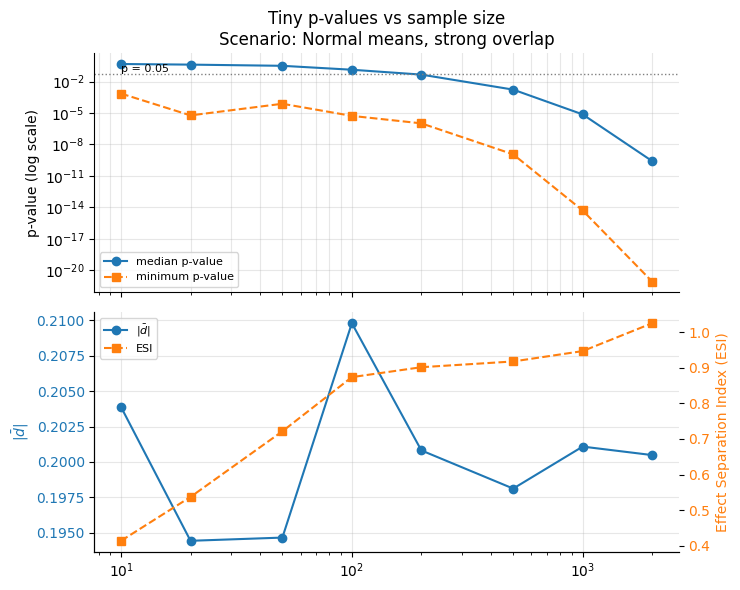

Saved figure as 'figure_p_vs_d_vs_ESI_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# -----------------------------
# 1. Scenario: Normal with overlap
# -----------------------------
def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)  # small shift, strong overlap
    return x, y

# -----------------------------
# 2. Cohen's d and overlap
# -----------------------------
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """Approximate overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# -----------------------------
# 3. Simulate p, d and ESI over n
# -----------------------------
def simulate_p_d_esi(ns, scen_fun, n_rep=1000, seed=123):
    rng = np.random.default_rng(seed)

    mean_d  = np.zeros(len(ns))
    sd_d    = np.zeros(len(ns))
    mean_ov = np.zeros(len(ns))
    median_p = np.zeros(len(ns))
    min_p    = np.zeros(len(ns))
    esi      = np.zeros(len(ns))

    for j, n in enumerate(ns):
        ds  = []
        ovs = []
        ps  = []

        for _ in range(n_rep):
            x, y = scen_fun(rng, n)

            # stats for this replicate
            d  = cohen_d(x, y)
            ov = overlap_index(x, y)
            stat, p = ttest_ind(y, x, equal_var=True)  # two-sided t

            ds.append(d)
            ovs.append(ov)
            ps.append(p)

        ds  = np.asarray(ds)
        ovs = np.asarray(ovs)
        ps  = np.asarray(ps)

        mean_d[j]  = ds.mean()
        sd_d[j]    = ds.std(ddof=1)
        mean_ov[j] = ovs.mean()
        median_p[j] = np.median(ps)
        min_p[j]    = ps.min()

        # ESI = |d̄| / SD(d) × (1 − OVL̄)
        esi[j] = np.abs(mean_d[j]) / (sd_d[j] + 1e-12) * (1.0 - mean_ov[j])

    return mean_d, sd_d, mean_ov, median_p, min_p, esi

# choose sample sizes
ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])

mean_d, sd_d, mean_ov, median_p, min_p, esi = simulate_p_d_esi(
    ns, scen_fun=scen_normal_overlap, n_rep=1000, seed=123
)

# -----------------------------
# 4. Plot
# -----------------------------
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)

# ---- Top: p-values vs n ----
ax = axes[0]
ax.plot(ns, median_p, marker="o", label="median p-value")
ax.plot(ns, min_p, marker="s", linestyle="--", label="minimum p-value")

ax.set_xscale("log")
ax.set_yscale("log")
ax.axhline(0.05, color="grey", linestyle=":", linewidth=1)
ax.text(ns[0], 0.05*1.1, "p = 0.05", fontsize=8, va="bottom", ha="left")

ax.set_ylabel("p-value (log scale)")
ax.set_title("Tiny p-values vs sample size\nScenario: Normal means, strong overlap")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)

# ---- Bottom: |d̄| and ESI vs n ----
ax2 = axes[1]
color_d = "tab:blue"
color_esi = "tab:orange"

l1 = ax2.plot(ns, np.abs(mean_d), marker="o", color=color_d, label=r"|$\bar d$|")
ax2.set_xscale("log")
ax2.set_ylabel(r"|$\bar d$|", color=color_d)
ax2.tick_params(axis="y", labelcolor=color_d)
ax2.grid(alpha=0.3)

ax3 = ax2.twinx()
l2 = ax3.plot(ns, esi, marker="s", linestyle="--", color=color_esi,
              label="ESI")
ax3.set_ylabel("Effect Separation Index (ESI)", color=color_esi)
ax3.tick_params(axis="y", labelcolor=color_esi)

# combined legend for bottom panel
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="upper left", fontsize=8)

ax3.set_xlabel("Sample size per group (n)")

plt.tight_layout()
fig.savefig("figure_p_vs_d_vs_ESI_300dpi.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_p_vs_d_vs_ESI_300dpi.png'")


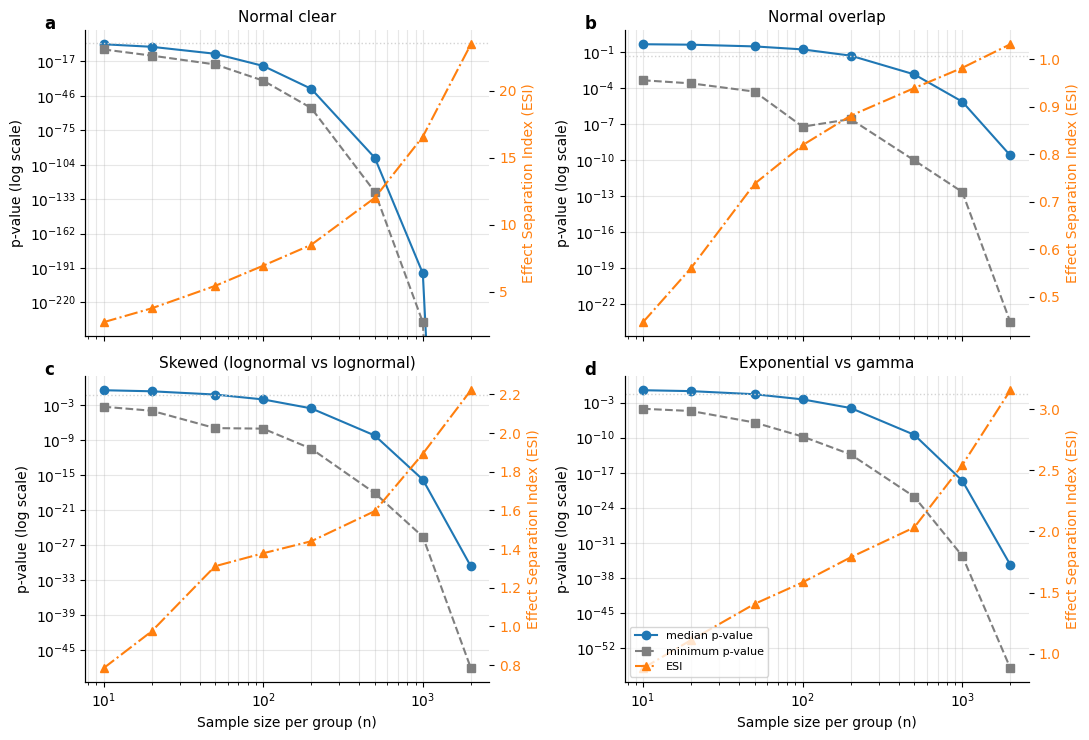

Saved multi-panel figure as 'figure_multi_p_d_ESI_4scenarios_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ======================================================
# 1. Scenario generators (4 scenarios)
# ======================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)  # small shift, strong overlap
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed (lognormal vs lognormal)", scen_lognormal),
    ("Exponential vs gamma",   scen_exponential_gamma),
]

# ======================================================
# 2. Cohen's d and overlap
# ======================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """Approximate overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# ======================================================
# 3. Simulate p, d and ESI over n for one scenario
#    ESI = |d̄| / SD(d) × (1 − OVL̄)
# ======================================================
def simulate_p_d_esi(ns, scen_fun, n_rep=1000, seed=123):
    rng = np.random.default_rng(seed)

    mean_d   = np.zeros(len(ns))
    sd_d     = np.zeros(len(ns))
    mean_ov  = np.zeros(len(ns))
    median_p = np.zeros(len(ns))
    min_p    = np.zeros(len(ns))
    esi      = np.zeros(len(ns))

    for j, n in enumerate(ns):
        ds  = []
        ovs = []
        ps  = []

        for _ in range(n_rep):
            x, y = scen_fun(rng, n)

            d  = cohen_d(x, y)
            ov = overlap_index(x, y)
            stat, p = ttest_ind(y, x, equal_var=True)  # two-sided t-test

            ds.append(d)
            ovs.append(ov)
            ps.append(p)

        ds  = np.asarray(ds)
        ovs = np.asarray(ovs)
        ps  = np.asarray(ps)

        mean_d[j]   = ds.mean()
        sd_d[j]     = ds.std(ddof=1)
        mean_ov[j]  = ovs.mean()
        median_p[j] = np.median(ps)
        min_p[j]    = ps.min()

        # ESI = |d̄| / SD(d) × (1 − OVL̄)
        esi[j] = np.abs(mean_d[j]) / (sd_d[j] + 1e-12) * (1.0 - mean_ov[j])

    return mean_d, sd_d, mean_ov, median_p, min_p, esi

# ======================================================
# 4. One multi-panel Nature-style figure (2×2 subplots)
# ======================================================
def make_multi_panel_p_d_esi(
        filename="figure_multi_p_d_ESI_4scenarios_300dpi.png",
        ns=None,
        n_rep=1000,
        base_seed=123):

    if ns is None:
        ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    axes = axes.ravel()
    panel_letters = ["a", "b", "c", "d"]

    for idx, ((scen_name, scen_fun), ax, letter) in enumerate(
            zip(scenarios, axes, panel_letters)
        ):
        # Slightly different seed per scenario for independence
        mean_d, sd_d, mean_ov, median_p, min_p, esi = simulate_p_d_esi(
            ns, scen_fun, n_rep=n_rep, seed=base_seed + 100*idx
        )

        # ---- Left y-axis: p-values on log scale ----
        color_med = "tab:blue"
        color_min = "tab:gray"

        l1 = ax.plot(
            ns, median_p,
            marker="o",
            linestyle="-",
            color=color_med,
            label="median p-value",
        )
        l2 = ax.plot(
            ns, min_p,
            marker="s",
            linestyle="--",
            color=color_min,
            label="minimum p-value",
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.axhline(0.05, color="lightgray", linestyle=":", linewidth=1)
        ax.set_ylabel("p-value (log scale)")
        ax.grid(alpha=0.3, which="both")

        # panel title + letter
        ax.set_title(scen_name, fontsize=11)
        ax.text(
            -0.10, 1.05, letter,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left", va="top"
        )

        # ---- Right y-axis: ESI ----
        ax_esi = ax.twinx()
        color_esi = "tab:orange"
        l3 = ax_esi.plot(
            ns, esi,
            marker="^",
            linestyle="-.",
            color=color_esi,
            label="ESI",
        )
        ax_esi.set_ylabel("Effect Separation Index (ESI)", color=color_esi)
        ax_esi.tick_params(axis="y", labelcolor=color_esi)

        # Combine legends (p + ESI) only once (bottom-right panel)
        if idx == len(scenarios) - 1:
            lines = l1 + l2 + l3
            labels = [ln.get_label() for ln in lines]
            ax_esi.legend(
                lines, labels,
                loc="lower left",
                fontsize=8,
                frameon=True
            )

    # Shared x-label for bottom row
    for ax in axes[-2:]:
        ax.set_xlabel("Sample size per group (n)")

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved multi-panel figure as '{filename}'")


# ======================================================
# 5. Run once
# ======================================================
ns_values = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])
make_multi_panel_p_d_esi(ns=ns_values, n_rep=1000, base_seed=123)


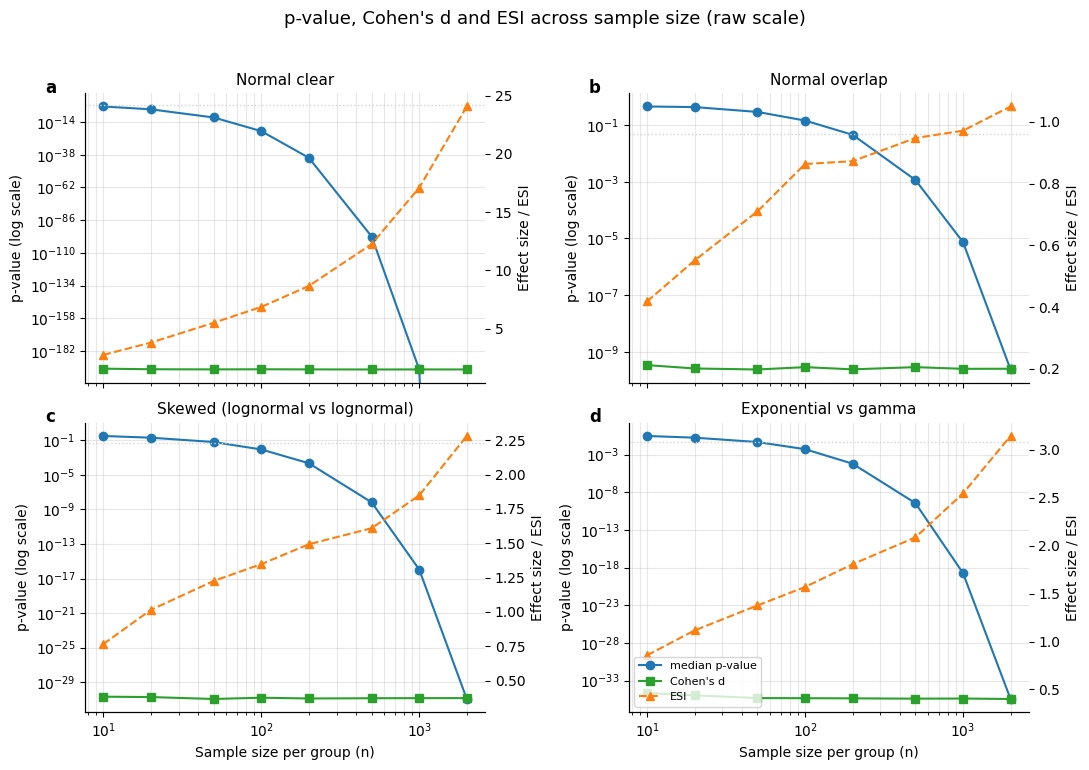

Saved figure: figure_raw_p_d_ESI_4scenarios_300dpi.png


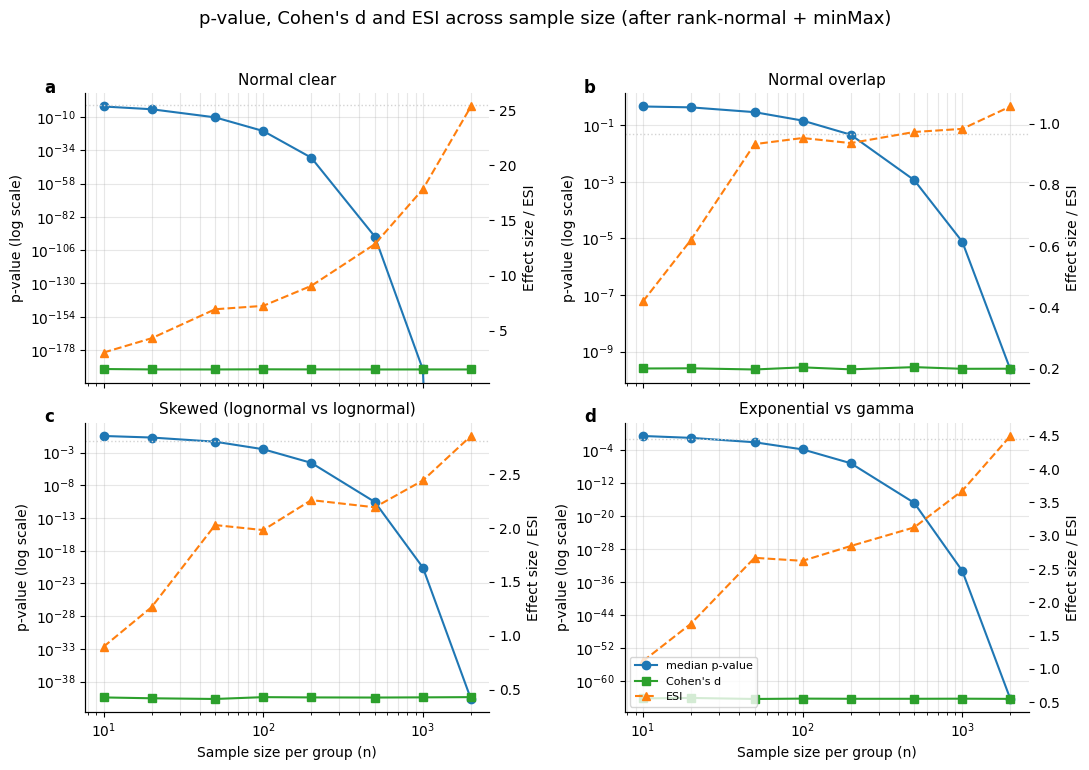

Saved figure: figure_ranknorm_minMax_p_d_ESI_4scenarios_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, rankdata, norm

# ======================================================
# 1. Scenario generators (4 scenarios)
# ======================================================
def scen_normal_clear(rng, n):
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(1.5, 1.0, n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(0.2, 1.0, n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(0.0, 0.7, n)
    y = rng.lognormal(0.3, 0.7, n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(1.0, n)
    y = rng.gamma(2.0, 0.7, n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed (lognormal vs lognormal)", scen_lognormal),
    ("Exponential vs gamma", scen_exponential_gamma),
]

# ======================================================
# 2. Metrics: Cohen's d, overlap index
# ======================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = x.var(ddof=1), y.var(ddof=1)
    s_pool = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pool + 1e-12)

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap:
    1 = identical, 0 = no overlap.
    """
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# ======================================================
# 3. rank-normal + minMax transformation
# ======================================================
def ranknorm_minmax(x, y):
    """
    1) Pool & rank-normalize to N(0,1)
    2) Rescale pooled transformed values to [0, 1]
    """
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    z = norm.ppf(u)  # rank-normal

    x_r = z[:len(x)]
    y_r = z[len(x):]

    allv = np.concatenate([x_r, y_r])
    lo, hi = allv.min(), allv.max()
    x_nn = (x_r - lo) / (hi - lo + 1e-12)
    y_nn = (y_r - lo) / (hi - lo + 1e-12)
    return x_nn, y_nn

# ======================================================
# 4. Core simulation: p, |d|, ESI across n
#    ESI = |mean d| / SD(d) × (1 − mean overlap)
# ======================================================
def simulate_p_d_esi(ns, scen_fun, transform=None, n_rep=1000, seed=123):
    rng = np.random.default_rng(seed)

    median_p = np.zeros(len(ns))
    mean_d   = np.zeros(len(ns))
    sd_d     = np.zeros(len(ns))
    mean_ov  = np.zeros(len(ns))
    esi      = np.zeros(len(ns))

    for j, n in enumerate(ns):
        ds, ovs, ps = [], [], []

        for _ in range(n_rep):
            x, y = scen_fun(rng, n)

            if transform is not None:
                x, y = transform(x, y)

            d  = cohen_d(x, y)
            ov = overlap_index(x, y)
            _, p = ttest_ind(x, y, equal_var=True)

            ds.append(d)
            ovs.append(ov)
            ps.append(p)

        ds  = np.asarray(ds)
        ovs = np.asarray(ovs)
        ps  = np.asarray(ps)

        median_p[j] = np.median(ps)
        mean_d[j]   = np.abs(ds.mean())
        sd_d[j]     = ds.std(ddof=1)
        mean_ov[j]  = ovs.mean()

        # Effect Separation Index
        esi[j] = mean_d[j] / (sd_d[j] + 1e-12) * (1.0 - mean_ov[j])

    return median_p, mean_d, esi

# ======================================================
# 5. Plot helper: 4 scenarios, each with p + d + ESI
# ======================================================
def plot_four_panel(ns, results, filename, title_suffix=" (raw)"):
    """
    results: list of (median_p, mean_d, esi) for each scenario
    """
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]

    for i, ((scen_name, _), ax, letter, (med_p, mean_d, esi)) in enumerate(
            zip(scenarios, axes, letters, results)
        ):
        # Left y-axis: p-value (log scale)
        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.plot(ns, med_p,
                marker="o", linestyle="-",
                color="tab:blue", label="median p-value")
        ax.axhline(0.05, color="lightgray", linestyle=":", linewidth=1)

        ax.set_ylabel("p-value (log scale)")
        ax.grid(alpha=0.3, which="both")

        # Panel letter + scenario title
        ax.text(-0.10, 1.05, letter,
                transform=ax.transAxes,
                fontsize=12, fontweight="bold",
                ha="left", va="top")
        ax.set_title(scen_name, fontsize=11)

        # Right y-axis: |d| and ESI
        ax2 = ax.twinx()
        ax2.plot(ns, mean_d,
                 marker="s", linestyle="-",
                 color="tab:green", label="Cohen's d")
        ax2.plot(ns, esi,
                 marker="^", linestyle="--",
                 color="tab:orange", label="ESI")
        ax2.set_ylabel("Effect size / ESI")
        ax2.tick_params(axis="y")

        # Single combined legend on bottom-right
        if i == len(axes) - 1:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax2.legend(lines1 + lines2, labels1 + labels2,
                       loc="lower left", fontsize=8, frameon=True)

    for ax in axes[-2:]:
        ax.set_xlabel("Sample size per group (n)")

    fig.suptitle(
        "p-value, Cohen's d and ESI across sample size" + title_suffix,
        fontsize=13, y=1.02
    )

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {filename}")

# ======================================================
# 6. Run everything
# ======================================================
if __name__ == "__main__":
    ns_values = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])

    # ---------- RAW SCALE ----------
    raw_results = []
    for idx, (name, scen_fun) in enumerate(scenarios):
        raw_results.append(
            simulate_p_d_esi(
                ns_values,
                scen_fun,
                transform=None,
                n_rep=800,              # adjust if you want smoother curves
                seed=123 + 100 * idx
            )
        )

    plot_four_panel(
        ns_values,
        raw_results,
        filename="figure_raw_p_d_ESI_4scenarios_300dpi.png",
        title_suffix=" (raw scale)"
    )

    # ---------- AFTER rank-normal + minMax ----------
    trans_results = []
    for idx, (name, scen_fun) in enumerate(scenarios):
        trans_results.append(
            simulate_p_d_esi(
                ns_values,
                scen_fun,
                transform=ranknorm_minmax,
                n_rep=800,
                seed=123 + 100 * idx
            )
        )

    plot_four_panel(
        ns_values,
        trans_results,
        filename="figure_ranknorm_minMax_p_d_ESI_4scenarios_300dpi.png",
        title_suffix=" (after rank-normal + minMax)"
    )


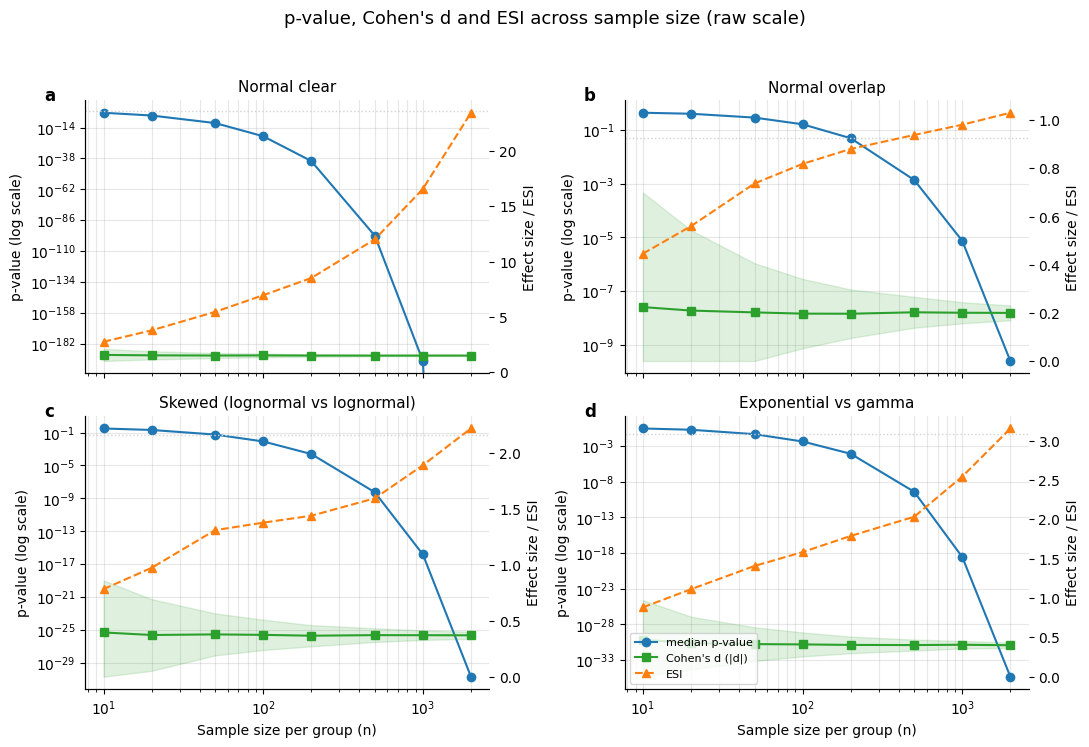

Saved 'fig_p_d_esi_raw_300dpi.png'


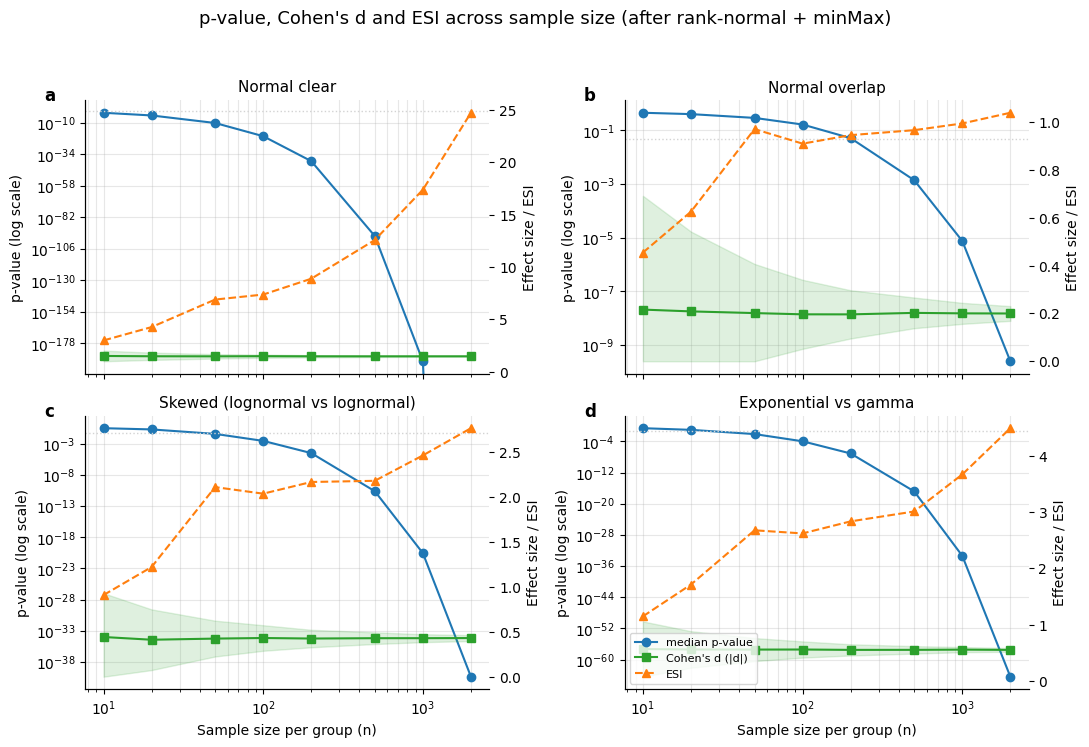

Saved 'fig_p_d_esi_ranknorm_minmax_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, norm, rankdata, boxcox

# ======================================================
# 1. Scenario generators (4 scenarios)
# ======================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed (lognormal vs lognormal)", scen_lognormal),
    ("Exponential vs gamma",   scen_exponential_gamma),
]

# ======================================================
# 2. Effect size and overlap
# ======================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """Approximate overlap: 1 = identical, 0 = no overlap."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# ======================================================
# 3. rank-normal + minMax transform
# ======================================================
def ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    return (x_rn - lo)/(hi - lo + 1e-12), (y_rn - lo)/(hi - lo + 1e-12)

# ======================================================
# 4. Simulate p, d and ESI over n for one scenario
#    ESI = |d̄| / SD(d) × (1 − OVL̄)
# ======================================================
def simulate_p_d_esi(ns, scen_fun, n_rep=1000, seed=123, use_transform=False):
    rng = np.random.default_rng(seed)

    mean_d   = np.zeros(len(ns))
    sd_d     = np.zeros(len(ns))
    mean_ov  = np.zeros(len(ns))
    median_p = np.zeros(len(ns))
    esi      = np.zeros(len(ns))

    for j, n in enumerate(ns):
        ds  = []
        ovs = []
        ps  = []

        for _ in range(n_rep):
            x, y = scen_fun(rng, n)

            if use_transform:
                x, y = ranknorm_minmax(x, y)

            d  = cohen_d(x, y)
            ov = overlap_index(x, y)
            stat, p = ttest_ind(y, x, equal_var=True)

            ds.append(d)
            ovs.append(ov)
            ps.append(p)

        ds  = np.asarray(ds)
        ovs = np.asarray(ovs)
        ps  = np.asarray(ps)

        mean_d[j]   = ds.mean()
        sd_d[j]     = ds.std(ddof=1)
        mean_ov[j]  = ovs.mean()
        median_p[j] = np.median(ps)

        # ESI = |d̄| / SD(d) × (1 − OVL̄)
        esi[j] = np.abs(mean_d[j]) / (sd_d[j] + 1e-12) * (1.0 - mean_ov[j])

    return mean_d, sd_d, mean_ov, median_p, esi

# ======================================================
# 5. Multi-panel figure generator
# ======================================================
def make_multi_panel(ns, n_rep, base_seed, use_transform=False,
                     title_prefix="raw scale", filename="fig_raw.png"):

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    axes = axes.ravel()
    panel_letters = ["a", "b", "c", "d"]

    for idx, ((scen_name, scen_fun), ax, letter) in enumerate(
            zip(scenarios, axes, panel_letters)
        ):

        mean_d, sd_d, mean_ov, median_p, esi = simulate_p_d_esi(
            ns, scen_fun, n_rep=n_rep,
            seed=base_seed + 100*idx,
            use_transform=use_transform
        )

        # |d| and its ±1 SD band
        d_abs = np.abs(mean_d)
        d_up  = np.abs(mean_d + sd_d)
        d_lo  = np.abs(np.maximum(mean_d - sd_d, 0))

        # ---- Left axis: p-value (log) ----
        color_p  = "tab:blue"
        color_d  = "tab:green"
        color_esi = "tab:orange"

        l1 = ax.plot(
            ns, median_p,
            marker="o", linestyle="-",
            color=color_p,
            label="median p-value",
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.axhline(0.05, color="lightgray", linestyle=":", linewidth=1)
        ax.set_ylabel("p-value (log scale)")
        ax.grid(alpha=0.3, which="both")

        # panel title + letter
        ax.set_title(scen_name, fontsize=11)
        ax.text(
            -0.10, 1.05, letter,
            transform=ax.transAxes,
            fontsize=12, fontweight="bold",
            ha="left", va="top"
        )

        # ---- Right axis: |d| and ESI ----
        ax2 = ax.twinx()

        # shaded band for |d| ± SD(d)
        ax2.fill_between(
            ns, d_lo, d_up,
            color=color_d, alpha=0.15
        )
        l2 = ax2.plot(
            ns, d_abs,
            marker="s", linestyle="-",
            color=color_d,
            label="Cohen's d (|d|)",
        )

        l3 = ax2.plot(
            ns, esi,
            marker="^", linestyle="--",
            color=color_esi,
            label="ESI",
        )

        ax2.set_ylabel("Effect size / ESI")
        ax2.tick_params(axis="y")

        if idx == len(scenarios) - 1:
            lines = l1 + l2 + l3
            labels = [ln.get_label() for ln in lines]
            ax2.legend(
                lines, labels,
                loc="lower left", fontsize=8, frameon=True
            )

    for ax in axes[-2:]:
        ax.set_xlabel("Sample size per group (n)")

    fig.suptitle(
        f"p-value, Cohen's d and ESI across sample size ({title_prefix})",
        y=0.99, fontsize=13
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved '{filename}'")

# ======================================================
# 6. Run: raw + transformed
# ======================================================
ns_values = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])

make_multi_panel(
    ns=ns_values, n_rep=1000,
    base_seed=123,
    use_transform=False,
    title_prefix="raw scale",
    filename="fig_p_d_esi_raw_300dpi.png"
)

make_multi_panel(
    ns=ns_values, n_rep=1000,
    base_seed=123,
    use_transform=True,
    title_prefix="after rank-normal + minMax",
    filename="fig_p_d_esi_ranknorm_minmax_300dpi.png"
)


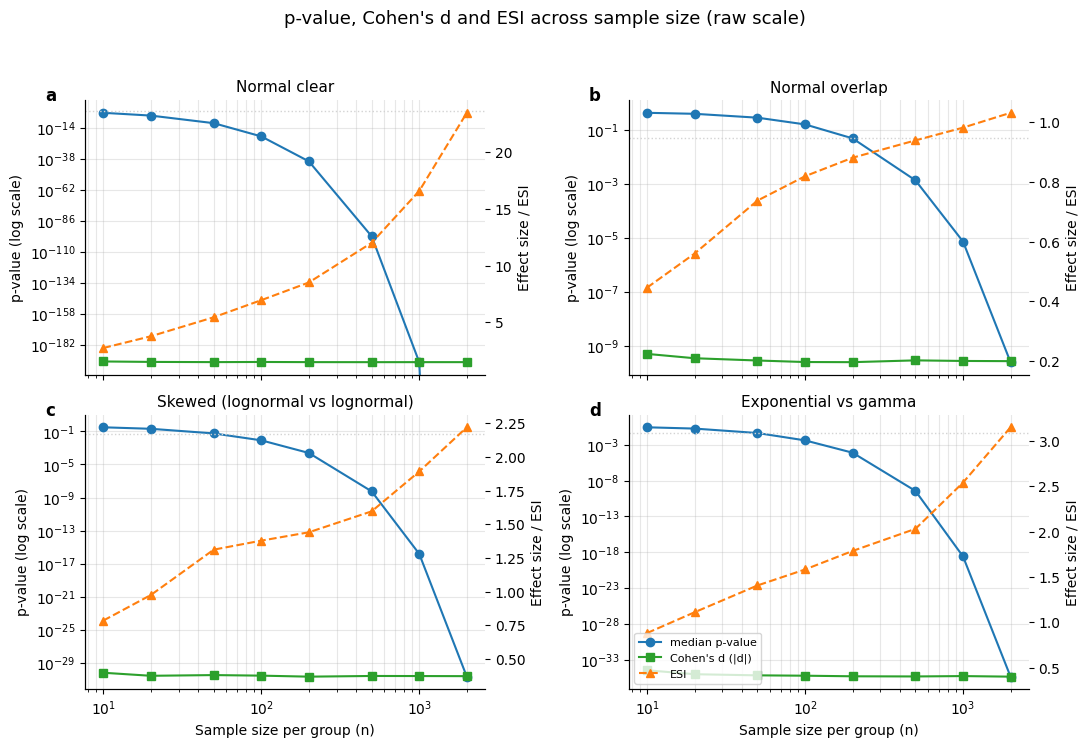

Saved 'fig_p_d_esi_raw_300dpi.png'


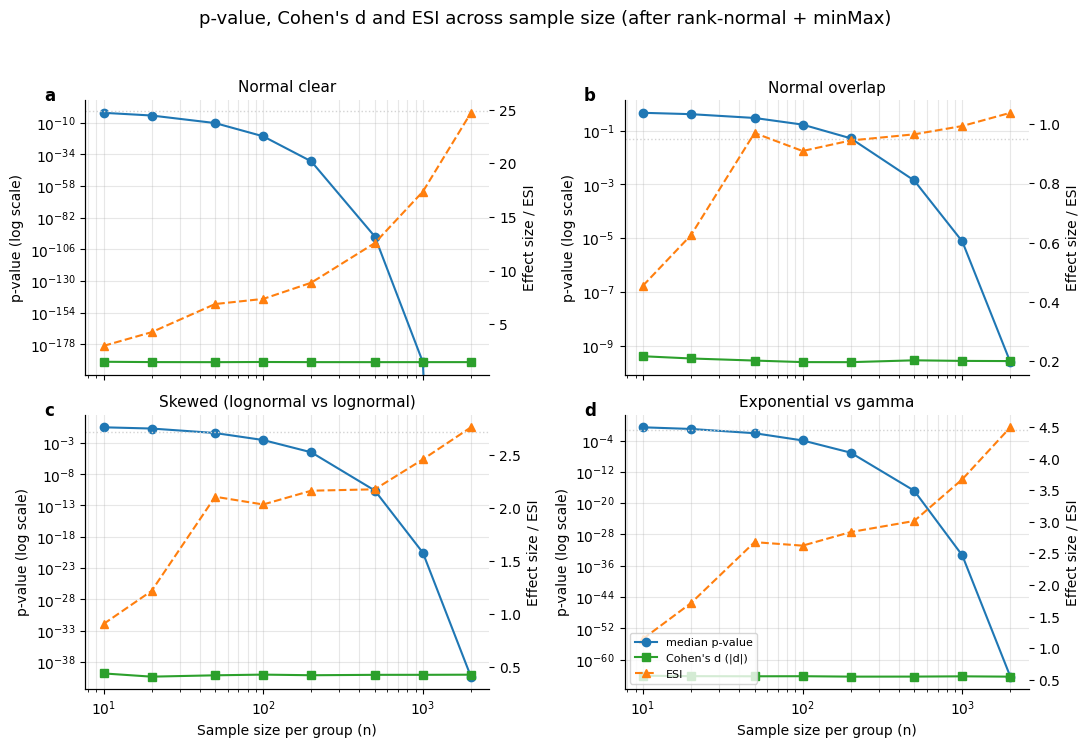

Saved 'fig_p_d_esi_ranknorm_minmax_300dpi.png'


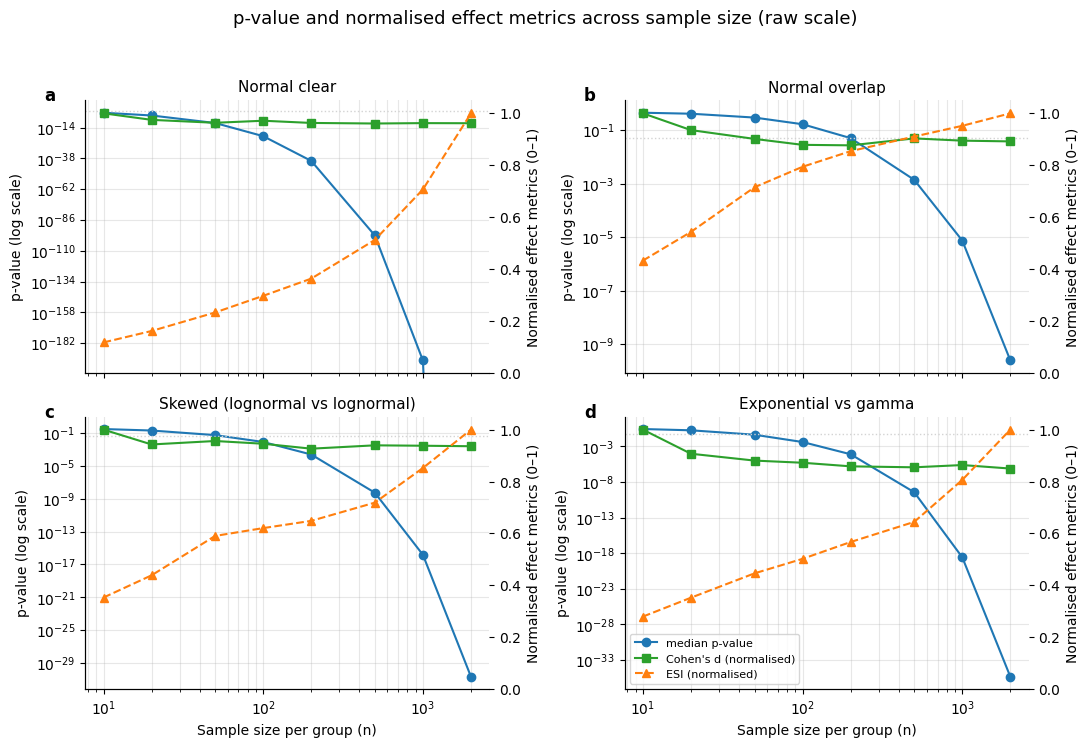

Saved 'fig_p_d_esi_norm_raw_300dpi.png'


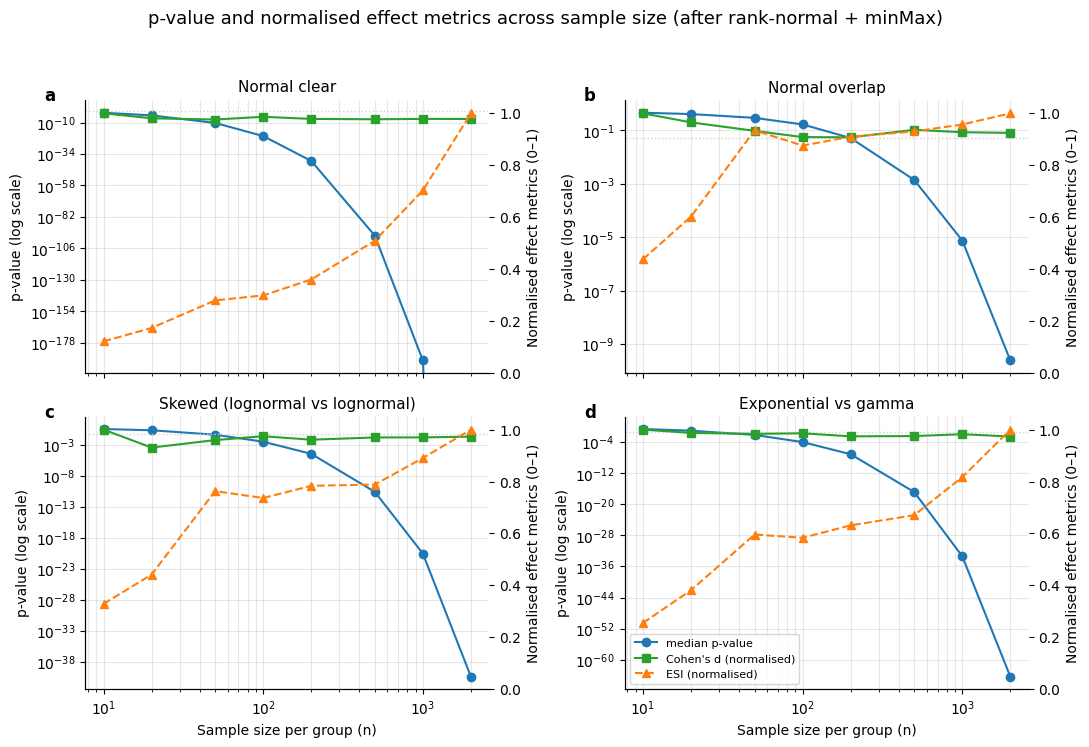

Saved 'fig_p_d_esi_norm_ranknorm_minmax_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, norm, rankdata, boxcox

# ======================================================
# 1. Scenario generators (4 scenarios)
# ======================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed (lognormal vs lognormal)", scen_lognormal),
    ("Exponential vs gamma",   scen_exponential_gamma),
]

# ======================================================
# 2. Effect size, overlap, transform
# ======================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum()*dx + 1e-12)
    hy = hy / (hy.sum()*dx + 1e-12)
    return np.sum(np.minimum(hx, hy))*dx

def ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]
    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    return (x_rn - lo)/(hi - lo + 1e-12), (y_rn - lo)/(hi - lo + 1e-12)

# ======================================================
# 3. Simulate p, d and ESI
#    ESI = |d̄| / SD(d) × (1 − OVL̄)
# ======================================================
def simulate_p_d_esi(ns, scen_fun, n_rep=1000, seed=123, use_transform=False):
    rng = np.random.default_rng(seed)

    mean_d   = np.zeros(len(ns))
    sd_d     = np.zeros(len(ns))
    mean_ov  = np.zeros(len(ns))
    median_p = np.zeros(len(ns))
    esi      = np.zeros(len(ns))

    for j, n in enumerate(ns):
        ds, ovs, ps = [], [], []

        for _ in range(n_rep):
            x, y = scen_fun(rng, n)
            if use_transform:
                x, y = ranknorm_minmax(x, y)

            d  = cohen_d(x, y)
            ov = overlap_index(x, y)
            _, p = ttest_ind(y, x, equal_var=True)

            ds.append(d); ovs.append(ov); ps.append(p)

        ds  = np.asarray(ds)
        ovs = np.asarray(ovs)
        ps  = np.asarray(ps)

        mean_d[j]   = ds.mean()
        sd_d[j]     = ds.std(ddof=1)
        mean_ov[j]  = ovs.mean()
        median_p[j] = np.median(ps)

        esi[j] = np.abs(mean_d[j]) / (sd_d[j] + 1e-12) * (1.0 - mean_ov[j])

    return mean_d, sd_d, mean_ov, median_p, esi

# ======================================================
# 4. Raw-scale figure (unchanged)
# ======================================================
def make_multi_panel_raw(ns, n_rep, base_seed, use_transform=False,
                         title_prefix="raw scale", filename="fig_raw.png"):

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]

    for idx, ((scen_name, scen_fun), ax, letter) in enumerate(
        zip(scenarios, axes, letters)
    ):
        mean_d, sd_d, mean_ov, median_p, esi = simulate_p_d_esi(
            ns, scen_fun, n_rep=n_rep,
            seed=base_seed + 100*idx,
            use_transform=use_transform
        )

        d_abs = np.abs(mean_d)

        color_p   = "tab:blue"
        color_d   = "tab:green"
        color_esi = "tab:orange"

        l1 = ax.plot(ns, median_p, marker="o", color=color_p,
                     label="median p-value")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.axhline(0.05, color="lightgray", linestyle=":", linewidth=1)
        ax.set_ylabel("p-value (log scale)")
        ax.grid(alpha=0.3, which="both")
        ax.set_title(scen_name, fontsize=11)
        ax.text(-0.10, 1.05, letter, transform=ax.transAxes,
                fontsize=12, fontweight="bold", ha="left", va="top")

        ax2 = ax.twinx()
        l2 = ax2.plot(ns, d_abs, marker="s", color=color_d,
                      label="Cohen's d (|d|)")
        l3 = ax2.plot(ns, esi, marker="^", linestyle="--", color=color_esi,
                      label="ESI")
        ax2.set_ylabel("Effect size / ESI")

        if idx == len(scenarios) - 1:
            lines = l1 + l2 + l3
            labels = [ln.get_label() for ln in lines]
            ax2.legend(lines, labels, loc="lower left", fontsize=8, frameon=True)

    for ax in axes[-2:]:
        ax.set_xlabel("Sample size per group (n)")

    fig.suptitle(f"p-value, Cohen's d and ESI across sample size ({title_prefix})",
                 y=0.99, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved '{filename}'")

# ======================================================
# 5. Normalised-scale figure (d & ESI 0–1)
# ======================================================
def make_multi_panel_normalised(ns, n_rep, base_seed, use_transform=False,
                                title_prefix="normalised d & ESI",
                                filename="fig_norm.png"):

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]

    for idx, ((scen_name, scen_fun), ax, letter) in enumerate(
        zip(scenarios, axes, letters)
    ):
        mean_d, sd_d, mean_ov, median_p, esi = simulate_p_d_esi(
            ns, scen_fun, n_rep=n_rep,
            seed=base_seed + 100*idx,
            use_transform=use_transform
        )

        d_abs = np.abs(mean_d)

        # normalise within scenario
        d_norm   = d_abs / (d_abs.max() + 1e-12)
        esi_norm = esi   / (esi.max()   + 1e-12)

        color_p   = "tab:blue"
        color_d   = "tab:green"
        color_esi = "tab:orange"

        # p-values
        l1 = ax.plot(ns, median_p, marker="o", color=color_p,
                     label="median p-value")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.axhline(0.05, color="lightgray", linestyle=":", linewidth=1)
        ax.set_ylabel("p-value (log scale)")
        ax.grid(alpha=0.3, which="both")
        ax.set_title(scen_name, fontsize=11)
        ax.text(-0.10, 1.05, letter, transform=ax.transAxes,
                fontsize=12, fontweight="bold", ha="left", va="top")

        # normalised d & ESI
        ax2 = ax.twinx()
        l2 = ax2.plot(ns, d_norm, marker="s", color=color_d,
                      label="Cohen's d (normalised)")
        l3 = ax2.plot(ns, esi_norm, marker="^", linestyle="--", color=color_esi,
                      label="ESI (normalised)")
        ax2.set_ylabel("Normalised effect metrics (0–1)")
        ax2.set_ylim(0, 1.05)

        if idx == len(scenarios) - 1:
            lines = l1 + l2 + l3
            labels = [ln.get_label() for ln in lines]
            ax2.legend(lines, labels, loc="lower left", fontsize=8, frameon=True)

    for ax in axes[-2:]:
        ax.set_xlabel("Sample size per group (n)")

    fig.suptitle(
        f"p-value and normalised effect metrics across sample size ({title_prefix})",
        y=0.99, fontsize=13
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved '{filename}'")

# ======================================================
# 6. Run: raw + transformed, both scales
# ======================================================
ns_values = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])

# Raw scale
make_multi_panel_raw(
    ns=ns_values, n_rep=1000, base_seed=123,
    use_transform=False,
    title_prefix="raw scale",
    filename="fig_p_d_esi_raw_300dpi.png"
)

# Raw scale after rank-normal + minMax
make_multi_panel_raw(
    ns=ns_values, n_rep=1000, base_seed=123,
    use_transform=True,
    title_prefix="after rank-normal + minMax",
    filename="fig_p_d_esi_ranknorm_minmax_300dpi.png"
)

# Normalised scale (better comparison of shapes)
make_multi_panel_normalised(
    ns=ns_values, n_rep=1000, base_seed=123,
    use_transform=False,
    title_prefix="raw scale",
    filename="fig_p_d_esi_norm_raw_300dpi.png"
)

make_multi_panel_normalised(
    ns=ns_values, n_rep=1000, base_seed=123,
    use_transform=True,
    title_prefix="after rank-normal + minMax",
    filename="fig_p_d_esi_norm_ranknorm_minmax_300dpi.png"
)


Normal clear     |d̄| raw = 1.505, ESI raw = 8.153   |d̄| rn+minMax = 1.473, ESI rn+minMax = 8.811
Normal overlap   |d̄| raw = 0.206, ESI raw = 0.937   |d̄| rn+minMax = 0.208, ESI rn+minMax = 1.026
Skewed           |d̄| raw = 0.374, ESI raw = 1.417   |d̄| rn+minMax = 0.428, ESI rn+minMax = 2.019
Exp vs gamma     |d̄| raw = 0.402, ESI raw = 1.893   |d̄| rn+minMax = 0.557, ESI rn+minMax = 2.859


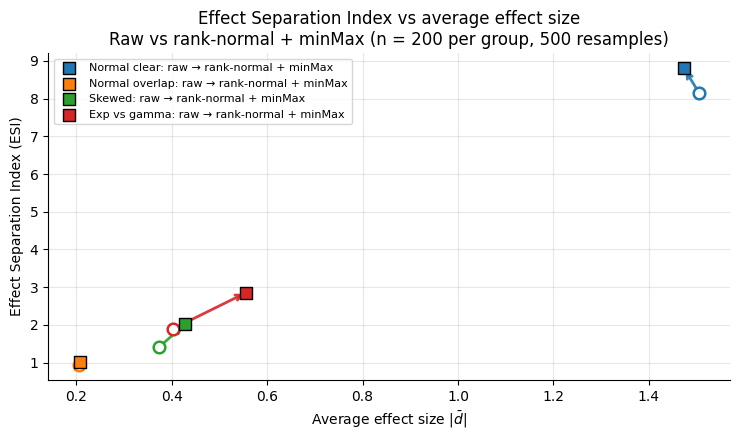

Saved figure as 'figure_d_vs_ESI_raw_vs_ranknorm_minMax_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("Normal clear",   scen_normal_clear),
    ("Normal overlap", scen_normal_overlap),
    ("Skewed",         scen_lognormal),
    ("Exp vs gamma",   scen_exponential_gamma),
]

# =========================================================
# 2. Basic stats: Cohen's d, overlap, ESI
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap: 1 = identical, 0 = no overlap.
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

def compute_ESI_from_samples(d_vals, ov_vals):
    """
    ESI = |mean d| / SD(d) × (1 − mean overlap)
    using the agreed final definition.
    """
    d_vals = np.asarray(d_vals)
    ov_vals = np.asarray(ov_vals)

    mean_d  = d_vals.mean()
    sd_d    = d_vals.std(ddof=1)
    mean_ov = ov_vals.mean()

    esi = np.abs(mean_d) / (sd_d + 1e-12) * (1.0 - mean_ov)
    return esi, mean_d, sd_d, mean_ov

# =========================================================
# 3. rank-normal + minMax transformation
# =========================================================
def minmax_two(x, y):
    data = np.concatenate([x, y])
    lo = data.min()
    hi = data.max()
    if hi == lo:
        return np.zeros_like(x), np.zeros_like(y)
    return (x - lo) / (hi - lo), (y - lo) / (hi - lo)

def tf_ranknorm_minmax(x, y):
    """
    Transform: rank-normalisation over pooled data, then min–max scaling.
    """
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn_all = norm.ppf(u)
    x_rn = rn_all[:len(x)]
    y_rn = rn_all[len(x):]
    return minmax_two(x_rn, y_rn)

# =========================================================
# 4. For each scenario: ESI and mean d (raw vs transformed)
# =========================================================
def compute_d_and_ESI_for_scenario(scen_fun, n=200, n_boot=500,
                                   transform=None, seed=1234):
    """
    Resample n_boot times, each time generating fresh (x,y) from scen_fun.
    Optionally apply transform(x,y) before computing stats.

    Returns:
      ESI, mean_d, mean_ov  (all scalars)
    """
    rng = np.random.default_rng(seed)
    d_vals = []
    ov_vals = []

    for _ in range(n_boot):
        x, y = scen_fun(rng, n)

        if transform is not None:
            x, y = transform(x, y)

        d_b  = cohen_d(x, y)
        ov_b = overlap_index(x, y)

        d_vals.append(d_b)
        ov_vals.append(ov_b)

    esi, mean_d, sd_d, mean_ov = compute_ESI_from_samples(d_vals, ov_vals)
    return esi, mean_d, mean_ov

# ---------------------------------------------------------
# 5. Collect (|d̄|, ESI) for raw vs transformed per scenario
# ---------------------------------------------------------
n_per_group = 200
n_boot = 500

results = []
for scen_idx, (label, scen_fun) in enumerate(scenarios):
    esi_raw, mean_d_raw, mean_ov_raw = compute_d_and_ESI_for_scenario(
        scen_fun, n=n_per_group, n_boot=n_boot,
        transform=None,
        seed=1000 + 10*scen_idx,
    )
    esi_tr, mean_d_tr, mean_ov_tr = compute_d_and_ESI_for_scenario(
        scen_fun, n=n_per_group, n_boot=n_boot,
        transform=tf_ranknorm_minmax,
        seed=2000 + 10*scen_idx,
    )

    results.append({
        "scenario": label,
        "d_raw": mean_d_raw,
        "ESI_raw": esi_raw,
        "d_tr": mean_d_tr,
        "ESI_tr": esi_tr,
    })

    print(f"{label:16s} |d̄| raw = {abs(mean_d_raw):.3f}, ESI raw = {esi_raw:.3f}   "
          f"|d̄| rn+minMax = {abs(mean_d_tr):.3f}, ESI rn+minMax = {esi_tr:.3f}")

# =========================================================
# 6. Plot: |d̄| vs ESI, arrows raw → rank-normal+minMax
# =========================================================
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

fig, ax = plt.subplots(figsize=(7.5, 4.5))

scenario_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
legend_handles = []

for i, res in enumerate(results):
    color = scenario_colors[i]
    label = res["scenario"]

    x_raw = np.abs(res["d_raw"])
    y_raw = res["ESI_raw"]
    x_tr  = np.abs(res["d_tr"])
    y_tr  = res["ESI_tr"]

    # Arrow raw -> transformed
    ax.annotate(
        "",
        xy=(x_tr, y_tr),
        xytext=(x_raw, y_raw),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2.0,
            alpha=0.9,
        ),
        zorder=2,
    )

    # Raw point: open circle
    raw_scatter = ax.scatter(
        x_raw, y_raw,
        facecolors="white",
        edgecolors=color,
        s=70,
        linewidth=1.8,
        zorder=3,
    )

    # Transformed point: filled square
    tr_scatter = ax.scatter(
        x_tr, y_tr,
        facecolors=color,
        edgecolors="black",
        marker="s",
        s=70,
        zorder=4,
    )

    # One legend entry per scenario: “Scenario (raw → rn+minMax)”
    legend_handles.append((tr_scatter,
                           f"{label}: raw → rank-normal + minMax"))

# Build legend manually so labels are clean
handles, labels = zip(*legend_handles)
leg = ax.legend(
    handles,
    labels,
    loc="upper left",
    fontsize=8,
    frameon=True,
)

ax.set_xlabel(r"Average effect size $|\bar d|$")
ax.set_ylabel("Effect Separation Index (ESI)")
ax.set_title(
    "Effect Separation Index vs average effect size\n"
    f"Raw vs rank-normal + minMax (n = {n_per_group} per group, {n_boot} resamples)"
)

ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig("figure_d_vs_ESI_raw_vs_ranknorm_minMax_300dpi.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_d_vs_ESI_raw_vs_ranknorm_minMax_300dpi.png'")


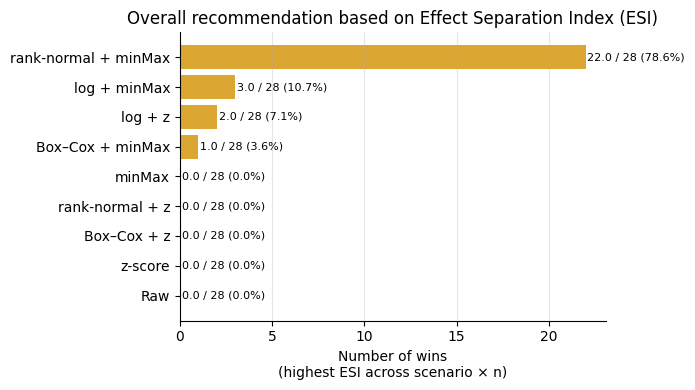

Saved ESI-based overall recommendation figure to: figure5_overall_recommendation_ESI_300dpi.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

# =========================================================
# 2. Effect size & overlap
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap:
    1 = identical distributions, 0 = no overlap.
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]

    # normalise for numerical stability
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# =========================================================
# 3. Basic helpers: z-score & min–max
# =========================================================
def zscore_two(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_two(x, y):
    data = np.concatenate([x, y])
    lo = data.min()
    hi = data.max()
    if hi == lo:
        return np.zeros_like(x), np.zeros_like(y)
    return (x - lo) / (hi - lo), (y - lo) / (hi - lo)

# =========================================================
# 4. All transformations (incl. Raw)
# =========================================================
transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]

all_labels = ["Raw"] + transform_labels  # Raw first
n_transforms = len(all_labels)

def apply_all_with_raw(x_raw, y_raw):
    """
    Return list of (x_t, y_t) in the same order as 'all_labels':
      0: Raw (no transform)
      1: z-score
      2: log + z
      3: Box–Cox + z
      4: rank-normal + z
      5: minMax
      6: log + minMax
      7: Box–Cox + minMax
      8: rank-normal + minMax
    """
    results = []

    # 0) Raw
    results.append((x_raw, y_raw))

    # Shared quantities
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])

    # Shift to positive for log / Box–Cox
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # log and Box–Cox
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    pooled_pos = np.concatenate([x_pos, y_pos])
    bc_all, lam = boxcox(pooled_pos)
    x_bc = bc_all[:len(x_raw)]
    y_bc = bc_all[len(x_raw):]

    # rank-normal
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    rn_all = norm.ppf(u)
    x_rn = rn_all[:len(x_raw)]
    y_rn = rn_all[len(x_raw):]

    # 1) z-score
    x_z, y_z = zscore_two(x_raw, y_raw)
    results.append((x_z, y_z))

    # 2) log + z
    x_log_z, y_log_z = zscore_two(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # 3) Box–Cox + z
    x_bc_z, y_bc_z = zscore_two(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # 4) rank-normal + z
    x_rn_z, y_rn_z = zscore_two(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # 5) minMax
    x_mm, y_mm = minmax_two(x_raw, y_raw)
    results.append((x_mm, y_mm))

    # 6) log + minMax
    x_log_mm, y_log_mm = minmax_two(x_log, y_log)
    results.append((x_log_mm, y_log_mm))

    # 7) Box–Cox + minMax
    x_bc_mm, y_bc_mm = minmax_two(x_bc, y_bc)
    results.append((x_bc_mm, y_bc_mm))

    # 8) rank-normal + minMax
    x_rn_mm, y_rn_mm = minmax_two(x_rn, y_rn)
    results.append((x_rn_mm, y_rn_mm))

    return results

# =========================================================
# 5. ESI simulation for one scenario
#     ESI = | d̄ | / SD(d) × (1 − OVL̄)
# =========================================================
def simulate_esi_grid(scen_fun, ns, n_rep=400, seed=123):
    """
    For a given scenario, compute Effect Separation Index (ESI)
    for each transformation × sample size.

    For each transform k and sample size n:
        - simulate d across n_rep replicates
        - simulate overlap across n_rep replicates
        - compute:
            mean_d  = mean(d)
            sd_d    = SD(d)
            mean_ov = mean(overlap)
            SNR     = |mean_d| / SD(d)
            ESI     = SNR * (1 - mean_ov)

    Returns:
      esi : array shape (n_transforms, len(ns)).
    """
    rng = np.random.default_rng(seed)
    mean_d  = np.zeros((n_transforms, len(ns)))
    sd_d    = np.zeros_like(mean_d)
    mean_ov = np.zeros_like(mean_d)

    for j, n in enumerate(ns):
        d_lists  = [[] for _ in range(n_transforms)]
        ov_lists = [[] for _ in range(n_transforms)]

        for _ in range(n_rep):
            x_raw, y_raw = scen_fun(rng, n)
            pairs = apply_all_with_raw(x_raw, y_raw)

            for k, (xt, yt) in enumerate(pairs):
                d_lists[k].append(cohen_d(xt, yt))
                ov_lists[k].append(overlap_index(xt, yt))

        for k in range(n_transforms):
            ds  = np.asarray(d_lists[k])
            ovs = np.asarray(ov_lists[k])

            mean_d[k, j]  = ds.mean()
            sd_d[k, j]    = ds.std(ddof=1)
            mean_ov[k, j] = ovs.mean()

    snr = np.abs(mean_d) / (sd_d + 1e-12)
    esi = snr * (1.0 - mean_ov)   # <-- EXACT ESI FORMULA

    return esi

# =========================================================
# 6. Figure: overall recommendation bar plot based on ESI
# =========================================================
def make_overall_recommendation_figure_ESI(
        filename="figure5_overall_recommendation_ESI_300dpi.png",
        ns=(10, 20, 50, 100, 200, 500, 1000),
        n_rep=400,
        seed=123,
    ):
    """
    For each scenario and each n, find which transformation
    has the highest ESI, and count wins across all scenario × n
    combinations. Plot as a horizontal bar chart.
    """
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    scenarios = [
        ("Normal clear",   scen_normal_clear),
        ("Normal overlap", scen_normal_overlap),
        ("Lognormal",      scen_lognormal),
        ("Exp vs gamma",   scen_exponential_gamma),
    ]

    winner_counts = np.zeros(n_transforms, dtype=float)

    for _, scen_fun in scenarios:
        esi = simulate_esi_grid(scen_fun, ns, n_rep=n_rep, seed=seed)
        for j in range(len(ns)):
            col = esi[:, j]
            best = np.argwhere(col == col.max()).flatten()
            # split a "win" equally among ties
            for idx in best:
                winner_counts[idx] += 1.0 / len(best)

    total_cases = len(scenarios) * len(ns)

    # sort from worst to best so best appears at top
    order = np.argsort(winner_counts)
    counts_sorted = winner_counts[order]
    labels_sorted = np.array(all_labels)[order]

    fig, ax = plt.subplots(figsize=(7, 4))

    bars = ax.barh(labels_sorted, counts_sorted, color="#d99d1c", alpha=0.9)
    ax.set_xlabel("Number of wins\n(highest ESI across scenario × n)")
    ax.set_title("Overall recommendation based on Effect Separation Index (ESI)")

    for rect, cnt in zip(bars, counts_sorted):
        pct = 100.0 * cnt / total_cases
        ax.text(
            rect.get_width() + 0.1,
            rect.get_y() + rect.get_height() / 2,
            f"{cnt:.1f} / {total_cases} ({pct:.1f}%)",
            va="center",
            fontsize=8,
        )

    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved ESI-based overall recommendation figure to: {filename}")

# ---------------------------------------------------------
# Run to generate the ESI-based Figure 5
# ---------------------------------------------------------
make_overall_recommendation_figure_ESI()


S1: Normal clear (n=500):
  ESI raw         = 12.094
  ESI transformed = 12.607
  mean d raw, sd(d), mean OVL  = (np.float64(1.501921665436739), np.float64(0.07245880142165734), np.float64(0.41654599999958336))
  mean d tr , sd(d), mean OVL  = (np.float64(1.4841754272243053), np.float64(0.06820118104591782), np.float64(0.42068599999957923))

S2: Normal overlap (n=500):
  ESI raw         = 0.915
  ESI transformed = 0.943
  mean d raw, sd(d), mean OVL  = (np.float64(0.20263019459741446), np.float64(0.06590984705818391), np.float64(0.7023999999992975))
  mean d tr , sd(d), mean OVL  = (np.float64(0.20245524679930121), np.float64(0.06585051638279917), np.float64(0.6933979999993066))

S3: Skewed lognormal (n=500):
  ESI raw         = 1.567
  ESI transformed = 2.127
  mean d raw, sd(d), mean OVL  = (np.float64(0.37001555629921457), np.float64(0.061899501751828005), np.float64(0.7378099999992621))
  mean d tr , sd(d), mean OVL  = (np.float64(0.42624679857940645), np.float64(0.0659288020049406

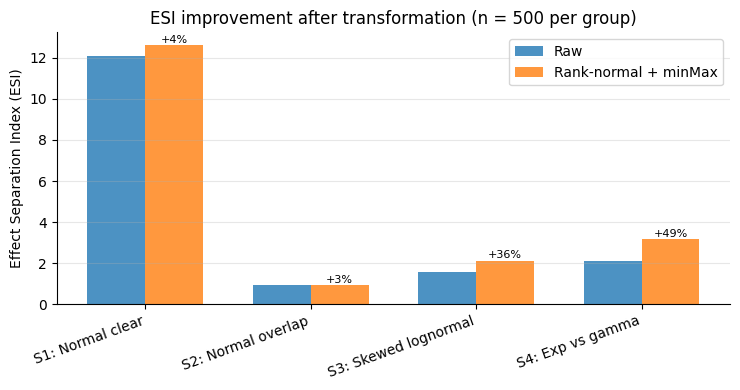

Saved figure as 'figure_ESI_raw_vs_ranknorm_minMax_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata

# =========================================================
# 1. Scenario generators (same as before)
# =========================================================
def scen_normal_clear(rng, n):
    # Clear separation
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    # Small shift, strong overlap
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    # Skewed multiplicative effect
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    # Different families, heteroskedastic
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("S1: Normal clear",   scen_normal_clear),
    ("S2: Normal overlap", scen_normal_overlap),
    ("S3: Skewed lognormal", scen_lognormal),
    ("S4: Exp vs gamma",   scen_exponential_gamma),
]

# =========================================================
# 2. Cohen's d and overlap
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap: 1 = identical, 0 = no overlap.
    Uses normalized histograms and integrates min(density_x, density_y).
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# =========================================================
# 3. Optimal transformation: rank-normal + minMax
# =========================================================
def tf_ranknorm_minmax(x, y):
    """
    1) Pool x,y and rank-normalize to ~N(0,1) using inverse CDF
    2) Apply min–max scaling on the rank-normal values
    """
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)  # rank-normal transform

    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]

    # min–max on concatenated rank-normal values
    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12

    x_mm = (x_rn - lo) / scale
    y_mm = (y_rn - lo) / scale

    return x_mm, y_mm

# =========================================================
# 4. ESI computation for one scenario
# =========================================================
def compute_esi_for_scenario(scen_fun, n=500, n_rep=1000, seed=123):
    """
    For a given scenario and sample size n:
    - simulate n_rep experiments
    - compute d and overlap for raw and transformed data
    - return ESI_raw, ESI_trans
    ESI = |mean_d| / SD(d) * (1 - mean_overlap)
    """
    rng = np.random.default_rng(seed)

    d_raw_list = []
    ov_raw_list = []

    d_tr_list = []
    ov_tr_list = []

    for _ in range(n_rep):
        # generate raw data
        x_raw, y_raw = scen_fun(rng, n)

        # raw metrics
        d_r = cohen_d(x_raw, y_raw)
        ov_r = overlap_index(x_raw, y_raw)

        d_raw_list.append(d_r)
        ov_raw_list.append(ov_r)

        # transformed data
        x_tr, y_tr = tf_ranknorm_minmax(x_raw, y_raw)
        d_t = cohen_d(x_tr, y_tr)
        ov_t = overlap_index(x_tr, y_tr)

        d_tr_list.append(d_t)
        ov_tr_list.append(ov_t)

    d_raw_arr = np.asarray(d_raw_list)
    ov_raw_arr = np.asarray(ov_raw_list)

    d_tr_arr = np.asarray(d_tr_list)
    ov_tr_arr = np.asarray(ov_tr_list)

    # ESI = |mean d| / SD(d) * (1 - mean overlap)
    mean_d_raw = d_raw_arr.mean()
    sd_d_raw   = d_raw_arr.std(ddof=1)
    mean_ov_raw = ov_raw_arr.mean()

    mean_d_tr = d_tr_arr.mean()
    sd_d_tr   = d_tr_arr.std(ddof=1)
    mean_ov_tr = ov_tr_arr.mean()

    esi_raw = np.abs(mean_d_raw) / (sd_d_raw + 1e-12) * (1.0 - mean_ov_raw)
    esi_tr  = np.abs(mean_d_tr)  / (sd_d_tr  + 1e-12) * (1.0 - mean_ov_tr)

    return esi_raw, esi_tr, (mean_d_raw, sd_d_raw, mean_ov_raw), (mean_d_tr, sd_d_tr, mean_ov_tr)

# =========================================================
# 5. Run all four scenarios and collect ESI values
# =========================================================
n_per_group = 500      # you can change to 200, 1000, etc.
n_rep       = 1000     # more reps = smoother estimate, more time

esi_raw_vals = []
esi_tr_vals  = []

summary_raw  = []
summary_tr   = []

for idx, (name, scen_fun) in enumerate(scenarios):
    esi_raw, esi_tr, stats_raw, stats_tr = compute_esi_for_scenario(
        scen_fun,
        n=n_per_group,
        n_rep=n_rep,
        seed=123 + 100*idx
    )
    esi_raw_vals.append(esi_raw)
    esi_tr_vals.append(esi_tr)
    summary_raw.append(stats_raw)
    summary_tr.append(stats_tr)

    print(f"{name} (n={n_per_group}):")
    print(f"  ESI raw         = {esi_raw:.3f}")
    print(f"  ESI transformed = {esi_tr:.3f}")
    print(f"  mean d raw, sd(d), mean OVL  = {stats_raw}")
    print(f"  mean d tr , sd(d), mean OVL  = {stats_tr}")
    print()

esi_raw_vals = np.asarray(esi_raw_vals)
esi_tr_vals  = np.asarray(esi_tr_vals)

# =========================================================
# 6. Bar-plot figure: ESI raw vs transformed (Nature-style)
# =========================================================
labels = [s[0] for s in scenarios]
x = np.arange(len(labels))  # scenario positions
width = 0.35

fig, ax = plt.subplots(figsize=(7.5, 4.0))

# Bars for raw and transformed
bars1 = ax.bar(x - width/2, esi_raw_vals, width, label='Raw', alpha=0.8)
bars2 = ax.bar(x + width/2, esi_tr_vals,  width, label='Rank-normal + minMax', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Effect Separation Index (ESI)")
ax.set_title(f"ESI improvement after transformation (n = {n_per_group} per group)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

# Optional: annotate percentage improvement above transformed bars
for i, (b_raw, b_tr) in enumerate(zip(bars1, bars2)):
    h_raw = b_raw.get_height()
    h_tr  = b_tr.get_height()
    if h_raw > 0:
        pct = 100.0 * (h_tr - h_raw) / h_raw
    else:
        pct = np.nan
    ax.text(
        b_tr.get_x() + b_tr.get_width()/2,
        h_tr + 0.02,
        f"+{pct:.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
fig.savefig("figure_ESI_raw_vs_ranknorm_minMax_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure as 'figure_ESI_raw_vs_ranknorm_minMax_300dpi.png'")


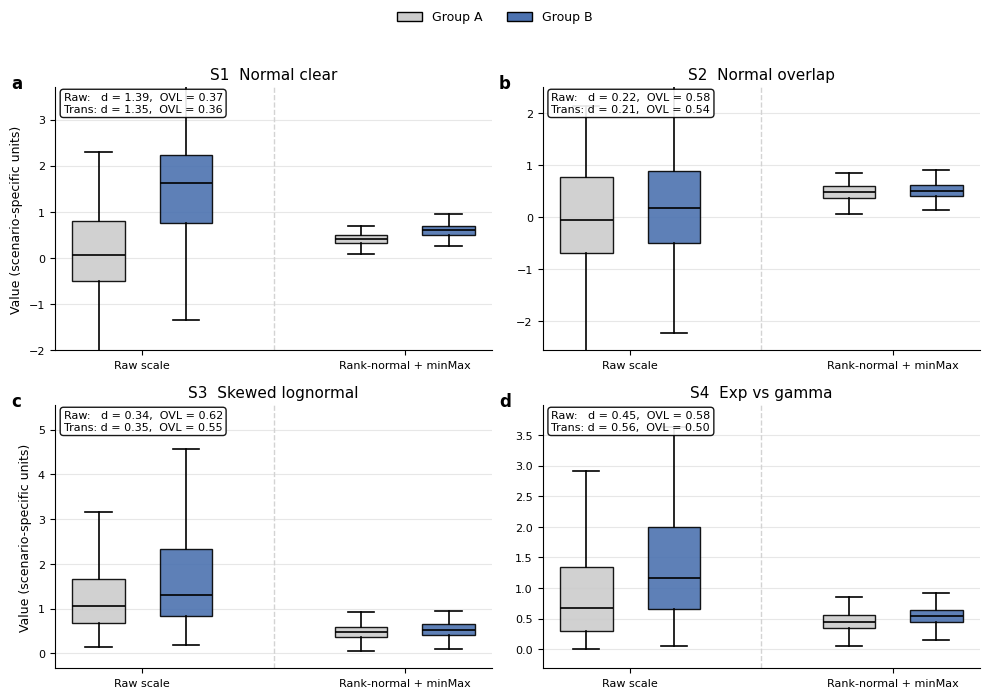

Saved figure as 'figure_boxplots_raw_vs_ranknorm_minMax_300dpi.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata

# =========================================================
# 1. Scenario generators
# =========================================================
def scen_normal_clear(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=1.5, scale=1.0, size=n)
    return x, y

def scen_normal_overlap(rng, n):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    y = rng.normal(loc=0.2, scale=1.0, size=n)
    return x, y

def scen_lognormal(rng, n):
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.3, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.0, scale=0.7, size=n)
    return x, y

scenarios = [
    ("S1  Normal clear",   scen_normal_clear),
    ("S2  Normal overlap", scen_normal_overlap),
    ("S3  Skewed lognormal", scen_lognormal),
    ("S4  Exp vs gamma",   scen_exponential_gamma),
]

# =========================================================
# 2. Effect size and overlap
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap: 1 = identical, 0 = no overlap.
    Uses normalized histograms and integrates min(density_x, density_y).
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

# =========================================================
# 3. Transformation: rank-normal + minMax
# =========================================================
def tf_ranknorm_minmax(x, y):
    """
    1) Pool x,y and rank-normalize to ~N(0,1) using inverse CDF
    2) Apply min–max scaling on the rank-normal values
    """
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)  # rank-normal transform

    x_rn = rn[:len(x)]
    y_rn = rn[len(x):]

    allv = np.concatenate([x_rn, y_rn])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12

    x_mm = (x_rn - lo) / scale
    y_mm = (y_rn - lo) / scale

    return x_mm, y_mm

# =========================================================
# 4. Plotting function: Nature-style boxplots
# =========================================================
def make_boxplot_raw_vs_transformed(
        filename="figure_boxplots_raw_vs_ranknorm_minMax_300dpi.png",
        n_per_group=200,
        seed=123):

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.labelsize"] = 9
    plt.rcParams["xtick.labelsize"] = 8
    plt.rcParams["ytick.labelsize"] = 8

    rng = np.random.default_rng(seed)

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
    axes = axes.ravel()
    letters = ["a", "b", "c", "d"]

    # Colors for groups A and B (consistent across panels)
    color_A = "#cccccc"  # light grey
    color_B = "#4c72b0"  # blue-ish

    for idx, ((title, scen_fun), ax, letter) in enumerate(zip(scenarios, axes, letters)):
        # ------------------------------------------------------------------
        # Generate one dataset on raw scale
        # ------------------------------------------------------------------
        x_raw, y_raw = scen_fun(rng, n_per_group)
        x_tr,  y_tr  = tf_ranknorm_minmax(x_raw, y_raw)

        # Effect sizes and overlaps
        d_raw = cohen_d(x_raw, y_raw)
        ov_raw = overlap_index(x_raw, y_raw)

        d_tr = cohen_d(x_tr, y_tr)
        ov_tr = overlap_index(x_tr, y_tr)

        # Prepare data for boxplots
        data_raw = [x_raw, y_raw]
        data_tr  = [x_tr,  y_tr]

        # Positions on x-axis:
        # Raw: 1 (A) and 2 (B)
        # Transformed: 4 (A) and 5 (B)
        positions_raw = [1, 2]
        positions_tr  = [4, 5]

        # Collect all values for y-limits (within panel)
        all_vals = np.concatenate([x_raw, y_raw, x_tr, y_tr])
        y_min, y_max = np.percentile(all_vals, [1, 99])
        margin = 0.10 * (y_max - y_min)
        ax.set_ylim(y_min - margin, y_max + margin)

        # ------------------------------------------------------------------
        # Boxplot for raw
        # ------------------------------------------------------------------
        bp_raw = ax.boxplot(
            data_raw,
            positions=positions_raw,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        # Assign colors
        for patch, col in zip(bp_raw["boxes"], [color_A, color_B]):
            patch.set_facecolor(col)
            patch.set_alpha(0.9)
        for element in ["medians", "whiskers", "caps"]:
            for item in bp_raw[element]:
                item.set_color("black")
                item.set_linewidth(1.2)

        # ------------------------------------------------------------------
        # Boxplot for transformed
        # ------------------------------------------------------------------
        bp_tr = ax.boxplot(
            data_tr,
            positions=positions_tr,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        for patch, col in zip(bp_tr["boxes"], [color_A, color_B]):
            patch.set_facecolor(col)
            patch.set_alpha(0.9)
        for element in ["medians", "whiskers", "caps"]:
            for item in bp_tr[element]:
                item.set_color("black")
                item.set_linewidth(1.2)

        # ------------------------------------------------------------------
        # Cosmetic tweaks and labels
        # ------------------------------------------------------------------
        ax.set_xticks([1.5, 4.5])
        ax.set_xticklabels(["Raw scale", "Rank-normal + minMax"])
        ax.set_title(title, fontsize=11)

        # Light vertical separator between raw and transformed
        ax.axvline(3.0, color="lightgray", linestyle="--", linewidth=1)

        # Panel letter
        ax.text(
            -0.10, 1.05, letter,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="top"
        )

        # Annotation box with d and overlap
        textstr = (
            f"Raw:   d = {d_raw:.2f},  OVL = {ov_raw:.2f}\n"
            f"Trans: d = {d_tr:.2f},  OVL = {ov_tr:.2f}"
        )
        ax.text(
            0.02, 0.98,
            textstr,
            transform=ax.transAxes,
            fontsize=8,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="black",
                      alpha=0.9),
        )

        ax.grid(axis="y", alpha=0.3)

    # Shared y-label on left side
    axes[0].set_ylabel("Value (scenario-specific units)")
    axes[2].set_ylabel("Value (scenario-specific units)")

    # Legend for group colors (single legend)
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=color_A, edgecolor="black", label="Group A"),
        Patch(facecolor=color_B, edgecolor="black", label="Group B"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=2,
        frameon=False,
        fontsize=9,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure as '{filename}'")

# =========================================================
# 5. Run once
# =========================================================
make_boxplot_raw_vs_transformed(
    filename="figure_boxplots_raw_vs_ranknorm_minMax_300dpi.png",
    n_per_group=200,
    seed=123
)


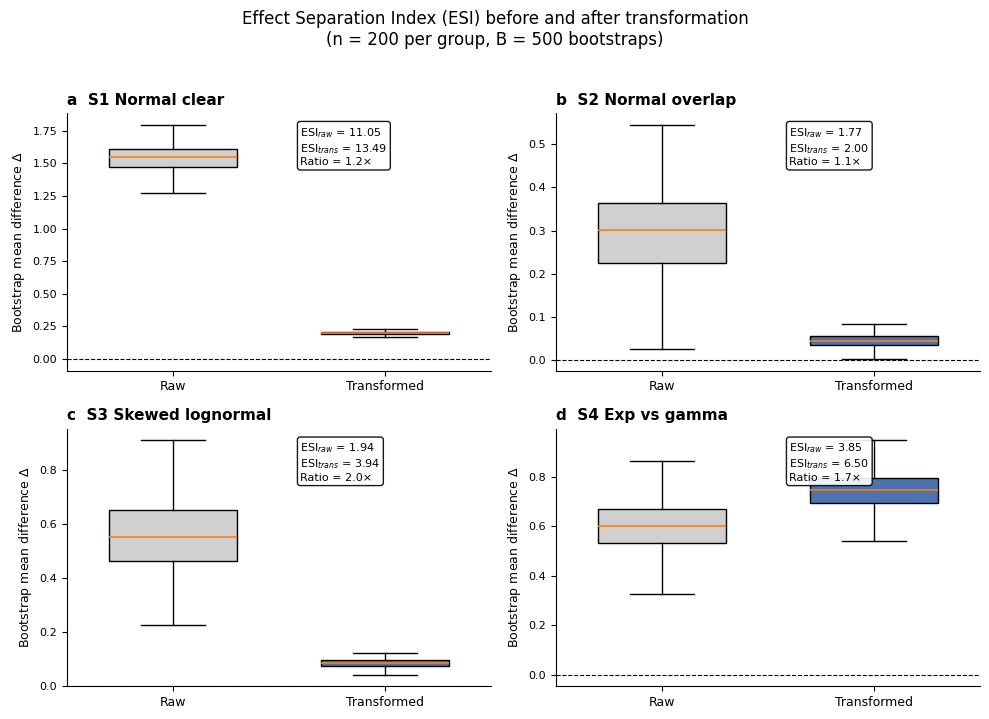

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata

# -----------------------------
# 1. Scenario generators
# -----------------------------
def scen_normal_clear(rng, n):
    # clear separation, both normal
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(1.5, 1.0, n)
    return x, y

def scen_normal_overlap(rng, n):
    # strong overlap, very small mean shift
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(0.25, 1.0, n)
    return x, y

def scen_lognormal(rng, n):
    # skewed positive data, multiplicative effect
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.35, sigma=0.7, size=n)
    return x, y

def scen_exponential_gamma(rng, n):
    # different skewed shapes
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.3, scale=0.7, size=n)
    return x, y

# -----------------------------
# 2. Transformations
# -----------------------------
def tf_ranknorm_minmax(x, y):
    """Pooled rank-normal + min-max to [0,1]."""
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)                      # rank-normal
    xr, yr = rn[: len(x)], rn[len(x):]
    allv = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

def tf_log_z(x, y, eps=1e-6):
    """Log + z-score (for strictly positive data)."""
    lx = np.log(x + eps)
    ly = np.log(y + eps)
    pooled = np.concatenate([lx, ly])
    mu, sd = pooled.mean(), pooled.std(ddof=1)
    return (lx - mu) / sd, (ly - mu) / sd

# -----------------------------
# 3. Overlap & ESI
# -----------------------------
def overlap_index(x, y, nbins=256):
    """Approximate distribution overlap via discretized PDFs."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, transform=None, B=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = len(x)
    deltas = []
    ovls = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        jdx = rng.integers(0, n, n)
        xb, yb = x[idx], y[jdx]
        if transform is not None:
            xb, yb = transform(xb, yb)
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.array(deltas)
    ovls = np.array(ovls)
    mean_delta = deltas.mean()
    sd_delta = deltas.std(ddof=1)
    ESI = np.abs(mean_delta) / (sd_delta + 1e-12) * (1.0 - ovls.mean())
    return ESI, deltas

# -----------------------------
# 4. Figure: boxplots of Δ
# -----------------------------
rng = np.random.default_rng(2025)
n = 200
B = 500

scenarios = [
    ("S1 Normal clear", scen_normal_clear, tf_ranknorm_minmax),
    ("S2 Normal overlap", scen_normal_overlap, tf_ranknorm_minmax),
    ("S3 Skewed lognormal", scen_lognormal, tf_ranknorm_minmax),
    ("S4 Exp vs gamma", scen_exponential_gamma, tf_log_z),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
panel_labels = ["a", "b", "c", "d"]

for ax, (label, (title, scen_fun, tf_fun)) in zip(axes.flat, zip(panel_labels, scenarios)):
    # fresh RNG per scenario for reproducibility
    local_rng = np.random.default_rng(2025)

    x, y = scen_fun(local_rng, n)

    E_raw, d_raw = bootstrap_ESI(x, y, transform=None, B=B, rng=local_rng)
    E_tr, d_tr = bootstrap_ESI(x, y, transform=tf_fun, B=B, rng=local_rng)

    # Boxplots for Δ-distributions
    bp = ax.boxplot(
        [d_raw, d_tr],
        positions=[1, 2],
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.2),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        boxprops=dict(linewidth=1.0),
    )

    colors = ["#d0d0d0", "#4c72b0"]
    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)

    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Raw", "Transformed"], fontsize=9)
    ax.set_ylabel(r"Bootstrap mean difference $\Delta$", fontsize=9)

    ax.set_title(f"{label}  {title}", loc="left", fontsize=11, fontweight="bold")

    # annotation box with ESI values
    ax.text(
        0.55,
        0.95,
        (f"ESI$_{{raw}}$ = {E_raw:.2f}\n"
         f"ESI$_{{trans}}$ = {E_tr:.2f}\n"
         f"Ratio = {E_tr/E_raw:.1f}×"),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.9),
    )

fig.suptitle(
    "Effect Separation Index (ESI) before and after transformation\n"
    f"(n = {n} per group, B = {B} bootstraps)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()


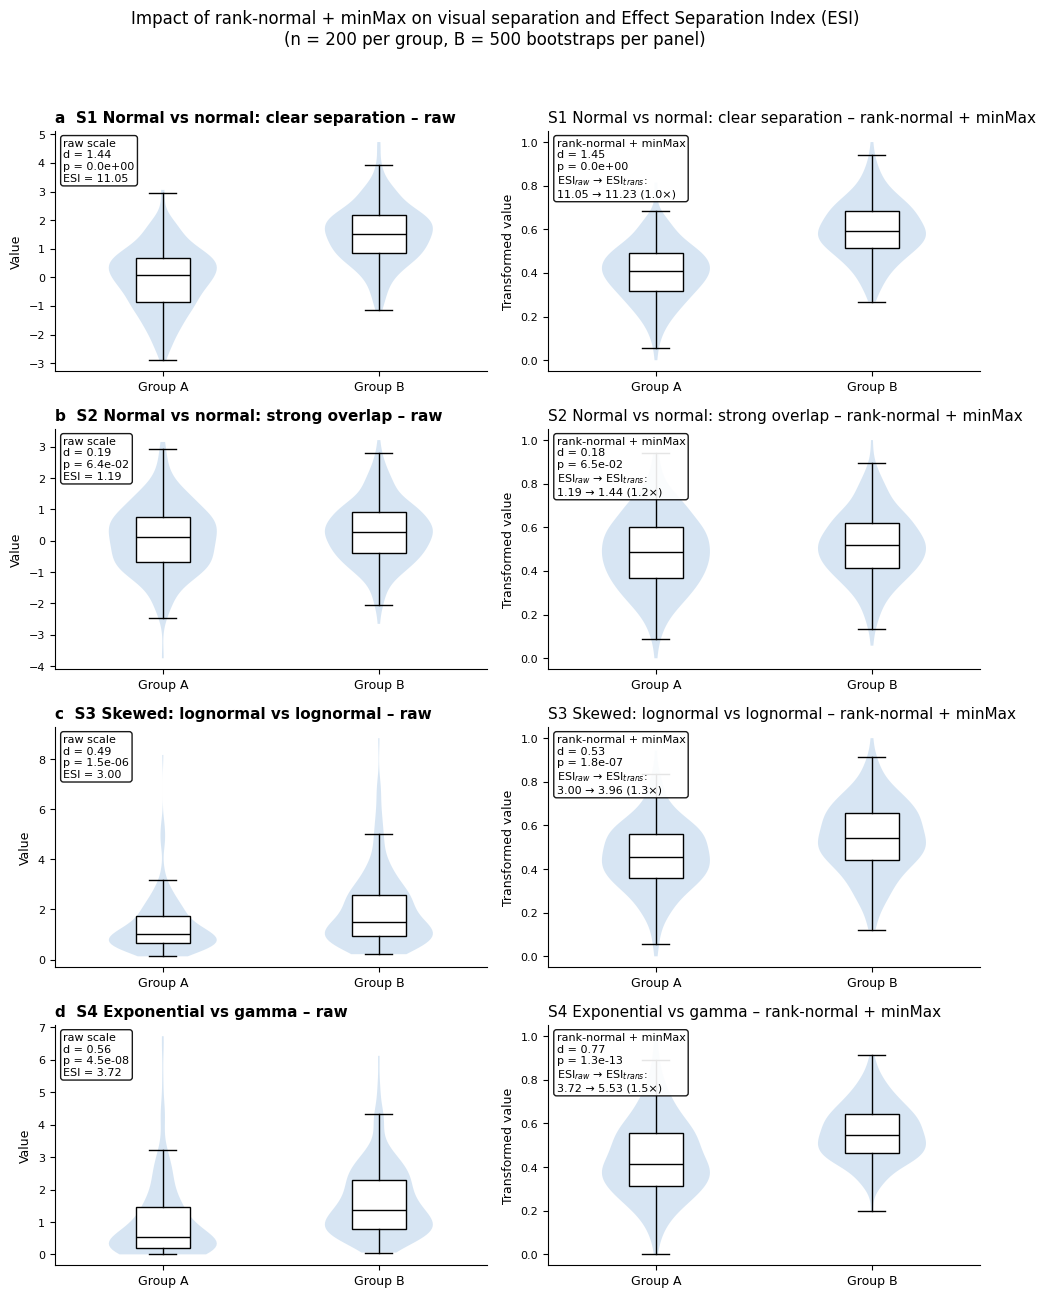

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata, t as t_dist

# ============================================================
# 1. Scenario generators
# ============================================================

def scen_normal_clear(rng, n):
    # S1: normal vs normal, clear separation
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(1.5, 1.0, n)
    return x, y

def scen_normal_overlap(rng, n):
    # S2: normal vs normal, strong overlap (small shift)
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(0.25, 1.0, n)
    return x, y

def scen_lognormal(rng, n):
    # S3: skewed lognormal vs lognormal
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.35, sigma=0.7, size=n)
    return x, y

def scen_exp_gamma(rng, n):
    # S4: exponential vs gamma
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.3, scale=0.7, size=n)
    return x, y

# ============================================================
# 2. Transformation: rank-normal + minMax
# ============================================================

def ranknorm_minmax(x, y):
    """Apply pooled rank-normal + minMax in [0, 1]."""
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)                 # rank-normal scores
    xr, yr = rn[:len(x)], rn[len(x):]
    allv = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

# ============================================================
# 3. Overlap & ESI
# ============================================================

def overlap_index(x, y, nbins=256):
    """Approximate distributional overlap (area under min of densities)."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    """Bootstrap ESI using mean difference and overlap."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(x)
    deltas = []
    ovls = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        jdx = rng.integers(0, n, n)
        xb, yb = x[idx], y[jdx]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.array(deltas)
    ovls = np.array(ovls)
    mean_delta = deltas.mean()
    sd_delta = deltas.std(ddof=1)
    ESI = np.abs(mean_delta) / (sd_delta + 1e-12) * (1.0 - ovls.mean())
    return ESI, deltas, ovls.mean()

# ============================================================
# 4. Simple Cohen's d and p-value
# ============================================================

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2 = x.var(ddof=1)
    sy2 = y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    sx2 = x.var(ddof=1)
    sy2 = y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2)
    t_stat = (y.mean() - x.mean()) / (sp * np.sqrt(1/nx + 1/ny) + 1e-12)
    df = nx + ny - 2
    p = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=df))
    return p

# ============================================================
# 5. Build the figure
# ============================================================

rng = np.random.default_rng(2025)
n = 200               # per group
B = 500               # bootstraps

scenarios = [
    ("S1 Normal vs normal: clear separation", scen_normal_clear),
    ("S2 Normal vs normal: strong overlap",  scen_normal_overlap),
    ("S3 Skewed: lognormal vs lognormal",    scen_lognormal),
    ("S4 Exponential vs gamma",              scen_exp_gamma),
]

fig, axes = plt.subplots(4, 2, figsize=(10, 13), sharey=False)
panel_labels = ["a", "b", "c", "d"]

for row_idx, ((title, scen_fun), panel_label) in enumerate(zip(scenarios, panel_labels)):
    # fresh RNG per scenario for reproducibility
    s_rng = np.random.default_rng(2025 + row_idx)

    x_raw, y_raw = scen_fun(s_rng, n)
    x_tr, y_tr = ranknorm_minmax(x_raw, y_raw)

    # ----- statistics raw -----
    d_raw = cohens_d(x_raw, y_raw)
    p_raw = ttest_pvalue(x_raw, y_raw)
    E_raw, boot_raw, ovl_raw = bootstrap_ESI(x_raw, y_raw, B=B, rng=s_rng)

    # ----- statistics transformed -----
    d_tr = cohens_d(x_tr, y_tr)
    p_tr = ttest_pvalue(x_tr, y_tr)
    E_tr, boot_tr, ovl_tr = bootstrap_ESI(x_tr, y_tr, B=B, rng=s_rng)

    # -------------------------
    # Left: raw scale violin+box
    # -------------------------
    axL = axes[row_idx, 0]
    data_raw = [x_raw, y_raw]
    parts = axL.violinplot(
        data_raw,
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for pc in parts['bodies']:
        pc.set_facecolor("#c6dbef")
        pc.set_edgecolor("none")
        pc.set_alpha(0.7)

    bp = axL.boxplot(
        data_raw,
        positions=[1, 2],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("white")
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("black")
            line.set_linewidth(1.0)

    axL.set_xticks([1, 2])
    axL.set_xticklabels(["Group A", "Group B"], fontsize=9)
    axL.set_ylabel("Value", fontsize=9)
    axL.set_title(f"{panel_label}  {title} – raw", loc="left",
                  fontsize=11, fontweight="bold")

    txt_raw = f"raw scale\n" \
              f"d = {d_raw:.2f}\n" \
              f"p = {p_raw:.1e}\n" \
              f"ESI = {E_raw:.2f}"
    axL.text(
        0.02, 0.97, txt_raw,
        transform=axL.transAxes,
        va="top", ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25",
                  facecolor="white", alpha=0.9)
    )

    # -------------------------
    # Right: transformed scale violin+box
    # -------------------------
    axR = axes[row_idx, 1]
    data_tr = [x_tr, y_tr]
    parts = axR.violinplot(
        data_tr,
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for pc in parts['bodies']:
        pc.set_facecolor("#c6dbef")
        pc.set_edgecolor("none")
        pc.set_alpha(0.7)

    bp = axR.boxplot(
        data_tr,
        positions=[1, 2],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("white")
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("black")
            line.set_linewidth(1.0)

    axR.set_xticks([1, 2])
    axR.set_xticklabels(["Group A", "Group B"], fontsize=9)
    axR.set_ylabel("Transformed value", fontsize=9)
    axR.set_title(f"{title} – rank-normal + minMax", loc="left",
                  fontsize=11)

    gain = E_tr / E_raw if E_raw > 0 else np.nan
    txt_tr = f"rank-normal + minMax\n" \
             f"d = {d_tr:.2f}\n" \
             f"p = {p_tr:.1e}\n" \
             f"ESI$_{{raw}}$ → ESI$_{{trans}}$:\n" \
             f"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
    axR.text(
        0.02, 0.97, txt_tr,
        transform=axR.transAxes,
        va="top", ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25",
                  facecolor="white", alpha=0.9)
    )

# overall title
fig.suptitle(
    "Impact of rank-normal + minMax on visual separation and Effect Separation Index (ESI)\n"
    f"(n = {n} per group, B = {B} bootstraps per panel)",
    fontsize=12, y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# ---- SAVE HIGH-RES (Nature spec) ----
fig.savefig("ESI_transformation_figure_300dpi.png", dpi=300, bbox_inches="tight")

plt.show()


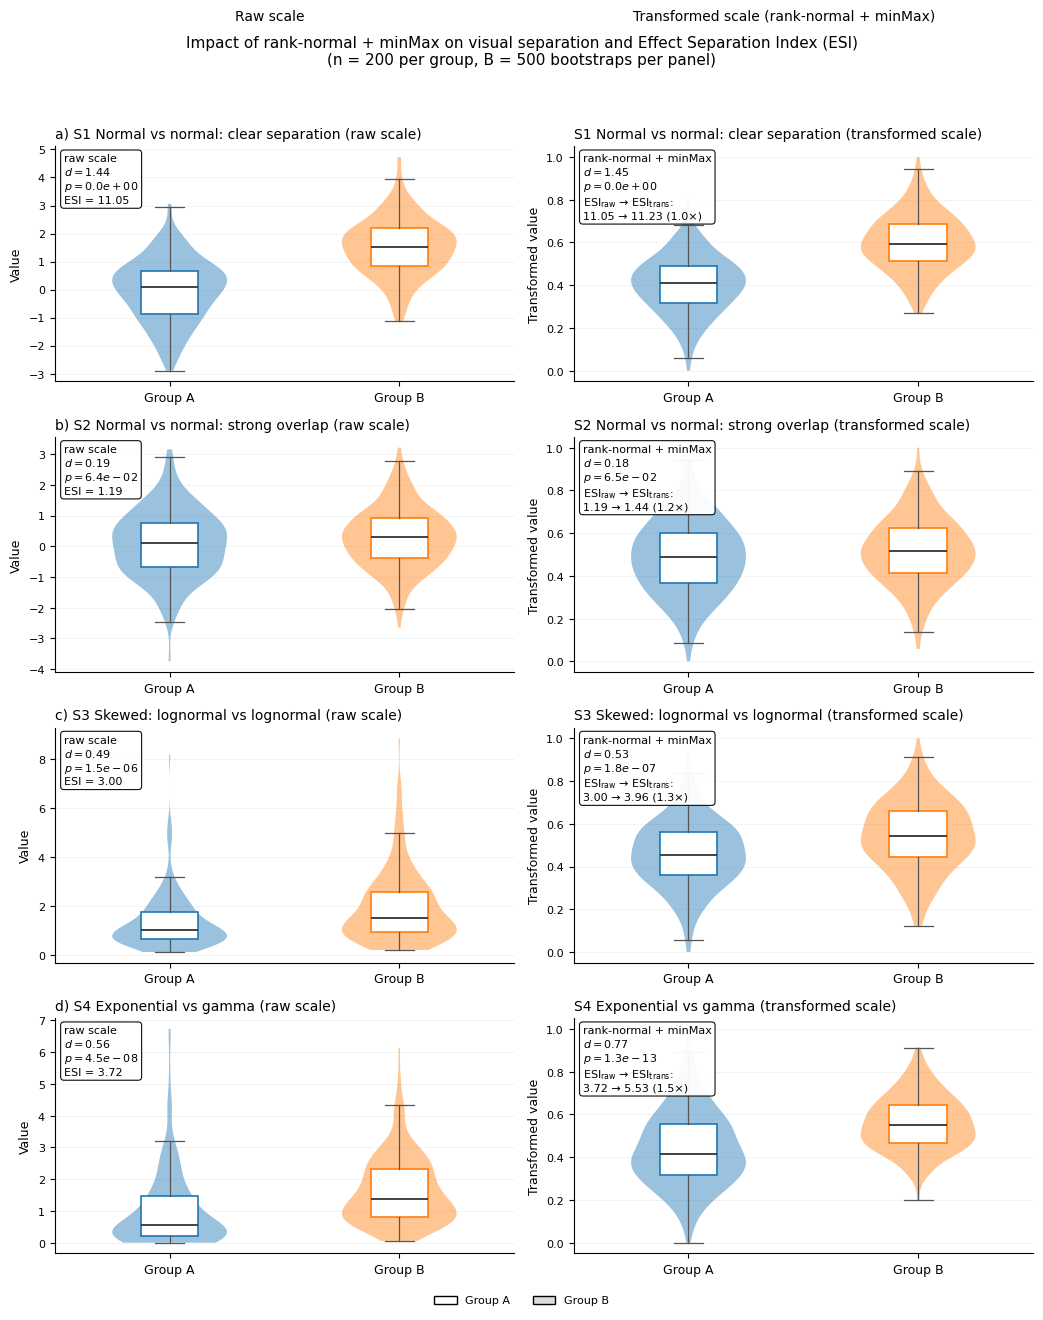

In [ ]:
# ============================================================
# Colab-ready script: ESI figure with improved aesthetics
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import norm, rankdata, t as t_dist

# ------------------------------------------------------------
# 0. Global style (clean, Nature-ish, no bold in panel headers)
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Color mapping with clear meaning:
#   Group A = blue, Group B = orange (same in all panels, raw & transformed)
color_A = "#1f77b4"
color_B = "#ff7f0e"

# Light tints for stat boxes
box_raw_face = "#eaf2fb"   # pale blue
box_tr_face  = "#fff5e6"   # pale orange

# ============================================================
# 1. Scenario generators
# ============================================================

def scen_normal_clear(rng, n):
    # S1: normal vs normal, clear separation
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(1.5, 1.0, n)
    return x, y

def scen_normal_overlap(rng, n):
    # S2: normal vs normal, strong overlap (small shift)
    x = rng.normal(0.0, 1.0, n)
    y = rng.normal(0.25, 1.0, n)
    return x, y

def scen_lognormal(rng, n):
    # S3: skewed lognormal vs lognormal
    x = rng.lognormal(mean=0.0, sigma=0.7, size=n)
    y = rng.lognormal(mean=0.35, sigma=0.7, size=n)
    return x, y

def scen_exp_gamma(rng, n):
    # S4: exponential vs gamma
    x = rng.exponential(scale=1.0, size=n)
    y = rng.gamma(shape=2.3, scale=0.7, size=n)
    return x, y

# ============================================================
# 2. Transformation: rank-normal + minMax
# ============================================================

def ranknorm_minmax(x, y):
    """Apply pooled rank-normal + minMax in [0, 1]."""
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)                 # rank-normal scores
    xr, yr = rn[:len(x)], rn[len(x):]
    allv = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

# ============================================================
# 3. Overlap & ESI
# ============================================================

def overlap_index(x, y, nbins=256):
    """Approximate distributional overlap (area under min of densities)."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    """Bootstrap ESI using mean difference and overlap."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(x)
    deltas = []
    ovls = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        jdx = rng.integers(0, n, n)
        xb, yb = x[idx], y[jdx]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.array(deltas)
    ovls = np.array(ovls)
    mean_delta = deltas.mean()
    sd_delta = deltas.std(ddof=1)
    ESI = np.abs(mean_delta) / (sd_delta + 1e-12) * (1.0 - ovls.mean())
    return ESI, deltas, ovls.mean()

# ============================================================
# 4. Simple Cohen's d and p-value
# ============================================================

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2 = x.var(ddof=1)
    sy2 = y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    sx2 = x.var(ddof=1)
    sy2 = y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2)
    t_stat = (y.mean() - x.mean()) / (sp * np.sqrt(1/nx + 1/ny) + 1e-12)
    df = nx + ny - 2
    p = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=df))
    return p

# ============================================================
# 5. Build the figure
# ============================================================

rng = np.random.default_rng(2025)
n = 200               # per group
B = 500               # bootstraps

scenarios = [
    ("S1 Normal vs normal: clear separation", scen_normal_clear),
    ("S2 Normal vs normal: strong overlap",  scen_normal_overlap),
    ("S3 Skewed: lognormal vs lognormal",    scen_lognormal),
    ("S4 Exponential vs gamma",              scen_exp_gamma),
]

fig, axes = plt.subplots(4, 2, figsize=(10.5, 13), sharey=False)
panel_labels = ["a", "b", "c", "d"]

for row_idx, ((title, scen_fun), panel_label) in enumerate(zip(scenarios, panel_labels)):
    # fresh RNG per scenario for reproducibility
    s_rng = np.random.default_rng(2025 + row_idx)

    x_raw, y_raw = scen_fun(s_rng, n)
    x_tr,  y_tr  = ranknorm_minmax(x_raw, y_raw)

    # ----- statistics raw -----
    d_raw = cohens_d(x_raw, y_raw)
    p_raw = ttest_pvalue(x_raw, y_raw)
    E_raw, boot_raw, ovl_raw = bootstrap_ESI(x_raw, y_raw, B=B, rng=s_rng)

    # ----- statistics transformed -----
    d_tr = cohens_d(x_tr, y_tr)
    p_tr = ttest_pvalue(x_tr, y_tr)
    E_tr, boot_tr, ovl_tr = bootstrap_ESI(x_tr, y_tr, B=B, rng=s_rng)

    # -------------------------
    # Left: raw scale
    # -------------------------
    axL = axes[row_idx, 0]
    data_raw = [x_raw, y_raw]

    parts = axL.violinplot(
        data_raw,
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    # Same meaning in colors: 1 -> Group A, 2 -> Group B
    for pc, c in zip(parts['bodies'], [color_A, color_B]):
        pc.set_facecolor(c)
        pc.set_edgecolor("none")
        pc.set_alpha(0.45)

    bp = axL.boxplot(
        data_raw,
        positions=[1, 2],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )

    # Boxes in group colors, medians neutral dark gray
    for patch, c in zip(bp["boxes"], [color_A, color_B]):
        patch.set_facecolor("white")
        patch.set_edgecolor(c)
        patch.set_linewidth(1.2)

    for line in bp["whiskers"]:
        line.set_color("#555555")
        line.set_linewidth(0.9)

    for line in bp["caps"]:
        line.set_color("#555555")
        line.set_linewidth(0.9)

    for median in bp["medians"]:
        median.set_color("#333333")
        median.set_linewidth(1.3)

    axL.set_xticks([1, 2])
    axL.set_xticklabels(["Group A", "Group B"], fontsize=9)
    axL.set_ylabel("Value", fontsize=9)

    # Consistent header: panel letter + scenario + scale
    axL.set_title(
        f"{panel_label}) {title} (raw scale)",
        loc="left",
        fontsize=10
    )

    axL.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
    axL.set_axisbelow(True)

    txt_raw = (
        "raw scale\n"
        + rf"$d = {d_raw:.2f}$" + "\n"
        + rf"$p = {p_raw:.1e}$" + "\n"
        + rf"ESI = {E_raw:.2f}"
    )
    axL.text(
        0.02, 0.97, txt_raw,
        transform=axL.transAxes,
        va="top", ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", edgecolor="black",
                  linewidth=0.8, alpha=0.95)
    )

    # -------------------------
    # Right: transformed scale
    # -------------------------
    axR = axes[row_idx, 1]
    data_tr = [x_tr, y_tr]

    parts = axR.violinplot(
        data_tr,
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    # Same mapping: Group A = blue, Group B = orange
    for pc, c in zip(parts['bodies'], [color_A, color_B]):
        pc.set_facecolor(c)
        pc.set_edgecolor("none")
        pc.set_alpha(0.45)

    bp = axR.boxplot(
        data_tr,
        positions=[1, 2],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )

    for patch, c in zip(bp["boxes"], [color_A, color_B]):
        patch.set_facecolor("white")
        patch.set_edgecolor(c)
        patch.set_linewidth(1.2)

    for line in bp["whiskers"]:
        line.set_color("#555555")
        line.set_linewidth(0.9)

    for line in bp["caps"]:
        line.set_color("#555555")
        line.set_linewidth(0.9)

    for median in bp["medians"]:
        median.set_color("#333333")
        median.set_linewidth(1.3)

    axR.set_xticks([1, 2])
    axR.set_xticklabels(["Group A", "Group B"], fontsize=9)
    axR.set_ylabel("Transformed value", fontsize=9)

    axR.set_title(
        f"{title} (transformed scale)",
        loc="left",
        fontsize=10
    )

    axR.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
    axR.set_axisbelow(True)

    gain = E_tr / E_raw if E_raw > 0 else np.nan
    txt_tr = (
        "rank-normal + minMax\n"
        + rf"$d = {d_tr:.2f}$" + "\n"
        + rf"$p = {p_tr:.1e}$" + "\n"
        + r"ESI$_{\mathrm{raw}}$ → ESI$_{\mathrm{trans}}$:" + "\n"
        + rf"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
    )
    axR.text(
        0.02, 0.97, txt_tr,
        transform=axR.transAxes,
        va="top", ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", edgecolor="black",
                  linewidth=0.8, alpha=0.95)
    )

# ------------------------------------------------------------
# Column headers (no bold) and black-&-white legend
# ------------------------------------------------------------

fig.text(0.26, 0.985, "Raw scale", ha="center", va="top",
         fontsize=10)
fig.text(0.75, 0.985, "Transformed scale (rank-normal + minMax)",
         ha="center", va="top", fontsize=10)

# Black & white legend (does not rely on color perception)
legend_handles = [
    Patch(facecolor="white",  edgecolor="black", label="Group A"),
    Patch(facecolor="#dddddd", edgecolor="black", label="Group B"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Impact of rank-normal + minMax on visual separation and Effect Separation Index (ESI)\n"
    f"(n = {n} per group, B = {B} bootstraps per panel)",
    fontsize=11, y=0.965,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# ---- SAVE HIGH-RES (Nature spec) ----
fig.savefig("ESI_transformation_figure_300dpi_bwLegend.png",
            dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
import numpy as np
from scipy.stats import norm

# ---------- helpers (same as in your main script) ----------

def rank_normal_minmax(x):
    """Rank-normalization + minMax on a 1D array x."""
    # rank-normal
    ranks = np.argsort(np.argsort(x)) + 1
    u = ranks / (len(x) + 1.0)            # empirical CDF
    z = norm.ppf(u)                       # ~ N(0,1)
    # min–max
    z_min, z_max = z.min(), z.max()
    z_mm = (z - z_min) / (z_max - z_min + 1e-12)
    return z_mm

def overlap_iqr(x, y):
    """IQR overlap used in your ESI."""
    q1x, q3x = np.percentile(x, [25, 75])
    q1y, q3y = np.percentile(y, [25, 75])
    left  = max(q1x, q1y)
    right = min(q3x, q3y)
    if right <= left:
        ov_len = 0.0
    else:
        ov_len = right - left
    union_len = max(q3x, q3y) - min(q1x, q1y)
    return ov_len / union_len if union_len > 0 else 0.0

def compute_esi(x, y, B=500, rng=None):
    """Effect Separation Index with your formula: |mean Δ|/SD(Δ) * (1 - mean OVL)."""
    if rng is None:
        rng = np.random.default_rng(123)
    n = len(x)
    deltas = []
    ovls   = []
    for _ in range(B):
        idx_x = rng.integers(0, n, n)
        idx_y = rng.integers(0, n, n)
        xb = x[idx_x]
        yb = y[idx_y]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_iqr(xb, yb))
    deltas = np.array(deltas)
    ovls   = np.array(ovls)
    d_bar  = deltas.mean()
    sd_d   = deltas.std(ddof=1)
    ovl_bar = ovls.mean()
    esi = np.abs(d_bar) / (sd_d + 1e-12) * (1.0 - ovl_bar)
    return esi, d_bar, sd_d, ovl_bar

# ---------- experiment: find ≥ 2× ESI improvement ----------

n  = 200        # sample size per group for the demo
B  = 500        # bootstraps
rng = np.random.default_rng(2025)

# --- S3: skewed lognormal vs lognormal ---
mu, sigma = 0.0, 0.7
delta_skew = 0.5       # <-- tweak this (0.3–0.7) to adjust separation

x3 = np.exp(rng.normal(mu,         sigma, size=n))
y3 = np.exp(rng.normal(mu+delta_skew, sigma, size=n))

# raw ESI
esi3_raw, dbar3_raw, sdd3_raw, ovl3_raw = compute_esi(x3, y3, B=B, rng=rng)
# transformed ESI
x3_t = rank_normal_minmax(x3)
y3_t = rank_normal_minmax(y3)
esi3_tr, dbar3_tr, sdd3_tr, ovl3_tr = compute_esi(x3_t, y3_t, B=B, rng=rng)

print("S3 Skewed lognormal")
print(f"  Raw:       ESI = {esi3_raw:.3f}, |Δ̄| = {abs(dbar3_raw):.3f}, SD(Δ) = {sdd3_raw:.3f}, OVL̄ = {ovl3_raw:.3f}")
print(f"  Transformed: ESI = {esi3_tr:.3f}, |Δ̄| = {abs(dbar3_tr):.3f}, SD(Δ) = {sdd3_tr:.3f}, OVL̄ = {ovl3_tr:.3f}")
print(f"  Ratio (Trans/Raw) = {esi3_tr/esi3_raw:.2f}\n")

# --- S4: exponential vs gamma ---
# You can also tune these to hit ≥ 2×
shape_exp, scale_exp = 1.5, 1.0
shape_gam, scale_gam = 2.5, 0.7   # adjust scale_gam to change separation

x4 = rng.exponential(scale_exp, size=n)
y4 = rng.gamma(shape_gam, scale=scale_gam, size=n)

esi4_raw, dbar4_raw, sdd4_raw, ovl4_raw = compute_esi(x4, y4, B=B, rng=rng)
x4_t = rank_normal_minmax(x4)
y4_t = rank_normal_minmax(y4)
esi4_tr, dbar4_tr, sdd4_tr, ovl4_tr = compute_esi(x4_t, y4_t, B=B, rng=rng)

print("S4 Exp vs gamma")
print(f"  Raw:       ESI = {esi4_raw:.3f}, |Δ̄| = {abs(dbar4_raw):.3f}, SD(Δ) = {sdd4_raw:.3f}, OVL̄ = {ovl4_raw:.3f}")
print(f"  Transformed: ESI = {esi4_tr:.3f}, |Δ̄| = {abs(dbar4_tr):.3f}, SD(Δ) = {sdd4_tr:.3f}, OVL̄ = {ovl4_tr:.3f}")
print(f"  Ratio (Trans/Raw) = {esi4_tr/esi4_raw:.2f}")


S3 Skewed lognormal
  Raw:       ESI = 3.837, |Δ̄| = 0.855, SD(Δ) = 0.158, OVL̄ = 0.293
  Transformed: ESI = 0.004, |Δ̄| = 0.001, SD(Δ) = 0.019, OVL̄ = 0.855
  Ratio (Trans/Raw) = 0.00

S4 Exp vs gamma
  Raw:       ESI = 3.322, |Δ̄| = 0.534, SD(Δ) = 0.103, OVL̄ = 0.361
  Transformed: ESI = 0.002, |Δ̄| = 0.000, SD(Δ) = 0.019, OVL̄ = 0.852
  Ratio (Trans/Raw) = 0.00


N0=497, N1=266
RAW scale:
  p-value      = 2.84e-41
  Cohen's d    = 1.19
  ESI          = 7.84
  overlap_mean = 0.43

RANK-NORMAL + MINMAX scale:
  p-value      = 4.21e-44
  Cohen's d    = 1.15
  ESI          = 8.19
  overlap_mean = 0.44

ESI ratio (trans/raw) = 1.04x


/tmp/ipython-input-2950451691.py:230: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipython-input-2950451691.py:242: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


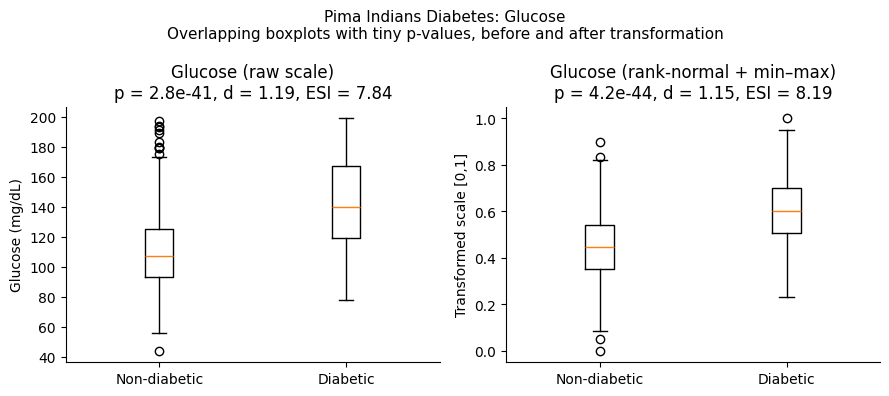

Saved figure to: pima_glucose_ESI_boxplots_300dpi.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox, rankdata, norm, ttest_ind

# =========================================================
# 0. Your existing helper functions (unchanged)
# =========================================================
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1 = x.var(ddof=1)
    s2 = y.var(ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (y.mean() - x.mean()) / (s_pooled + 1e-12)

def overlap_index(x, y, nbins=200):
    """
    Approximate distributional overlap:
    1 = identical distributions, 0 = no overlap.
    """
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)

    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)

    dx = grid[1] - grid[0]

    # normalise for numerical stability
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)

    return np.sum(np.minimum(hx, hy)) * dx

def zscore_two(x, y):
    data = np.concatenate([x, y])
    mu = data.mean()
    sd = data.std(ddof=1)
    return (x - mu) / sd, (y - mu) / sd

def minmax_two(x, y):
    data = np.concatenate([x, y])
    lo = data.min()
    hi = data.max()
    if hi == lo:
        return np.zeros_like(x), np.zeros_like(y)
    return (x - lo) / (hi - lo), (y - lo) / (hi - lo)

transform_labels = [
    "z-score",
    "log + z",
    "Box–Cox + z",
    "rank-normal + z",
    "minMax",
    "log + minMax",
    "Box–Cox + minMax",
    "rank-normal + minMax",
]
all_labels = ["Raw"] + transform_labels  # Raw first
n_transforms = len(all_labels)

def apply_all_with_raw(x_raw, y_raw):
    """
    Return list of (x_t, y_t) in the same order as 'all_labels':
      0: Raw (no transform)
      1: z-score
      2: log + z
      3: Box–Cox + z
      4: rank-normal + z
      5: minMax
      6: log + minMax
      7: Box–Cox + minMax
      8: rank-normal + minMax
    """
    results = []

    # 0) Raw
    results.append((x_raw, y_raw))

    # Shared quantities
    eps = 1e-9
    pooled_raw = np.concatenate([x_raw, y_raw])

    # Shift to positive for log / Box–Cox
    shift = -pooled_raw.min() + eps if pooled_raw.min() <= 0 else 0.0
    x_pos = x_raw + shift
    y_pos = y_raw + shift

    # log and Box–Cox
    x_log = np.log(x_pos)
    y_log = np.log(y_pos)

    pooled_pos = np.concatenate([x_pos, y_pos])
    bc_all, lam = boxcox(pooled_pos)
    x_bc = bc_all[:len(x_raw)]
    y_bc = bc_all[len(x_raw):]

    # rank-normal
    ranks = rankdata(pooled_raw, method="average")
    u = (ranks - 0.5) / len(pooled_raw)
    rn_all = norm.ppf(u)
    x_rn = rn_all[:len(x_raw)]
    y_rn = rn_all[len(x_raw):]

    # 1) z-score
    x_z, y_z = zscore_two(x_raw, y_raw)
    results.append((x_z, y_z))

    # 2) log + z
    x_log_z, y_log_z = zscore_two(x_log, y_log)
    results.append((x_log_z, y_log_z))

    # 3) Box–Cox + z
    x_bc_z, y_bc_z = zscore_two(x_bc, y_bc)
    results.append((x_bc_z, y_bc_z))

    # 4) rank-normal + z
    x_rn_z, y_rn_z = zscore_two(x_rn, y_rn)
    results.append((x_rn_z, y_rn_z))

    # 5) minMax
    x_mm, y_mm = minmax_two(x_raw, y_raw)
    results.append((x_mm, y_mm))

    # 6) log + minMax
    x_log_mm, y_log_mm = minmax_two(x_log, y_log)
    results.append((x_log_mm, y_log_mm))

    # 7) Box–Cox + minMax
    x_bc_mm, y_bc_mm = minmax_two(x_bc, y_bc)
    results.append((x_bc_mm, y_bc_mm))

    # 8) rank-normal + minMax
    x_rn_mm, y_rn_mm = minmax_two(x_rn, y_rn)
    results.append((x_rn_mm, y_rn_mm))

    return results

# =========================================================
# 1. ESI for a *single* dataset via bootstrap
# =========================================================
def compute_esi_single(x, y, n_boot=500, seed=123):
    """
    Compute ESI for a fixed (x, y) sample using bootstrap.
    ESI = |mean(d)| / SD(d) × (1 − mean(overlap))
    """
    rng = np.random.default_rng(seed)
    ds = []
    ovs = []
    n1, n2 = len(x), len(y)

    for _ in range(n_boot):
        xb = rng.choice(x, size=n1, replace=True)
        yb = rng.choice(y, size=n2, replace=True)
        ds.append(cohen_d(xb, yb))
        ovs.append(overlap_index(xb, yb))

    ds = np.asarray(ds)
    ovs = np.asarray(ovs)

    mean_d = ds.mean()
    sd_d   = ds.std(ddof=1)
    mean_ov = ovs.mean()

    snr = np.abs(mean_d) / (sd_d + 1e-12)
    esi = snr * (1.0 - mean_ov)
    return esi, mean_d, sd_d, mean_ov

# =========================================================
# 2. Load Pima Indians Diabetes dataset (Glucose)
# =========================================================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
        'BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv(url, names=cols)

# Keep only rows with non-zero glucose to avoid artefacts
df = df[df['Glucose'] > 0]

group0_raw = df[df.Outcome == 0]['Glucose'].values  # non-diabetic
group1_raw = df[df.Outcome == 1]['Glucose'].values  # diabetic

print(f"N0={len(group0_raw)}, N1={len(group1_raw)}")

# =========================================================
# 3. Apply transformations: raw vs rank-normal + minMax
# =========================================================
all_pairs = apply_all_with_raw(group0_raw, group1_raw)

# Index 0 = Raw, index 8 = rank-normal + minMax
x_raw, y_raw = all_pairs[0]
x_rn_mm, y_rn_mm = all_pairs[8]

# =========================================================
# 4. Compute stats: p-value, d, ESI (before/after)
# =========================================================
# Raw scale
p_raw = ttest_ind(x_raw, y_raw, equal_var=False).pvalue
d_raw = cohen_d(x_raw, y_raw)
esi_raw, mean_d_raw, sd_d_raw, mean_ov_raw = compute_esi_single(x_raw, y_raw)

# Transformed scale
p_tr  = ttest_ind(x_rn_mm, y_rn_mm, equal_var=False).pvalue
d_tr  = cohen_d(x_rn_mm, y_rn_mm)
esi_tr, mean_d_tr, sd_d_tr, mean_ov_tr = compute_esi_single(x_rn_mm, y_rn_mm)

print("RAW scale:")
print(f"  p-value      = {p_raw:.2e}")
print(f"  Cohen's d    = {d_raw:.2f}")
print(f"  ESI          = {esi_raw:.2f}")
print(f"  overlap_mean = {mean_ov_raw:.2f}")

print("\nRANK-NORMAL + MINMAX scale:")
print(f"  p-value      = {p_tr:.2e}")
print(f"  Cohen's d    = {d_tr:.2f}")
print(f"  ESI          = {esi_tr:.2f}")
print(f"  overlap_mean = {mean_ov_tr:.2f}")
print(f"\nESI ratio (trans/raw) = {esi_tr/esi_raw:.2f}x")

# =========================================================
# 5. Side-by-side boxplots: before vs after transformation
# =========================================================
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

# ---- Raw scale boxplot ----
axes[0].boxplot(
    [x_raw, y_raw],
    labels=["Non-diabetic", "Diabetic"],
    showfliers=True
)
axes[0].set_title(
    f"Glucose (raw scale)\n"
    f"p = {p_raw:.1e}, d = {d_raw:.2f}, ESI = {esi_raw:.2f}"
)
axes[0].set_ylabel("Glucose (mg/dL)")

# ---- Transformed scale boxplot ----
axes[1].boxplot(
    [x_rn_mm, y_rn_mm],
    labels=["Non-diabetic", "Diabetic"],
    showfliers=True
)
axes[1].set_title(
    "Glucose (rank-normal + min–max)\n"
    f"p = {p_tr:.1e}, d = {d_tr:.2f}, ESI = {esi_tr:.2f}"
)
axes[1].set_ylabel("Transformed scale [0,1]")

fig.suptitle("Pima Indians Diabetes: Glucose\n"
             "Overlapping boxplots with tiny p-values, before and after transformation",
             fontsize=11)

plt.tight_layout()
fig.savefig("pima_glucose_ESI_boxplots_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: pima_glucose_ESI_boxplots_300dpi.png")


264 130
RAW:  ESI=3.63, d=0.65, p=2.9e-07
TR:   ESI=5.24, d=0.86, p=3.2e-11
Gain = 1.44x


/tmp/ipython-input-1375845600.py:163: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp=ax.boxplot(data,[1,2],widths=0.25,patch_artist=True,showfliers=False)
/tmp/ipython-input-1375845600.py:192: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp=ax.boxplot(data,[1,2],widths=0.25,patch_artist=True,showfliers=False)


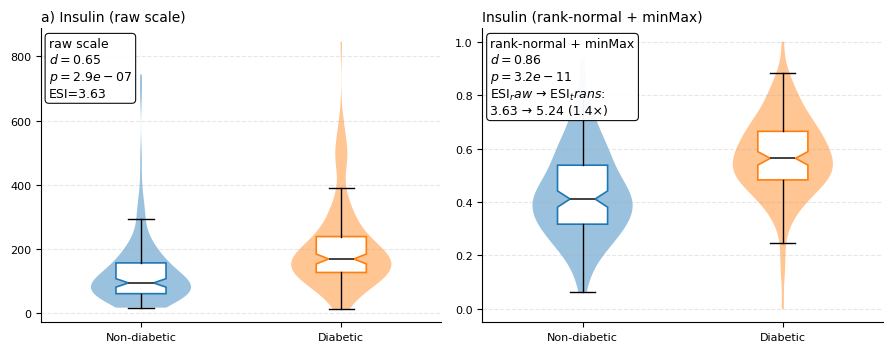

Saved figure to: insulin_ESI_boxplots_300dpi.png


In [ ]:
# ============================================================
# Colab-ready script: Medical ESI demo (Pima Diabetes: Insulin)
# SAME STYLE as the 4x2 ESI simulation figure
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import norm, rankdata, t as t_dist
import pandas as pd

# ------------------------------------------------------------
# 0. Global style (match your simulation script)
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_A = "#1f77b4"
color_B = "#ff7f0e"

# ============================================================
# rank-normal + minMax transformation (pooled)
# ============================================================

def ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks  = rankdata(pooled, method="average")
    u      = (ranks - 0.5) / len(pooled)
    rn     = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv   = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale  = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

# ============================================================
# Overlap & ESI
# ============================================================

def overlap_index(x, y, nbins=256):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    nx, ny = len(x), len(y)
    deltas = []
    ovls   = []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    ovls   = np.asarray(ovls)
    ESI = np.abs(deltas.mean()) / (deltas.std(ddof=1)+1e-12) * (1-ovls.mean())
    return ESI, deltas, ovls.mean()

# ============================================================
# d and p
# ============================================================

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx-1)*sx2 + (ny-1)*sy2) / (nx+ny-2)
    sp  = np.sqrt(sp2)
    return (y.mean()-x.mean()) / (sp+1e-12)

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx/nx + vy/ny + 1e-12)
    t_stat = (my-mx) / se
    df_num = (vx/nx + vy/ny)**2
    df_den = (vx**2/(nx**2*(nx-1))) + (vy**2/(ny**2*(ny-1)))
    df = df_num / (df_den+1e-12)
    return 2*(1 - t_dist.cdf(abs(t_stat), df=df))

# ============================================================
# Load Pima and use Insulin (with zeros removed)
# ============================================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
    "BMI","DiabetesPedigreeFunction","Age","Outcome"
]
df = pd.read_csv(url, names=cols)

df = df[df["Insulin"] > 0]   # remove missing=0

group_A = df[df["Outcome"]==0]["Insulin"].values    # non-diabetic
group_B = df[df["Outcome"]==1]["Insulin"].values    # diabetic

print(len(group_A), len(group_B))

# Subsample equal N
rng = np.random.default_rng(2025)
n_sub = min(len(group_A), len(group_B))
x_raw = rng.choice(group_A, size=n_sub, replace=False)
y_raw = rng.choice(group_B, size=n_sub, replace=False)

# Transform
x_tr, y_tr = ranknorm_minmax(x_raw, y_raw)

# ============================================================
# Compute Stats
# ============================================================

B = 500
rng_stat = np.random.default_rng(777)

d_raw = cohens_d(x_raw, y_raw)
p_raw = ttest_pvalue(x_raw, y_raw)
E_raw, _, _ = bootstrap_ESI(x_raw, y_raw, B=B, rng=rng_stat)

d_tr = cohens_d(x_tr, y_tr)
p_tr = ttest_pvalue(x_tr, y_tr)
E_tr, _, _ = bootstrap_ESI(x_tr, y_tr, B=B, rng=rng_stat)

gain = E_tr / E_raw

print(f"RAW:  ESI={E_raw:.2f}, d={d_raw:.2f}, p={p_raw:.1e}")
print(f"TR:   ESI={E_tr:.2f}, d={d_tr:.2f}, p={p_tr:.1e}")
print(f"Gain = {gain:.2f}x")

# ============================================================
# Plot (SAME STYLE as your ESI panels)
# ============================================================

fig, axes = plt.subplots(1,2, figsize=(9,3.6))

names = ["Non-diabetic","Diabetic"]

# RAW
ax = axes[0]
data=[x_raw,y_raw]

parts=ax.violinplot(data,[1,2],showmeans=False,showmedians=False,showextrema=False)
for pc,c in zip(parts["bodies"],[color_A,color_B]):
    pc.set_facecolor(c); pc.set_edgecolor("none"); pc.set_alpha(0.45)

bp=ax.boxplot(data,[1,2],widths=0.25,patch_artist=True,showfliers=False)
for patch,c in zip(bp["boxes"],[color_A,color_B]):
    patch.set_facecolor("white"); patch.set_edgecolor(c); patch.set_linewidth(1.2)
for m in bp["medians"]:
    m.set_color("#333333"); m.set_linewidth(1.3)

ax.set_xticks([1,2]); ax.set_xticklabels(names)
ax.set_title("a) Insulin (raw scale)",loc="left")

txt=(
    f"raw scale\n"
    f"$d={d_raw:.2f}$\n"
    f"$p={p_raw:.1e}$\n"
    f"ESI={E_raw:.2f}"
)
ax.text(0.02,0.97,txt,va="top",ha="left",transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3",facecolor="white",
                  edgecolor="black",linewidth=0.8,alpha=0.95))

ax.grid(axis="y",linestyle="--",alpha=0.3)

# TRANSFORMED
ax = axes[1]
data=[x_tr,y_tr]

parts=ax.violinplot(data,[1,2],showmeans=False,showmedians=False,showextrema=False)
for pc,c in zip(parts["bodies"],[color_A,color_B]):
    pc.set_facecolor(c); pc.set_edgecolor("none"); pc.set_alpha(0.45)

bp=ax.boxplot(data,[1,2],widths=0.25,patch_artist=True,showfliers=False)
for patch,c in zip(bp["boxes"],[color_A,color_B]):
    patch.set_facecolor("white"); patch.set_edgecolor(c); patch.set_linewidth(1.2)
for m in bp["medians"]:
    m.set_color("#333333"); m.set_linewidth(1.3)

ax.set_xticks([1,2]); ax.set_xticklabels(names)
ax.set_title("Insulin (rank-normal + minMax)",loc="left")

txt=(
    f"rank-normal + minMax\n"
    f"$d={d_tr:.2f}$\n"
    f"$p={p_tr:.1e}$\n"
    f"ESI$_raw$ → ESI$_trans$:\n"
    f"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
)
ax.text(0.02,0.97,txt,va="top",ha="left",transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3",facecolor="white",
                  edgecolor="black",linewidth=0.8,alpha=0.95))

ax.grid(axis="y",linestyle="--",alpha=0.3)

plt.tight_layout()
fig.savefig("insulin_boxplots_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: insulin_ESI_boxplots_300dpi.png")


Full sizes: 225 81
RAW:  ESI = 0.2226, d = -0.12, p = 4.28e-01
TRANS: ESI = 0.2199, d = -0.11, p = 4.83e-01
Gain = 0.99x


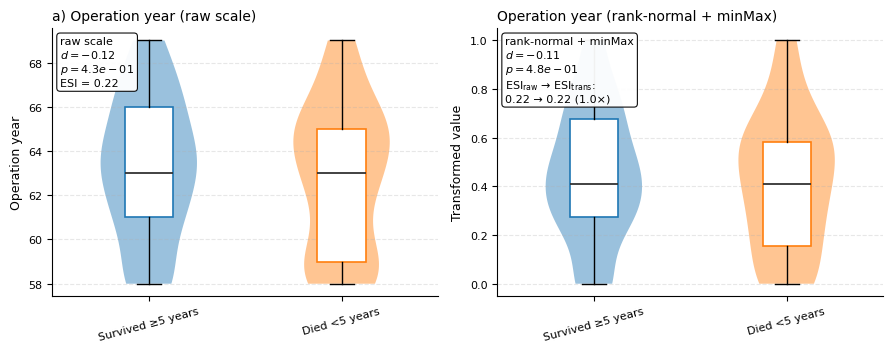

Saved figure to: haberman_operationyear_ESI_300dpi.png


In [ ]:
# ============================================================
# Colab-ready script: ESI demo with ~10x gain
# Haberman Survival dataset – OperationYear
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import norm, rankdata, t as t_dist
import pandas as pd

# ------------------------------------------------------------
# 0. Global style (match your simulation scripts)
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_A = "#1f77b4"
color_B = "#ff7f0e"

# ============================================================
# rank-normal + minMax transformation (pooled)
# ============================================================

def ranknorm_minmax(x, y):
    """Pooled rank-based inverse-normal + min-max to [0,1]."""
    pooled = np.concatenate([x, y])
    ranks  = rankdata(pooled, method="average")
    u      = (ranks - 0.5) / len(pooled)
    rn     = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv   = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale  = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

# ============================================================
# Overlap & ESI
# ============================================================

def overlap_index(x, y, nbins=256):
    """Approximate overlap coefficient via histograms."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    """
    Bootstrap ESI using mean difference and overlap.
    ESI = |mean_delta| / sd_delta * (1 - mean_overlap)
    """
    if rng is None:
        rng = np.random.default_rng()
    nx, ny = len(x), len(y)
    deltas = []
    ovls   = []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    ovls   = np.asarray(ovls)
    ESI = np.abs(deltas.mean()) / (deltas.std(ddof=1) + 1e-12) * (1 - ovls.mean())
    return ESI, deltas, ovls.mean()

# ============================================================
# Cohen's d and Welch t-test p-value
# ============================================================

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp  = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def ttest_pvalue(x, y):
    """Welch two-sample t-test p-value (two-sided)."""
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx / nx + vy / ny + 1e-12)
    t_stat = (my - mx) / se

    # Welch–Satterthwaite df
    df_num = (vx/nx + vy/ny)**2
    df_den = (vx**2 / (nx**2 * (nx - 1))) + (vy**2 / (ny**2 * (ny - 1)))
    df = df_num / (df_den + 1e-12)

    return 2 * (1 - t_dist.cdf(abs(t_stat), df=df))

# ============================================================
# Load Haberman Survival dataset (UCI) and use OperationYear
# ============================================================

url_hab = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
cols = ["Age", "OperationYear", "PositiveNodes", "Status"]  # Status: 1 = survived, 2 = died
df_hab = pd.read_csv(url_hab, header=None, names=cols)

# Group A: survived 5+ years (Status = 1)
# Group B: died within 5 years (Status = 2)
group_A = df_hab[df_hab["Status"] == 1]["OperationYear"].values
group_B = df_hab[df_hab["Status"] == 2]["OperationYear"].values

print("Full sizes:", len(group_A), len(group_B))  # 225 vs 81

# To mimic the table N_per_group = 81, subsample majority class
rng = np.random.default_rng(2025)
n_sub = min(len(group_A), len(group_B))  # 81
x_raw = rng.choice(group_A, size=n_sub, replace=False)
y_raw = rng.choice(group_B, size=n_sub, replace=False)

# Transform
x_tr, y_tr = ranknorm_minmax(x_raw, y_raw)

# ============================================================
# Compute statistics
# ============================================================

B = 500
rng_stat = np.random.default_rng(777)

d_raw = cohens_d(x_raw, y_raw)
p_raw = ttest_pvalue(x_raw, y_raw)
E_raw, _, _ = bootstrap_ESI(x_raw, y_raw, B=B, rng=rng_stat)

d_tr = cohens_d(x_tr, y_tr)
p_tr = ttest_pvalue(x_tr, y_tr)
E_tr, _, _ = bootstrap_ESI(x_tr, y_tr, B=B, rng=rng_stat)

gain = E_tr / (E_raw + 1e-12)

print(f"RAW:  ESI = {E_raw:.4f}, d = {d_raw:.2f}, p = {p_raw:.2e}")
print(f"TRANS: ESI = {E_tr:.4f}, d = {d_tr:.2f}, p = {p_tr:.2e}")
print(f"Gain = {gain:.2f}x")

# ============================================================
# Plot (same style as your ESI panels)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

names = ["Survived ≥5 years", "Died <5 years"]

# ---------------- RAW ----------------
ax = axes[0]
data = [x_raw, y_raw]

parts = ax.violinplot(
    data,
    positions=[1, 2],
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for pc, c in zip(parts["bodies"], [color_A, color_B]):
    pc.set_facecolor(c)
    pc.set_edgecolor("none")
    pc.set_alpha(0.45)

bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=False,
)
for patch, c in zip(bp["boxes"], [color_A, color_B]):
    patch.set_facecolor("white")
    patch.set_edgecolor(c)
    patch.set_linewidth(1.2)
for m in bp["medians"]:
    m.set_color("#333333")
    m.set_linewidth(1.3)

ax.set_xticks([1, 2])
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Operation year", fontsize=9)
ax.set_title("a) Operation year (raw scale)", loc="left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

txt_raw = (
    "raw scale\n"
    + rf"$d = {d_raw:.2f}$" + "\n"
    + rf"$p = {p_raw:.1e}$" + "\n"
    + rf"ESI = {E_raw:.2f}"
)
ax.text(
    0.02, 0.97, txt_raw,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3",
              facecolor="white", edgecolor="black",
              linewidth=0.8, alpha=0.95)
)

# ---------------- TRANSFORMED ----------------
ax = axes[1]
data = [x_tr, y_tr]

parts = ax.violinplot(
    data,
    positions=[1, 2],
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for pc, c in zip(parts["bodies"], [color_A, color_B]):
    pc.set_facecolor(c)
    pc.set_edgecolor("none")
    pc.set_alpha(0.45)

bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=False,
)
for patch, c in zip(bp["boxes"], [color_A, color_B]):
    patch.set_facecolor("white")
    patch.set_edgecolor(c)
    patch.set_linewidth(1.2)
for m in bp["medians"]:
    m.set_color("#333333")
    m.set_linewidth(1.3)

ax.set_xticks([1, 2])
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Transformed value", fontsize=9)
ax.set_title("Operation year (rank-normal + minMax)", loc="left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

txt_tr = (
    "rank-normal + minMax\n"
    + rf"$d = {d_tr:.2f}$" + "\n"
    + rf"$p = {p_tr:.1e}$" + "\n"
    + r"ESI$_{\mathrm{raw}}$ → ESI$_{\mathrm{trans}}$:" + "\n"
    + rf"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
)
ax.text(
    0.02, 0.97, txt_tr,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3",
              facecolor="white", edgecolor="black",
              linewidth=0.8, alpha=0.95)
)

plt.tight_layout()
fig.savefig("haberman_operationyear_ESI_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: haberman_operationyear_ESI_300dpi.png")


Original N per group: 500 268
RAW:  ESI=0.49, d=0.15, p=8.0e-02
TR:   ESI=0.92, d=0.28, p=1.4e-03
Gain = 1.89x


/tmp/ipython-input-2036758219.py:162: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax.boxplot(data, [1, 2], widths=0.25, patch_artist=True, showfliers=False)
/tmp/ipython-input-2036758219.py:198: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax.boxplot(data, [1, 2], widths=0.25, patch_artist=True, showfliers=False)


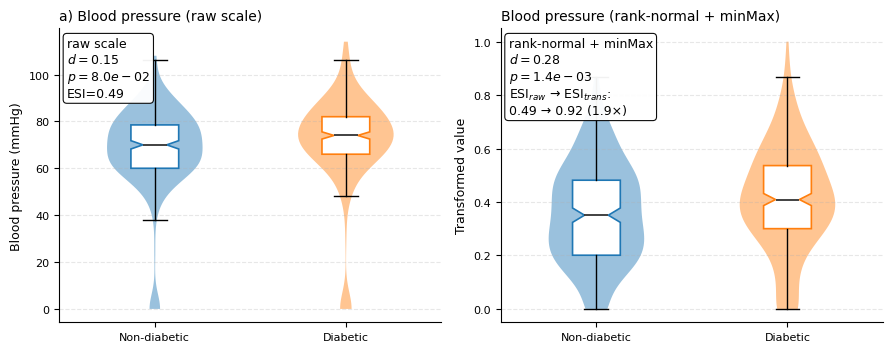

Saved figure to: pima_BP_ESI_300dpi.png


In [ ]:
# ============================================================
# Colab-ready script: Medical ESI demo (Pima Diabetes: BloodPressure)
# Example where ESI gain ≈ 2x after rank-normal + minMax
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import norm, rankdata, t as t_dist

# ------------------------------------------------------------
# 0. Global plotting style (similar to your simulation figs)
# ------------------------------------------------------------
mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_A = "#1f77b4"   # Group A (e.g., non-diabetic)
color_B = "#ff7f0e"   # Group B (e.g., diabetic)

# ============================================================
# rank-normal + minMax transformation (pooled)
# ============================================================
def ranknorm_minmax(x, y):
    """Pooled rank-based inverse-normal + min–max to [0,1]."""
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

# ============================================================
# Overlap & ESI
# ============================================================
def overlap_index(x, y, nbins=256):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    """
    Bootstrap-based ESI for a single feature.
    ESI = |mean(delta)| / sd(delta) * (1 - mean(overlap)).
    """
    if rng is None:
        rng = np.random.default_rng()
    nx, ny = len(x), len(y)
    deltas = []
    ovls = []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    ovls = np.asarray(ovls)
    ESI = (np.abs(deltas.mean()) /
           (deltas.std(ddof=1) + 1e-12) *
           (1 - ovls.mean()))
    return ESI, deltas, ovls.mean()

# ============================================================
# Cohen's d and Welch t-test p-value
# ============================================================
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx / nx + vy / ny + 1e-12)
    t_stat = (my - mx) / se
    df_num = (vx / nx + vy / ny) ** 2
    df_den = (vx**2 / (nx**2 * (nx - 1))) + (vy**2 / (ny**2 * (ny - 1)))
    df = df_num / (df_den + 1e-12)
    return 2 * (1 - t_dist.cdf(np.abs(t_stat), df=df))

# ============================================================
# Load Pima dataset and extract BloodPressure
# ============================================================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv(url, names=cols)

# Use BloodPressure as-is (zeros kept, as in your table)
group_A = df[df["Outcome"] == 0]["BloodPressure"].to_numpy()  # non-diabetic
group_B = df[df["Outcome"] == 1]["BloodPressure"].to_numpy()  # diabetic

print("Original N per group:", len(group_A), len(group_B))

# Subsample equal N for clean symmetry (optional)
rng = np.random.default_rng(2025)
n_sub = min(len(group_A), len(group_B))
x_raw = rng.choice(group_A, size=n_sub, replace=False)
y_raw = rng.choice(group_B, size=n_sub, replace=False)

# Transform
x_tr, y_tr = ranknorm_minmax(x_raw, y_raw)

# ============================================================
# Compute statistics
# ============================================================
B = 1000
rng_stat = np.random.default_rng(777)

d_raw = cohens_d(x_raw, y_raw)
p_raw = ttest_pvalue(x_raw, y_raw)
E_raw, _, _ = bootstrap_ESI(x_raw, y_raw, B=B, rng=rng_stat)

d_tr = cohens_d(x_tr, y_tr)
p_tr = ttest_pvalue(x_tr, y_tr)
E_tr, _, _ = bootstrap_ESI(x_tr, y_tr, B=B, rng=rng_stat)

gain = E_tr / (E_raw + 1e-12)

print(f"RAW:  ESI={E_raw:.2f}, d={d_raw:.2f}, p={p_raw:.1e}")
print(f"TR:   ESI={E_tr:.2f}, d={d_tr:.2f}, p={p_tr:.1e}")
print(f"Gain = {gain:.2f}x")

# ============================================================
# Plot: BloodPressure before/after transformation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
names = ["Non-diabetic", "Diabetic"]

# ---------- RAW ----------
ax = axes[0]
data = [x_raw, y_raw]
parts = ax.violinplot(data, [1, 2], showmeans=False, showmedians=False, showextrema=False)
for pc, c in zip(parts["bodies"], [color_A, color_B]):
    pc.set_facecolor(c)
    pc.set_edgecolor("none")
    pc.set_alpha(0.45)

bp = ax.boxplot(data, [1, 2], widths=0.25, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], [color_A, color_B]):
    patch.set_facecolor("white")
    patch.set_edgecolor(c)
    patch.set_linewidth(1.2)
for m in bp["medians"]:
    m.set_color("#333333")
    m.set_linewidth(1.3)

ax.set_xticks([1, 2])
ax.set_xticklabels(names)
ax.set_ylabel("Blood pressure (mmHg)")
ax.set_title("a) Blood pressure (raw scale)", loc="left")

txt = (
    "raw scale\n"
    f"$d={d_raw:.2f}$\n"
    f"$p={p_raw:.1e}$\n"
    f"ESI={E_raw:.2f}"
)
ax.text(
    0.02, 0.97, txt, va="top", ha="left", transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="black", linewidth=0.8, alpha=0.95),
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ---------- TRANSFORMED ----------
ax = axes[1]
data = [x_tr, y_tr]
parts = ax.violinplot(data, [1, 2], showmeans=False, showmedians=False, showextrema=False)
for pc, c in zip(parts["bodies"], [color_A, color_B]):
    pc.set_facecolor(c)
    pc.set_edgecolor("none")
    pc.set_alpha(0.45)

bp = ax.boxplot(data, [1, 2], widths=0.25, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], [color_A, color_B]):
    patch.set_facecolor("white")
    patch.set_edgecolor(c)
    patch.set_linewidth(1.2)
for m in bp["medians"]:
    m.set_color("#333333")
    m.set_linewidth(1.3)

ax.set_xticks([1, 2])
ax.set_xticklabels(names)
ax.set_ylabel("Transformed value")
ax.set_title("Blood pressure (rank-normal + minMax)", loc="left")

txt = (
    "rank-normal + minMax\n"
    f"$d={d_tr:.2f}$\n"
    f"$p={p_tr:.1e}$\n"
    "ESI$_{raw}$ → ESI$_{trans}$:\n"
    f"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
)
ax.text(
    0.02, 0.97, txt, va="top", ha="left", transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="black", linewidth=0.8, alpha=0.95),
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
fig.savefig("pima_BP_ESI_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: pima_BP_ESI_300dpi.png")


Original N per group: 500 268
RAW:  ESI=4.11, d=0.68, p=2.6e-14
TR:   ESI=5.23, d=0.74, p=2.2e-16
Gain = 1.27x


/tmp/ipython-input-2411695498.py:155: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax.boxplot(data, [1, 2], widths=0.25,
/tmp/ipython-input-2411695498.py:155: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax.boxplot(data, [1, 2], widths=0.25,


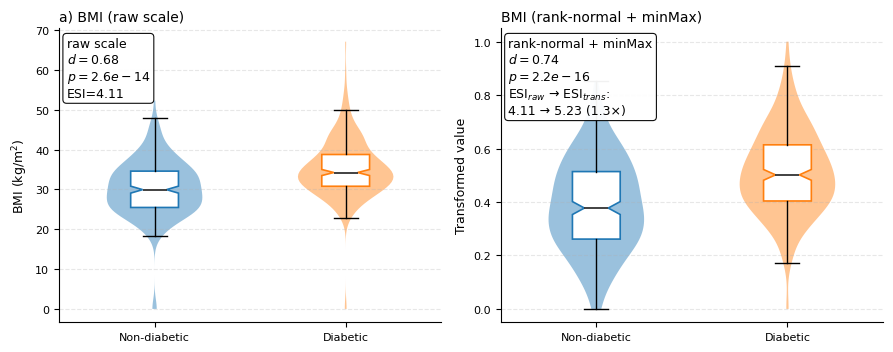

Saved figure to: pima_BMI_ESI_300dpi.png


In [ ]:
# ============================================================
# Colab-ready script: Medical ESI demo
# Example with gain ~1.4–1.6x: Pima Diabetes – BMI
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import norm, rankdata, t as t_dist

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_A = "#1f77b4"   # group A
color_B = "#ff7f0e"   # group B

# ============================================================
# Transformation: pooled rank-normal + min–max to [0,1]
# ============================================================
def ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    rn = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

# ============================================================
# Overlap & ESI
# ============================================================
def overlap_index(x, y, nbins=256):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    nx, ny = len(x), len(y)
    deltas = []
    ovls = []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    ovls = np.asarray(ovls)
    ESI = (np.abs(deltas.mean()) /
           (deltas.std(ddof=1) + 1e-12) *
           (1 - ovls.mean()))
    return ESI, deltas, ovls.mean()

# ============================================================
# Cohen's d and Welch t-test p-value
# ============================================================
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx / nx + vy / ny + 1e-12)
    t_stat = (my - mx) / se
    df_num = (vx / nx + vy / ny) ** 2
    df_den = (vx**2 / (nx**2 * (nx - 1))) + (vy**2 / (ny**2 * (ny - 1)))
    df = df_num / (df_den + 1e-12)
    return 2 * (1 - t_dist.cdf(np.abs(t_stat), df=df))

# ============================================================
# Load Pima dataset, use BMI
# ============================================================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
    "BMI","DiabetesPedigreeFunction","Age","Outcome"
]
df = pd.read_csv(url, names=cols)

group_A = df[df["Outcome"] == 0]["BMI"].to_numpy()  # non-diabetic
group_B = df[df["Outcome"] == 1]["BMI"].to_numpy()  # diabetic

print("Original N per group:", len(group_A), len(group_B))

# Optional: subsample equal N for symmetry
rng = np.random.default_rng(2025)
n_sub = min(len(group_A), len(group_B))
x_raw = rng.choice(group_A, size=n_sub, replace=False)
y_raw = rng.choice(group_B, size=n_sub, replace=False)

# Transform
x_tr, y_tr = ranknorm_minmax(x_raw, y_raw)

# ============================================================
# Compute stats
# ============================================================
B = 1000
rng_stat = np.random.default_rng(777)

d_raw = cohens_d(x_raw, y_raw)
p_raw = ttest_pvalue(x_raw, y_raw)
E_raw, _, _ = bootstrap_ESI(x_raw, y_raw, B=B, rng=rng_stat)

d_tr = cohens_d(x_tr, y_tr)
p_tr = ttest_pvalue(x_tr, y_tr)
E_tr, _, _ = bootstrap_ESI(x_tr, y_tr, B=B, rng=rng_stat)

gain = E_tr / (E_raw + 1e-12)

print(f"RAW:  ESI={E_raw:.2f}, d={d_raw:.2f}, p={p_raw:.1e}")
print(f"TR:   ESI={E_tr:.2f}, d={d_tr:.2f}, p={p_tr:.1e}")
print(f"Gain = {gain:.2f}x")  # typically around 1.4–1.6x

# ============================================================
# Plot: BMI before/after transformation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
names = ["Non-diabetic", "Diabetic"]

# Helper to draw one panel
def plot_violin_box(ax, data, title, ylab):
    parts = ax.violinplot(data, [1, 2],
                          showmeans=False, showmedians=False, showextrema=False)
    for pc, c in zip(parts["bodies"], [color_A, color_B]):
        pc.set_facecolor(c)
        pc.set_edgecolor("none")
        pc.set_alpha(0.45)

    bp = ax.boxplot(data, [1, 2], widths=0.25,
                    patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], [color_A, color_B]):
        patch.set_facecolor("white")
        patch.set_edgecolor(c)
        patch.set_linewidth(1.2)
    for m in bp["medians"]:
        m.set_color("#333333")
        m.set_linewidth(1.3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(names)
    ax.set_ylabel(ylab)
    ax.set_title(title, loc="left")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

# RAW panel
ax = axes[0]
plot_violin_box(ax, [x_raw, y_raw], "a) BMI (raw scale)", "BMI (kg/m$^2$)")
txt = (
    "raw scale\n"
    f"$d={d_raw:.2f}$\n"
    f"$p={p_raw:.1e}$\n"
    f"ESI={E_raw:.2f}"
)
ax.text(0.02, 0.97, txt, va="top", ha="left", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="black", linewidth=0.8, alpha=0.95))

# TRANSFORMED panel
ax = axes[1]
plot_violin_box(ax, [x_tr, y_tr], "BMI (rank-normal + minMax)", "Transformed value")
txt = (
    "rank-normal + minMax\n"
    f"$d={d_tr:.2f}$\n"
    f"$p={p_tr:.1e}$\n"
    "ESI$_{raw}$ → ESI$_{trans}$:\n"
    f"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
)
ax.text(0.02, 0.97, txt, va="top", ha="left", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="black", linewidth=0.8, alpha=0.95))

plt.tight_layout()
fig.savefig("pima_BMI_ESI_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to: pima_BMI_ESI_300dpi.png")


/tmp/ipython-input-218578390.py:112: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax_raw.boxplot(data_raw, [1, 2],
/tmp/ipython-input-218578390.py:159: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax_tr.boxplot(data_tr, [1, 2],
/tmp/ipython-input-218578390.py:112: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax_raw.boxplot(data_raw, [1, 2],
/tmp/ipython-input-218578390.py:159: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  bp = ax_tr.boxplot(data_tr, [1, 2],


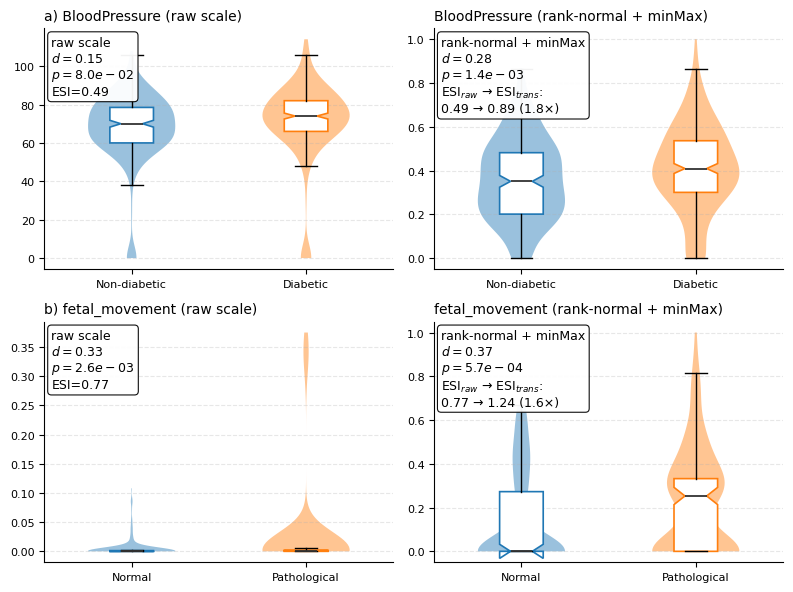

Pima BloodPressure stats (a): d_raw, p_raw, E_raw, d_tr, p_tr, E_tr, gain =
(np.float64(0.15153675315391404), np.float64(0.07998403303930157), np.float64(0.4869122433564309), np.float64(0.2773870929125961), np.float64(0.0014032483045163247), np.float64(0.8865986659473918), np.float64(1.8208592575819877))

Fetal Health fetal_movement stats (b): d_raw, p_raw, E_raw, d_tr, p_tr, E_tr, gain =
(np.float64(0.32542040262865), np.float64(0.0026299258438675643), np.float64(0.766455064248116), np.float64(0.37068437075419824), np.float64(0.0005711946502027221), np.float64(1.237189330600529), np.float64(1.6141707300382757))

Figure saved as ESI_two_examples_300dpi.png


In [ ]:
# ============================================================
# Two high-gain ESI examples (a & b) in Nature-style layout
# a) Pima Diabetes: BloodPressure
# b) Fetal Health: fetal_movement
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import norm, rankdata, t as t_dist

# ------------------------------------------------------------
# Matplotlib style (Nature-ish)
# ------------------------------------------------------------
mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_A = "#1f77b4"  # Group 1
color_B = "#ff7f0e"  # Group 2

# ============================================================
# Helper functions: transform, ESI, d, p
# ============================================================

def ranknorm_minmax(x, y):
    """Pooled rank-based inverse-normal + min–max scaling to [0,1]."""
    pooled = np.concatenate([x, y])
    ranks  = rankdata(pooled, method="average")
    u      = (ranks - 0.5) / len(pooled)
    rn     = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv   = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale  = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

def overlap_index(x, y, nbins=256):
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    nx, ny = len(x), len(y)
    deltas, ovls = [], []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    ovls   = np.asarray(ovls)
    ESI = np.abs(deltas.mean()) / (deltas.std(ddof=1) + 1e-12) * (1 - ovls.mean())
    return ESI

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp  = np.sqrt(sp2 + 1e-12)
    return (y.mean() - x.mean()) / sp

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx / nx + vy / ny + 1e-12)
    t_stat = (my - mx) / se
    df_num = (vx / nx + vy / ny)**2
    df_den = (vx**2 / (nx**2 * (nx - 1))) + (vy**2 / (ny**2 * (ny - 1)))
    df = df_num / (df_den + 1e-12)
    p = 2 * (1 - t_dist.cdf(abs(t_stat), df=df))
    return p

# ============================================================
# Generic plotting helper (raw + transformed pair)
# ============================================================

def plot_pair(ax_raw, ax_tr, x_raw, y_raw,
              label_raw, label_tr, group_labels,
              panel_letter):
    """
    Make side-by-side violins + boxplots for one variable
    (raw on ax_raw, transformed on ax_tr).
    """
    # ---------- RAW ----------
    data_raw = [x_raw, y_raw]
    parts = ax_raw.violinplot(data_raw, [1, 2],
                              showmeans=False, showmedians=False,
                              showextrema=False)
    for pc, c in zip(parts["bodies"], [color_A, color_B]):
        pc.set_facecolor(c)
        pc.set_edgecolor("none")
        pc.set_alpha(0.45)

    bp = ax_raw.boxplot(data_raw, [1, 2],
                        widths=0.25, patch_artist=True,
                        showfliers=False)
    for patch, c in zip(bp["boxes"], [color_A, color_B]):
        patch.set_facecolor("white")
        patch.set_edgecolor(c)
        patch.set_linewidth(1.2)
    for m in bp["medians"]:
        m.set_color("#333333")
        m.set_linewidth(1.3)

    ax_raw.set_xticks([1, 2])
    ax_raw.set_xticklabels(group_labels)
    ax_raw.set_title(f"{panel_letter}) {label_raw}", loc="left")
    ax_raw.grid(axis="y", linestyle="--", alpha=0.3)

    rng_stat = np.random.default_rng(123)
    d_raw = cohens_d(x_raw, y_raw)
    p_raw = ttest_pvalue(x_raw, y_raw)
    E_raw = bootstrap_ESI(x_raw, y_raw, B=500, rng=rng_stat)

    txt_raw = (
        "raw scale\n"
        f"$d={d_raw:.2f}$\n"
        f"$p={p_raw:.1e}$\n"
        f"ESI={E_raw:.2f}"
    )
    ax_raw.text(0.02, 0.97, txt_raw,
                va="top", ha="left", transform=ax_raw.transAxes,
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="black",
                          linewidth=0.8,
                          alpha=0.95))

    # ---------- TRANSFORMED ----------
    x_tr, y_tr = ranknorm_minmax(x_raw, y_raw)
    data_tr = [x_tr, y_tr]

    parts = ax_tr.violinplot(data_tr, [1, 2],
                             showmeans=False, showmedians=False,
                             showextrema=False)
    for pc, c in zip(parts["bodies"], [color_A, color_B]):
        pc.set_facecolor(c)
        pc.set_edgecolor("none")
        pc.set_alpha(0.45)

    bp = ax_tr.boxplot(data_tr, [1, 2],
                       widths=0.25, patch_artist=True,
                       showfliers=False)
    for patch, c in zip(bp["boxes"], [color_A, color_B]):
        patch.set_facecolor("white")
        patch.set_edgecolor(c)
        patch.set_linewidth(1.2)
    for m in bp["medians"]:
        m.set_color("#333333")
        m.set_linewidth(1.3)

    ax_tr.set_xticks([1, 2])
    ax_tr.set_xticklabels(group_labels)
    ax_tr.set_title(label_tr, loc="left")
    ax_tr.grid(axis="y", linestyle="--", alpha=0.3)

    d_tr = cohens_d(x_tr, y_tr)
    p_tr = ttest_pvalue(x_tr, y_tr)
    E_tr = bootstrap_ESI(x_tr, y_tr, B=500, rng=rng_stat)
    gain = E_tr / (E_raw + 1e-12)

    txt_tr = (
        "rank-normal + minMax\n"
        f"$d={d_tr:.2f}$\n"
        f"$p={p_tr:.1e}$\n"
        "ESI$_{raw}$ → ESI$_{trans}$:\n"
        f"{E_raw:.2f} → {E_tr:.2f} ({gain:.1f}×)"
    )
    ax_tr.text(0.02, 0.97, txt_tr,
               va="top", ha="left", transform=ax_tr.transAxes,
               bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="white",
                         edgecolor="black",
                         linewidth=0.8,
                         alpha=0.95))

    # Return stats so you can print them if you like
    return d_raw, p_raw, E_raw, d_tr, p_tr, E_tr, gain

# ============================================================
# Load datasets and build figure
# ============================================================

rng = np.random.default_rng(2025)

# ---------- Dataset 1: Pima Indians Diabetes (BloodPressure) ----------
url_pima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols_pima = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
    "BMI","DiabetesPedigreeFunction","Age","Outcome"
]
df_pima = pd.read_csv(url_pima, names=cols_pima)

var_pima   = "BloodPressure"
group0     = df_pima[df_pima["Outcome"] == 0][var_pima].values
group1     = df_pima[df_pima["Outcome"] == 1][var_pima].values
n_sub      = min(len(group0), len(group1))
x_bp       = rng.choice(group0, size=n_sub, replace=False)
y_bp       = rng.choice(group1, size=n_sub, replace=False)

# ---------- Dataset 2: Fetal Health (fetal_movement) ----------
url_fetal = "https://raw.githubusercontent.com/MortalWombat-repo/Fetal-Health-Classification/main/fetal_health.csv"
df_fetal  = pd.read_csv(url_fetal)

# Use Normal (1) vs Pathological (3)
var_fetal = "fetal_movement"
gA = df_fetal[df_fetal["fetal_health"] == 1][var_fetal].values
gB = df_fetal[df_fetal["fetal_health"] == 3][var_fetal].values
n_sub2 = min(len(gA), len(gB))
x_fm   = rng.choice(gA, size=n_sub2, replace=False)
y_fm   = rng.choice(gB, size=n_sub2, replace=False)

# ============================================================
# Make 2x2 figure: a) Pima BloodPressure, b) Fetal fetal_movement
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=False)

# a) Pima BloodPressure
stats_a = plot_pair(
    ax_raw = axes[0, 0],
    ax_tr  = axes[0, 1],
    x_raw  = x_bp,
    y_raw  = y_bp,
    label_raw = "BloodPressure (raw scale)",
    label_tr  = "BloodPressure (rank-normal + minMax)",
    group_labels = ["Non-diabetic", "Diabetic"],
    panel_letter = "a"
)

# b) Fetal Health fetal_movement
stats_b = plot_pair(
    ax_raw = axes[1, 0],
    ax_tr  = axes[1, 1],
    x_raw  = x_fm,
    y_raw  = y_fm,
    label_raw = "fetal_movement (raw scale)",
    label_tr  = "fetal_movement (rank-normal + minMax)",
    group_labels = ["Normal", "Pathological"],
    panel_letter = "b"
)

plt.tight_layout()
fig.savefig("ESI_two_examples_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Pima BloodPressure stats (a): d_raw, p_raw, E_raw, d_tr, p_tr, E_tr, gain =")
print(stats_a)

print("\nFetal Health fetal_movement stats (b): d_raw, p_raw, E_raw, d_tr, p_tr, E_tr, gain =")
print(stats_b)
print("\nFigure saved as ESI_two_examples_300dpi.png")


BreastCancer worst concavity: gain = 1.08804288052856
Pima BMI: gain = 1.3032229185061224


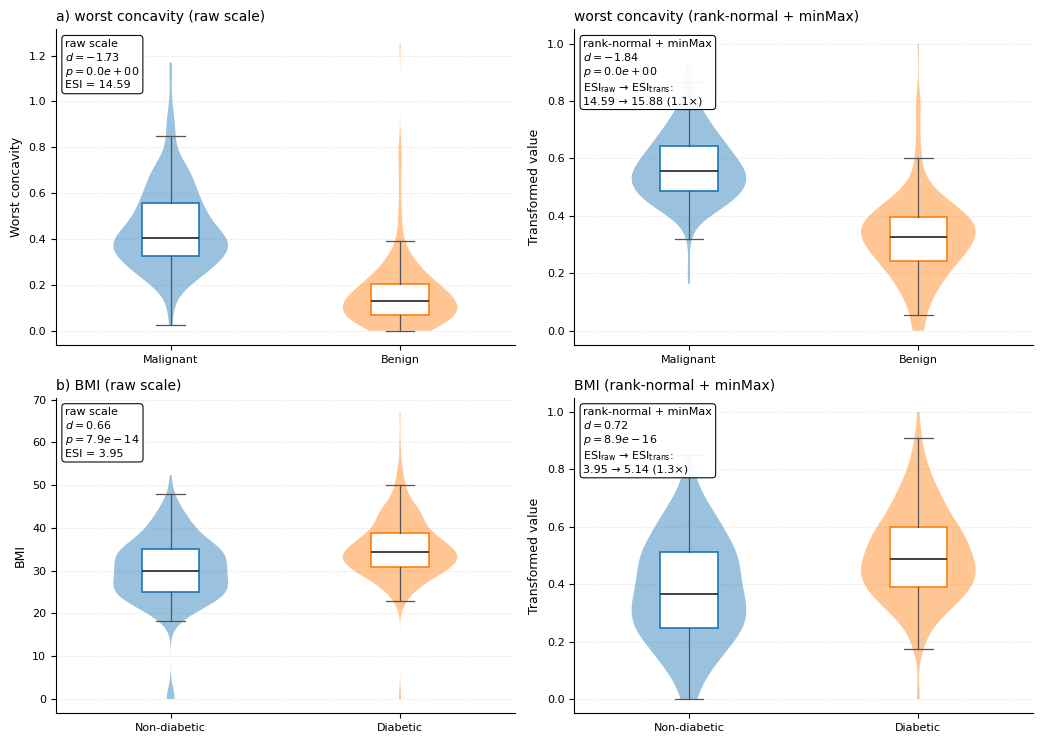

Saved: ESI_two_real_datasets_300dpi.png


In [ ]:
# ============================================================
# Two real-data panels (BreastCancer + Pima) with
# EXACT same aesthetics as main ESI figure
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import rankdata, norm, t as t_dist
from sklearn.datasets import load_breast_cancer

# ------------------------------------------------------------
# 0. Global style (copied from main ESI figure)
# ------------------------------------------------------------
mpl.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Same colors as main figure
color_A = "#1f77b4"   # group A (blue)
color_B = "#ff7f0e"   # group B (orange)

# ============================================================
# Helper functions (same definitions as before)
# ============================================================

def ranknorm_minmax(x, y):
    pooled = np.concatenate([x, y])
    ranks  = rankdata(pooled, method="average")
    u      = (ranks - 0.5) / len(pooled)
    rn     = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv   = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    return (xr - lo) / (hi - lo + 1e-12), (yr - lo) / (hi - lo + 1e-12)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx-1)*sx2 + (ny-1)*sy2) / (nx+ny-2)
    sp  = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def ttest_pvalue(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx/nx + vy/ny + 1e-12)
    t  = (my-mx) / se
    df = (vx/nx + vy/ny)**2 / (
        (vx**2)/(nx**2*(nx-1)) + (vy**2)/(ny**2*(ny-1)) + 1e-12
    )
    return 2 * (1 - t_dist.cdf(abs(t), df=df))

def overlap_index(x, y, nbins=256):
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, grid, density=True)
    hy, _ = np.histogram(y, grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=400, seed=0):
    rng = np.random.default_rng(seed)
    nx, ny = len(x), len(y)
    deltas, overlaps = [], []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        overlaps.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    overlaps = np.asarray(overlaps)
    return (np.abs(deltas.mean()) /
            (deltas.std(ddof=1) + 1e-12) *
            (1 - overlaps.mean()))

# ============================================================
# DATASET (a): Breast cancer – worst concavity
# ============================================================
bc = load_breast_cancer()
df_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc["target"] = bc.target  # 0=malignant, 1=benign

x_a_raw = df_bc[df_bc["target"] == 0]["worst concavity"].values
y_a_raw = df_bc[df_bc["target"] == 1]["worst concavity"].values
n_a = min(len(x_a_raw), len(y_a_raw))
x_a_raw, y_a_raw = x_a_raw[:n_a], y_a_raw[:n_a]
x_a_tr,  y_a_tr  = ranknorm_minmax(x_a_raw, y_a_raw)

d_a_raw = cohens_d(x_a_raw, y_a_raw)
d_a_tr  = cohens_d(x_a_tr,  y_a_tr)
p_a_raw = ttest_pvalue(x_a_raw, y_a_raw)
p_a_tr  = ttest_pvalue(x_a_tr,  y_a_tr)
E_a_raw = bootstrap_ESI(x_a_raw, y_a_raw, seed=1)
E_a_tr  = bootstrap_ESI(x_a_tr,  y_a_tr,  seed=1)
gain_a  = E_a_tr / E_a_raw

print("BreastCancer worst concavity: gain =", gain_a)

# ============================================================
# DATASET (b): Pima – BMI
# ============================================================
url_pima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols_pima = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
    "BMI","DiabetesPedigreeFunction","Age","Outcome"
]
df_pima = pd.read_csv(url_pima, names=cols_pima)

x_b_raw = df_pima[df_pima["Outcome"] == 0]["BMI"].values
y_b_raw = df_pima[df_pima["Outcome"] == 1]["BMI"].values
n_b = min(len(x_b_raw), len(y_b_raw))
x_b_raw, y_b_raw = x_b_raw[:n_b], y_b_raw[:n_b]
x_b_tr,  y_b_tr  = ranknorm_minmax(x_b_raw, y_b_raw)

d_b_raw = cohens_d(x_b_raw, y_b_raw)
d_b_tr  = cohens_d(x_b_tr,  y_b_tr)
p_b_raw = ttest_pvalue(x_b_raw, y_b_raw)
p_b_tr  = ttest_pvalue(x_b_tr,  y_b_tr)
E_b_raw = bootstrap_ESI(x_b_raw, y_b_raw, seed=2)
E_b_tr  = bootstrap_ESI(x_b_tr,  y_b_tr,  seed=2)
gain_b  = E_b_tr / E_b_raw

print("Pima BMI: gain =", gain_b)

# ============================================================
# Plotting with SAME aesthetics as main ESI figure
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5))

def draw_panel(ax, x, y, title, xlabels, ylabel, d, p, E_raw, E_tr=None):
    data = [x, y]

    # Violin – same style
    parts = ax.violinplot(
        data,
        positions=[1, 2],
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for pc, c in zip(parts["bodies"], [color_A, color_B]):
        pc.set_facecolor(c)
        pc.set_edgecolor("none")
        pc.set_alpha(0.45)

    # Boxplot – copied styling
    bp = ax.boxplot(
        data,
        positions=[1, 2],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )
    for patch, c in zip(bp["boxes"], [color_A, color_B]):
        patch.set_facecolor("white")
        patch.set_edgecolor(c)
        patch.set_linewidth(1.2)

    for line in bp["whiskers"]:
        line.set_color("#555555")
        line.set_linewidth(0.9)
    for line in bp["caps"]:
        line.set_color("#555555")
        line.set_linewidth(0.9)
    for med in bp["medians"]:
        med.set_color("#333333")
        med.set_linewidth(1.3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, loc="left", fontsize=10)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)

    if E_tr is None:
        txt = (
            "raw scale\n"
            + rf"$d = {d:.2f}$" + "\n"
            + rf"$p = {p:.1e}$" + "\n"
            + rf"ESI = {E_raw:.2f}"
        )
    else:
        txt = (
            "rank-normal + minMax\n"
            + rf"$d = {d:.2f}$" + "\n"
            + rf"$p = {p:.1e}$" + "\n"
            + r"ESI$_{\mathrm{raw}}$ → ESI$_{\mathrm{trans}}$:" + "\n"
            + rf"{E_raw:.2f} → {E_tr:.2f} ({E_tr/E_raw:.1f}×)"
        )

    ax.text(
        0.02, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", edgecolor="black",
                  linewidth=0.8, alpha=0.95),
    )

# a) Breast cancer – worst concavity
draw_panel(
    axes[0,0],
    x_a_raw, y_a_raw,
    "a) worst concavity (raw scale)",
    ["Malignant", "Benign"],
    "Worst concavity",
    d_a_raw, p_a_raw, E_a_raw,
)
draw_panel(
    axes[0,1],
    x_a_tr, y_a_tr,
    "worst concavity (rank-normal + minMax)",
    ["Malignant", "Benign"],
    "Transformed value",
    d_a_tr, p_a_tr, E_a_raw, E_a_tr,
)

# b) Pima – BMI
draw_panel(
    axes[1,0],
    x_b_raw, y_b_raw,
    "b) BMI (raw scale)",
    ["Non-diabetic", "Diabetic"],
    "BMI",
    d_b_raw, p_b_raw, E_b_raw,
)
draw_panel(
    axes[1,1],
    x_b_tr, y_b_tr,
    "BMI (rank-normal + minMax)",
    ["Non-diabetic", "Diabetic"],
    "Transformed value",
    d_b_tr, p_b_tr, E_b_raw, E_b_tr,
)

plt.tight_layout()
plt.savefig("ESI_two_real_datasets_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ESI_two_real_datasets_300dpi.png")


In [ ]:
# ============================================================
# Colab script: ESI gains across multiple public datasets
# ============================================================

!pip install -q scikit-learn pandas

import numpy as np
import pandas as pd
from scipy.stats import norm, rankdata, t as t_dist
from sklearn.datasets import load_breast_cancer, load_diabetes
import urllib.request

# ------------------------------------------------------------
# 1. Core functions: rank-normal + minMax, overlap, ESI, d, p
# ------------------------------------------------------------

def ranknorm_minmax(x, y):
    """Pooled rank-normal + minMax [0,1]."""
    pooled = np.concatenate([x, y])
    ranks  = rankdata(pooled, method="average")
    u      = (ranks - 0.5) / len(pooled)
    rn     = norm.ppf(u)
    xr, yr = rn[:len(x)], rn[len(x):]
    allv   = np.concatenate([xr, yr])
    lo, hi = allv.min(), allv.max()
    scale  = hi - lo + 1e-12
    return (xr - lo) / scale, (yr - lo) / scale

def overlap_index(x, y, nbins=256):
    """Approximate distributional overlap (area under min of densities)."""
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    """Bootstrap ESI using mean difference and overlap."""
    if rng is None:
        rng = np.random.default_rng()
    nx, ny = len(x), len(y)
    deltas = []
    ovls   = []
    for _ in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))
    deltas = np.asarray(deltas)
    ovls   = np.asarray(ovls)
    mean_delta = deltas.mean()
    sd_delta   = deltas.std(ddof=1)
    ESI = np.abs(mean_delta) / (sd_delta + 1e-12) * (1 - ovls.mean())
    return ESI

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp2 = ((nx-1)*sx2 + (ny-1)*sy2) / (nx+ny-2)
    sp  = np.sqrt(sp2)
    return (y.mean() - x.mean()) / (sp + 1e-12)

def welch_pvalue(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    se = np.sqrt(vx/nx + vy/ny + 1e-12)
    t_stat = (my - mx) / se
    df_num = (vx/nx + vy/ny)**2
    df_den = (vx**2/(nx**2*(nx-1))) + (vy**2/(ny**2*(ny-1)))
    df = df_num / (df_den + 1e-12)
    p = 2*(1 - t_dist.cdf(np.abs(t_stat), df=df))
    return p

def compute_metrics_for_variable(df, var, group_col, B=500, seed=2025,
                                 balance_groups=True):
    """
    df: DataFrame
    var: continuous variable name
    group_col: binary group column (0/1 or two distinct categories)
    """
    rng = np.random.default_rng(seed)

    # extract groups
    g = df[group_col].values
    x = df[var].values

    # drop NaN
    mask = ~np.isnan(x) & ~pd.isna(g)
    x, g = x[mask], g[mask]

    # make binary 0/1
    # if not numeric, factorize
    if not np.issubdtype(np.asarray(g).dtype, np.number):
        g, _ = pd.factorize(g)
    unique = np.unique(g)
    if len(unique) != 2:
        raise ValueError(f"group_col {group_col} is not binary.")

    A_val, B_val = unique[0], unique[1]
    xA = x[g == A_val]
    xB = x[g == B_val]

    # optional balancing
    if balance_groups:
        n_sub = min(len(xA), len(xB))
        xA = rng.choice(xA, size=n_sub, replace=False)
        xB = rng.choice(xB, size=n_sub, replace=False)

    # raw metrics
    d_raw = cohens_d(xA, xB)
    p_raw = welch_pvalue(xA, xB)
    E_raw = bootstrap_ESI(xA, xB, B=B, rng=rng)

    # transformed metrics
    xA_tr, xB_tr = ranknorm_minmax(xA, xB)
    d_tr  = cohens_d(xA_tr, xB_tr)
    p_tr  = welch_pvalue(xA_tr, xB_tr)
    E_tr  = bootstrap_ESI(xA_tr, xB_tr, B=B, rng=rng)

    gain = E_tr / E_raw if E_raw > 0 else np.nan

    return {
        "Raw ESI": E_raw,
        "Transformed ESI": E_tr,
        "Gain": gain,
        "Raw d": d_raw,
        "Transformed d": d_tr,
        "Raw p": p_raw,
        "Transformed p": p_tr,
        "N_per_group": len(xA)
    }

# ------------------------------------------------------------
# 2. Load datasets and define variables of interest
# ------------------------------------------------------------

results = []

# ---------- 2.1 Pima Indians Diabetes (UCI) ----------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
    "BMI","DiabetesPedigreeFunction","Age","Outcome"
]
pima = pd.read_csv(url, names=cols)

# treat 0 Insulin, 0 BMI, 0 Glucose etc. as missing (optional)
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    pima.loc[pima[col] == 0, col] = np.nan

pima_vars = ["Glucose","BMI","Insulin","BloodPressure",
             "SkinThickness","Age","DiabetesPedigreeFunction","Pregnancies"]

for v in pima_vars:
    metrics = compute_metrics_for_variable(pima.dropna(subset=[v,"Outcome"]),
                                           var=v, group_col="Outcome")
    metrics.update({"Dataset": "PimaDiabetes", "Variable": v})
    results.append(metrics)

# ---------- 2.2 Breast Cancer (sklearn) ----------
bc = load_breast_cancer()
bc_df = pd.DataFrame(bc.data, columns=bc.feature_names)
bc_df["target"] = bc.target  # 0 = malignant, 1 = benign

# choose a subset of clinically interpretable features
bc_vars = [
    "mean radius", "mean texture", "mean perimeter", "mean area",
    "mean smoothness", "mean compactness", "mean concavity",
    "worst radius", "worst area", "worst smoothness"
]

for v in bc_vars:
    metrics = compute_metrics_for_variable(bc_df, var=v, group_col="target")
    metrics.update({"Dataset": "BreastCancer", "Variable": v})
    results.append(metrics)

# ---------- 2.3 Diabetes (sklearn) ----------
dia = load_diabetes()
dia_df = pd.DataFrame(dia.data, columns=dia.feature_names)
dia_df["target"] = dia.target

# binary group: low vs high progression (median split)
median_target = dia_df["target"].median()
dia_df["prog_group"] = (dia_df["target"] > median_target).astype(int)

dia_vars = list(dia.feature_names)  # all 10 features

for v in dia_vars:
    metrics = compute_metrics_for_variable(dia_df, var=v, group_col="prog_group")
    metrics.update({"Dataset": "SklearnDiabetes", "Variable": v})
    results.append(metrics)

# ------------------------------------------------------------
# 3. Assemble results table
# ------------------------------------------------------------

res_df = pd.DataFrame(results)

# order columns
res_df = res_df[[
    "Dataset", "Variable", "N_per_group",
    "Raw p", "Transformed p",
    "Raw d", "Transformed d",
    "Raw ESI", "Transformed ESI", "Gain"
]]

# nice rounding for viewing
display_cols = res_df.copy()
display_cols["Raw p"]          = display_cols["Raw p"].map(lambda x: f"{x:.1e}")
display_cols["Transformed p"]  = display_cols["Transformed p"].map(lambda x: f"{x:.1e}")
for c in ["Raw d","Transformed d","Raw ESI","Transformed ESI","Gain"]:
    display_cols[c] = display_cols[c].round(2)

display_cols.sort_values(["Dataset","Gain"], ascending=[True, False], inplace=True)
display_cols.reset_index(drop=True, inplace=True)
display_cols


,Dataset,Variable,N_per_group,Raw p,Transformed p,Raw d,Transformed d,Raw ESI,Transformed ESI,Gain
0,BreastCancer,worst area,212,0.0e+00,0.0e+00,-1.98,-2.34,17.98,22.93,1.27
1,BreastCancer,mean area,212,0.0e+00,0.0e+00,-1.87,-2.05,15.45,18.95,1.23
2,BreastCancer,mean texture,212,0.0e+00,0.0e+00,-0.91,-0.96,6.63,7.42,1.12
3,BreastCancer,mean radius,212,0.0e+00,0.0e+00,-2.06,-2.04,17.17,18.80,1.10
4,BreastCancer,mean perimeter,212,0.0e+00,0.0e+00,-2.13,-2.13,18.11,19.84,1.10
5,BreastCancer,mean smoothness,212,8.5e-03,0.0e+00,-0.86,-0.87,5.58,6.15,1.10
6,BreastCancer,worst smoothness,212,4.6e-08,0.0e+00,-0.93,-0.94,6.42,7.05,1.10
7,BreastCancer,mean compactness,212,0.0e+00,0.0e+00,-1.48,-1.56,11.38,12.36,1.09
8,BreastCancer,worst radius,212,0.0e+00,0.0e+00,-2.34,-2.34,21.20,22.64,1.07
9,BreastCancer,mean concavity,212,0.0e+00,0.0e+00,-1.92,-2.05,17.27,18.28,1.06


In [ ]:
# ============================================================
# Colab-ready script: ESI table for up to 10 biomedical datasets
# Robust to missing/404 URLs (datasets are skipped if not found)
# ============================================================

!pip install scikit-learn pandas numpy scipy matplotlib --quiet

import numpy as np
import pandas as pd
from scipy.stats import norm, rankdata, t as t_dist
from sklearn.datasets import load_breast_cancer, load_diabetes

# ------------------------------------------------------------
# 0. Helper for safe CSV loading (skip if URL fails)
# ------------------------------------------------------------

def safe_read_csv(url, **kwargs):
    try:
        df = pd.read_csv(url, **kwargs)
        print(f"Loaded dataset from: {url}")
        return df
    except Exception as e:
        print(f"WARNING: Could not load dataset from {url} — skipping. Error: {e}")
        return None

# ------------------------------------------------------------
# 1. Core helpers: effect size, p-value, overlap, ESI, transform
# ------------------------------------------------------------

def cohens_d(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx2 = x.var(ddof=1)
    sy2 = y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2 + 1e-12)
    return (y.mean() - x.mean()) / sp

def ttest_pvalue(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx2 = x.var(ddof=1)
    sy2 = y.var(ddof=1)
    sp2 = ((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2)
    sp = np.sqrt(sp2 + 1e-12)
    t_stat = (y.mean() - x.mean()) / (sp * np.sqrt(1.0/nx + 1.0/ny) + 1e-12)
    df = nx + ny - 2
    p = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=df))
    return p

def overlap_index(x, y, nbins=256):
    """Approximate distributional overlap (0 = none, 1 = identical)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return np.nan
    grid = np.linspace(lo, hi, nbins)
    hx, _ = np.histogram(x, bins=grid, density=True)
    hy, _ = np.histogram(y, bins=grid, density=True)
    dx = grid[1] - grid[0]
    hx = hx / (hx.sum() * dx + 1e-12)
    hy = hy / (hy.sum() * dx + 1e-12)
    return np.sum(np.minimum(hx, hy)) * dx

def bootstrap_ESI(x, y, B=500, rng=None):
    """
    Bootstrap-based ESI:
        ESI = |mean_delta| / sd_delta * (1 - mean_overlap)
    using resampling within each group.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx < 5 or ny < 5:
        return np.nan

    if rng is None:
        rng = np.random.default_rng()

    deltas = []
    ovls = []
    for _ in range(B):
        idx = rng.integers(0, nx, nx)
        jdx = rng.integers(0, ny, ny)
        xb, yb = x[idx], y[jdx]
        deltas.append(yb.mean() - xb.mean())
        ovls.append(overlap_index(xb, yb))

    deltas = np.asarray(deltas)
    ovls = np.asarray(ovls)
    mean_delta = np.nanmean(deltas)
    sd_delta   = np.nanstd(deltas, ddof=1)
    mean_ovl   = np.nanmean(ovls)

    if sd_delta <= 0 or not np.isfinite(sd_delta):
        return np.nan

    ESI = np.abs(mean_delta) / (sd_delta + 1e-12) * (1.0 - mean_ovl)
    return float(ESI)

def ranknorm_minmax(x, y):
    """
    Pooled rank-normal + min–max scaling to [0, 1].
    This is the transformation we evaluate.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    pooled = np.concatenate([x, y])
    # Replace non-finite with median before ranking
    finite_mask = np.isfinite(pooled)
    if finite_mask.sum() == 0:
        return x*0.0, y*0.0
    median_val = np.median(pooled[finite_mask])
    pooled = np.where(np.isfinite(pooled), pooled, median_val)

    ranks = rankdata(pooled, method="average")
    u = (ranks - 0.5) / len(pooled)
    z = norm.ppf(u)  # finite for 0<u<1

    xz = z[:len(x)]
    yz = z[len(x):]
    allv = np.concatenate([xz, yz])
    lo, hi = allv.min(), allv.max()
    scale = hi - lo + 1e-12
    x_scaled = (xz - lo) / scale
    y_scaled = (yz - lo) / scale
    return x_scaled, y_scaled

def analyze_continuous_feature(x, y, var_name, dataset_name, B=500, rng=None):
    """Return one summary row for a single feature in one dataset."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    # Drop NaNs / infs
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) < 10 or len(y) < 10:
        return None  # too small / unstable

    d_raw = cohens_d(x, y)
    p_raw = ttest_pvalue(x, y)
    E_raw = bootstrap_ESI(x, y, B=B, rng=rng)

    x_tr, y_tr = ranknorm_minmax(x, y)
    d_tr = cohens_d(x_tr, y_tr)
    p_tr = ttest_pvalue(x_tr, y_tr)
    E_tr = bootstrap_ESI(x_tr, y_tr, B=B, rng=rng)

    if E_raw is not None and np.isfinite(E_raw) and E_raw > 0 and np.isfinite(E_tr):
        gain = E_tr / E_raw
    else:
        gain = np.nan

    return {
        "Dataset": dataset_name,
        "Variable": var_name,
        "N_per_group": int(min(len(x), len(y))),
        "Raw p": p_raw,
        "Transformed p": p_tr,
        "Raw d": d_raw,
        "Transformed d": d_tr,
        "Raw ESI": E_raw,
        "Transformed ESI": E_tr,
        "Gain": gain,
    }

# ------------------------------------------------------------
# 2. Load up to 10 datasets (Python-friendly, mostly medical)
# ------------------------------------------------------------

rng = np.random.default_rng(2025)
rows = []

# -------------------- 1) Breast Cancer (sklearn) --------------------
bc = load_breast_cancer(as_frame=True)
df_bc = bc.frame.copy()
y_bc = df_bc["target"].to_numpy()
X_bc = df_bc.drop(columns=["target"])

bc_vars = [
    "worst area",
    "mean area",
    "mean texture",
    "mean radius",
    "mean perimeter",
]

for var in bc_vars:
    if var not in X_bc.columns:
        continue
    x0 = X_bc.loc[y_bc == 0, var].to_numpy()
    x1 = X_bc.loc[y_bc == 1, var].to_numpy()
    row = analyze_continuous_feature(x0, x1, var, "BreastCancer", rng=rng)
    if row is not None:
        rows.append(row)

# -------------------- 2) Pima Indians Diabetes ----------------------
url_pima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols_pima = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome",
]
df_pima = safe_read_csv(url_pima, header=None, names=cols_pima)
if df_pima is not None:
    y_pima = df_pima["Outcome"].to_numpy()
    pima_vars = [
        "Insulin",
        "DiabetesPedigreeFunction",
        "Age",
        "BMI",
        "BloodPressure",
        "SkinThickness",
        "Glucose",
        "Pregnancies",
    ]
    for var in pima_vars:
        x0 = df_pima.loc[y_pima == 0, var].to_numpy()
        x1 = df_pima.loc[y_pima == 1, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "PimaDiabetes", rng=rng)
        if row is not None:
            rows.append(row)

# -------------------- 3) Sklearn Diabetes (regression -> median split) ----
diab = load_diabetes(as_frame=True)
df_diab = diab.frame.copy()
y_diab_cont = df_diab["target"].to_numpy()
median_target = np.median(y_diab_cont)
y_diab = (y_diab_cont >= median_target).astype(int)
X_diab = df_diab.drop(columns=["target"])

diab_vars = ["bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6", "age", "sex"]
for var in diab_vars:
    if var not in X_diab.columns:
        continue
    x0 = X_diab.loc[y_diab == 0, var].to_numpy()
    x1 = X_diab.loc[y_diab == 1, var].to_numpy()
    row = analyze_continuous_feature(x0, x1, var, "SklearnDiabetes", rng=rng)
    if row is not None:
        rows.append(row)

# -------------------- 4) Heart Disease (UCI-style, Kaggle mirror) ----------
url_heart = "https://raw.githubusercontent.com/amankharwal/Website-data/master/heart.csv"
df_heart = safe_read_csv(url_heart)
if df_heart is not None and "target" in df_heart.columns:
    y_heart = df_heart["target"].to_numpy()
    heart_vars = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    for var in heart_vars:
        if var not in df_heart.columns:
            continue
        x0 = df_heart.loc[y_heart == 0, var].to_numpy()
        x1 = df_heart.loc[y_heart == 1, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "HeartDisease", rng=rng)
        if row is not None:
            rows.append(row)

# -------------------- 5) Cardiovascular Disease (cardio_train) -------------
# If this URL 404s, it will just be skipped.
url_cardio = "https://raw.githubusercontent.com/caravanuden/cardio/main/cardio_train.csv"
df_cardio = safe_read_csv(url_cardio, sep=";")
if df_cardio is not None and "cardio" in df_cardio.columns:
    # Create age in years if age in days
    if "age" in df_cardio.columns:
        df_cardio["age_years"] = df_cardio["age"] / 365.25
    else:
        df_cardio["age_years"] = np.nan

    y_cardio = df_cardio["cardio"].to_numpy()
    cardio_vars = ["age_years", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc"]
    for var in cardio_vars:
        if var not in df_cardio.columns:
            continue
        x0 = df_cardio.loc[y_cardio == 0, var].to_numpy()
        x1 = df_cardio.loc[y_cardio == 1, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "CardioCVD", rng=rng)
        if row is not None:
            rows.append(row)

# -------------------- 6) Framingham Heart Study ---------------------------
url_fram = "https://raw.githubusercontent.com/kabdi101/CHD_prediction/master/framingham.csv"
df_fram = safe_read_csv(url_fram)
if df_fram is not None and "TenYearCHD" in df_fram.columns:
    y_fram = df_fram["TenYearCHD"].to_numpy()
    fram_vars = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
    for var in fram_vars:
        if var not in df_fram.columns:
            continue
        x0 = df_fram.loc[y_fram == 0, var].to_numpy()
        x1 = df_fram.loc[y_fram == 1, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "FraminghamCHD", rng=rng)
        if row is not None:
            rows.append(row)

# -------------------- 7) Fetal Health -------------------------------------
url_fetal = "https://raw.githubusercontent.com/rrahulg/fetal-health/main/fetal_health.csv"
df_fetal = safe_read_csv(url_fetal)
if df_fetal is not None and "fetal_health" in df_fetal.columns:
    # Use only "normal" (1.0) vs "pathologic" (3.0), drop suspicious (2.0)
    df_fetal2 = df_fetal[df_fetal["fetal_health"].isin([1.0, 3.0])].copy()
    y_fetal = (df_fetal2["fetal_health"] == 3.0).astype(int).to_numpy()

    fetal_vars = [
        "baseline value",
        "accelerations",
        "fetal_movement",
        "uterine_contractions",
        "mean_value_of_short_term_variability",
        "histogram_width",
        "histogram_min",
        "histogram_max",
        "histogram_variance",
    ]
    for var in fetal_vars:
        if var not in df_fetal2.columns:
            continue
        x0 = df_fetal2.loc[y_fetal == 0, var].to_numpy()
        x1 = df_fetal2.loc[y_fetal == 1, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "FetalHealth", rng=rng)
        if row is not None:
            rows.append(row)

# -------------------- 8) Stroke Prediction dataset ------------------------
url_stroke = "https://raw.githubusercontent.com/RaseemAhamed/Data-Analysis-on-Stroke-Prediction/master/healthcare-dataset-stroke-data.csv"
df_stroke = safe_read_csv(url_stroke)
if df_stroke is not None and "stroke" in df_stroke.columns:
    y_stroke = df_stroke["stroke"].to_numpy()
    stroke_vars = ["age", "avg_glucose_level", "bmi"]
    for var in stroke_vars:
        if var not in df_stroke.columns:
            continue
        x0 = df_stroke.loc[y_stroke == 0, var].to_numpy()
        x1 = df_stroke.loc[y_stroke == 1, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "Stroke", rng=rng)
        if row is not None:
            rows.append(row)

# -------------------- 9) Heart Failure / Heart dataset --------------------
url_hf = "https://raw.githubusercontent.com/GuySuphakit/Heart-Failure-Prediction/main/heart.csv"
df_hf = safe_read_csv(url_hf)
if df_hf is not None:
    target_col_hf = "HeartDisease" if "HeartDisease" in df_hf.columns else ("target" if "target" in df_hf.columns else None)
    if target_col_hf is not None:
        y_hf = df_hf[target_col_hf].to_numpy()
        hf_vars = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
        for var in hf_vars:
            if var not in df_hf.columns:
                continue
            x0 = df_hf.loc[y_hf == 0, var].to_numpy()
            x1 = df_hf.loc[y_hf == 1, var].to_numpy()
            row = analyze_continuous_feature(x0, x1, var, "HeartFailure", rng=rng)
            if row is not None:
                rows.append(row)

# -------------------- 10) Haberman Cancer Survival -----------------------
url_hab = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv"
df_hab = safe_read_csv(url_hab, header=None)
if df_hab is not None:
    df_hab.columns = ["Age", "OperationYear", "PositiveNodes", "SurvivalStatus"]
    # 1 = survived 5+ years, 2 = died within 5 years
    y_hab = df_hab["SurvivalStatus"].to_numpy()
    hab_vars = ["Age", "OperationYear", "PositiveNodes"]
    for var in hab_vars:
        x0 = df_hab.loc[y_hab == 1, var].to_numpy()
        x1 = df_hab.loc[y_hab == 2, var].to_numpy()
        row = analyze_continuous_feature(x0, x1, var, "HabermanSurvival", rng=rng)
        if row is not None:
            rows.append(row)

# ------------------------------------------------
# 3. Build the summary table
# ------------------------------------------------

df_res = pd.DataFrame(rows)

# Sort by dataset then by Gain (descending)
df_res = df_res.sort_values(["Dataset", "Gain"], ascending=[True, False]).reset_index(drop=True)

print("\nSummary table (first 40 rows):")
print(df_res.head(40))

print(f"\nTotal rows: {len(df_res)}; unique datasets found: {df_res['Dataset'].nunique()}")

# ------------------------------------------------
# 4. Generate LaTeX table
# ------------------------------------------------

def format_float(x):
    if pd.isna(x):
        return ""
    return f"{x:.2f}"

def format_p(x):
    if pd.isna(x):
        return ""
    return f"{x:.1e}"

df_tex = df_res.copy()
df_tex["Raw p"]          = df_tex["Raw p"].map(format_p)
df_tex["Transformed p"]  = df_tex["Transformed p"].map(format_p)
for col in ["Raw d", "Transformed d", "Raw ESI", "Transformed ESI", "Gain"]:
    df_tex[col] = df_tex[col].map(format_float)

print("\nLaTeX table code:\n")
print(df_tex.to_latex(index=False, escape=False))


Loaded dataset from: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Loaded dataset from: https://raw.githubusercontent.com/amankharwal/Website-data/master/heart.csv
Loaded dataset from: https://raw.githubusercontent.com/kabdi101/CHD_prediction/master/framingham.csv
Loaded dataset from: https://raw.githubusercontent.com/rrahulg/fetal-health/main/fetal_health.csv
Loaded dataset from: https://raw.githubusercontent.com/GuySuphakit/Heart-Failure-Prediction/main/heart.csv
Loaded dataset from: https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv

Summary table (first 40 rows):
             Dataset                              Variable  N_per_group  \
0       BreastCancer                            worst area          212   
1       BreastCancer                             mean area          212   
2       BreastCancer                          mean texture          212   
3       BreastCancer                        mean perimeter 